# A Visual History of Popular Music
## How Has the Sound of Music Changed Over Time?

This notebook tells the story of how recorded music changed over about one hundred years, from the 1920s to 2021. It uses Spotify's audio features for roughly 587,000 tracks and the metadata for 1.16 million artists. The story is told in **four chapters**:

1. **The artists:** who makes popular music, and how that changed.
2. **The sound and how it is created:** from quiet acoustic recordings to loud, produced sound.
3. **The tempo and rhythm:** whether music got faster or more danceable, and how its rhythmic structure shifted.
4. **The meaning and what people look for:** how songs feel, what their titles say, and what listeners reward today.

The notebook reads from top to bottom. Every step explains what is being done and why, and every chart is followed by a short interpretation.

**Research question.** *A visual history of popular music: how has the sound of music changed over time?*

### Table of contents
1. [Section 1: Data Overview](#section-1)
2. [Section 2: Data Cleaning](#section-2)
3. [Section 3: Exploratory Data Analysis, the story in four chapters](#section-3)
   - [3.0 Outlier handling](#section-30)
   - [Chapter 1: The Artists](#chapter-1)
   - [Chapter 2: The Sound and the Creation](#chapter-2)
   - [Chapter 3: The Tempo](#chapter-3)
   - [Chapter 4: The Meaning, and what people look for](#chapter-4)
4. [Section 4: Key Findings and Decision Table](#section-4)

**Outputs written by this notebook**
- `figures/figNN_*.png`: every figure, saved at 200 dpi; interactive Plotly figures are also saved as `.html`
- `data/tracks_clean.csv`: the cleaned, de-duplicated, artist-joined track table
- `outputs/decision_table.csv`, `outputs/cleaning_log.csv`, `outputs/data_dictionary.csv` and supporting statistics tables

### Setup

The first code cell imports the libraries, fixes a random seed so that every sample, cluster and model is reproducible, and creates the output folders. The second cell defines one visual style for the whole notebook. It uses a colour-blind-safe categorical palette, a single-hue blue ramp for magnitudes, a blue-grey-red diverging ramp for values above or below average, and the perceptually uniform `cividis` ramp for decades, because decades are *ordered* and should read light-to-dark rather than as unrelated colours.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install statsmodels networkx squarify wordcloud

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scikit-learn statsmodels networkx squarify wordcloud shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install "kaleido>=1"

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ---- Imports -------------------------------------------------------------
import ast
import re
import warnings
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import offset_copy
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from IPython.display import Image as IPImage
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from statsmodels.nonparametric.smoothers_lowess import lowess  # LOWESS smoother for trend lines
import networkx as nx            # collaboration network (Chapter 1)
import squarify                  # treemap layout (Chapter 1)
from wordcloud import WordCloud  # title word clouds (Chapter 4)
import shap                      # SHAP explanations of the popularity model (Chapter 4)
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)

# ---- Reproducibility -----------------------------------------------------
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# ---- Folders -------------------------------------------------------------
FIG_DIR, DATA_DIR, OUT_DIR = Path('figures'), Path('data'), Path('outputs')
for d in (FIG_DIR, DATA_DIR, OUT_DIR):
    d.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:,.3f}'.format)
pio.renderers.default = 'notebook_connected'   # keeps the notebook small; loads plotly.js from a CDN
print('pandas', pd.__version__, '| seed', SEED)

pandas 3.0.5 | seed 42


In [7]:
# ---- Visual style (used by every figure) ----------------------------------
# Categorical palette: fixed order, validated for colour-vision deficiency (never cycled past 8).
CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#8a8984', '#e6e5e1'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div_blue_red', ['#104281', '#3987e5', '#f0efec', '#e66767', '#b02b2b'])

plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 200, 'savefig.bbox': 'tight', 'figure.facecolor': 'white',
    'font.size': 12.5, 'axes.titlesize': 13.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 12.5, 'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'legend.title_fontsize': 11.5,
    'legend.frameon': False, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.prop_cycle': mpl.cycler(color=CAT), 'lines.linewidth': 2,
    'text.color': INK, 'axes.labelcolor': INK, 'xtick.color': INK2, 'ytick.color': INK2,
})

def save_fig(fig, num, name, title, subtitle=None, question=None):
    """Three-line title block above the plot, then save as PNG (200 dpi) and show.

    Line 1 (blue kicker): figure number + the question this figure answers.
    Line 2 (bold headline): the answer / takeaway.
    Line 3 (grey): what is plotted and how to read it.
    """
    # Text sits just above the figure edge, offset in points, so it never collides with the axes;
    # bbox_inches='tight' then includes it in the saved image.
    above = lambda pts: offset_copy(fig.transFigure, fig=fig, y=pts, units='points')
    y = 4
    if subtitle:
        fig.text(0.01, 1.0, subtitle, ha='left', va='bottom', fontsize=12, color=INK2, transform=above(y))
        y += 21
    fig.text(0.01, 1.0, title, ha='left', va='bottom', fontsize=17, fontweight='bold', transform=above(y))
    y += 27
    kicker = f'FIGURE {num}' + (f'   ·   {question}' if question else '')
    fig.text(0.01, 1.0, kicker, ha='left', va='bottom', fontsize=12, fontweight='bold', color=CAT[0], transform=above(y))
    path = FIG_DIR / f'fig{num:02d}_{name}.png'
    fig.savefig(path)
    plt.show()
    print(f'Saved -> {path}')

def md_table(df, floatfmt='.3f', index=True, **kw):
    """Render a DataFrame as a Markdown table (reads better than the default HTML for narrative tables)."""
    display(Markdown(df.to_markdown(floatfmt=floatfmt, index=index, **kw)))

# ---- Story eras and milestones (shared by every time-axis chart) ------------
# The eras are the chapters of the story told in Section 3E, so every timeline uses the same bands.
ERAS = [(1920, 1960, 'Acoustic era', 'Acoustic'), (1960, 1980, 'Electric handover', 'Handover'),
        (1980, 2000, 'Electric & danceable', 'Electric'), (2000, 2010, 'Loudness-war peak', 'Loudness\nwar'),
        (2010, 2021.6, 'Streaming era', 'Streaming')]
ERA_SHADE = '#ecebe6'
MILESTONES = [(1948, 'LP record introduced'), (1982, 'Compact Disc launched'), (2008, 'Spotify launched')]
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

def add_eras(ax, labels=True, short=False, fontsize=10, headroom=0.14):
    """Shade alternate story eras and (optionally) label them along the top of the plot."""
    if labels:
        lo, hi = ax.get_ylim()
        ax.set_ylim(lo, hi + (hi - lo) * headroom)
    for i, (a, b, long_lbl, short_lbl) in enumerate(ERAS):
        if i % 2 == 0:
            ax.axvspan(a, b, color=ERA_SHADE, lw=0, zorder=0)
        if labels:
            ax.text((a + b) / 2, 0.985, short_lbl if short else long_lbl, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=fontsize, color=INK2, fontstyle='italic', zorder=6)

def add_milestones(ax, items=MILESTONES, y=0.03, fontsize=9.5):
    """Dotted vertical lines for technology milestones, labelled vertically near the bottom."""
    for yr, lbl in items:
        ax.axvline(yr, color=MUTED, lw=1.1, ls=(0, (2, 2)), zorder=2)
        ax.text(yr + 0.7, y, lbl, transform=ax.get_xaxis_transform(), rotation=90, va='bottom', ha='left',
                fontsize=fontsize, color=INK2, zorder=6)

# Same eras on a categorical decade axis (positions 1..11 = 1920s..2020s, as used by box plots and bars)
ERA_DECADES = [('Acoustic', 1, 4), ('Handover', 5, 6), ('Electric', 7, 8), ('Loudness\nwar', 9, 9), ('Streaming', 10, 11)]

def add_eras_cat(ax, labels=True, fontsize=10, headroom=0.16, offset=0):
    """Era bands on a decade axis; offset=-1 when the axis uses positions 0..10 instead of 1..11."""
    if labels:
        lo, hi = ax.get_ylim()
        ax.set_ylim(lo, hi + (hi - lo) * headroom)
    for i, (lbl, a, b) in enumerate(ERA_DECADES):
        if i % 2 == 0:
            ax.axvspan(a - 0.5 + offset, b + 0.5 + offset, color=ERA_SHADE, lw=0, zorder=0)
        if labels:
            ax.text((a + b) / 2 + offset, 0.985, lbl, transform=ax.get_xaxis_transform(), ha='center', va='top',
                    fontsize=fontsize, color=INK2, fontstyle='italic', zorder=6)

def decade_boxes(ax, df, col, notch=True, median_line=True, face='#b7d3f6'):
    """Side-by-side (notched) box plots of `col` for every decade, plus an orange line through the medians."""
    data = [df.loc[df['decade_label'] == d, col].dropna().astype(float).values for d in DECADE_LABELS]
    bp = ax.boxplot(data, notch=notch, patch_artist=True, widths=0.62, showfliers=False,
                    medianprops=dict(color=INK, lw=2.2), whiskerprops=dict(color=INK2, lw=1.1),
                    capprops=dict(color=INK2, lw=1.1), boxprops=dict(edgecolor=INK2, lw=1))
    for patch in bp['boxes']:
        patch.set_facecolor(face)
    meds = [np.median(x) for x in data]
    if median_line:
        ax.plot(range(1, len(meds) + 1), meds, color=CAT[1], lw=2.4, marker='o', markersize=6, markeredgecolor='white', zorder=5)
    ax.set_xticks(range(1, len(DECADE_LABELS) + 1), DECADE_LABELS)
    ax.grid(axis='x', visible=False)
    return meds

BOX_LEGEND = [Patch(facecolor='#b7d3f6', edgecolor=INK2, label='Box = middle 50% of songs (Q1 to Q3)'),
              Line2D([], [], color=INK, lw=2.2, label='Black line = median (notch = its 95% confidence range)'),
              Line2D([], [], color=INK2, lw=1.1, label='Whiskers = min / max excluding outliers (1.5 × IQR)'),
              Line2D([], [], color=CAT[1], lw=2.4, marker='o', label='Orange line = decade medians joined up')]

def hist_shape(s):
    """Name a distribution's shape with the histogram types from the EDA guide (rules applied in order)."""
    s = pd.Series(s).dropna().astype(float)
    sk = s.skew()
    if abs(sk) > 0.75:                                   # strongly lopsided
        return 'right-skewed' if sk > 0 else 'left-skewed'
    counts, _ = np.histogram(s, bins=10)
    mid = counts[3:7].mean()
    if counts[0] > 1.3 * mid and counts[-1] > 1.3 * mid:  # both ends heavier than the middle = U-shape
        return 'bimodal'
    if counts[0] > 2 * mid:                              # pile-up at the low end
        return 'right-skewed'
    if counts[-1] > 2 * mid:                             # pile-up at the high end
        return 'left-skewed'
    if abs(sk) > 0.4:
        return 'right-skewed' if sk > 0 else 'left-skewed'
    return 'roughly uniform' if counts.min() > 0.5 * counts.max() else 'roughly symmetric'

ERA_HANDLE = Patch(facecolor=ERA_SHADE, edgecolor=MUTED, label='Shaded bands = story eras (named at top)')
MILESTONE_HANDLE = Line2D([], [], color=MUTED, lw=1.1, ls=(0, (2, 2)), label='Technology milestone')

# ---- Genre-family and mood colours: the same entity always gets the same colour in every chart ----
FAM_ORDER = ['Pop', 'Rock', 'Hip hop/Rap', 'Electronic/Dance', 'R&B/Soul', 'Jazz', 'Classical', 'Country/Folk', 'Metal', 'Latin', 'Other']
GENRE_COL = {'Pop': CAT[0], 'Rock': CAT[1], 'Latin': CAT[2], 'Hip hop/Rap': CAT[3], 'R&B/Soul': CAT[4], 'Classical': CAT[5],
             'Electronic/Dance': CAT[6], 'Metal': CAT[7], 'Jazz': '#8c564b', 'Country/Folk': '#0f6e74', 'Other': '#b5b4ae',
             'No genre tags': '#e4e3df'}
MOODS = ['Sad/Melancholy', 'Peaceful/Content', 'Happy/Energetic', 'Angry/Intense']
MOOD_COL = {'Sad/Melancholy': CAT[0], 'Peaceful/Content': CAT[2], 'Happy/Energetic': CAT[3], 'Angry/Intense': CAT[7]}

# ---- Shared constants ----------------------------------------------------
UNIT_FEATS = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'liveness']
AUDIO = UNIT_FEATS + ['loudness', 'tempo']
KEY_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
LABELS = {f: f'{f.capitalize()} (0–1)' for f in UNIT_FEATS}
LABELS.update({'loudness': 'Loudness (dB)', 'tempo': 'Tempo (BPM)', 'duration_min': 'Duration (min)',
               'popularity': 'Popularity (0–100)', 'release_year': 'Release year',
               'artist_followers': 'Artist followers', 'log_followers': 'log10(followers + 1)'})
DECADES = list(range(1920, 2030, 10))
DECADE_LABELS = [f'{d}s' for d in DECADES]
DEC_PAL = dict(zip(DECADE_LABELS, mpl.colormaps['cividis'](np.linspace(0.0, 0.92, len(DECADES)))))
print('Style ready:', len(CAT), 'categorical colours,', len(DECADES), 'decade colours')

Style ready: 8 categorical colours, 11 decade colours


<a id="section-1"></a>
# Section 1: Data Overview

### 1.1 Purpose of the data

The data comes from Spotify's public Web API and was collected in 2021. There are two linked tables.

* **`tracks.csv`** has one row per track (song, recording or audio item). For each track, Spotify's audio-analysis engine computes **audio features**. These are numerical descriptions of how the recording *sounds*, such as how danceable, energetic, loud, acoustic or cheerful it is. The table also stores the release date, the credited artists, an explicit-lyrics flag and a popularity score.
* **`artists.csv`** has one row per artist, with follower counts, an artist popularity score and the genre tags that Spotify assigns.

**How this connects to the four chapters.** The artist table and the credits on each track tell the story of *who* makes music (Chapter 1). Acousticness, instrumentalness, loudness, energy, liveness and duration describe *how music is made and sounds* (Chapter 2). Tempo, danceability, time signature, key and mode describe its *pace and rhythm* (Chapter 3). Valence, speechiness, the explicit flag, track titles and popularity describe *what songs convey and what listeners reward* (Chapter 4). The dataset has no lyrics, so Chapter 4 uses these as proxies for meaning.

**How this answers the question.** Every track has a release date and a set of audio features measured in the same way, so we can line up a century of recordings on one scale. We can then ask how the typical sound changed: louder or quieter, more or less acoustic, happier or sadder, longer or shorter, more or less explicit. The artist table adds genre and fame information, which helps explain *why* the sound changed (for example, the rise of hip hop or electronic music).

**An important caveat to keep in mind from the start.** This is Spotify's *current catalogue*, not a random sample of everything ever released. Old music is in the catalogue only if someone digitised and uploaded it. "Popularity" reflects streaming around 2021, not what was popular when a song first came out.

In [8]:
# ---- Load both files -----------------------------------------------------
tracks_raw = pd.read_csv('tracks.csv')
artists_raw = pd.read_csv('artists.csv')

def overview(df, name):
    """Print shape and in-memory size (deep, so strings are counted properly)."""
    mem = df.memory_usage(deep=True).sum() / 1e6
    print(f'{name:<12} {df.shape[0]:>10,} rows x {df.shape[1]:>2} columns | memory in pandas: {mem:,.0f} MB')

overview(tracks_raw, 'tracks.csv')
overview(artists_raw, 'artists.csv')

tracks.csv      586,672 rows x 20 columns | memory in pandas: 281 MB
artists.csv   1,162,095 rows x  5 columns | memory in pandas: 242 MB


The track table has about 587K rows and the artist table has about 1.16M. The artist table is larger because it lists every artist Spotify knows about, including many with no tracks in this file. Most of the memory goes to text columns such as names and list-like strings, which is why we downcast and convert to categories in Section 2.

Below are the first rows and the column data types of each file.

In [9]:
display(tracks_raw.head())
display(tracks_raw.dtypes.to_frame('pandas dtype').T)

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.445,0,-13.338,1,0.451,0.674,0.744,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.263,0,-22.136,1,0.957,0.797,0.000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.177,1,-21.180,1,0.051,0.994,0.022,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.095,7,-27.961,1,0.050,0.995,0.918,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.158,3,-16.900,0,0.039,0.989,0.130,0.311,0.196,103.220,4


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
pandas dtype,str,str,int64,int64,int64,str,str,str,float64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,int64


In [10]:
display(artists_raw.head())
display(artists_raw.dtypes.to_frame('pandas dtype').T)

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.000,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.000,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.000,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.000,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.000,[],Ioannis Panoutsopoulos,0


,id,followers,genres,name,popularity
pandas dtype,str,float64,str,str,int64


Three things are already visible. First, `release_date` is stored as text (`object`) rather than as a date. Second, `artists`, `id_artists` and `genres` are *strings that look like Python lists* (for example `"['Uli']"`), so they cannot be used as lists until they are parsed. Third, the early rows include obvious non-music items, such as an audiobook chapter by Fernando Pessoa with `speechiness = 0.957`. All three issues are handled in Section 2.

### 1.2 Data dictionary

The table below classifies **every** variable. The *statistical type* matters more than the pandas data type, because it decides which summaries and charts make sense. For example, `key` is stored as an integer, but averaging it is meaningless.

In [11]:
# (variable, source, plain-English description, statistical type, scale / range, story chapter)
DD_ROWS = [
    ('id', 'tracks', 'Spotify track identifier', 'Qualitative nominal (identifier)', '22-char string, unique', 'Cleaning only'),
    ('name', 'tracks', 'Track title', 'Text (qualitative)', 'free text', 'Ch 4 (title words); duplicate detection'),
    ('popularity', 'tracks', 'How much the track is streamed now (recency-weighted)', 'Quantitative discrete (0–100 score)', 'integer 0–100', 'Ch 4 (what people look for)'),
    ('duration_ms', 'tracks', 'Track length', 'Quantitative continuous', 'milliseconds, right-skewed', 'Ch 2 (format and production)'),
    ('explicit', 'tracks', 'Explicit-lyrics flag', 'Qualitative nominal (binary)', '0 = clean, 1 = explicit', 'Ch 4 (meaning)'),
    ('artists', 'tracks', 'Credited artist names (list-like string)', 'Qualitative nominal (multi-valued)', "e.g. \"['Uli']\"", 'Ch 1 (collaboration)'),
    ('id_artists', 'tracks', 'Credited artist IDs (list-like string)', 'Qualitative nominal (multi-valued)', 'list of IDs', 'Ch 1 (join key, network)'),
    ('release_date', 'tracks', 'Release date with mixed precision', 'Temporal', 'YYYY-MM-DD / YYYY-MM / YYYY', 'All chapters (time axis)'),
    ('danceability', 'tracks', 'How easy the track is to dance to', 'Quantitative continuous (bounded 0–1)', '0–1', 'Ch 3 (rhythm)'),
    ('energy', 'tracks', 'How intense and busy the track feels', 'Quantitative continuous (bounded 0–1)', '0–1', 'Ch 2 (sound), Ch 3, Ch 4 (mood)'),
    ('key', 'tracks', 'Musical key as a pitch class', 'Qualitative nominal (stored as a number)', '0–11 → C, C#, … B', 'Ch 3 (harmony)'),
    ('loudness', 'tracks', 'Average volume of the recording', 'Quantitative continuous', 'dB, about −60 to 0', 'Ch 2 (loudness war)'),
    ('mode', 'tracks', 'Major or minor tonality', 'Qualitative nominal (binary)', '0 = minor, 1 = major', 'Ch 3 (harmony)'),
    ('speechiness', 'tracks', 'How much spoken word the track contains', 'Quantitative continuous (bounded 0–1)', '0–1 (> 0.66 ≈ spoken word)', 'Ch 4 (rap and delivery)'),
    ('acousticness', 'tracks', 'How likely the track is acoustic', 'Quantitative continuous (bounded 0–1)', '0–1', 'Ch 2 (creation)'),
    ('instrumentalness', 'tracks', 'How likely the track has no vocals', 'Quantitative continuous (bounded 0–1)', '0–1', 'Ch 2 (creation)'),
    ('liveness', 'tracks', 'How likely a live audience was present', 'Quantitative continuous (bounded 0–1)', '0–1', 'Ch 2 (creation)'),
    ('valence', 'tracks', 'How happy or positive the music sounds', 'Quantitative continuous (bounded 0–1)', '0–1', 'Ch 4 (mood)'),
    ('tempo', 'tracks', 'Speed in beats per minute', 'Quantitative continuous', 'BPM (0 = failed analysis)', 'Ch 3 (tempo)'),
    ('time_signature', 'tracks', 'Beats per bar', 'Quantitative discrete', '0–5 (0 = failed analysis)', 'Ch 3 (rhythm)'),
    ('id', 'artists', 'Spotify artist identifier', 'Qualitative nominal (identifier)', '22-char string, unique', 'Join key'),
    ('followers', 'artists', 'Spotify followers', 'Quantitative discrete (count)', '0 to ~79 million, extremely skewed', 'Ch 1 (fame)'),
    ('genres', 'artists', 'Spotify genre tags (list-like string)', 'Qualitative nominal (multi-valued)', 'often empty', 'Ch 1, Ch 4 (genre family)'),
    ('name', 'artists', 'Artist name', 'Text (qualitative)', 'free text', 'Ch 1 (labels)'),
    ('popularity', 'artists', 'Artist popularity score', 'Quantitative discrete (0–100 score)', 'integer 0–100', 'Ch 1'),
    ('release_year', 'derived', 'Year of release', 'Ordinal / interval-like', '1920–2021', 'All chapters'),
    ('decade', 'derived', 'Decade of release', 'Ordinal', '1920s … 2020s', 'All chapters'),
    ('duration_min', 'derived', 'Track length in minutes', 'Quantitative continuous', 'minutes', 'Ch 2'),
    ('popularity_tier', 'derived', 'Popularity band', 'Ordinal', 'Low 0–19 / Mid 20–49 / High 50–100', 'Ch 4'),
    ('primary_artist', 'derived', 'First credited artist', 'Text (qualitative)', 'free text', 'Ch 1'),
    ('n_artists', 'derived', 'Number of credited artists', 'Quantitative discrete', '1 to ~50', 'Ch 1'),
    ('is_collab', 'derived', 'Track credits 2+ artists', 'Qualitative nominal (binary)', 'True / False', 'Ch 1'),
    ('primary_genre_family', 'derived', 'Broad genre family of the primary artist', 'Qualitative nominal', '10 families + Other', 'Ch 1, Ch 4'),
    ('debut_year, last_year, career_span, n_tracks, debut_decade', 'derived (artist level)', 'First/last release year of the artist in this data, span, track count', 'Ordinal / quantitative discrete', 'years, counts', 'Ch 1'),
    ('title_word_count', 'derived', 'Number of words in the track title', 'Quantitative discrete', '1 to ~50', 'Ch 4'),
    ('mood_quadrant', 'derived', 'Energy × valence quadrant (cut at 0.5)', 'Qualitative nominal', '4 moods', 'Ch 4'),
    ('country (artist)', 'derived (artist level)', 'Country of origin inferred from place words in genre tags (proxy)', 'Qualitative nominal', '~110 countries; unplaced if no place tag', 'Ch 1 (world map)'),
    ('is_spoken_word', 'derived', 'speechiness > 0.66', 'Qualitative nominal (binary flag)', 'True / False', 'Cleaning filter'),
]
dd = pd.DataFrame(DD_ROWS, columns=['Variable', 'Source', 'Plain-English description', 'Statistical type', 'Scale/range', 'Which story chapter uses it'])

def pandas_dtype(row):
    src = {'tracks': tracks_raw, 'artists': artists_raw}.get(row.Source)
    return str(src[row.Variable].dtype) if src is not None else 'created in Section 2'

dd.insert(3, 'pandas dtype', dd.apply(pandas_dtype, axis=1))
dd.to_csv(OUT_DIR / 'data_dictionary.csv', index=False)
md_table(dd, index=False)

| Variable                                                   | Source                 | Plain-English description                                             | pandas dtype         | Statistical type                         | Scale/range                              | Which story chapter uses it             |
|:-----------------------------------------------------------|:-----------------------|:----------------------------------------------------------------------|:---------------------|:-----------------------------------------|:-----------------------------------------|:----------------------------------------|
| id                                                         | tracks                 | Spotify track identifier                                              | str                  | Qualitative nominal (identifier)         | 22-char string, unique                   | Cleaning only                           |
| name                                                       | tracks                 | Track title                                                           | str                  | Text (qualitative)                       | free text                                | Ch 4 (title words); duplicate detection |
| popularity                                                 | tracks                 | How much the track is streamed now (recency-weighted)                 | int64                | Quantitative discrete (0–100 score)      | integer 0–100                            | Ch 4 (what people look for)             |
| duration_ms                                                | tracks                 | Track length                                                          | int64                | Quantitative continuous                  | milliseconds, right-skewed               | Ch 2 (format and production)            |
| explicit                                                   | tracks                 | Explicit-lyrics flag                                                  | int64                | Qualitative nominal (binary)             | 0 = clean, 1 = explicit                  | Ch 4 (meaning)                          |
| artists                                                    | tracks                 | Credited artist names (list-like string)                              | str                  | Qualitative nominal (multi-valued)       | e.g. "['Uli']"                           | Ch 1 (collaboration)                    |
| id_artists                                                 | tracks                 | Credited artist IDs (list-like string)                                | str                  | Qualitative nominal (multi-valued)       | list of IDs                              | Ch 1 (join key, network)                |
| release_date                                               | tracks                 | Release date with mixed precision                                     | str                  | Temporal                                 | YYYY-MM-DD / YYYY-MM / YYYY              | All chapters (time axis)                |
| danceability                                               | tracks                 | How easy the track is to dance to                                     | float64              | Quantitative continuous (bounded 0–1)    | 0–1                                      | Ch 3 (rhythm)                           |
| energy                                                     | tracks                 | How intense and busy the track feels                                  | float64              | Quantitative continuous (bounded 0–1)    | 0–1                                      | Ch 2 (sound), Ch 3, Ch 4 (mood)         |
| key                                                        | tracks                 | Musical key as a pitch class                                          | int64                | Qualitative nominal (stored as a number) | 0–11 → C, C#, … B                        | Ch 3 (harmony)                          |
| loudness                                                   | tracks                 | Average volume of the recording                                       | float64              | Quantitative continuous                  | dB, about −60 to 0                       | Ch 2 (loudness war)                     |
| mode                                                       | tracks                 | Major or minor tonality                                               | int64                | Qualitative nominal (binary)             | 0 = minor, 1 = major                     | Ch 3 (harmony)                          |
| speechiness                                                | tracks                 | How much spoken word the track contains                               | float64              | Quantitative continuous (bounded 0–1)    | 0–1 (> 0.66 ≈ spoken word)               | Ch 4 (rap and delivery)                 |
| acousticness                                               | tracks                 | How likely the track is acoustic                                      | float64              | Quantitative continuous (bounded 0–1)    | 0–1                                      | Ch 2 (creation)                         |
| instrumentalness                                           | tracks                 | How likely the track has no vocals                                    | float64              | Quantitative continuous (bounded 0–1)    | 0–1                                      | Ch 2 (creation)                         |
| liveness                                                   | tracks                 | How likely a live audience was present                                | float64              | Quantitative continuous (bounded 0–1)    | 0–1                                      | Ch 2 (creation)                         |
| valence                                                    | tracks                 | How happy or positive the music sounds                                | float64              | Quantitative continuous (bounded 0–1)    | 0–1                                      | Ch 4 (mood)                             |
| tempo                                                      | tracks                 | Speed in beats per minute                                             | float64              | Quantitative continuous                  | BPM (0 = failed analysis)                | Ch 3 (tempo)                            |
| time_signature                                             | tracks                 | Beats per bar                                                         | int64                | Quantitative discrete                    | 0–5 (0 = failed analysis)                | Ch 3 (rhythm)                           |
| id                                                         | artists                | Spotify artist identifier                                             | str                  | Qualitative nominal (identifier)         | 22-char string, unique                   | Join key                                |
| followers                                                  | artists                | Spotify followers                                                     | float64              | Quantitative discrete (count)            | 0 to ~79 million, extremely skewed       | Ch 1 (fame)                             |
| genres                                                     | artists                | Spotify genre tags (list-like string)                                 | str                  | Qualitative nominal (multi-valued)       | often empty                              | Ch 1, Ch 4 (genre family)               |
| name                                                       | artists                | Artist name                                                           | str                  | Text (qualitative)                       | free text                                | Ch 1 (labels)                           |
| popularity                                                 | artists                | Artist popularity score                                               | int64                | Quantitative discrete (0–100 score)      | integer 0–100                            | Ch 1                                    |
| release_year                                               | derived                | Year of release                                                       | created in Section 2 | Ordinal / interval-like                  | 1920–2021                                | All chapters                            |
| decade                                                     | derived                | Decade of release                                                     | created in Section 2 | Ordinal                                  | 1920s … 2020s                            | All chapters                            |
| duration_min                                               | derived                | Track length in minutes                                               | created in Section 2 | Quantitative continuous                  | minutes                                  | Ch 2                                    |
| popularity_tier                                            | derived                | Popularity band                                                       | created in Section 2 | Ordinal                                  | Low 0–19 / Mid 20–49 / High 50–100       | Ch 4                                    |
| primary_artist                                             | derived                | First credited artist                                                 | created in Section 2 | Text (qualitative)                       | free text                                | Ch 1                                    |
| n_artists                                                  | derived                | Number of credited artists                                            | created in Section 2 | Quantitative discrete                    | 1 to ~50                                 | Ch 1                                    |
| is_collab                                                  | derived                | Track credits 2+ artists                                              | created in Section 2 | Qualitative nominal (binary)             | True / False                             | Ch 1                                    |
| primary_genre_family                                       | derived                | Broad genre family of the primary artist                              | created in Section 2 | Qualitative nominal                      | 10 families + Other                      | Ch 1, Ch 4                              |
| debut_year, last_year, career_span, n_tracks, debut_decade | derived (artist level) | First/last release year of the artist in this data, span, track count | created in Section 2 | Ordinal / quantitative discrete          | years, counts                            | Ch 1                                    |
| title_word_count                                           | derived                | Number of words in the track title                                    | created in Section 2 | Quantitative discrete                    | 1 to ~50                                 | Ch 4                                    |
| mood_quadrant                                              | derived                | Energy × valence quadrant (cut at 0.5)                                | created in Section 2 | Qualitative nominal                      | 4 moods                                  | Ch 4                                    |
| country (artist)                                           | derived (artist level) | Country of origin inferred from place words in genre tags (proxy)     | created in Section 2 | Qualitative nominal                      | ~110 countries; unplaced if no place tag | Ch 1 (world map)                        |
| is_spoken_word                                             | derived                | speechiness > 0.66                                                    | created in Section 2 | Qualitative nominal (binary flag)        | True / False                             | Cleaning filter                         |

**Gotchas the dictionary makes explicit**

* **`key` looks numeric but is a category.** The numbers 0–11 stand for the twelve pitch classes C, C#, …, B. "Key 6 (F#)" is not "twice key 3 (D#)", and the mean key is meaningless. We relabel it with note names and treat it as nominal.
* **`mode` and `explicit` are binary.** The useful summary is a *share* (percent major, percent explicit), not a mean or standard deviation.
* **The seven audio scores are bounded between 0 and 1.** Values pile up near the edges (most tracks have instrumentalness ≈ 0 and speechiness ≈ 0.05). These features are therefore naturally *skewed or bimodal, not normal*. We prefer medians, Spearman correlations and rank-based tests, and we do **not** treat the long tails as errors.
* **`tempo = 0` and `time_signature = 0` are not real measurements.** They mean Spotify's analysis failed.
* **`popularity` is a recency-weighted score, not a quality score.** It reflects how much a track is streamed *now* (2021), so a 1930s classic can score 0 simply because few people stream it today.
* **`artists.csv` has no dates.** An artist's era (debut year, career span) has to be derived from the release years of their tracks in `tracks.csv` (step 2.7).
* **There are no lyrics.** Chapter 4 uses valence, mode, speechiness, the explicit flag and title words as proxies for meaning.
* **`followers` spans eight orders of magnitude**, so it has to be log-scaled before it is plotted or modelled.

### 1.3 What the audio features mean, in plain English

| Feature | Plain-English meaning | A high value sounds like… |
|---|---|---|
| **Danceability** | How easy the track is to dance to, based on a steady beat, rhythm regularity and tempo | A club or disco track with a steady groove |
| **Energy** | How intense, fast, loud and "busy" the track feels | Hard rock, EDM drops |
| **Valence** | How positive or happy the music *sounds*, independent of the lyrics | Upbeat pop or funk (low = sad, tense or angry) |
| **Acousticness** | How likely the track is to be played on acoustic (non-electric) instruments | Solo piano, acoustic guitar, an old jazz band |
| **Instrumentalness** | How likely the track has *no* vocals | Classical, ambient, instrumental electronic |
| **Speechiness** | How much spoken word the track contains | Rap (moderate), podcasts or audiobooks (very high) |
| **Liveness** | How likely a live audience was present | Concert recordings |
| **Loudness** | Average volume in decibels; closer to 0 dB is louder | Heavily compressed modern masters |
| **Tempo** | Speed in beats per minute (BPM) | Above about 140 is fast (punk, drum and bass); below about 80 is slow (ballads) |
| **Mode** | Major (often "brighter") or minor (often "darker") tonality | n/a |
| **Duration** | Track length | n/a |

### 1.4 Time coverage: how much music do we have from each decade?

Before analysing trends, we need to know how many tracks support each part of the timeline. The release year is the first four characters of `release_date` (this works for all three date formats, as explained in Section 2).

In [12]:
yr_raw = tracks_raw['release_date'].str[:4].astype(int)
dec_raw = (yr_raw // 10 * 10).value_counts().sort_index()
coverage = pd.DataFrame({'tracks': dec_raw, 'share (%)': dec_raw / dec_raw.sum() * 100})
coverage.index = [f'{d}s' for d in coverage.index]
md_table(coverage, floatfmt=(',.0f', ',.0f', '.1f'))
print(f'Release years range from {yr_raw.min()} to {yr_raw.max()}; latest date = {tracks_raw.release_date.max()}')
print(f'Tracks released in 2020: {(yr_raw == 2020).sum():,} | in 2021: {(yr_raw == 2021).sum():,} | 2020–2021 together: {(yr_raw >= 2020).sum():,}')
print(f'Largest decade: {coverage["tracks"].idxmax()} ({coverage["tracks"].max():,}); '
      f'smallest full decade: {coverage["tracks"].iloc[1:-1].idxmin()} ({coverage["tracks"].iloc[1:-1].min():,})')

|       |   tracks |   share (%) |
|:------|---------:|------------:|
| 1900s |        1 |         0.0 |
| 1920s |    7,610 |         1.3 |
| 1930s |   13,037 |         2.2 |
| 1940s |   18,042 |         3.1 |
| 1950s |   35,370 |         6.0 |
| 1960s |   47,270 |         8.1 |
| 1970s |   61,841 |        10.5 |
| 1980s |   82,322 |        14.0 |
| 1990s |  108,875 |        18.6 |
| 2000s |   86,841 |        14.8 |
| 2010s |  105,245 |        17.9 |
| 2020s |   20,218 |         3.4 |

Release years range from 1900 to 2021; latest date = 2021-04-16
Tracks released in 2020: 13,937 | in 2021: 6,281 | 2020–2021 together: 20,218
Largest decade: 1990s (108,875); smallest full decade: 1920s (7,610)


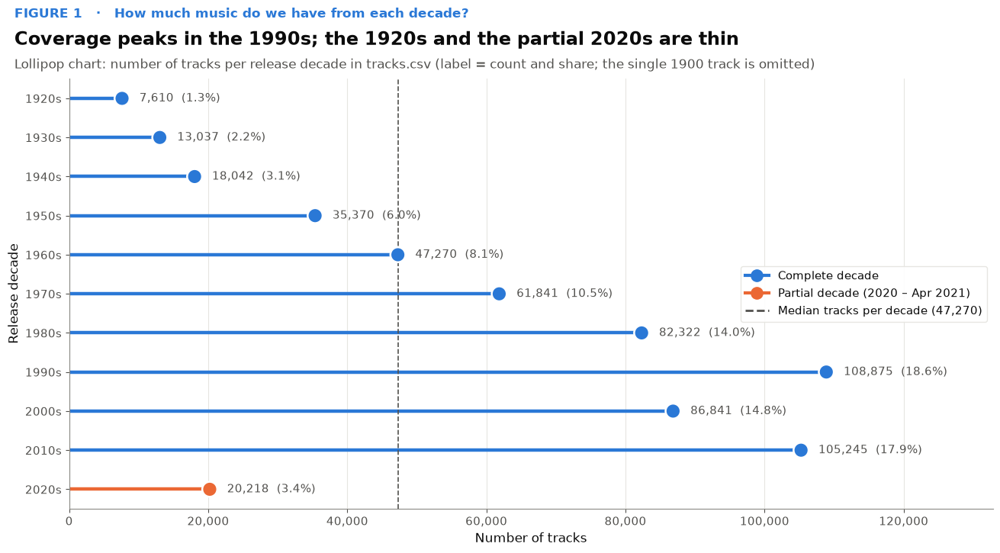

Saved -> figures/fig01_tracks_per_decade.png


In [13]:
fig, ax = plt.subplots(figsize=(13, 6.2), layout='constrained')
cov = coverage.drop(index='1900s')
yy = np.arange(len(cov))
colors = [CAT[1] if lbl == '2020s' else CAT[0] for lbl in cov.index]
ax.hlines(yy, 0, cov['tracks'], color=colors, lw=3.2)
ax.scatter(cov['tracks'], yy, color=colors, s=200, zorder=3, edgecolor='white', lw=1.8)
for y_, v, sh in zip(yy, cov['tracks'], cov['share (%)']):
    ax.text(v + 2500, y_, f'{v:,.0f}  ({sh:.1f}%)', va='center', fontsize=11, color=INK2)
ax.set_yticks(yy, cov.index)
ax.invert_yaxis()
ax.set_xlim(0, cov['tracks'].max() * 1.22)
ax.set_xlabel('Number of tracks')
ax.set_ylabel('Release decade')
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', visible=False)
ax.axvline(cov['tracks'].median(), color=INK2, lw=1.2, ls='--')
ax.legend(handles=[Line2D([], [], color=CAT[0], marker='o', lw=3, markersize=11, label='Complete decade'),
                   Line2D([], [], color=CAT[1], marker='o', lw=3, markersize=11, label='Partial decade (2020 – Apr 2021)'),
                   Line2D([], [], color=INK2, ls='--', label=f"Median tracks per decade ({cov['tracks'].median():,.0f})")], loc='center right', frameon=True, framealpha=0.95, edgecolor=GRID)
save_fig(fig, 1, 'tracks_per_decade', 'Coverage peaks in the 1990s; the 1920s and the partial 2020s are thin',
         'Lollipop chart: number of tracks per release decade in tracks.csv (label = count and share; the single 1900 track is omitted)',
         question='How much music do we have from each decade?')

**What Figure 1 shows.** Coverage is very uneven. The 1920s have 7,610 tracks (1.3 %) and the 1990s have 108,875 (18.6 %), about 14 times as many. The 2020s bar holds only 20,218 tracks because it covers 2020 plus January–April 2021 (the latest release date is 2021-04-16). These real counts differ from two common assumptions: the 1920s have about 7.6K tracks rather than 3K, and the busiest decade is the 1990s, not the 2010s (105K).

**Limitation flagged:** estimates for the 1920s–40s rest on far fewer tracks, and the 2020s are an early, partial snapshot. Conclusions about both ends of the timeline are treated as less certain throughout.

### 1.5 Story map

| Chapter | Question it answers | Variables used | Visual types used |
|---|---|---|---|
| **1. The Artists** | Who makes popular music, where do popular artists come from, and do they work alone or together? | followers, artist popularity, genres (incl. inferred country), n_artists, is_collab, debut_year, career_span, n_tracks | log histogram, treemap, rank–size (long-tail) plot, stacked area, line with confidence band, Lorenz curves, hexbin + LOWESS, bump chart, slope chart, network graph, lollipop, world choropleth map, heatmap |
| **2. The Sound and the Creation** | How did the way music is recorded and produced change its sound? | acousticness, instrumentalness, loudness, energy, liveness, duration | histogram + KDE grid, ridgeline, line with band (loudness war), correlation heatmap, paired line, violin, effect-size bubble chart, year × feature heatmap, density contours, PCA biplot and path, elbow/silhouette lines, radar, 100% stacked area |
| **3. The Tempo** | Did music get faster, more danceable, or more rhythmically uniform? | tempo, danceability, time_signature, key, mode, energy | histogram with peaks, donut + polar key wheel, small-multiple lines, strip plot, 2D density, 100% stacked bar, binned scatter + LOWESS, key × decade heatmap, 3D scatter, parallel coordinates, popularity sweet-spot heatmap, animated and connected scatter |
| **4. The Meaning** | How do songs feel and what do their titles say, and what do listeners reward? | valence, speechiness, explicit, mode, title words, popularity, mood_quadrant | distribution panel + stat tile, word bar chart, title-word small multiples, box plots, line with band, stacked area, annotated line, binned scatter, mood-map densities, alluvial chart, radar, word clouds, importance bars, SHAP beeswarm, genre heatmap |

Some basic forms (lines, heatmaps) appear in more than one chapter because the brief asks for them, but each chapter uses a different variant, and no two figures in a row share a chart type.

<a id="section-2"></a>
# Section 2: Data Cleaning

Every cleaning step below follows the same pattern: **(a) What I found → (b) Why it matters → (c) What I did → (d) Rows affected before/after.** Each step is also written to a running log, which becomes the **Cleaning Log** table at the end of this section.

In [14]:
CLEAN_LOG = []   # one dict per cleaning step -> summary table at the end

def log_step(step, issue, action, affected, why):
    """Record a cleaning decision for the Cleaning Log."""
    CLEAN_LOG.append({'Step': step, 'Issue': issue, 'Action': action,
                      'Rows/values affected': affected, 'Justification': why})

t = tracks_raw.copy()          # working copy; tracks_raw stays untouched
N_RAW = len(t)
print(f'Starting rows: {N_RAW:,}')

Starting rows: 586,672


### 2.1 Mixed-format release dates

**(a) What I found.** `release_date` uses three formats: full dates (`YYYY-MM-DD`), year-month (`YYYY-MM`) and year only (`YYYY`).

**(b) Why it matters.** Time is the main axis of this whole study. A naive `pd.to_datetime(errors="coerce")` infers one format from the first value and *silently* turns every value that does not match into `NaT`. That would drop more than a fifth of the data, and not at random, because older releases are much more likely to have year-only dates.

In [15]:
t['date_precision'] = t['release_date'].str.len().map({10: 'day', 7: 'month', 4: 'year'})
md_table(t['date_precision'].value_counts(dropna=False).to_frame('rows').T, floatfmt=',.0f')

# Demonstrate the trap: a naive conversion
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    naive = pd.to_datetime(t['release_date'], errors='coerce')
lost = naive.isna().groupby(t['date_precision']).sum()
print(f'Naive pd.to_datetime -> NaT for {naive.isna().sum():,} rows ({naive.isna().mean():.1%}).')
print('NaT by original precision:', lost.to_dict())
print('Share of year-only dates by decade (%):')
print((t['date_precision'].eq('year').groupby(yr_raw // 10 * 10).mean() * 100).round(1).to_dict())

|      |    day |   year |   month |
|:-----|-------:|-------:|--------:|
| rows | 448081 | 136489 |    2102 |

Naive pd.to_datetime -> NaT for 138,591 rows (23.6%).
NaT by original precision: {'day': 0, 'month': 2102, 'year': 136489}
Share of year-only dates by decade (%):
{1900: 0.0, 1920: 59.8, 1930: 54.9, 1940: 48.4, 1950: 42.4, 1960: 33.7, 1970: 31.8, 1980: 28.4, 1990: 23.1, 2000: 14.8, 2010: 3.8, 2020: 0.0}


**(c) What I did.** I took the year from the first four characters (`str[:4]`), which is valid in all three formats, and converted it to an integer. I kept a full `datetime` only where the date really is complete (day precision), and recorded the precision in its own column. I then ran three checks: no unparsable years, no full date that fails to parse, and the full date's year always equals the extracted year.

In [16]:
t['release_year'] = pd.to_numeric(t['release_date'].str[:4], errors='coerce')
t['release_date_full'] = pd.to_datetime(t['release_date'].where(t['date_precision'] == 'day'),
                                        format='%Y-%m-%d', errors='coerce')
checks = {
    'rows with an unparsable year': int(t['release_year'].isna().sum()),
    'day-precision dates that failed to parse': int((t['date_precision'].eq('day') & t['release_date_full'].isna()).sum()),
    'full dates whose year != extracted year': int((t['release_date_full'].notna() & (t['release_date_full'].dt.year != t['release_year'])).sum()),
}
print(checks)

# Sanity filter on the year range
print('\nTracks released before 1920:')
display(t.loc[t['release_year'] < 1920, ['name', 'artists', 'release_date', 'popularity', 'speechiness']])
before = len(t)
t = t[t['release_year'].between(1920, 2021)].copy()
t['release_year'] = t['release_year'].astype('int16')
t['decade'] = (t['release_year'] // 10 * 10).astype('int16')
print(f'Year filter 1920–2021: {before:,} -> {len(t):,} rows (removed {before - len(t)})')
log_step('2.1', 'release_date in 3 formats; naive parse loses ~138K dates', 'Year via str[:4]; full date only where complete; kept date_precision',
         f'{naive.isna().sum():,} dates rescued', 'Time is the main axis; NaT would silently drop most old music')
log_step('2.1', 'One track dated 1900, isolated 20 years before the next', 'Removed (keep 1920–2021)', f'{before - len(t)} row',
         'A single point cannot represent a decade')

{'rows with an unparsable year': 0, 'day-precision dates that failed to parse': 0, 'full dates whose year != extracted year': 0}

Tracks released before 1920:


,name,artists,release_date,popularity,speechiness
478627,Maldita sea la primera vez,['Los Pincheira del Sur'],1900-01-01,19,0.029


Year filter 1920–2021: 586,672 -> 586,671 rows (removed 1)


**(d) Rows affected.** Using the year from `str[:4]` recovers about 138,000 dates that a naive parse would have dropped, and all three checks return zero, so no valid year was lost. One track is dated **1900**, twenty years before any other track. It was removed because a single track cannot stand for a decade. **2021 is a partial year** (the data stops in April 2021). The year is kept, but every chart marks it, and conclusions about the 2020s are treated as tentative.

### 2.2 Missing values

**(a) What I found.** The null counts for every column of both files are shown below.

In [17]:
def null_table(df):
    """Null count and percentage for every column."""
    nt = pd.DataFrame({'nulls': df.isna().sum(), '% of rows': df.isna().mean() * 100})
    return nt.T

print('tracks.csv (raw)')
md_table(null_table(tracks_raw), floatfmt=',.3f')
print('artists.csv (raw)')
md_table(null_table(artists_raw), floatfmt=',.4f')
display(t.loc[t['name'].isna(), ['id', 'artists', 'release_date', 'popularity', 'danceability', 'energy']].head(5))

tracks.csv (raw)


|           |    id |   name |   popularity |   duration_ms |   explicit |   artists |   id_artists |   release_date |   danceability |   energy |   key |   loudness |   mode |   speechiness |   acousticness |   instrumentalness |   liveness |   valence |   tempo |   time_signature |
|:----------|------:|-------:|-------------:|--------------:|-----------:|----------:|-------------:|---------------:|---------------:|---------:|------:|-----------:|-------:|--------------:|---------------:|-------------------:|-----------:|----------:|--------:|-----------------:|
| nulls     | 0.000 | 71.000 |        0.000 |         0.000 |      0.000 |     0.000 |        0.000 |          0.000 |          0.000 |    0.000 | 0.000 |      0.000 |  0.000 |         0.000 |          0.000 |              0.000 |      0.000 |     0.000 |   0.000 |            0.000 |
| % of rows | 0.000 |  0.012 |        0.000 |         0.000 |      0.000 |     0.000 |        0.000 |          0.000 |          0.000 |    0.000 | 0.000 |      0.000 |  0.000 |         0.000 |          0.000 |              0.000 |      0.000 |     0.000 |   0.000 |            0.000 |

artists.csv (raw)


|           |     id |   followers |   genres |   name |   popularity |
|:----------|-------:|------------:|---------:|-------:|-------------:|
| nulls     | 0.0000 |     11.0000 |   0.0000 | 3.0000 |       0.0000 |
| % of rows | 0.0000 |      0.0009 |   0.0000 | 0.0003 |       0.0000 |

,id,artists,release_date,popularity,danceability,energy
226336,4iH7negBYMfj2z0wDNmgdx,[''],1994-01-01,28,0.512,0.578
510975,04d5kbLvSAIBt3pGcljdhC,[''],1922-04-01,0,0.426,0.285
510976,05tRkgyxVdwMePGqOXMDYU,[''],1922-04-01,0,0.344,0.186
510978,0YAMRgAQH6tkTh4sWNXr8L,[''],1922-04-01,0,0.316,0.257
510979,1K6MQQxmFpPb66ZnaiIpHX,[''],1922-04-01,0,0.558,0.283


**(b) Why it matters.** Missing values are rare here: 71 track names, 3 artist names and 11 follower counts. Even so, each needs a deliberate decision. A track without a name cannot be checked for re-releases in step 2.3, which compares tracks by `name + artists`.

**(c) What I did.**
* **`tracks.name` (71 nulls): dropped.** These rows have audio features, so dropping them does not damage the audio analysis. They are 0.01 % of the data, cannot be de-duplicated, and cannot be identified in any chart. Imputing a name would be inventing data.
* **`artists.name` (3 nulls): kept and left as missing.** The join uses the artist **id**, not the name, so these artists still join correctly.
* **`artists.followers` (11 nulls): kept as NaN, not imputed.** Eleven artists out of 1.16M cannot affect any result, and filling in a follower count would be fabricating it. Rows with missing followers are simply left out of follower-based plots.

In [18]:
before = len(t)
t = t[t['name'].notna()].copy()
print(f'Drop unnamed tracks: {before:,} -> {len(t):,} rows (removed {before - len(t)})')
log_step('2.2', 'tracks.name null', 'Dropped', f'{before - len(t)} rows', '0.01 %; cannot be de-duplicated or labelled; audio analysis unaffected')
log_step('2.2', 'artists.name null (3) / followers null (11)', 'Kept as missing (no imputation)', '3 + 11 artist rows', 'Join uses id; imputing counts would invent data')

Drop unnamed tracks: 586,671 -> 586,600 rows (removed 71)


**(d) Rows affected.** 71 rows were removed from the track table. Nothing was removed from the artist table.

### 2.3 Duplicates and re-releases

**(a) What I found.** There are no exact duplicate rows and no duplicate track IDs. However, many rows share the same **`name` + `artists`**. These are the same song re-released as a remaster, on a compilation, as a deluxe edition or as a regional release.

In [19]:
print(f"Exact duplicate rows: {t.duplicated().sum():,} | duplicate ids: {t['id'].duplicated().sum():,}")
dup_any = t.duplicated(['name', 'artists'], keep=False)
dup_extra = t.duplicated(['name', 'artists'], keep='first')
g = (t[dup_any].groupby(['name', 'artists'])
       .agg(versions=('id', 'size'), first_year=('release_year', 'min'), last_year=('release_year', 'max'),
            max_popularity=('popularity', 'max')))
g['year_span'] = g['last_year'] - g['first_year']
print(f'Rows in a duplicated name+artists group: {dup_any.sum():,} in {len(g):,} groups '
      f'-> {dup_extra.sum():,} extra copies ({dup_extra.mean():.1%} of rows)')
print(f'Groups whose versions span more than one release year: {(g.year_span > 0).mean():.1%}; '
      f'median span among those: {g.loc[g.year_span > 0, "year_span"].median():.0f} years')
display(g.sort_values('versions', ascending=False).head(8))

Exact duplicate rows: 0 | duplicate ids: 0
Rows in a duplicated name+artists group: 106,866 in 46,874 groups -> 59,992 extra copies (10.2% of rows)
Groups whose versions span more than one release year: 55.8%; median span among those: 7 years


,,versions,first_year,last_year,max_popularity,year_span
name,artists,,,,,
Year 3000,['Busted'],54,2002,2021,65,19
Hold On,['Justin Bieber'],47,2021,2021,92,0
Anyone,['Justin Bieber'],44,2021,2021,90,0
Azul,['J Balvin'],42,2020,2021,81,1
No Es Justo,"['J Balvin', 'Zion & Lennox']",42,2018,2021,69,3
King,['Years & Years'],40,2015,2021,70,6
Morado,['J Balvin'],39,2020,2021,75,1
Negro,['J Balvin'],36,2020,2021,71,1


**(b) Why it matters.** A song released in 1965 and re-released as a remaster in 2009 shows up twice: once in the 1960s and once in the 2000s. The second copy puts the 1960s sound into the 2000s and blurs the very trends we want to measure. Heavily re-released catalogues (big classical, jazz and pop names) would also be over-weighted.

**(c) What I did.** I kept **one version per `name + artists`**: the **earliest release**, which is closest to when the song was first recorded. When there is a tie, I kept the most popular version. Because this is a judgement call, I compared the main results with and without de-duplication. For six key features, the table below compares decade means and the Spearman correlation with release year.

In [20]:
t_nodedup = t                                   # keep a reference for the comparison
t = (t.sort_values(['release_year', 'popularity'], ascending=[True, False])
       .drop_duplicates(['name', 'artists'], keep='first')
       .sort_index().copy())
print(f'De-duplicate on name + artists: {len(t_nodedup):,} -> {len(t):,} rows (removed {len(t_nodedup) - len(t):,})')
log_step('2.3', 'Same name + artists released several times (remasters, compilations)', 'Kept earliest release (tie: most popular)',
         f'{len(t_nodedup) - len(t):,} rows removed', 'Re-releases would copy old sounds into later decades')

CMP = ['danceability', 'energy', 'acousticness', 'valence', 'loudness', 'tempo']
def year_rhos(df):
    return pd.Series({f: stats.spearmanr(df['release_year'], df[f]).statistic for f in CMP})

robust = pd.DataFrame({'rho with year (no dedup)': year_rhos(t_nodedup), 'rho with year (dedup)': year_rhos(t)})
robust['difference'] = robust.iloc[:, 1] - robust.iloc[:, 0]
dm_diff = (t.groupby('decade')[CMP].mean() - t_nodedup.groupby('decade')[CMP].mean()) / t_nodedup[CMP].std()
robust['max |decade-mean shift| (in SDs)'] = dm_diff.abs().max()
md_table(robust)
del t_nodedup

De-duplicate on name + artists: 586,600 -> 526,608 rows (removed 59,992)


|              |   rho with year (no dedup) |   rho with year (dedup) |   difference |   max |decade-mean shift| (in SDs) |
|:-------------|---------------------------:|------------------------:|-------------:|-----------------------------------:|
| danceability |                      0.240 |                   0.237 |       -0.003 |                              0.033 |
| energy       |                      0.438 |                   0.433 |       -0.005 |                              0.035 |
| acousticness |                     -0.488 |                  -0.484 |        0.004 |                              0.028 |
| valence      |                     -0.043 |                  -0.045 |       -0.002 |                              0.050 |
| loudness     |                      0.496 |                   0.489 |       -0.007 |                              0.057 |
| tempo        |                      0.124 |                   0.123 |       -0.001 |                              0.018 |

**(d) Rows affected.** De-duplication removed 59,992 extra copies (586,600 → 526,608 rows, 10.2 %). In 56 % of the duplicated groups the versions span more than one release year (median gap 7 years), which is exactly the re-release pattern that would blur trends. The comparison shows that **de-duplication does not change the story**: every Spearman correlation with year moves by less than 0.01, and no decade mean shifts by more than 0.06 standard deviations.

### 2.4 Parsing list-like strings (artists, id_artists, genres)

**(a) What I found.** `artists`, `id_artists` and `genres` are stored as text that *looks like* a Python list, such as `"['Dean Martin', 'Frank Sinatra']"`.

**(b) Why it matters.** As plain text, we cannot pick out the first artist or count the artists. A naive `str.split(',')` would also break names that contain commas or quotes (for example `"Guns N' Roses"`).

**(c) What I did.** I parsed each value with `ast.literal_eval`. This safely evaluates *only* Python literals and never runs code. It sits inside a `try/except`, so a malformed value becomes an empty list and gets counted instead of crashing the notebook. **The join uses the primary (first-listed) artist.** Spotify lists the main performer first, and joining on every artist would duplicate a track once per collaborator, giving a collaboration such as "Artist A feat. B, C" three times the weight of a solo track.

In [21]:
def safe_list(s):
    """Parse a list-like string such as "['a', 'b']" into a Python list; [] if empty or malformed."""
    if not isinstance(s, str) or s == '[]':
        return []
    try:
        v = ast.literal_eval(s)
        return list(v) if isinstance(v, (list, tuple)) else [v]
    except (ValueError, SyntaxError):
        return []

for col in ['artists', 'id_artists']:
    parsed = t[col].map(safe_list)
    failed = (parsed.str.len() == 0) & t[col].ne('[]')
    print(f'{col:<11} parsed; malformed values -> []: {failed.sum():,}')
    t[col] = parsed

t['n_artists'] = t['id_artists'].str.len().astype('int16')
t['primary_artist_id'] = t['id_artists'].str[0]
t['primary_artist'] = t['artists'].str[0]
mismatch = (t['artists'].str.len() != t['id_artists'].str.len()).sum()
print(f'Tracks with more than one artist: {(t.n_artists > 1).sum():,} ({(t.n_artists > 1).mean():.1%}); '
      f'name/id list length mismatches: {mismatch:,}')
md_table(t['n_artists'].clip(upper=5).value_counts().sort_index().rename(index={5: '5+'}).to_frame('tracks').T, floatfmt=',.0f')
log_step('2.4', 'artists / id_artists / genres stored as list-like strings', 'ast.literal_eval with try/except; primary artist = first ID',
         f'{(t.n_artists > 1).sum():,} multi-artist tracks', 'Safe parsing; one artist per track avoids double counting')

artists     parsed; malformed values -> []: 0
id_artists  parsed; malformed values -> []: 0
Tracks with more than one artist: 96,940 (18.4%); name/id list length mismatches: 0


|        |      1 |     2 |     3 |    4 |   5+ |
|:-------|-------:|------:|------:|-----:|-----:|
| tracks | 429668 | 66063 | 19040 | 6074 | 5763 |

**(d) Rows affected.** No rows were removed. Every value parsed. About one track in six credits more than one artist, and each of those is linked to artist data through its first-listed artist.

### 2.5 Genres: mostly empty, so treat them as a subset

**(a) What I found.** Genre tags live in the artist table, and most artists have none.

In [22]:
a = artists_raw.copy()
a['genres'] = a['genres'].map(safe_list)
has_genre = a['genres'].str.len() > 0
print(f'Artists with an empty genre list: {(~has_genre).sum():,} of {len(a):,} ({(~has_genre).mean():.1%})')
print(f'Distinct genre tags: {a["genres"].explode().nunique():,}')
print('Median followers, with genre vs without:',
      a.loc[has_genre, 'followers'].median(), 'vs', a.loc[~has_genre, 'followers'].median())

Artists with an empty genre list: 856,500 of 1,162,095 (73.7%)
Distinct genre tags: 5,366
Median followers, with genre vs without: 847.0 vs 27.0


**(b) Why it matters.** Spotify assigns genres mainly to artists who have enough listeners. Genre is therefore missing *not at random*: it is biased toward established, more-followed artists, as the median follower counts above show. There are also about 5,000 distinct tags (for example "deep latin alternative" and "canadian contemporary r&b"), which is far too many to plot.

**(c) What I did.** I mapped every tag to one of **10 broad families** (Pop, Rock, Hip hop/Rap, Electronic/Dance, R&B/Soul, Jazz, Classical, Country/Folk, Metal, Latin), plus **Other**, using keyword rules applied in priority order. The order handles hybrids: "pop rap" becomes Hip hop/Rap and "country rock" becomes Country/Folk. Each artist then gets the family that most of their tags fall into, and ties are broken by the priority order. Genre is used **only** for tracks whose primary artist has at least one tag. Every genre chart says so.

In [23]:
# Keyword rules, checked in priority order: the first family whose keyword appears in the tag wins.
FAMILY_RULES = [
    ('Hip hop/Rap',      ['hip hop', 'rap', 'trap', 'drill', 'grime']),
    ('Metal',            ['metal', 'deathcore', 'grindcore']),
    ('Classical',        ['classical', 'orchestra', 'baroque', 'opera', 'romantic era', 'early music', 'chamber',
                          'choral', 'compositional', 'symphon', 'impressionism']),
    ('Country/Folk',     ['country', 'bluegrass', 'americana', 'honky tonk', 'western swing', 'folk', 'singer-songwriter', 'celtic']),
    ('Jazz',             ['jazz', 'swing', 'bebop', 'big band', 'dixieland', 'stride', 'ragtime']),
    ('R&B/Soul',         ['r&b', 'soul', 'funk', 'motown', 'doo-wop', 'quiet storm', 'new jack swing', 'gospel']),
    ('Latin',            ['latin', 'reggaeton', 'salsa', 'bachata', 'cumbia', 'mexican', 'tango', 'bolero', 'ranchera',
                          'banda', 'sertanejo', 'mpb', 'bossa nova', 'samba', 'flamenco', 'corrido', 'norteno',
                          'mariachi', 'merengue', 'vallenato', 'forro', 'pagode', 'axe']),
    ('Electronic/Dance', ['electro', 'house', 'techno', 'edm', 'trance', 'dubstep', 'drum and bass', 'disco',
                          'eurodance', 'big room', 'electronica', 'ambient', 'downtempo', 'hardstyle']),
    ('Rock',             ['rock', 'punk', 'grunge', 'new wave', 'emo', 'shoegaze', 'post-hardcore', 'british invasion']),
    ('Pop',              ['pop', 'boy band', 'adult standards', 'girl group', 'idol']),
]
FAMILIES = [f for f, _ in FAMILY_RULES]
FAM_PRIORITY = {f: i for i, f in enumerate(FAMILIES)} | {'Other': 99}

def map_genre(tag):
    for fam, kws in FAMILY_RULES:
        if any(k in tag for k in kws):
            return fam
    return 'Other'

genre_map = {g: map_genre(g) for g in a['genres'].explode().dropna().unique()}

# One family per artist: majority of tags; ignore 'Other' if any real family exists; tie -> priority order
ex = a[['id', 'genres']].explode('genres').dropna(subset=['genres'])
ex['family'] = ex['genres'].map(genre_map)
cnt = ex.groupby(['id', 'family']).size().rename('n').reset_index()
cnt['is_other'] = cnt['family'].eq('Other')
cnt['prio'] = cnt['family'].map(FAM_PRIORITY)
fam = cnt.sort_values(['id', 'is_other', 'n', 'prio'], ascending=[True, True, False, True]).drop_duplicates('id')
a = a.merge(fam[['id', 'family']].rename(columns={'family': 'genre_family'}), on='id', how='left')

tag_counts = pd.Series(genre_map).value_counts()
examples = pd.Series(genre_map).groupby(pd.Series(genre_map)).apply(lambda s: ', '.join(s.index[:4]))
md_table(pd.DataFrame({'distinct tags': tag_counts, 'example tags': examples}).sort_values('distinct tags', ascending=False), floatfmt=',.0f')
log_step('2.5', f'{(~has_genre).mean():.0%} of artists have no genre tags; ~5K distinct tags', 'Mapped tags to 10 families + Other (majority vote); genre used only where available',
         f'{(~has_genre).sum():,} artists without genre', 'Readable genre mix; subset biased to established artists')
print('Artists per family (artists with genres only):')
print(a['genre_family'].value_counts().to_dict())

|                  |   distinct tags | example tags                                                                        |
|:-----------------|----------------:|:------------------------------------------------------------------------------------|
| Other            |            2329 | carnaval cadiz, harp, british choir, children's story                               |
| Rock             |             567 | indian rock, rock nacional, argentine rock, italian progressive rock                |
| Hip hop/Rap      |             430 | punjabi hip hop, nigerian hip hop, desi hip hop, pinoy hip hop                      |
| Pop              |             399 | classic persian pop, desi pop, punjabi pop, afropop                                 |
| Metal            |             372 | argentine metal, latin metal, argentine heavy metal, spanish metal                  |
| Electronic/Dance |             343 | russian electronic, swedish electropop, house argentino, israeli techno             |
| Country/Folk     |             281 | indian folk, indian singer-songwriter, folklore argentino, folklore nuevo argentino |
| Classical        |             198 | classical harp, classical contralto, latin classical, austrian classical piano      |
| Latin            |             164 | vintage tango, blues latinoamericano, tango, cumbia santafesina                     |
| Jazz             |             148 | argentine jazz, jazz trumpet, austrian jazz, electro swing                          |
| R&B/Soul         |             135 | pinoy r&b, haitian gospel, vapor soul, german r&b                                   |

Artists per family (artists with genres only):
{'Other': 111458, 'Rock': 34796, 'Pop': 29554, 'Hip hop/Rap': 27928, 'Electronic/Dance': 24063, 'Country/Folk': 17455, 'Metal': 15706, 'Classical': 12475, 'Latin': 12002, 'Jazz': 10144, 'R&B/Soul': 10014}


**(d) Rows affected.** 856,500 of 1,162,095 artists (73.7 %) have no genre tags. Of the artists with tags, about a third have only tags that fit none of the 10 families (regional or niche tags such as "carnaval cadiz" or "children's story"), and these are labelled *Other*. The mapping is a deliberate simplification. For example, "adult standards" (Sinatra-style crooners) is mapped to Pop, and folk is merged with country into Country/Folk.

### 2.6 Joining tracks to artists

**(a, b) What and why.** Followers, artist popularity and genre family all live in the artist table. I joined on `primary_artist_id = artists.id` with a **left join**, so no track is lost if its artist is missing. `validate="many_to_one"` makes pandas raise an error if artist IDs are not unique, which would otherwise duplicate tracks without warning.

In [24]:
print(f"Artist ids unique: {a['id'].is_unique}")
art = a[['id', 'name', 'followers', 'popularity', 'genres', 'genre_family']].rename(columns={
    'id': 'primary_artist_id', 'name': 'artist_name', 'followers': 'artist_followers',
    'popularity': 'artist_popularity', 'genres': 'artist_genres', 'genre_family': 'primary_genre_family'})
before = len(t)
t = t.merge(art, on='primary_artist_id', how='left', validate='many_to_one', indicator=True)
assert len(t) == before, 'join changed the row count'
match = t['_merge'].eq('both')
print(f'Matched to an artist: {match.sum():,} of {len(t):,} ({match.mean():.2%}); unmatched: {(~match).sum():,}')
print(f'Tracks whose primary artist has a genre family: {t.primary_genre_family.notna().sum():,} '
      f'({t.primary_genre_family.notna().mean():.1%})')
t = t.drop(columns='_merge')
log_step('2.6', 'Artist info in a separate table', 'Left join on primary artist id (many-to-one validated)',
         f'{(~match).sum():,} tracks unmatched', 'Keep every track; unmatched simply lack artist fields')

Artist ids unique: True
Matched to an artist: 515,112 of 526,608 (97.82%); unmatched: 11,496
Tracks whose primary artist has a genre family: 468,472 (89.0%)


**(c, d) Result.** 97.8 % of tracks (515,112) match an artist. The other 11,496 have a primary-artist ID that is missing from `artists.csv`, so their artist fields are left empty. 89.0 % of tracks have a genre family (including *Other*), far more than the 26 % of *artists* with tags, because the artists who appear in `tracks.csv` are mostly the better-known ones.

### 2.7 Artist-level fields derived from tracks

**(a) What I found.** `artists.csv` has followers, popularity and genres, but **no dates at all**. Chapter 1 needs to know *when* each artist was active.

**(b) Why it matters.** Without dates we cannot ask how many new artists appeared each year, or how long careers last.

**(c) What I did.** I derived the dates from the tracks each artist released as primary artist:
* `debut_year` = earliest `release_year` among the artist's tracks, and `debut_decade` = its decade
* `last_year` = latest `release_year`, and `career_span` = `last_year − debut_year`
* `n_tracks` = number of (de-duplicated) tracks

I also recorded the share of each artist's tracks that are spoken word, so audiobook narrators can be left out of the artist story. **Caveat:** `debut_year` is the first year *in this dataset*, not necessarily the artist's real debut, because back catalogues are often uploaded as later compilations.

In [25]:
t['_spoken'] = t['speechiness'] > 0.66
artist_tbl = (t.groupby('primary_artist_id')
                .agg(artist=('primary_artist', lambda x: str(x.iloc[0]).strip()), n_tracks=('id', 'size'),
                     debut_year=('release_year', 'min'), last_year=('release_year', 'max'),
                     followers=('artist_followers', 'first'), artist_popularity=('artist_popularity', 'first'),
                     genre_family=('primary_genre_family', 'first'), spoken_share=('_spoken', 'mean')))
artist_tbl['career_span'] = artist_tbl['last_year'] - artist_tbl['debut_year']
artist_tbl['debut_decade'] = (artist_tbl['debut_year'] // 10 * 10).astype(int)
t = t.drop(columns='_spoken').merge(artist_tbl[['debut_year']].rename(columns={'debut_year': 'artist_debut_year'}),
                                     left_on='primary_artist_id', right_index=True, how='left')
print(f'{len(artist_tbl):,} primary artists. Median tracks per artist: {artist_tbl.n_tracks.median():.0f}; '
      f'median career span: {artist_tbl.career_span.median():.0f} years; artists with a single track: {(artist_tbl.n_tracks == 1).mean():.1%}')
md_table(artist_tbl[['n_tracks', 'debut_year', 'career_span', 'followers']].describe().T, floatfmt=',.1f')
log_step('2.7', 'artists.csv has no dates', 'Derived debut_year, last_year, career_span, n_tracks, debut_decade from tracks',
         f'{len(artist_tbl):,} artists', 'Chapter 1 needs artist eras; debut = first year in this dataset')

71,492 primary artists. Median tracks per artist: 2; median career span: 0 years; artists with a single track: 44.1%


|             |    count |      mean |         std |     min |     25% |     50% |      75% |          max |
|:------------|---------:|----------:|------------:|--------:|--------:|--------:|---------:|-------------:|
| n_tracks    | 71,492.0 |       7.4 |        31.8 |     1.0 |     1.0 |     2.0 |      5.0 |      3,856.0 |
| debut_year  | 71,492.0 |   1,995.1 |        22.2 | 1,922.0 | 1,984.0 | 2,001.0 |  2,013.0 |      2,021.0 |
| career_span | 71,492.0 |       4.6 |         9.9 |     0.0 |     0.0 |     0.0 |      4.0 |         94.0 |
| followers   | 64,483.0 | 157,437.2 | 1,067,691.9 |     0.0 |   916.0 | 7,716.0 | 48,379.5 | 78,900,234.0 |

**(d) Result.** No rows were removed. Every primary artist now has a derived debut year, career span and track count.

### 2.8 Invalid and suspicious audio values

**(a) What I found.** The table below counts every suspicious condition.

In [26]:
issues = {
    'tempo = 0 BPM (failed analysis)': t['tempo'].eq(0),
    'time_signature = 0 (failed analysis)': t['time_signature'].eq(0),
    'loudness > 0 dB (above digital full scale)': t['loudness'].gt(0),
    'loudness < -50 dB (near silence)': t['loudness'].lt(-50),
    'duration < 30 s': t['duration_ms'].lt(30_000),
    'duration > 20 min': t['duration_ms'].gt(1_200_000),
    'speechiness > 0.66 (spoken word)': t['speechiness'].gt(0.66),
    'popularity = 0': t['popularity'].eq(0),
}
issue_tbl = pd.DataFrame({'rows': {k: int(v.sum()) for k, v in issues.items()}})
issue_tbl['% of tracks'] = issue_tbl['rows'] / len(t) * 100
md_table(issue_tbl, floatfmt=',.2f')

|                                            |      rows |   % of tracks |
|:-------------------------------------------|----------:|--------------:|
| tempo = 0 BPM (failed analysis)            |    301.00 |          0.06 |
| time_signature = 0 (failed analysis)       |    309.00 |          0.06 |
| loudness > 0 dB (above digital full scale) |    202.00 |          0.04 |
| loudness < -50 dB (near silence)           |     22.00 |          0.00 |
| duration < 30 s                            |    191.00 |          0.04 |
| duration > 20 min                          |  1,024.00 |          0.19 |
| speechiness > 0.66 (spoken word)           | 22,430.00 |          4.26 |
| popularity = 0                             | 39,639.00 |          7.53 |

In [27]:
# What do the spoken-word and extreme-length items look like?
sw = t['speechiness'].gt(0.66)
print('Highest-speechiness examples:')
display(t.loc[sw, ['name', 'primary_artist', 'release_year', 'speechiness', 'duration_ms']].sample(6, random_state=SEED))
print('Share of tracks flagged as spoken word, by decade (%):')
md_table((sw.groupby(t['decade']).mean() * 100).rename(index=lambda d: f'{d}s').to_frame('% spoken word').T, floatfmt='.1f')
print('Longest items:')
display(t.nlargest(4, 'duration_ms')[['name', 'primary_artist', 'release_year', 'duration_ms', 'speechiness']])

Highest-speechiness examples:


,name,primary_artist,release_year,speechiness,duration_ms
169355,A State of Trance Year Mix 2018 - Intro: Licen...,Armin van Buuren,2018,0.894,154107
233485,015 - und der rasende Löwe - Teil 26,Die drei ???,1980,0.942,64840
143018,Married 19 Years (Jfl 2017),Various Artists,2019,0.803,118956
132433,005 - Das Phantom auf dem Feuerstuhl - Teil 08,TKKG Retro-Archiv,1981,0.862,94160
454406,A város fölött,Zsuzsa Koncz,1989,0.714,239907
436335,S' gaat wiiter mit Problem mit em Sattel,Globi,1998,0.946,60373


Share of tracks flagged as spoken word, by decade (%):


|               |   1920s |   1930s |   1940s |   1950s |   1960s |   1970s |   1980s |   1990s |   2000s |   2010s |   2020s |
|:--------------|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| % spoken word |    26.9 |    14.2 |     2.2 |     4.8 |     2.4 |     5.3 |     9.8 |     4.4 |     1.2 |     0.3 |     0.4 |

Longest items:


,name,primary_artist,release_year,duration_ms,speechiness
291550,โครงสร้างแห่งสิ่งที่เรียกว่าชีวิต,ท่านพุทธทาส,1979,5621218,0.775
404146,Brown Noise - 90 Minutes,Sound Dreamer,2013,5403500,0.000
119063,New Year's Eve 2015 Party Hits - Full DJ Party...,Various Artists,2014,5042185,0.063
526405,Surah Al-Araf,Sheikh Mishary Rashid Alfasay,2010,4995083,0.030


**(b) Why it matters, and (c) what I did.**

| Issue | Interpretation | Action |
|---|---|---|
| `tempo = 0`, `time_signature = 0` | The analysis failed; 0 BPM is not a real tempo | Set to **NaN**, so they drop out of tempo statistics but the rest of the row stays usable |
| `loudness > 0 dB` | A track's *average* loudness cannot exceed digital full scale; this is a measurement artifact | Set to **NaN** |
| `loudness < −50 dB` | Near-silent tracks (sound effects, silence, very quiet field recordings). Rare but physically possible | Kept and flagged; extremes are winsorized in 3A |
| Duration < 30 s or > 20 min | Skits, intros, sound effects, audiobooks, lectures and DJ mixes are not "songs" | Flagged `is_extreme_length`; a music-length window is applied in 3A |
| `speechiness > 0.66` | Spotify's own threshold for "probably made entirely of spoken words": audiobooks, poetry, comedy | Flagged **`is_spoken_word`**. The question is about the sound of *music*, so these are **excluded from the analysis copy** (but kept in the clean CSV) |
| `popularity = 0` | "Not streamed recently enough to register", **not** "bad". It is concentrated in old and obscure catalogue | Kept and flagged; it is part of the real popularity distribution, and Section 3 explains it |

The spoken-word flag matters a great deal for the early decades. The decade table above shows that a large share of the 1920s–1930s "tracks" are actually spoken audio: audiobook chapters (Polish, German, English and Russian novels by authors such as Tadeusz Dołęga-Mostowicz, Georgette Heyer and Arthur Conan Doyle) that Spotify dates by the book's original publication year. A second bump in the 1980s is German children's audio dramas (*TKKG*, *Benjamin Blümchen*, *Die drei ???*). Leaving them in would make early "music" look far more speech-heavy and less danceable than it was.

In [28]:
for col in ['tempo', 'time_signature']:
    n = int(t[col].eq(0).sum())
    t[col] = t[col].where(t[col] != 0)                   # 0 -> NaN
    log_step('2.8', f'{col} = 0 (failed analysis)', 'Set to NaN', f'{n:,} values', 'Not a real measurement')
n = int(t['loudness'].gt(0).sum())
t['loudness'] = t['loudness'].where(t['loudness'] <= 0)
log_step('2.8', 'loudness > 0 dB', 'Set to NaN', f'{n:,} values', 'Average loudness cannot exceed 0 dBFS')

t['is_spoken_word'] = t['speechiness'] > 0.66
t['is_extreme_length'] = ~t['duration_ms'].between(30_000, 1_200_000)
t['is_zero_popularity'] = t['popularity'].eq(0)
log_step('2.8', 'loudness < -50 dB', 'Kept, winsorized in 3A', f"{int(issues['loudness < -50 dB (near silence)'].sum())} values", 'Rare but physically possible')
log_step('2.8', 'duration < 30 s or > 20 min', 'Flag is_extreme_length; music-length window in 3A', f"{int(t['is_extreme_length'].sum()):,} rows", 'Skits, audiobooks and mixes are not songs')
log_step('2.8', 'speechiness > 0.66', 'Flag is_spoken_word; excluded from analysis copy', f"{int(t['is_spoken_word'].sum()):,} rows", 'Question is about the sound of music')
log_step('2.8', 'popularity = 0', 'Kept; flag is_zero_popularity', f"{int(t['is_zero_popularity'].sum()):,} rows", 'Means "not streamed recently", not missing')
print(t[['tempo', 'time_signature', 'loudness']].isna().sum().to_dict())

{'tempo': 301, 'time_signature': 309, 'loudness': 202}


**(d) Rows affected.** No rows are deleted in this step. Impossible values become NaN, and the other conditions become flags. The rows themselves are excluded only in the analysis copy (Section 3A), so the clean file still contains everything.

### 2.9 Data types and memory

**(a, b) What and why.** `explicit`, `mode` and `key` are categories stored as integers. Giving them readable labels (Minor/Major, Clean/Explicit, C … B) stops anyone from averaging them by accident and makes the charts self-explanatory. Downcasting `float64` to `float32` and integers to the smallest type that fits roughly halves the memory needed for the numeric columns.

**(c) What I did.**

In [29]:
mem_before = t.memory_usage(deep=True).sum() / 1e6
t['explicit'] = pd.Categorical(t['explicit'].map({0: 'Clean', 1: 'Explicit'}), categories=['Clean', 'Explicit'])
t['mode'] = pd.Categorical(t['mode'].map({0: 'Minor', 1: 'Major'}), categories=['Minor', 'Major'])
t['key'] = pd.Categorical(t['key'].map(dict(enumerate(KEY_NAMES))), categories=KEY_NAMES)
for c in AUDIO:
    t[c] = t[c].astype('float32')
t['time_signature'] = t['time_signature'].astype('Int8')       # nullable integer (NaN allowed)
t['popularity'] = t['popularity'].astype('int8')
t['duration_ms'] = t['duration_ms'].astype('int32')
t['artist_popularity'] = t['artist_popularity'].astype('float32')
t['artist_followers'] = t['artist_followers'].astype('float64')
mem_after = t.memory_usage(deep=True).sum() / 1e6
print(f'Memory: {mem_before:,.0f} MB -> {mem_after:,.0f} MB')
log_step('2.9', 'Categories stored as ints; 64-bit numerics', 'Labelled categoricals; float32/int8/int16/int32',
         f'{mem_before:,.0f} -> {mem_after:,.0f} MB', 'Prevents meaningless means; saves memory')

Memory: 485 MB -> 444 MB


**(d) Result.** The memory saving shown above comes mostly from the numeric columns. The parsed artist lists are Python objects and still dominate the total memory.

### 2.10 Derived features

| New column | Definition | Why |
|---|---|---|
| `release_year`, `decade` | from step 2.1 | Time axis and grouping |
| `decade_label` | `'1920s'` … `'2020s'`, ordered categorical | Correct order in charts |
| `duration_min` | `duration_ms / 60000` | Minutes are easier to read |
| `popularity_tier` | Low 0–19, Mid 20–49, High 50–100 | Readable ordinal bands |
| `primary_artist`, `n_artists` | from step 2.4 | Artist analysis |
| `primary_genre_family` | from steps 2.5–2.6 | Genre mix |
| `is_collab` | `n_artists > 1` | Collaboration analysis (Chapter 1) |
| `title_word_count` | number of words in the track title | Title analysis (Chapter 4) |
| `mood_quadrant` | energy and valence cut at 0.5: Happy/Energetic, Angry/Intense, Peaceful/Content, Sad/Melancholy | Mood analysis (Chapter 4) |

In [30]:
t['decade_label'] = pd.Categorical(t['decade'].astype(str) + 's', categories=DECADE_LABELS, ordered=True)
t['duration_min'] = (t['duration_ms'] / 60_000).astype('float32')
t['popularity_tier'] = pd.cut(t['popularity'], bins=[-1, 19, 49, 100], labels=['Low (0–19)', 'Mid (20–49)', 'High (50–100)'])
t['is_collab'] = t['n_artists'] > 1
t['title_word_count'] = t['name'].astype(str).str.count(r'\w+').astype('int16')
hi_e, hi_v = t['energy'] >= 0.5, t['valence'] >= 0.5
t['mood_quadrant'] = pd.Categorical(np.select([hi_e & hi_v, hi_e & ~hi_v, ~hi_e & hi_v], ['Happy/Energetic', 'Angry/Intense', 'Peaceful/Content'],
                                              'Sad/Melancholy'), categories=MOODS)
md_table(t['popularity_tier'].value_counts().sort_index().to_frame('tracks').T, floatfmt=',.0f')
md_table((t['mood_quadrant'].value_counts(normalize=True) * 100).reindex(MOODS).to_frame('% of tracks').T, floatfmt='.1f')
print(f"Collaborations: {t['is_collab'].mean():.1%} of tracks; median title length: {t['title_word_count'].median():.0f} words")
log_step('2.10', 'Analysis needs year/decade/minutes/tiers/genre/collab/title/mood', 'Derived 10 columns', 'all rows', 'Readable units and groupings for each chapter')

|        |   Low (0–19) |   Mid (20–49) |   High (50–100) |
|:-------|-------------:|--------------:|----------------:|
| tracks |       189055 |        270560 |           66993 |

|             |   Sad/Melancholy |   Peaceful/Content |   Happy/Energetic |   Angry/Intense |
|:------------|-----------------:|-------------------:|------------------:|----------------:|
| % of tracks |             25.5 |               18.5 |              39.4 |            16.6 |

Collaborations: 18.4% of tracks; median title length: 3 words


### 2.11 Final validation and export

The clean table keeps *every* remaining track, including spoken word and extreme lengths, which are flagged rather than deleted. It is written to `data/tracks_clean.csv`. Parsed lists are written back in their original `['a', 'b']` text form, so the file can be read the same way as the raw data.

In [31]:
CLEAN_COLS = ['id', 'name', 'primary_artist', 'artists', 'primary_artist_id', 'id_artists', 'n_artists',
              'release_date', 'release_date_full', 'date_precision', 'release_year', 'decade', 'decade_label',
              'popularity', 'popularity_tier', 'duration_ms', 'duration_min', 'explicit',
              'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'liveness',
              'loudness', 'tempo', 'key', 'mode', 'time_signature',
              'artist_name', 'artist_followers', 'artist_popularity', 'artist_genres', 'primary_genre_family', 'artist_debut_year',
              'is_collab', 'title_word_count', 'mood_quadrant', 'is_spoken_word', 'is_extreme_length', 'is_zero_popularity']
clean = t[CLEAN_COLS].copy()
del t

print(f'Before: {tracks_raw.shape}  ->  After: {clean.shape}  (rows removed: {len(tracks_raw) - len(clean):,})')
nulls = clean.isna().sum()
md_table(pd.DataFrame({'nulls': nulls[nulls > 0], '% of rows': (nulls[nulls > 0] / len(clean) * 100)}).T, floatfmt=',.2f')
display(clean.describe().T)

export = clean.copy()
for c in ['artists', 'id_artists', 'artist_genres']:
    export[c] = export[c].map(lambda v: str(v) if isinstance(v, list) else '[]')
export.to_csv(DATA_DIR / 'tracks_clean.csv', index=False)
print(f"Wrote {DATA_DIR / 'tracks_clean.csv'} ({len(export):,} rows)")
del export

Before: (586672, 20)  ->  After: (526608, 42)  (rows removed: 60,064)


|           |   release_date_full |   loudness |   tempo |   time_signature |   artist_name |   artist_followers |   artist_popularity |   artist_genres |   primary_genre_family |
|:----------|--------------------:|-----------:|--------:|-----------------:|--------------:|-------------------:|--------------------:|----------------:|-----------------------:|
| nulls     |          125,584.00 |     202.00 |  301.00 |           309.00 |     11,496.00 |          11,497.00 |           11,496.00 |       11,496.00 |              58,136.00 |
| % of rows |               23.85 |       0.04 |    0.06 |             0.06 |          2.18 |               2.18 |                2.18 |            2.18 |                  11.04 |

,count,mean,min,25%,50%,75%,max,std
n_artists,"526,608.000",1.298,1.000,1.000,1.000,1.000,58.000,0.894
release_date_full,401024,1992-11-25 14:15:59.463772,1922-01-06 00:00:00,1979-09-16 00:00:00,1996-07-01 00:00:00,2011-01-01 00:00:00,2021-04-16 00:00:00,NaN
release_year,"526,608.000","1,988.340","1,922.000","1,974.000","1,992.000","2,007.000","2,021.000",22.795
decade,"526,608.000","1,983.745","1,920.000","1,970.000","1,990.000","2,000.000","2,020.000",22.890
popularity,"526,608.000",27.477,0.000,13.000,27.000,40.000,100.000,18.297
duration_ms,"526,608.000","229,513.815","4,000.000","173,714.000","214,133.000","263,587.000","5,621,218.000","128,852.408"
duration_min,"526,608.000",3.825,0.067,2.895,3.569,4.393,93.687,2.148
danceability,"526,608.000",0.564,0.000,0.454,0.578,0.687,0.991,0.166
energy,"526,608.000",0.540,0.000,0.341,0.546,0.746,1.000,0.252
valence,"526,608.000",0.552,0.000,0.346,0.564,0.769,1.000,0.258


Wrote data/tracks_clean.csv (526,608 rows)


The remaining nulls are deliberate. Tempo, time signature and loudness are NaN where the measurement was impossible. The artist fields are empty for the few unmatched tracks, and the genre family is empty for tracks whose artist has no tags. Everything else is complete.

One more check before Section 3 is to see whether data quality is *even* across time, because uneven quality could produce false trends. Figure 2 shows two quality measures by decade.

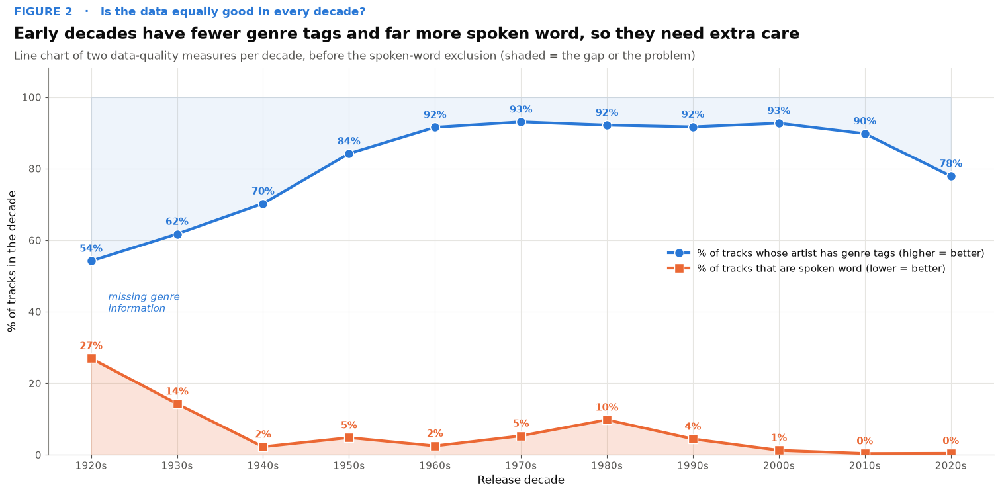

Saved -> figures/fig02_data_quality_by_decade.png


In [32]:
qual = clean.groupby('decade_label', observed=True).agg(
    genre=('primary_genre_family', lambda s: s.notna().mean() * 100),
    spoken=('is_spoken_word', lambda s: s.mean() * 100))
fig, ax = plt.subplots(figsize=(15, 6.4), layout='constrained')
x = np.arange(len(qual))
ax.fill_between(x, qual['genre'], 100, color=CAT[0], alpha=0.08)
ax.plot(x, qual['genre'], color=CAT[0], lw=3, marker='o', markersize=10, markeredgecolor='white', label='% of tracks whose artist has genre tags (higher = better)')
ax.fill_between(x, 0, qual['spoken'], color=CAT[1], alpha=0.18)
ax.plot(x, qual['spoken'], color=CAT[1], lw=3, marker='s', markersize=10, markeredgecolor='white', label='% of tracks that are spoken word (lower = better)')
for xi, (g_, s_) in enumerate(zip(qual['genre'], qual['spoken'])):
    ax.annotate(f'{g_:.0f}%', (xi, g_), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=10.5, color=CAT[0], fontweight='bold')
    ax.annotate(f'{s_:.0f}%', (xi, s_), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=10.5, color=CAT[1], fontweight='bold')
ax.text(0.2, 40, 'missing genre\ninformation', color=CAT[0], fontsize=10.5, fontstyle='italic')
ax.set_xticks(x, qual.index.astype(str))
ax.set_xlabel('Release decade')
ax.set_ylabel('% of tracks in the decade')
ax.set_ylim(0, 108)
ax.legend(loc='center right')
save_fig(fig, 2, 'data_quality_by_decade', 'Early decades have fewer genre tags and far more spoken word, so they need extra care',
         'Line chart of two data-quality measures per decade, before the spoken-word exclusion (shaded = the gap or the problem)',
         question='Is the data equally good in every decade?')

**What Figure 2 shows.** Genre coverage is only 54 % in the 1920s and 62 % in the 1930s, against 90–93 % for the 1960s–2010s, and it drops back to 78 % in the 2020s because new artists have not been tagged yet. Spoken word makes up 27 % of 1920s "tracks" (audiobook chapters) and 10 % of 1980s tracks (German children's audio dramas), but under 1 % after 2000.

**How this moves the story forward.** It explains two decisions behind every chapter. Spoken word is removed before studying "the sound of music", and genre findings are read cautiously for the earliest decades.

### Cleaning Log

In [33]:
cleaning_log = pd.DataFrame(CLEAN_LOG)
cleaning_log.to_csv(OUT_DIR / 'cleaning_log.csv', index=False)
md_table(cleaning_log, index=False, disable_numparse=True)

| Step   | Issue                                                                | Action                                                                              | Rows/values affected          | Justification                                                          |
|:-------|:---------------------------------------------------------------------|:------------------------------------------------------------------------------------|:------------------------------|:-----------------------------------------------------------------------|
| 2.1    | release_date in 3 formats; naive parse loses ~138K dates             | Year via str[:4]; full date only where complete; kept date_precision                | 138,591 dates rescued         | Time is the main axis; NaT would silently drop most old music          |
| 2.1    | One track dated 1900, isolated 20 years before the next              | Removed (keep 1920–2021)                                                            | 1 row                         | A single point cannot represent a decade                               |
| 2.2    | tracks.name null                                                     | Dropped                                                                             | 71 rows                       | 0.01 %; cannot be de-duplicated or labelled; audio analysis unaffected |
| 2.2    | artists.name null (3) / followers null (11)                          | Kept as missing (no imputation)                                                     | 3 + 11 artist rows            | Join uses id; imputing counts would invent data                        |
| 2.3    | Same name + artists released several times (remasters, compilations) | Kept earliest release (tie: most popular)                                           | 59,992 rows removed           | Re-releases would copy old sounds into later decades                   |
| 2.4    | artists / id_artists / genres stored as list-like strings            | ast.literal_eval with try/except; primary artist = first ID                         | 96,940 multi-artist tracks    | Safe parsing; one artist per track avoids double counting              |
| 2.5    | 74% of artists have no genre tags; ~5K distinct tags                 | Mapped tags to 10 families + Other (majority vote); genre used only where available | 856,500 artists without genre | Readable genre mix; subset biased to established artists               |
| 2.6    | Artist info in a separate table                                      | Left join on primary artist id (many-to-one validated)                              | 11,496 tracks unmatched       | Keep every track; unmatched simply lack artist fields                  |
| 2.7    | artists.csv has no dates                                             | Derived debut_year, last_year, career_span, n_tracks, debut_decade from tracks      | 71,492 artists                | Chapter 1 needs artist eras; debut = first year in this dataset        |
| 2.8    | tempo = 0 (failed analysis)                                          | Set to NaN                                                                          | 301 values                    | Not a real measurement                                                 |
| 2.8    | time_signature = 0 (failed analysis)                                 | Set to NaN                                                                          | 309 values                    | Not a real measurement                                                 |
| 2.8    | loudness > 0 dB                                                      | Set to NaN                                                                          | 202 values                    | Average loudness cannot exceed 0 dBFS                                  |
| 2.8    | loudness < -50 dB                                                    | Kept, winsorized in 3A                                                              | 22 values                     | Rare but physically possible                                           |
| 2.8    | duration < 30 s or > 20 min                                          | Flag is_extreme_length; music-length window in 3A                                   | 1,215 rows                    | Skits, audiobooks and mixes are not songs                              |
| 2.8    | speechiness > 0.66                                                   | Flag is_spoken_word; excluded from analysis copy                                    | 22,430 rows                   | Question is about the sound of music                                   |
| 2.8    | popularity = 0                                                       | Kept; flag is_zero_popularity                                                       | 39,639 rows                   | Means "not streamed recently", not missing                             |
| 2.9    | Categories stored as ints; 64-bit numerics                           | Labelled categoricals; float32/int8/int16/int32                                     | 485 -> 444 MB                 | Prevents meaningless means; saves memory                               |
| 2.10   | Analysis needs year/decade/minutes/tiers/genre/collab/title/mood     | Derived 10 columns                                                                  | all rows                      | Readable units and groupings for each chapter                          |

<a id="section-3"></a>
# Section 3: Exploratory Data Analysis, the story in four chapters

From here on, the analysis uses a **music-only analysis copy** called `music`. It is the clean table with the spoken-word items removed (step 2.8), after the outlier treatment below. The full clean table, `clean`, is never modified and is the version saved to disk.

**Reading the figures.** Every figure has a three-line title. The **blue line** is the question the figure answers, the **bold line** is the answer, and the **grey line** says exactly what is plotted. Decades always use the same dark-to-yellow colour ramp, and every genre family and mood always keeps its own colour. Every chapter ends with a **Chapter Takeaways** box.

<a id="section-30"></a>
## 3.0 Outlier handling

The first step is to *detect* outliers using two independent rules:

* **IQR rule:** a value is an outlier if it lies below Q1 − 1.5·IQR or above Q3 + 1.5·IQR. This works for any distribution shape.
* **z-score (|z| > 3) and modified z-score (|0.6745·(x − median)/MAD| > 3.5).** The modified version uses the median and the median absolute deviation (MAD), so the outliers it is looking for do not distort it.

In [34]:
music = clean.loc[~clean['is_spoken_word']].copy()
print(f'Analysis copy: {len(clean):,} clean tracks - {clean.is_spoken_word.sum():,} spoken word = {len(music):,} music tracks')

OUT_VARS = UNIT_FEATS + ['loudness', 'tempo', 'duration_min', 'popularity', 'artist_followers']

def outlier_summary(s):
    """IQR fences and outlier shares under three rules for one numeric Series."""
    s = s.dropna().astype('float64')
    q1, q3 = s.quantile([0.25, 0.75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    z = (s - s.mean()) / s.std()
    med = s.median()
    mad = (s - med).abs().median()
    mz_share = ((0.6745 * (s - med) / mad).abs() > 3.5).mean() * 100 if mad > 0 else np.nan
    return pd.Series({'IQR low fence': lo, 'IQR high fence': hi,
                      'IQR outliers %': ((s < lo) | (s > hi)).mean() * 100,
                      '|z|>3 %': (z.abs() > 3).mean() * 100,
                      '|mod z|>3.5 %': mz_share, 'skew': s.skew()})

out_tbl = pd.DataFrame({v: outlier_summary(music[v]) for v in OUT_VARS}).T
md_table(out_tbl, floatfmt=',.2f')

Analysis copy: 526,608 clean tracks - 22,430 spoken word = 504,178 music tracks


|                  |   IQR low fence |   IQR high fence |   IQR outliers % |   |z|>3 % |   |mod z|>3.5 % |   skew |
|:-----------------|----------------:|-----------------:|-----------------:|----------:|----------------:|-------:|
| danceability     |            0.09 |             1.03 |             0.27 |      0.06 |            0.00 |  -0.29 |
| energy           |           -0.25 |             1.36 |             0.00 |      0.00 |            0.00 |  -0.16 |
| valence          |           -0.31 |             1.43 |             0.00 |      0.00 |            0.00 |  -0.15 |
| acousticness     |           -0.95 |             1.82 |             0.00 |      0.00 |            0.00 |   0.18 |
| instrumentalness |           -0.02 |             0.03 |            21.86 |      1.64 |           41.48 |   2.20 |
| speechiness      |           -0.02 |             0.12 |            12.69 |      3.01 |           15.02 |   3.33 |
| liveness         |           -0.16 |             0.52 |             6.82 |      2.85 |            9.37 |   2.16 |
| loudness         |          -21.94 |             2.88 |             2.72 |      1.34 |            1.45 |  -1.31 |
| tempo            |           35.07 |           198.24 |             0.90 |      0.12 |            0.00 |   0.44 |
| duration_min     |            0.79 |             6.59 |             4.83 |      0.93 |            2.89 |  11.01 |
| popularity       |          -29.00 |            83.00 |             0.06 |      0.06 |            0.00 |   0.29 |
| artist_followers |     -801,079.00 |     1,365,553.00 |            14.79 |      1.37 |           25.29 |   9.71 |

The two rules give very different answers for some variables, and the reason is informative. For **instrumentalness**, most tracks score almost exactly 0. The MAD is therefore 0, the modified z-score is undefined (shown as `nan`), and the IQR rule labels every track with real instrumental content as an "outlier". That is clearly wrong: those values are exactly the instrumental music we want to keep. **Speechiness** and **liveness** behave the same way, only less extremely. Figure 3 shows what the outliers look like before any treatment. Panels for genuinely extreme variables are outlined in orange.

/var/folders/xl/38x571ks29q88nvdk268v9yr0000gn/T/ipykernel_31654/272152020.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.55, patch_artist=True,
/var/folders/xl/38x571ks29q88nvdk268v9yr0000gn/T/ipykernel_31654/272152020.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.55, patch_artist=True,
/var/folders/xl/38x571ks29q88nvdk268v9yr0000gn/T/ipykernel_31654/272152020.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.55, patch_artist=True,
/var/folders/xl/38x571ks29q88nvdk268v9yr0000gn/T/ipykernel_31654/272152020.py:5: Matplotlib

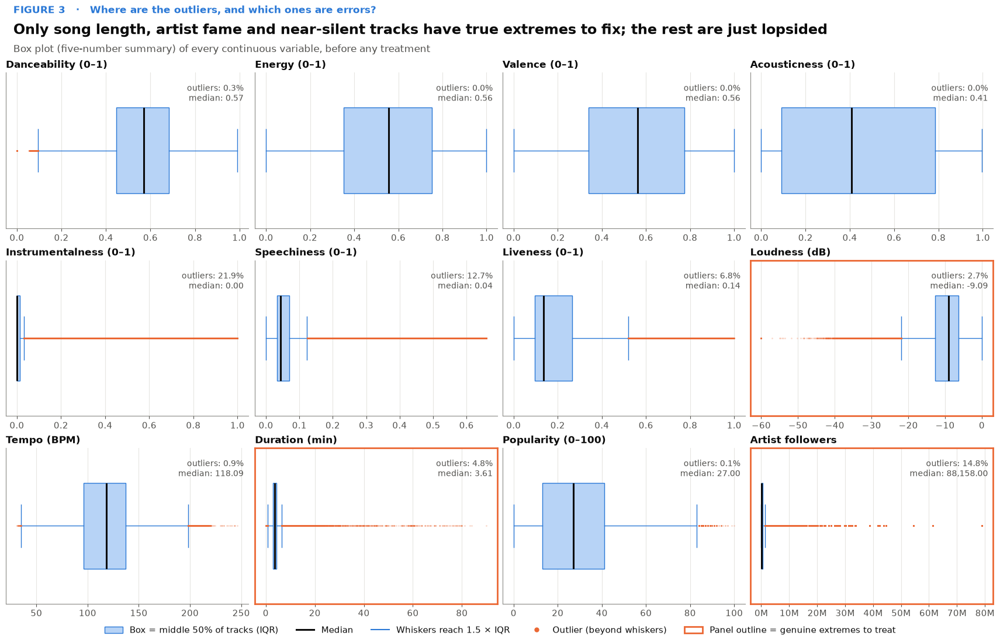

Saved -> figures/fig03_outlier_boxplots_before.png


In [35]:
fig, axes = plt.subplots(3, 4, figsize=(17, 10), layout='constrained')
REAL_EXTREMES = {'duration_min', 'artist_followers', 'loudness'}
for ax, v in zip(axes.flat, OUT_VARS):
    s = music[v].dropna()
    bp = ax.boxplot(s, vert=False, widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor='#b7d3f6', edgecolor=CAT[0]), medianprops=dict(color=INK, linewidth=2.2),
                    whiskerprops=dict(color=CAT[0]), capprops=dict(color=CAT[0]),
                    flierprops=dict(marker='o', markersize=2, markerfacecolor=CAT[1], markeredgecolor='none', alpha=0.25))
    for f in bp['fliers']:
        f.set_rasterized(True)
    ax.set_title(LABELS.get(v, v), fontsize=12.5)
    ax.set_yticks([])
    ax.text(0.98, 0.93, f"outliers: {out_tbl.loc[v, 'IQR outliers %']:.1f}%\nmedian: {s.median():,.2f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color=INK2)
    if v in REAL_EXTREMES:
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color(CAT[1]); sp.set_linewidth(2)
axes.flat[-1].xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
fig.legend(handles=[Patch(facecolor='#b7d3f6', edgecolor=CAT[0], label='Box = middle 50% of tracks (IQR)'),
                    Line2D([], [], color=INK, lw=2.2, label='Median'),
                    Line2D([], [], color=CAT[0], lw=1.5, label='Whiskers reach 1.5 × IQR'),
                    Line2D([], [], marker='o', ls='none', markerfacecolor=CAT[1], markeredgecolor='none', label='Outlier (beyond whiskers)'),
                    Patch(facecolor='white', edgecolor=CAT[1], lw=2, label='Panel outline = genuine extremes to treat')],
           loc='outside lower center', ncol=5)
save_fig(fig, 3, 'outlier_boxplots_before', 'Only song length, artist fame and near-silent tracks have true extremes to fix; the rest are just lopsided',
         'Box plot (five-number summary) of every continuous variable, before any treatment',
         question='Where are the outliers, and which ones are errors?')

**What Figure 3 shows.** There are two very different kinds of "outlier".
* **Genuine extremes (orange outline).** Duration has a long tail to 90+ minutes, followers reach 79 million, and loudness has a near-silent tail to −60 dB.
* **Natural skew.** Instrumentalness (21.9 % flagged), speechiness (12.7 %) and liveness (6.8 %) are flagged only because most songs sit near zero. Those values are real instrumental, rap and live recordings.

**How this moves the story forward.** It shows what to fix (length, loudness, followers) and what to leave alone. Leaving the 0–1 scores alone keeps instrumental and rap music, whose rise and fall the story is about.

### Treatment rules

The variables are treated differently because their outliers mean different things.

In [36]:
TREAT = ['duration_min', 'loudness', 'tempo', 'popularity', 'artist_followers']
pre = music[TREAT].copy()                               # untreated values, for the before/after table

# 1) duration: keep a "music-length" window = 1st–99th percentile (exclude rows outside it)
d_lo, d_hi = music['duration_min'].quantile([0.01, 0.99])
n_before = len(music)
music = music[music['duration_min'].between(d_lo, d_hi)].copy()
print(f'Duration window {d_lo:.2f}–{d_hi:.2f} min: {n_before:,} -> {len(music):,} rows ({n_before - len(music):,} excluded)')

# 2) loudness: impossible >0 dB values already NaN (2.7); winsorize the quiet tail at the 0.5th percentile
l_lo = music['loudness'].quantile(0.005)
n_l = int((music['loudness'] < l_lo).sum())
music['loudness'] = music['loudness'].clip(lower=l_lo)

# 3) tempo: zeros already NaN (2.7); winsorize both tails at 0.5th / 99.5th percentile
t_lo, t_hi = music['tempo'].quantile([0.005, 0.995])
n_t = int(((music['tempo'] < t_lo) | (music['tempo'] > t_hi)).sum())
music['tempo'] = music['tempo'].clip(t_lo, t_hi)
print(f'Loudness capped below at {l_lo:.1f} dB ({n_l:,} values); tempo capped to {t_lo:.0f}–{t_hi:.0f} BPM ({n_t:,} values)')

# 4) followers & popularity: transform, never delete
music['log_followers'] = np.log10(music['artist_followers'] + 1)
music['log1p_popularity'] = np.log1p(music['popularity'].astype(float))

def five(s):
    s = s.dropna().astype('float64')
    return pd.Series({'count': len(s), 'mean': s.mean(), 'median': s.median(), 'std': s.std(), 'skew': s.skew()})

ba = {}
for v in TREAT:
    ba[(v, 'before')] = five(pre[v])
    ba[(v, 'after')] = five(music[v])
ba[('artist_followers', 'after: log10(x+1)')] = five(music['log_followers'])
ba[('popularity', 'after: log1p(x)')] = five(music['log1p_popularity'])
ba = pd.DataFrame(ba).T
md_table(ba, floatfmt=',.2f')
ba.to_csv(OUT_DIR / 'outlier_before_after.csv')

Duration window 1.02–9.76 min: 504,178 -> 494,094 rows (10,084 excluded)
Loudness capped below at -28.8 dB (2,469 values); tempo capped to 62–202 BPM (4,940 values)


|                                           |      count |       mean |    median |          std |   skew |
|:------------------------------------------|-----------:|-----------:|----------:|-------------:|-------:|
| ('duration_min', 'before')                | 504,178.00 |       3.88 |      3.61 |         2.02 |  11.01 |
| ('duration_min', 'after')                 | 494,094.00 |       3.79 |      3.61 |         1.26 |   1.07 |
| ('loudness', 'before')                    | 503,976.00 |     -10.04 |     -9.09 |         4.98 |  -1.31 |
| ('loudness', 'after')                     | 493,894.00 |      -9.93 |     -9.03 |         4.81 |  -1.09 |
| ('tempo', 'before')                       | 503,877.00 |     119.22 |    118.09 |        29.47 |   0.44 |
| ('tempo', 'after')                        | 493,881.00 |     119.35 |    118.16 |        29.33 |   0.45 |
| ('popularity', 'before')                  | 504,178.00 |      27.79 |     27.00 |        18.41 |   0.29 |
| ('popularity', 'after')                   | 494,094.00 |      28.01 |     27.00 |        18.40 |   0.28 |
| ('artist_followers', 'before')            | 492,904.00 | 926,787.90 | 88,158.00 | 3,253,181.82 |   9.71 |
| ('artist_followers', 'after')             | 483,316.00 | 926,445.38 | 87,898.00 | 3,268,183.51 |   9.70 |
| ('artist_followers', 'after: log10(x+1)') | 483,316.00 |       4.79 |      4.94 |         1.31 |  -0.76 |
| ('popularity', 'after: log1p(x)')         | 494,094.00 |       2.98 |      3.33 |         1.12 |  -1.46 |

| Variable | Treatment | Rule | Why |
|---|---|---|---|
| `duration_min` | **Excluded** outside a music-length window | Keep the 1st–99th percentile (bounds printed above) | The far tail is audiobooks, 90-minute DJ mixes and white-noise tracks, not songs. The far-left tail is skits and intros. These would distort the "song length" story |
| `loudness` | **Winsorized** (capped) | Values > 0 dB set to NaN in 2.7; values below the 0.5th percentile raised to that percentile | Quiet tracks are real, but a handful of near-silent files pull the mean and dominate the scales |
| `tempo` | **Winsorized** | 0 BPM set to NaN in 2.7; capped at the 0.5th / 99.5th percentiles | Extreme BPM values are usually half-time or double-time detection errors |
| Seven 0–1 scores | **Kept unchanged** | none | They are bounded by design, so the skew is natural (most songs are not instrumental, not live and not speech). "Outliers" here are real musical styles |
| `popularity`, `followers` | **Transformed**, not deleted | `log1p(popularity)`, `log10(followers + 1)` | A superstar with 70M followers is real data. A log scale makes the shape readable without throwing it away |

**The original `clean` table is preserved.** Only the analysis copy `music` is treated, and every model and comparison below uses it.

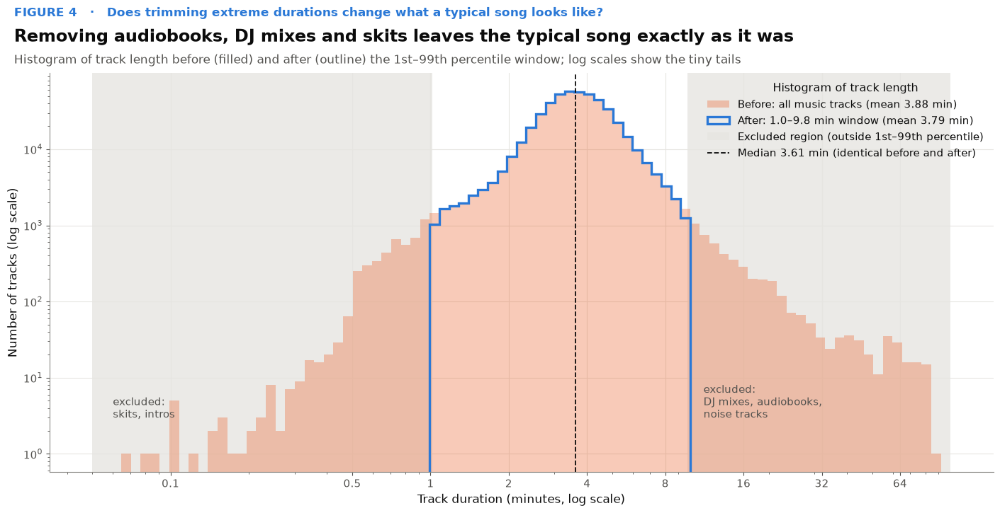

Saved -> figures/fig04_duration_before_after.png
Mean duration 3.88 -> 3.79 min; median 3.61 -> 3.61 min


In [37]:
# Figure 4: duration histograms before vs after the music-length window (log-spaced bins so the long tail is visible)
fig, ax = plt.subplots(figsize=(14, 6.2), layout='constrained')
bins = np.logspace(np.log10(0.05), np.log10(100), 90)
ax.hist(pre['duration_min'].dropna(), bins=bins, color=CAT[1], alpha=0.35, label=f"Before: all music tracks (mean {pre['duration_min'].mean():.2f} min)")
ax.hist(music['duration_min'].dropna(), bins=bins, histtype='step', color=CAT[0], lw=2.4,
        label=f"After: {d_lo:.1f}–{d_hi:.1f} min window (mean {music['duration_min'].mean():.2f} min)")
ax.axvspan(0.05, d_lo, color=GRID, alpha=0.8, lw=0, zorder=0, label='Excluded region (outside 1st–99th percentile)')
ax.axvspan(d_hi, 100, color=GRID, alpha=0.8, lw=0, zorder=0)
med = music['duration_min'].median()
ax.axvline(med, color=INK, lw=1.3, ls='--', label=f'Median {med:.2f} min (identical before and after)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([0.1, 0.5, 1, 2, 4, 8, 16, 32, 64])
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.set_xlabel('Track duration (minutes, log scale)')
ax.set_ylabel('Number of tracks (log scale)')
ax.legend(loc='upper right', title='Histogram of track length')
ax.text(d_hi * 1.15, 3, 'excluded:\nDJ mixes, audiobooks,\nnoise tracks', fontsize=10.5, color=INK2)
ax.text(0.06, 3, 'excluded:\nskits, intros', fontsize=10.5, color=INK2)
save_fig(fig, 4, 'duration_before_after', 'Removing audiobooks, DJ mixes and skits leaves the typical song exactly as it was',
         'Histogram of track length before (filled) and after (outline) the 1st–99th percentile window; log scales show the tiny tails',
         question='Does trimming extreme durations change what a typical song looks like?')
print(f"Mean duration {pre['duration_min'].mean():.2f} -> {music['duration_min'].mean():.2f} min; "
      f"median {pre['duration_min'].median():.2f} -> {music['duration_min'].median():.2f} min")

**What Figure 4 shows.** The 1st–99th percentile window (1.02–9.76 minutes) removes 10,084 tracks (2.0 %): skits on the left, and DJ mixes, audiobooks and noise tracks on the right. The median stays at 3.61 minutes, while the mean falls from 3.88 to 3.79 and the skew from 11.0 to 1.1.

**How this moves the story forward.** It shows that the song-length trend in Chapter 2 (Figure 23) describes real songs, not a handful of 90-minute recordings.

<a id="chapter-1"></a>
## Chapter 1: The Artists. Who makes popular music, and how has that changed?

**The story in this chapter.** The people making recorded music changed from a small number of orchestras, crooners and catalogue names into a flood of artists, many of them independent. Solo performers increasingly gave way to collaborations. This chapter looks at how many artists there are and how fame is distributed, which genres they come from, how concentrated the catalogue is, and how artists connect to each other.

**Unit of analysis.** Most charts here use one row per **primary artist**, using the artist-level fields derived in step 2.7. Artists for whom at least half of their tracks are spoken word (audiobook narrators, audio dramas) are left out. **Limits:** genre exists only for a subset of artists, and `debut_year` is the first year *in this dataset*, not necessarily an artist's real debut.

In [38]:
# ---- Chapter 1 helpers ------------------------------------------------------
def gini(x):
    """Gini coefficient of a non-negative array (0 = perfectly equal, 1 = one artist has everything)."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return (2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum())

def lorenz(x):
    """Cumulative share of artists (x) vs cumulative share of tracks (y), sorted from smallest to largest."""
    x = np.sort(np.asarray(x, dtype=float))
    y = np.r_[0, np.cumsum(x) / x.sum()]
    return np.linspace(0, 1, len(y)), y

EXCLUDE_ARTISTS = {'Various Artists', 'Anonymous', 'Workout Music', ''}
arts = artist_tbl[(artist_tbl['spoken_share'] < 0.5) & ~artist_tbl['artist'].isin(EXCLUDE_ARTISTS)].copy()
arts['genre'] = arts['genre_family'].fillna('No genre tags')
arts['log_followers'] = np.log10(arts['followers'] + 1)
print(f'{len(arts):,} music artists (primary artists with mostly non-spoken tracks); '
      f'{arts.genre_family.notna().mean():.1%} have a genre family')

70,812 music artists (primary artists with mostly non-spoken tracks); 69.1% have a genre family


### Univariate: how fame and output are distributed

Followers span eight orders of magnitude, so Figure 5 uses a **log scale** for them. Artist popularity is already a 0–100 score.

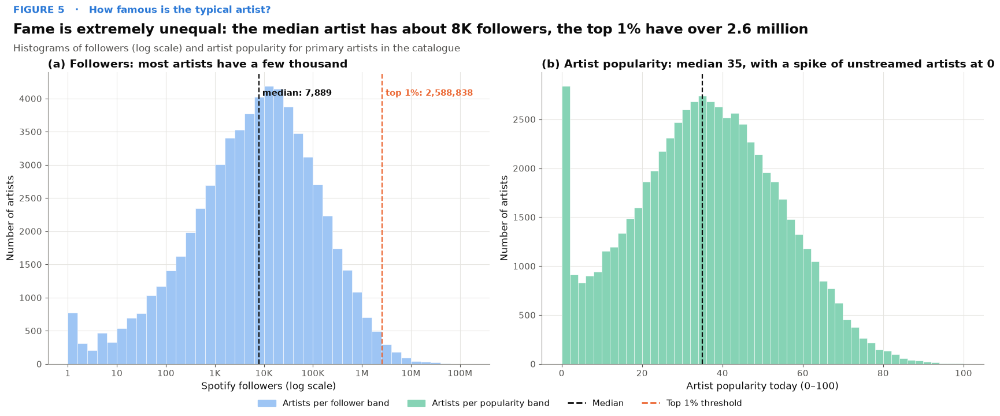

Saved -> figures/fig05_artist_followers_hist.png
Median followers 7,888; 99th percentile 2,588,837; share with < 1K followers 23.1%; median artist popularity 35


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.2), layout='constrained')
lf = arts['log_followers'].dropna()
axes[0].hist(lf, bins=np.arange(0, 8.25, 0.2), color='#9ec5f4', edgecolor='white', lw=0.4)
for q, lbl in [(lf.median(), 'median'), (lf.quantile(0.99), 'top 1%')]:
    axes[0].axvline(q, color=INK if lbl == 'median' else CAT[1], lw=1.6, ls='--')
    axes[0].text(q + 0.07, axes[0].get_ylim()[1] * 0.92, f'{lbl}: {10 ** q:,.0f}', fontsize=11, color=INK if lbl == 'median' else CAT[1], fontweight='bold')
axes[0].set_xticks(range(0, 9), ['1', '10', '100', '1K', '10K', '100K', '1M', '10M', '100M'])
axes[0].set_xlabel('Spotify followers (log scale)')
axes[0].set_ylabel('Number of artists')
axes[0].set_title('(a) Followers: most artists have a few thousand')
axes[1].hist(arts['artist_popularity'].dropna(), bins=np.arange(0, 102, 2), color='#86d3b5', edgecolor='white', lw=0.4)
axes[1].axvline(arts['artist_popularity'].median(), color=INK, lw=1.6, ls='--')
axes[1].set_xlabel('Artist popularity today (0–100)')
axes[1].set_ylabel('Number of artists')
axes[1].set_title(f"(b) Artist popularity: median {arts['artist_popularity'].median():.0f}, with a spike of unstreamed artists at 0")
fig.legend(handles=[Patch(color='#9ec5f4', label='Artists per follower band'), Patch(color='#86d3b5', label='Artists per popularity band'),
                    Line2D([], [], color=INK, ls='--', label='Median'), Line2D([], [], color=CAT[1], ls='--', label='Top 1% threshold')],
           loc='outside lower center', ncol=4)
save_fig(fig, 5, 'artist_followers_hist', f'Fame is extremely unequal: the median artist has about {lf.pipe(lambda s: 10 ** s.median()) / 1e3:.0f}K followers, the top 1% have over {10 ** lf.quantile(0.99) / 1e6:.1f} million',
         'Histograms of followers (log scale) and artist popularity for primary artists in the catalogue',
         question='How famous is the typical artist?')
print(f"Median followers {arts.followers.median():,.0f}; 99th percentile {arts.followers.quantile(.99):,.0f}; "
      f"share with < 1K followers {(arts.followers < 1000).mean():.1%}; median artist popularity {arts.artist_popularity.median():.0f}")

**What Figure 5 shows.** (a) The median music artist has about 7,900 followers. 23 % have fewer than 1,000, while the top 1 % have more than 2.6 million. (b) Artist popularity forms a broad hump with a median of 35.

**How this moves the story forward.** It sets up the chapter's central tension. Making music is open to tens of thousands of artists, but attention is concentrated on a very small group.

Figure 6 is a **treemap**: each rectangle's area is the number of artists in a genre family, including the large group of artists with no genre tags.

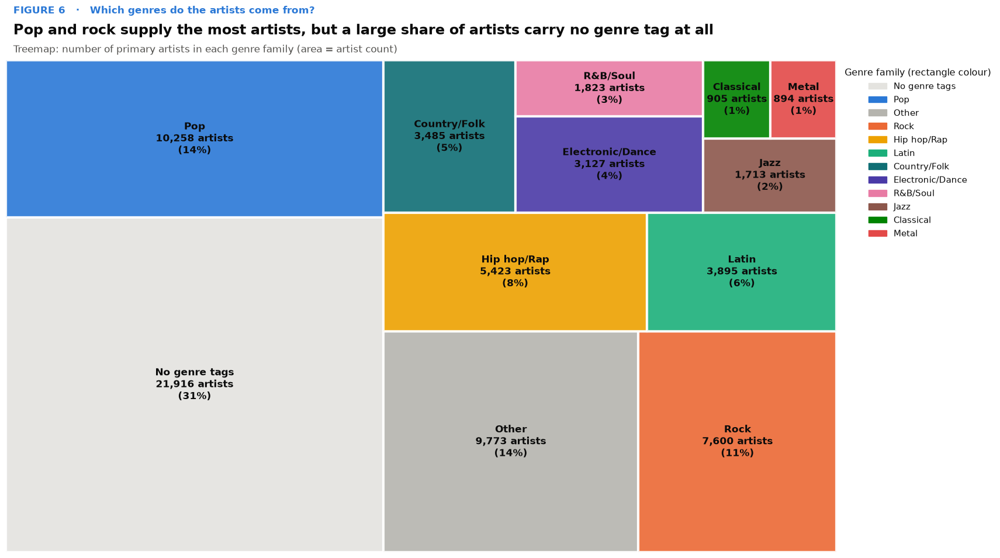

Saved -> figures/fig06_genre_treemap.png


|              |   No genre tags |   Pop |   Other |   Rock |   Hip hop/Rap |   Latin |   Country/Folk |   Electronic/Dance |   R&B/Soul |   Jazz |   Classical |   Metal |
|:-------------|----------------:|------:|--------:|-------:|--------------:|--------:|---------------:|-------------------:|-----------:|-------:|------------:|--------:|
| % of artists |            30.9 |  14.5 |    13.8 |   10.7 |           7.7 |     5.5 |            4.9 |                4.4 |        2.6 |    2.4 |         1.3 |     1.3 |

In [40]:
tm = arts['genre'].value_counts()
fig, ax = plt.subplots(figsize=(17, 8.5), layout='constrained')
labels = [f"{g}\n{n:,} artists\n({n / tm.sum():.0%})" for g, n in tm.items()]
squarify.plot(sizes=tm.values, label=labels, color=[GENRE_COL[g] for g in tm.index], alpha=0.9, ax=ax, pad=False,
              text_kwargs=dict(fontsize=12, color=INK, fontweight='bold'), edgecolor='white', linewidth=3)
ax.axis('off')
ax.legend(handles=[Patch(color=GENRE_COL[g], label=g) for g in tm.index], loc='upper left', bbox_to_anchor=(1.0, 1.0),
          title='Genre family (rectangle colour)')
save_fig(fig, 6, 'genre_treemap', 'Pop and rock supply the most artists, but a large share of artists carry no genre tag at all',
         'Treemap: number of primary artists in each genre family (area = artist count)',
         question='Which genres do the artists come from?')
md_table((tm / tm.sum() * 100).to_frame('% of artists').T, floatfmt='.1f')

**What Figure 6 shows.** Among the 70,812 music artists, the largest group (31 %) has **no genre tags at all**. Pop (14.5 %), Other (13.8 %), rock (10.7 %) and hip hop/rap (7.7 %) follow, with Latin, country/folk and electronic/dance at about 4–6 % each.

**How this moves the story forward.** It sizes the genre families used in every later chapter, and it makes the main limitation visible: a third of the artists cannot be placed in a genre.

Figure 7 is a **rank–size plot**: artists are sorted from most to fewest tracks, and both axes are logarithmic. A straight, sloping line is the signature of a "long tail", where a few artists release a great deal and a very large number release only a little.

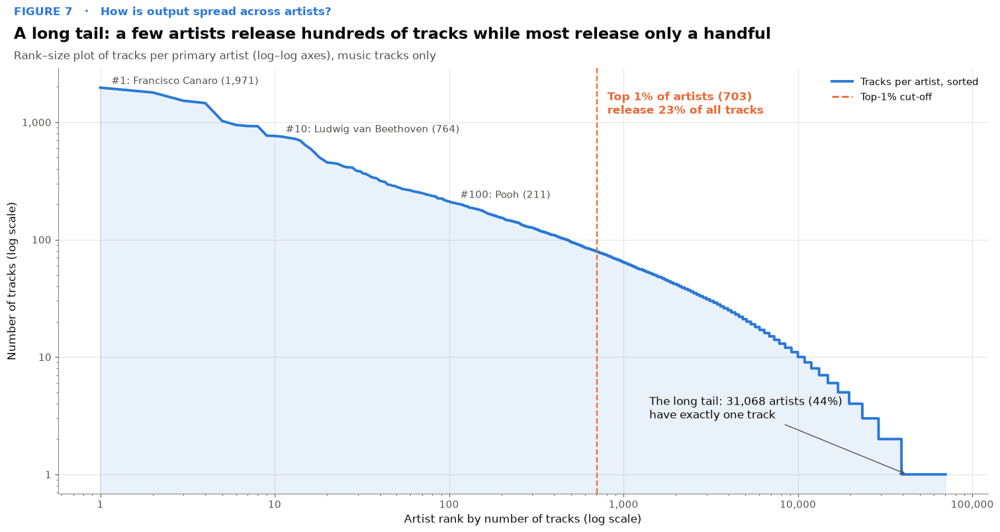

Saved -> figures/fig07_tracks_per_artist_long_tail.png
Median tracks per artist: 2; mean 7.0; top 1% share 22.7%


In [41]:
nt = music.groupby('primary_artist_id').size().sort_values(ascending=False)
rank = np.arange(1, len(nt) + 1)
top1 = nt.iloc[:max(1, len(nt) // 100)].sum() / nt.sum()
fig, ax = plt.subplots(figsize=(15, 7), layout='constrained')
ax.plot(rank, nt.values, color=CAT[0], lw=2.8)
ax.fill_between(rank, nt.values, color=CAT[0], alpha=0.1)
cut1 = len(nt) // 100
ax.axvline(cut1, color=CAT[1], lw=1.6, ls='--')
ax.text(cut1 * 1.15, nt.max() * 0.6, f'Top 1% of artists ({cut1:,})\nrelease {top1:.0%} of all tracks', fontsize=12, color=CAT[1], fontweight='bold')
one = (nt == 1).sum()
ax.annotate(f'The long tail: {one:,} artists ({one / len(nt):.0%})\nhave exactly one track', xy=(len(nt) * 0.6, 1), xytext=(len(nt) * 0.02, 3),
            fontsize=12, arrowprops=dict(arrowstyle='->', color=INK2), color=INK)
for r_ in [1, 10, 100]:
    ax.annotate(f'#{r_}: {nt.index.map(artist_tbl["artist"]).values[r_ - 1]} ({nt.iloc[r_ - 1]:,})', (r_, nt.iloc[r_ - 1]), xytext=(12, 4),
                textcoords='offset points', fontsize=10.5, color=INK2)
ax.set_xscale('log')
ax.set_yscale('log')
for axis_ in (ax.xaxis, ax.yaxis):
    axis_.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xlabel('Artist rank by number of tracks (log scale)')
ax.set_ylabel('Number of tracks (log scale)')
ax.legend(handles=[Line2D([], [], color=CAT[0], lw=2.8, label='Tracks per artist, sorted'),
                   Line2D([], [], color=CAT[1], ls='--', label='Top-1% cut-off')], loc='upper right')
save_fig(fig, 7, 'tracks_per_artist_long_tail', 'A long tail: a few artists release hundreds of tracks while most release only a handful',
         'Rank–size plot of tracks per primary artist (log–log axes), music tracks only',
         question='How is output spread across artists?')
print(f'Median tracks per artist: {nt.median():.0f}; mean {nt.mean():.1f}; top 1% share {top1:.1%}')

**What Figure 7 shows.** The rank–size line falls steadily on log–log axes, which is the signature of a long tail. The median artist has just **2 tracks** and 44 % have only one, while the **top 1 % of artists release 22.7 % of all tracks**. The most prolific names are catalogue giants: Francisco Canaro (tango), classical composers and Indian film singers.

**How this moves the story forward.** It shows that "an artist" means very different things in this catalogue, from one-song acts to archives of thousands of recordings. That is why later charts look at shares and medians rather than raw counts.

### Bivariate: how the artist population changed over time

Figure 8 is a **stacked area chart** of new artists by their debut year, coloured by genre family. Each layer is the number of artists whose first track in the catalogue appeared that year.

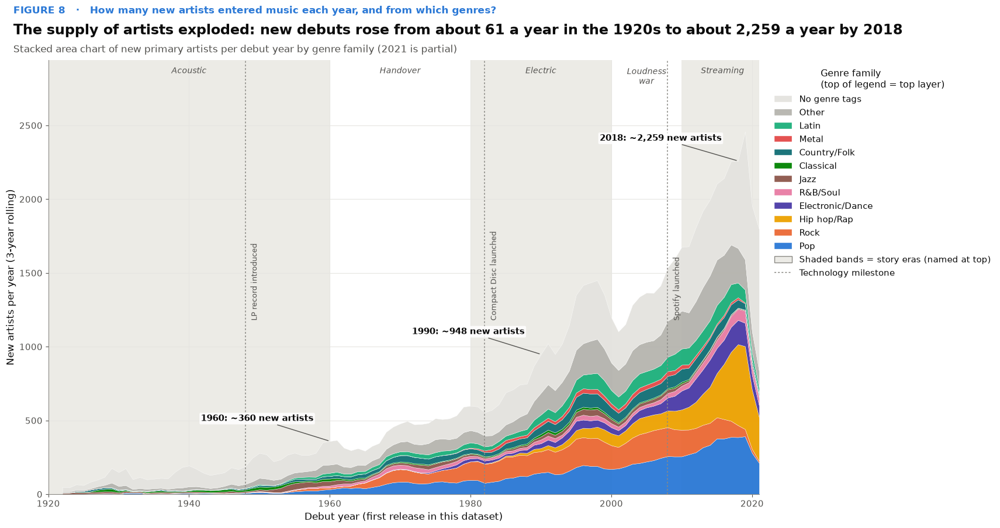

Saved -> figures/fig08_new_artists_stacked_area.png


In [42]:
deb = arts[arts['debut_year'].between(1920, 2021)]
fam_order_ = [f for f in FAM_ORDER if f in deb['genre'].unique()] + ['No genre tags']
new_by_year = pd.crosstab(deb['debut_year'], deb['genre'])[fam_order_].rolling(3, center=True, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(17, 8), layout='constrained')
ax.stackplot(new_by_year.index, new_by_year.T.values, labels=new_by_year.columns, colors=[GENRE_COL[g] for g in new_by_year.columns],
             edgecolor='white', linewidth=0.3, alpha=0.95)
add_eras(ax, short=True)
add_milestones(ax, y=0.4)
tot = new_by_year.sum(axis=1)
for yr in (1960, 1990, 2018):
    ax.annotate(f'{yr}: ~{tot.loc[yr]:,.0f} new artists', (yr, tot.loc[yr]), xytext=(-20, 25), textcoords='offset points', ha='right',
                fontsize=11, fontweight='bold', arrowprops=dict(arrowstyle='-', color=INK2), bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
ax.set_xlim(1920, 2021)
ax.set_xlabel('Debut year (first release in this dataset)')
ax.set_ylabel('New artists per year (3-year rolling)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h[::-1] + [ERA_HANDLE, MILESTONE_HANDLE], loc='upper left', bbox_to_anchor=(1.01, 1.0), title='Genre family\n(top of legend = top layer)')
save_fig(fig, 8, 'new_artists_stacked_area', f'The supply of artists exploded: new debuts rose from about {tot.loc[1925]:,.0f} a year in the 1920s to about {tot.loc[2018]:,.0f} a year by 2018',
         'Stacked area chart of new primary artists per debut year by genre family (2021 is partial)',
         question='How many new artists entered music each year, and from which genres?')

**What Figure 8 shows.** New artists per year (3-year rolling) grew from about **61 in the 1920s** to about 360 in 1960, about 950 in 1990 and about **2,260 in 2018**. Most of the late growth comes from hip hop/rap (yellow), electronic/dance (purple) and untagged artists. Rock (orange) is the main source of new artists from the 1960s to the 1990s, and pop (blue) is steady throughout. The fall after 2019 is an artefact: brand-new artists have few tracks and 2021 is partial.

**How this moves the story forward.** It shows the supply side of the story. The number of people making recorded music exploded after the CD and especially after streaming (Spotify launched in 2008), and the new arrivals came from new genres.

Figure 9 tracks **collaboration**: the share of tracks credited to two or more artists, and the average number of credited artists per track. The bands are 95 % confidence intervals.

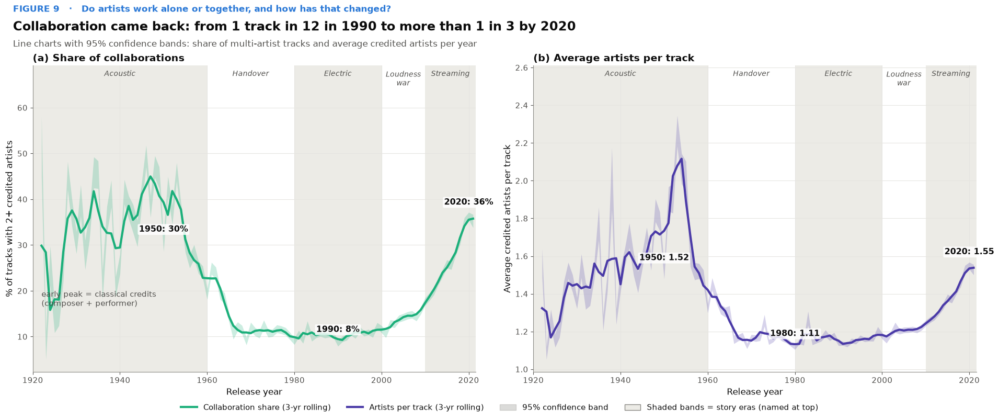

Saved -> figures/fig09_collaboration_rate.png
Collaboration share: 1950 30.4%, 1990 8.5%, 2010 17.6%, 2020 36.3%; artists per track 2020: 1.55


In [43]:
cy = music.groupby('release_year').agg(p=('is_collab', 'mean'), n=('is_collab', 'size'), m=('n_artists', 'mean'), s=('n_artists', 'std'))
cy['p_se'] = np.sqrt(cy['p'] * (1 - cy['p']) / cy['n'])
cy['m_se'] = cy['s'] / np.sqrt(cy['n'])
fig, axes = plt.subplots(1, 2, figsize=(19, 7), layout='constrained')
for ax, mean_, se_, col, ylab, fmt in [(axes[0], cy['p'] * 100, cy['p_se'] * 100, CAT[2], '% of tracks with 2+ credited artists', '{:.0f}%'),
                                       (axes[1], cy['m'], cy['m_se'], CAT[6], 'Average credited artists per track', '{:.2f}')]:
    ax.fill_between(cy.index, mean_ - 1.96 * se_, mean_ + 1.96 * se_, color=col, alpha=0.22, lw=0, zorder=2)
    ax.plot(cy.index, mean_.rolling(3, center=True, min_periods=1).mean(), color=col, lw=3, zorder=3)
    add_eras(ax, short=True)
    lo_y = mean_.loc[1960:2005].idxmin()
    for yr in (1950, lo_y, 2020):
        ax.annotate(f'{yr}: ' + fmt.format(mean_.loc[yr]), (yr, mean_.loc[yr]), xytext=(0, 16), textcoords='offset points', ha='center',
                    fontsize=11.5, fontweight='bold', bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
    ax.set_xlim(1920, 2021.6)
    ax.set_xlabel('Release year')
    ax.set_ylabel(ylab)
axes[0].text(1922, (cy['p'] * 100).loc[1950] * 0.55, 'early peak = classical credits\n(composer + performer)', fontsize=10.5, color=INK2)
axes[0].set_title('(a) Share of collaborations')
axes[1].set_title('(b) Average artists per track')
fig.legend(handles=[Line2D([], [], color=CAT[2], lw=3, label='Collaboration share (3-yr rolling)'), Line2D([], [], color=CAT[6], lw=3, label='Artists per track (3-yr rolling)'),
                    Patch(color=MUTED, alpha=0.3, label='95% confidence band'), ERA_HANDLE], loc='outside lower center', ncol=4)
_lo = (cy['p']).loc[1960:2005].idxmin()
save_fig(fig, 9, 'collaboration_rate', f"Collaboration came back: from 1 track in {1 / cy.loc[_lo, 'p']:.0f} in {_lo} to more than 1 in 3 by 2020",
         'Line charts with 95% confidence bands: share of multi-artist tracks and average credited artists per year',
         question='Do artists work alone or together, and how has that changed?')
lo_yr = (cy['p']).loc[1960:2005].idxmin()
print(f"Collaboration share: 1950 {cy.loc[1950, 'p']:.1%}, {lo_yr} {cy.loc[lo_yr, 'p']:.1%}, 2010 {cy.loc[2010, 'p']:.1%}, 2020 {cy.loc[2020, 'p']:.1%}; "
      f"artists per track 2020: {cy.loc[2020, 'm']:.2f}")

**What Figure 9 shows.** (a) The share of tracks credited to two or more artists was high before 1960 (30 % in 1950, mostly classical "composer + performer" credits). It fell to a low of **8.5 % in 1990**, then rose to 17.6 % in 2010 and **36.3 % in 2020**. (b) The average number of credited artists per track rose to 1.55 by 2020. The narrow confidence bands after 1960 show that this is not noise.

**How this moves the story forward.** It shows a new way of making music. In the streaming era, artists increasingly feature each other to reach each other's audiences, and Figure 14 maps who those collaborators are.

Is music now concentrated in a few stars, or spread across many artists? Figure 10 draws **Lorenz curves** of tracks per artist within each decade. The further a curve sags below the diagonal, the more unequal the output, and the **Gini coefficient** (0 = equal, 1 = one artist has everything) summarises each curve in one number.

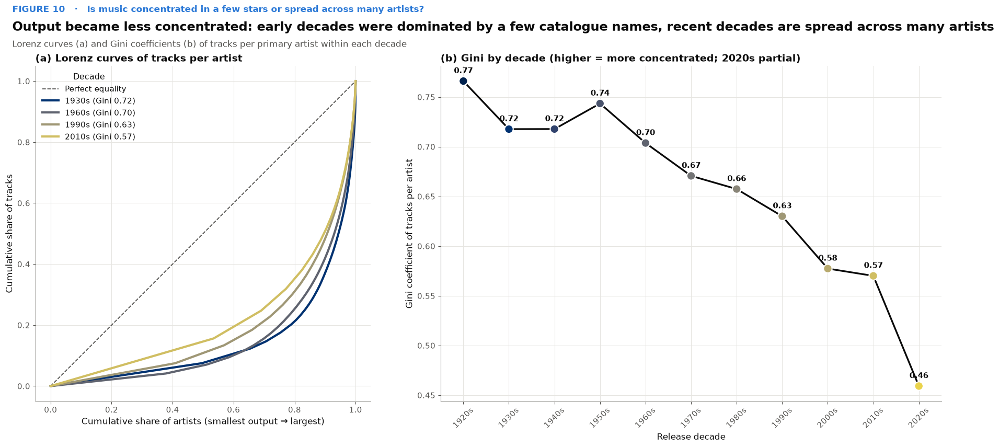

Saved -> figures/fig10_lorenz_gini.png


|      |   1920s |   1930s |   1940s |   1950s |   1960s |   1970s |   1980s |   1990s |   2000s |   2010s |   2020s |
|:-----|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| Gini |   0.766 |   0.718 |   0.718 |   0.743 |   0.704 |   0.671 |   0.657 |   0.630 |   0.577 |   0.570 |   0.459 |

In [44]:
gini_dec, curves = {}, {}
for d in DECADE_LABELS:
    counts = music.loc[music['decade_label'] == d].groupby('primary_artist_id').size()
    gini_dec[d] = gini(counts)
    curves[d] = lorenz(counts)
gini_dec = pd.Series(gini_dec)
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), layout='constrained', gridspec_kw={'width_ratios': [1, 1.3]})
ax = axes[0]
ax.plot([0, 1], [0, 1], color=INK2, ls='--', lw=1.3, label='Perfect equality')
for d in ['1930s', '1960s', '1990s', '2010s']:
    xs_, ys_ = curves[d]
    ax.plot(xs_, ys_, color=DEC_PAL[d], lw=3, label=f'{d} (Gini {gini_dec[d]:.2f})')
ax.set_xlabel('Cumulative share of artists (smallest output → largest)')
ax.set_ylabel('Cumulative share of tracks')
ax.set_aspect('equal')
ax.legend(loc='upper left', title='Decade')
ax.set_title('(a) Lorenz curves of tracks per artist')
ax = axes[1]
ax.plot(range(len(gini_dec)), gini_dec.values, color=INK, lw=2.4, zorder=2)
ax.scatter(range(len(gini_dec)), gini_dec.values, c=[DEC_PAL[d] for d in gini_dec.index], s=140, edgecolor='white', lw=1.5, zorder=3)
for i, v in enumerate(gini_dec.values):
    ax.annotate(f'{v:.2f}', (i, v), xytext=(0, 11), textcoords='offset points', ha='center', fontsize=10.5, fontweight='bold')
ax.set_xticks(range(len(gini_dec)), gini_dec.index, rotation=45)
ax.set_ylabel('Gini coefficient of tracks per artist')
ax.set_xlabel('Release decade')
ax.set_title('(b) Gini by decade (higher = more concentrated; 2020s partial)')
save_fig(fig, 10, 'lorenz_gini', 'Output became less concentrated: early decades were dominated by a few catalogue names, recent decades are spread across many artists',
         'Lorenz curves (a) and Gini coefficients (b) of tracks per primary artist within each decade',
         question='Is music concentrated in a few stars or spread across many artists?')
md_table(gini_dec.to_frame('Gini').T, floatfmt='.3f')

**What Figure 10 shows.** The Lorenz curves move closer to the diagonal over time, and the Gini coefficient of tracks per artist falls from **0.77 (1920s)** to 0.66 (1980s), **0.57 (2010s)** and 0.46 in the partial 2020s.

**How this moves the story forward.** It answers whether music became more concentrated, and the answer is no. Output is spread across far more artists than in the catalogue-dominated early decades. Attention (followers, Figure 5) is still very unequal, so music is more open to make but just as concentrated to be heard.

Do more followers mean a higher popularity score? Figure 11 is a **hexbin plot** on a log follower axis, with a LOWESS trend fitted to a 15,000-artist random sample.

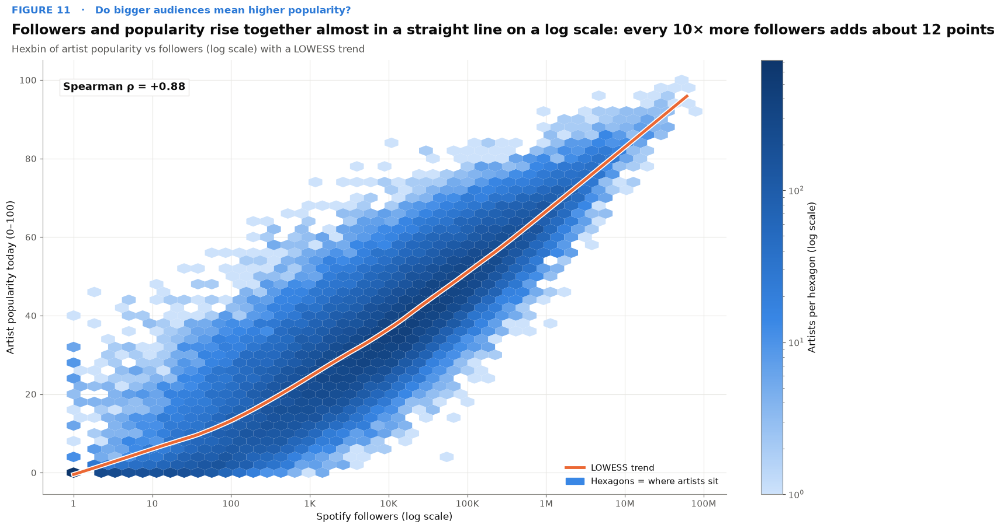

Saved -> figures/fig11_popularity_vs_followers_hexbin.png


In [45]:
hb_df = arts[['log_followers', 'artist_popularity']].dropna()
fig, ax = plt.subplots(figsize=(14, 8), layout='constrained')
hb = ax.hexbin(hb_df['log_followers'], hb_df['artist_popularity'], gridsize=45, cmap=SEQ, bins='log', mincnt=1, linewidths=0)
smp = hb_df.sample(min(15_000, len(hb_df)), random_state=SEED)
fit = lowess(smp['artist_popularity'], smp['log_followers'], frac=0.3, it=0, delta=0.02)
ax.plot(fit[:, 0], fit[:, 1], color=CAT[1], lw=3.5, path_effects=[pe.withStroke(linewidth=6, foreground='white')])
rho_fp = stats.spearmanr(hb_df['log_followers'], hb_df['artist_popularity']).statistic
slope_fp = np.polyfit(hb_df['log_followers'], hb_df['artist_popularity'], 1)[0]
ax.text(0.03, 0.95, f'Spearman ρ = {rho_fp:+.2f}', transform=ax.transAxes, fontsize=13, fontweight='bold', va='top',
        bbox=dict(fc='white', ec=GRID))
ax.set_xticks(range(0, 9), ['1', '10', '100', '1K', '10K', '100K', '1M', '10M', '100M'])
ax.set_xlabel('Spotify followers (log scale)')
ax.set_ylabel('Artist popularity today (0–100)')
fig.colorbar(hb, ax=ax, label='Artists per hexagon (log scale)')
ax.legend(handles=[Line2D([], [], color=CAT[1], lw=3.5, label='LOWESS trend'), Patch(color='#3987e5', label='Hexagons = where artists sit')], loc='lower right')
save_fig(fig, 11, 'popularity_vs_followers_hexbin', f'Followers and popularity rise together almost in a straight line on a log scale: every 10× more followers adds about {slope_fp:.0f} points',
         'Hexbin of artist popularity vs followers (log scale) with a LOWESS trend',
         question='Do bigger audiences mean higher popularity?')

**What Figure 11 shows.** Popularity rises almost in a straight line with log followers. The fitted slope is about **12 popularity points for every 10× more followers**. The spread around the trend is wide at the low end, where artists with the same small audience can have very different popularity.

**How this moves the story forward.** It confirms that the two measures of fame agree, so either can stand for "appeal" in this chapter.

### Multivariate: the stars of each era, the genre mix, and the network of collaborations

Figure 12 is a **bump chart** of the 10 artists with the most tracks in each decade from the 1950s to the 2010s. A line connects an artist who stays in the top 10 in consecutive decades, so long-lasting names stand out.

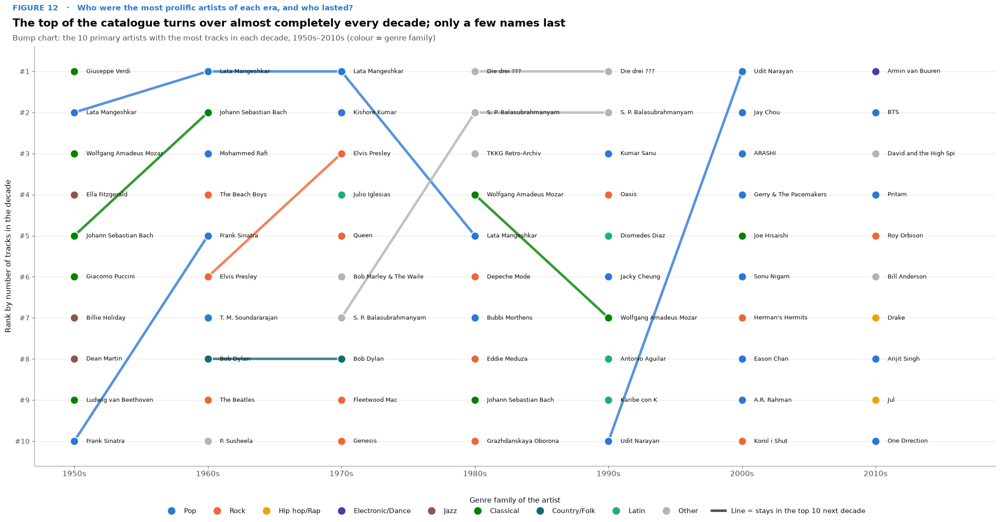

Saved -> figures/fig12_top_artists_bump.png
56 different artists appear; 9 of them are in the top 10 in two or more decades


In [46]:
BUMP_DECS = ['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']
mm = music[~music['primary_artist'].astype(str).str.strip().isin(EXCLUDE_ARTISTS)]
top_rank = {}
for d in BUMP_DECS:
    c = mm.loc[mm['decade_label'] == d].groupby('primary_artist_id').size().nlargest(10)
    top_rank[d] = {aid: r + 1 for r, aid in enumerate(c.index)}
fig, ax = plt.subplots(figsize=(22, 10.5), layout='constrained')
all_ids = set().union(*[set(v) for v in top_rank.values()])
for aid in all_ids:
    fam = artist_tbl.loc[aid, 'genre_family'] if isinstance(artist_tbl.loc[aid, 'genre_family'], str) else 'Other'
    col = GENRE_COL.get(fam, GENRE_COL['Other'])
    pts = [(i, top_rank[d][aid]) for i, d in enumerate(BUMP_DECS) if aid in top_rank[d]]
    for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):
        if x1 - x0 == 1:
            ax.plot([x0, x1], [y0, y1], color=col, lw=4, alpha=0.8, zorder=2)
    for x_, y_ in pts:
        ax.scatter(x_, y_, s=170, color=col, edgecolor='white', lw=1.5, zorder=3)
        ax.text(x_ + 0.09, y_, artist_tbl.loc[aid, 'artist'][:22], va='center', fontsize=9.5, zorder=4)
ax.set_xticks(range(len(BUMP_DECS)), BUMP_DECS, fontsize=12.5)
ax.set_yticks(range(1, 11), [f'#{i}' for i in range(1, 11)])
ax.set_ylim(10.6, 0.4)
ax.set_xlim(-0.3, len(BUMP_DECS) - 0.1)
ax.set_ylabel('Rank by number of tracks in the decade')
ax.grid(axis='x', visible=False)
fams_in = sorted({artist_tbl.loc[a_, 'genre_family'] if isinstance(artist_tbl.loc[a_, 'genre_family'], str) else 'Other' for a_ in all_ids},
                 key=lambda f: FAM_ORDER.index(f) if f in FAM_ORDER else 99)
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=GENRE_COL.get(f, GENRE_COL['Other']), markersize=11, label=f) for f in fams_in]
          + [Line2D([], [], color=INK2, lw=4, label='Line = stays in the top 10 next decade')],
          loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=len(fams_in) + 1, title='Genre family of the artist')
save_fig(fig, 12, 'top_artists_bump', 'The top of the catalogue turns over almost completely every decade; only a few names last',
         'Bump chart: the 10 primary artists with the most tracks in each decade, 1950s–2010s (colour = genre family)',
         question='Who were the most prolific artists of each era, and who lasted?')
stay = sum(1 for aid in all_ids if sum(aid in top_rank[d] for d in BUMP_DECS) >= 2)
print(f'{len(all_ids)} different artists appear; {stay} of them are in the top 10 in two or more decades')

**What Figure 12 shows.** Of the 56 artists who appear in some decade's top 10 (by track count), only **9 stay in the top 10 for two or more decades**. Lata Mangeshkar (1950s–80s), Bach and Mozart (reissued classical recordings), Bob Dylan, Elvis Presley, *Die drei ???* and S. P. Balasubrahmanyam are the long-lasting names. The leaders change from classical composers and jazz singers (1950s) to Indian film singers, then rock bands, then 2000s pop (Udit Narayan, Jay Chou) and the 2010s (Armin van Buuren, BTS, Drake).

**How this moves the story forward.** It shows which artists filled each era and how quickly the top of the catalogue turns over. It also shows that "most tracks" reflects which back catalogues were digitised, not chart success.

Figure 13 is a **slope chart** comparing the genre mix of *new* artists in two eras: those who debuted in the 1970s and those who debuted in the 2010s (genre-tagged artists only).

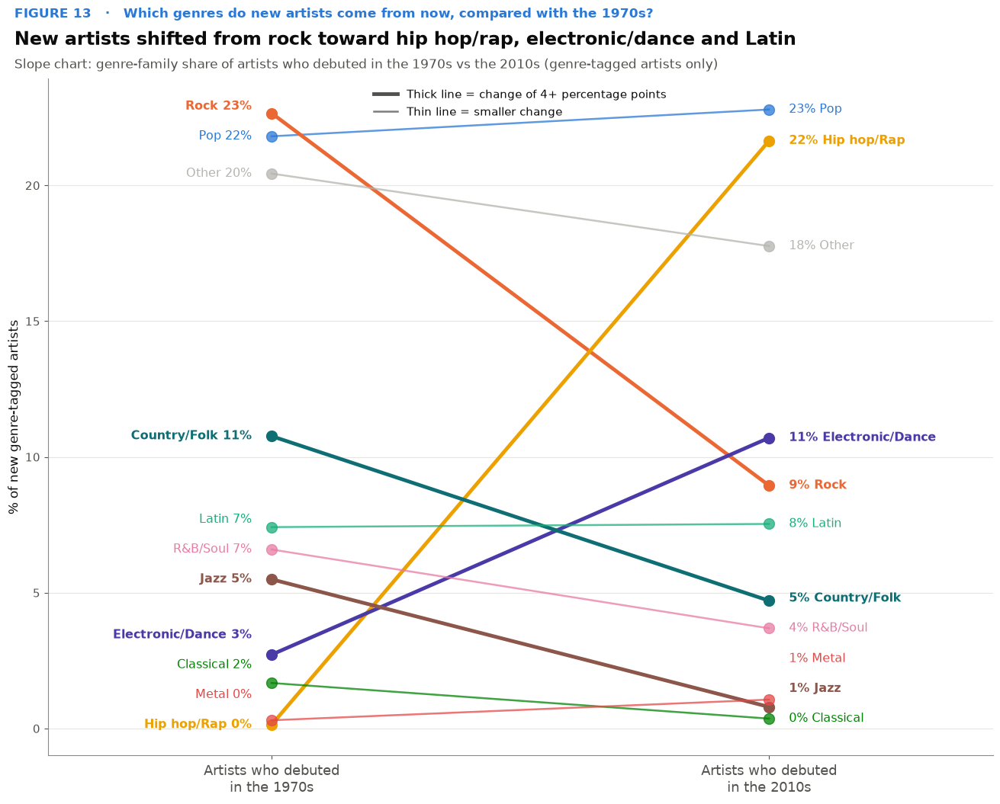

Saved -> figures/fig13_genre_slope_1970s_2010s.png


| genre_family     |   1970s |   2010s |   change |
|:-----------------|--------:|--------:|---------:|
| Rock             |   +22.7 |    +8.9 |    -13.7 |
| Country/Folk     |   +10.8 |    +4.7 |     -6.1 |
| Jazz             |    +5.5 |    +0.8 |     -4.7 |
| R&B/Soul         |    +6.6 |    +3.7 |     -2.9 |
| Other            |   +20.4 |   +17.8 |     -2.7 |
| Classical        |    +1.7 |    +0.4 |     -1.3 |
| Latin            |    +7.4 |    +7.5 |     +0.1 |
| Metal            |    +0.3 |    +1.1 |     +0.8 |
| Pop              |   +21.8 |   +22.8 |     +1.0 |
| Electronic/Dance |    +2.7 |   +10.7 |     +8.0 |
| Hip hop/Rap      |    +0.1 |   +21.6 |    +21.5 |

In [47]:
tag = arts[arts['genre_family'].notna()]
s70 = tag.loc[tag['debut_decade'] == 1970, 'genre_family'].value_counts(normalize=True) * 100
s10 = tag.loc[tag['debut_decade'] == 2010, 'genre_family'].value_counts(normalize=True) * 100
slope = pd.DataFrame({'1970s': s70, '2010s': s10}).fillna(0).reindex([f for f in FAM_ORDER if f in s70.index.union(s10.index)])
fig, ax = plt.subplots(figsize=(13, 9.5), layout='constrained')
def spread(vals, gap):
    """Nudge label positions apart so none overlap."""
    order_ = np.argsort(vals); out = np.array(vals, dtype=float); prev = -np.inf
    for i_ in order_:
        out[i_] = max(out[i_], prev + gap); prev = out[i_]
    return out
ly0, ly1 = spread(slope['1970s'].values, 1.1), spread(slope['2010s'].values, 1.1)
for k_, (fam, row) in enumerate(slope.iterrows()):
    col = GENRE_COL[fam]
    big = abs(row['2010s'] - row['1970s']) >= 4
    ax.plot([0, 1], [row['1970s'], row['2010s']], color=col, lw=3.5 if big else 1.8, marker='o', markersize=10, alpha=1 if big else 0.75)
    ax.text(-0.04, ly0[k_], f"{fam} {row['1970s']:.0f}%", ha='right', va='center', fontsize=11.5, color=col, fontweight='bold' if big else None)
    ax.text(1.04, ly1[k_], f"{row['2010s']:.0f}% {fam}", ha='left', va='center', fontsize=11.5, color=col, fontweight='bold' if big else None)
ax.set_xticks([0, 1], ['Artists who debuted\nin the 1970s', 'Artists who debuted\nin the 2010s'], fontsize=13)
ax.set_xlim(-0.45, 1.45)
ax.set_ylabel('% of new genre-tagged artists')
ax.grid(axis='x', visible=False)
ax.legend(handles=[Line2D([], [], color=INK2, lw=3.5, label='Thick line = change of 4+ percentage points'),
                   Line2D([], [], color=INK2, lw=1.8, alpha=0.75, label='Thin line = smaller change')], loc='upper center')
save_fig(fig, 13, 'genre_slope_1970s_2010s', 'New artists shifted from rock toward hip hop/rap, electronic/dance and Latin',
         'Slope chart: genre-family share of artists who debuted in the 1970s vs the 2010s (genre-tagged artists only)',
         question='Which genres do new artists come from now, compared with the 1970s?')
md_table(slope.assign(change=slope['2010s'] - slope['1970s']).sort_values('change'), floatfmt='+.1f')

**What Figure 13 shows.** Among genre-tagged new artists, **hip hop/rap went from 0 % of 1970s debuts to 22 % of 2010s debuts**, and electronic/dance went from 3 % to 11 %. Rock fell from 23 % to 9 %, country/folk from 11 % to 5 %, and jazz from 6 % to 1 %. Pop stayed flat at about 22 %.

**How this moves the story forward.** It shows that the people making music changed. That matters for Chapters 2–4, because a hip-hop or electronic artist makes louder, more danceable and more speech-heavy music than the rock, folk and jazz artists they replaced.

Figure 14 is a **collaboration network** built from tracks released in 2015–2021 that credit two or more artists. Each node is an artist, and each line means the two artists share at least one track (thicker = more shared tracks). To keep it readable, it is limited to established artists (1M+ followers) and shows the 80 with the most collaborators among them (the main connected web). Node size is followers and colour is genre family.

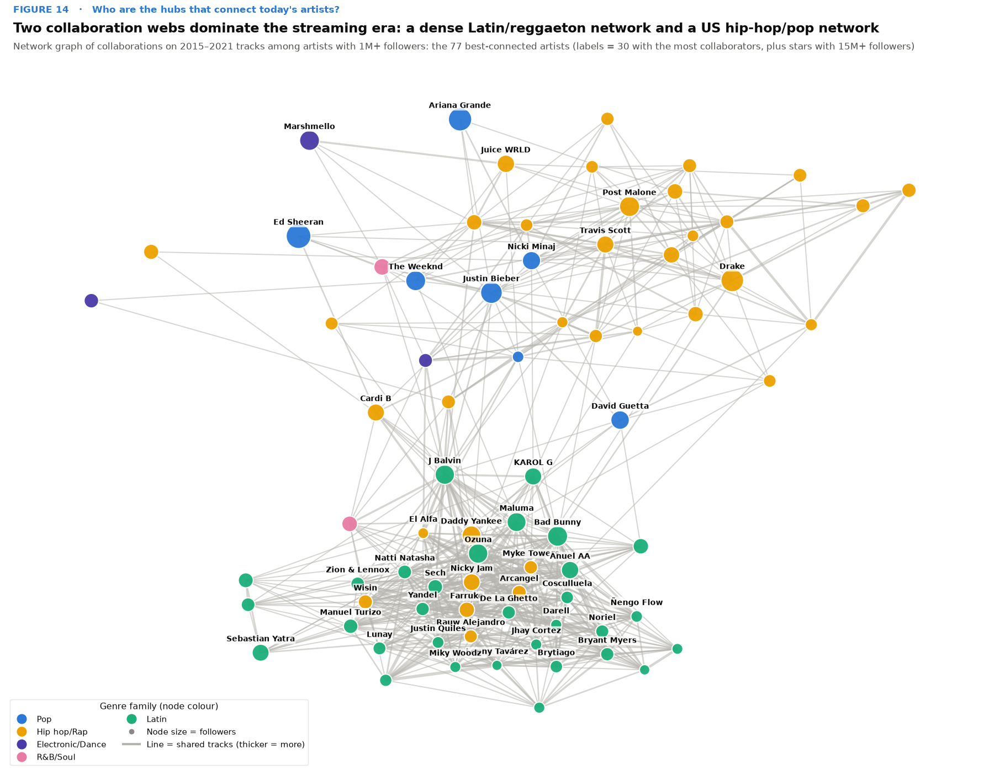

Saved -> figures/fig14_collaboration_network.png


| artist         | genre family   |   collaborators shown |   shared tracks |
|:---------------|:---------------|----------------------:|----------------:|
| Farruko        | Hip hop/Rap    |                    35 |             169 |
| Ozuna          | Latin          |                    34 |             157 |
| Nicky Jam      | Hip hop/Rap    |                    34 |             111 |
| Bad Bunny      | Latin          |                    34 |             113 |
| Myke Towers    | Hip hop/Rap    |                    33 |             108 |
| Anuel AA       | Latin          |                    32 |             121 |
| J Balvin       | Latin          |                    31 |             116 |
| Arcangel       | Hip hop/Rap    |                    30 |             130 |
| Rauw Alejandro | Hip hop/Rap    |                    30 |              72 |
| De La Ghetto   | Latin          |                    27 |              68 |
| Darell         | Latin          |                    27 |              66 |
| Sech           | Latin          |                    27 |             104 |

Fitted slope: 12.3 popularity points per 10x followers
Network: 15,003 artists and 24,117 collaboration pairs in 2015–2021; shown: 77 nodes


In [48]:
recent_c = music[(music['release_year'] >= 2015) & music['is_collab']]
edges = Counter()
for ids in recent_c['id_artists']:
    for x_, y_ in combinations(sorted(set(ids[:5])), 2):
        edges[(x_, y_)] += 1
G = nx.Graph()
G.add_weighted_edges_from([(x_, y_, w) for (x_, y_), w in edges.items()])
a_idx = a.set_index('id')
G.remove_nodes_from([n for n in list(G.nodes()) if n not in a_idx.index])
wdeg = dict(G.degree(weight='weight'))
big = [n for n in G.nodes() if a_idx.at[n, 'followers'] >= 1e6]          # established artists (1M+ followers)
Gb = G.subgraph(big).copy()
bdeg = dict(Gb.degree())
keep = sorted(bdeg, key=bdeg.get, reverse=True)[:80]
H0 = Gb.subgraph(keep).copy()
H = H0.subgraph(max(nx.connected_components(H0), key=len)).copy()   # the main connected web only
def node_attr(n):
    fam = a_idx.at[n, 'genre_family'] if n in a_idx.index else np.nan
    return (a_idx.at[n, 'name'] if n in a_idx.index else n), (a_idx.at[n, 'followers'] if n in a_idx.index else 0), (fam if isinstance(fam, str) else 'Other')
pos = nx.spring_layout(H, k=1.6 / np.sqrt(H.number_of_nodes()), iterations=500, seed=SEED, weight=None)
fig, ax = plt.subplots(figsize=(18, 13), layout='constrained')
ew = np.array([H[u][v]['weight'] for u, v in H.edges()])
nx.draw_networkx_edges(H, pos, width=0.6 + np.log1p(ew) * 1.2, edge_color='#b5b4ae', alpha=0.55, ax=ax)
info = {n: node_attr(n) for n in H.nodes()}
sizes = [60 + np.sqrt(max(info[n][1], 0)) / 9 for n in H.nodes()]
nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=[GENRE_COL.get(info[n][2], GENRE_COL['Other']) for n in H.nodes()],
                       edgecolors='white', linewidths=1.5, alpha=0.95, ax=ax)
hubs = sorted(H.nodes(), key=lambda n: H.degree(n), reverse=True)[:30]
stars_ = [n for n in H.nodes() if info[n][1] >= 15e6 and n not in hubs]
for n in hubs + stars_:
    x_, y_ = pos[n]
    ax.text(x_, y_ + 0.03, info[n][0], ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.75))
ax.axis('off')
fams_net = sorted({info[n][2] for n in H.nodes()}, key=lambda f: FAM_ORDER.index(f) if f in FAM_ORDER else 99)
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=GENRE_COL.get(f, GENRE_COL['Other']), markersize=12, label=f) for f in fams_net]
          + [Line2D([], [], marker='o', ls='none', color=MUTED, markersize=6, label='Node size = followers'),
             Line2D([], [], color='#b5b4ae', lw=3, label='Line = shared tracks (thicker = more)')],
          loc='lower left', ncol=2, title='Genre family (node colour)', frameon=True, framealpha=0.95, edgecolor=GRID)
save_fig(fig, 14, 'collaboration_network', 'Two collaboration webs dominate the streaming era: a dense Latin/reggaeton network and a US hip-hop/pop network',
         f'Network graph of collaborations on 2015–2021 tracks among artists with 1M+ followers: the {H.number_of_nodes()} best-connected artists (labels = 30 with the most collaborators, plus stars with 15M+ followers)',
         question='Who are the hubs that connect today\'s artists?')
hub_tbl = pd.DataFrame([(info[n][0], info[n][2], H.degree(n), H.degree(n, weight='weight')) for n in hubs[:12]],
                       columns=['artist', 'genre family', 'collaborators shown', 'shared tracks'])
md_table(hub_tbl, index=False, floatfmt=',.0f')
print(f'Fitted slope: {slope_fp:.1f} popularity points per 10x followers')
print(f'Network: {G.number_of_nodes():,} artists and {G.number_of_edges():,} collaboration pairs in 2015–2021; shown: {H.number_of_nodes()} nodes')

**What Figure 14 shows.** Among established artists (1M+ followers) collaborating in 2015–2021, the network splits into **two webs**. The bottom-left is a very dense **Latin/reggaeton community**: Farruko (34 collaborators in this view), Ozuna, Bad Bunny, Nicky Jam, Myke Towers, J Balvin, Anuel AA and Daddy Yankee. The top-right is a looser **US hip-hop/pop community** that includes the largest stars, with a few bridges between the two. The table lists the hubs with the most collaborators.

**How this moves the story forward.** It shows *who* drives the collaboration boom in Figure 9. Latin urban music, in particular, is built on constant features between artists, which helps explain why Latin and hip hop are over-represented among today's hits (Chapter 4).

Figure 15 is a **lollipop chart** of the 20 most-followed artists in the catalogue, labelled with their debut decade (in this dataset) and genre family.

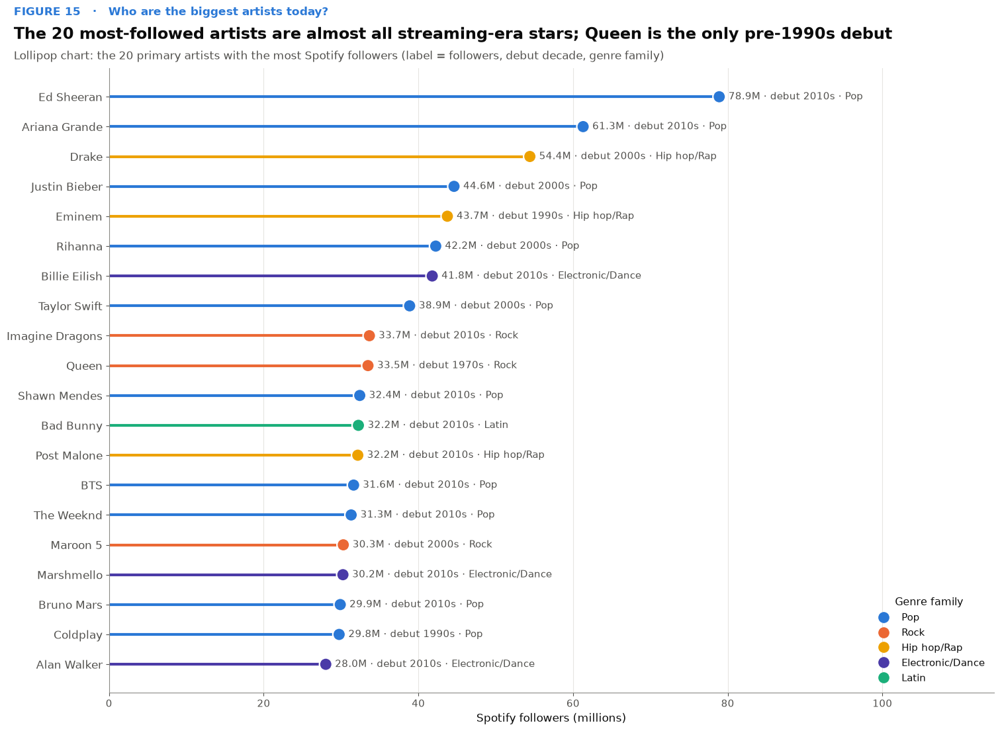

Saved -> figures/fig15_top_followed_lollipop.png
                                 artist      followers  debut_decade             genre
primary_artist_id                                                                     
6eUKZXaKkcviH0Ku9w2n3V       Ed Sheeran 78,900,234.000          2010               Pop
66CXWjxzNUsdJxJ2JdwvnR    Ariana Grande 61,301,006.000          2010               Pop
3TVXtAsR1Inumwj472S9r4            Drake 54,416,812.000          2000       Hip hop/Rap
1uNFoZAHBGtllmzznpCI3s    Justin Bieber 44,606,973.000          2000               Pop
7dGJo4pcD2V6oG8kP0tJRR           Eminem 43,747,833.000          1990       Hip hop/Rap
5pKCCKE2ajJHZ9KAiaK11H          Rihanna 42,244,011.000          2000               Pop
6qqNVTkY8uBg9cP3Jd7DAH    Billie Eilish 41,792,604.000          2010  Electronic/Dance
06HL4z0CvFAxyc27GXpf02     Taylor Swift 38,869,193.000          2000               Pop
53XhwfbYqKCa1cC15pYq2q  Imagine Dragons 33,665,795.000          2010             

In [49]:
top20 = arts.nlargest(20, 'followers').iloc[::-1]
fig, ax = plt.subplots(figsize=(15, 10), layout='constrained')
yy = np.arange(len(top20))
cols = [GENRE_COL.get(g, GENRE_COL['Other']) for g in top20['genre']]
ax.hlines(yy, 0, top20['followers'] / 1e6, color=cols, lw=3)
ax.scatter(top20['followers'] / 1e6, yy, color=cols, s=190, edgecolor='white', lw=1.6, zorder=3)
for y_, (aid, r) in zip(yy, top20.iterrows()):
    ax.text(r['followers'] / 1e6 + 1.2, y_, f"{r['followers'] / 1e6:.1f}M · debut {r['debut_decade']}s · {r['genre']}", va='center', fontsize=11, color=INK2)
ax.set_yticks(yy, top20['artist'], fontsize=12)
ax.set_xlim(0, top20['followers'].max() / 1e6 * 1.45)
ax.set_xlabel('Spotify followers (millions)')
ax.grid(axis='y', visible=False)
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=GENRE_COL[g], markersize=11, label=g)
                   for g in FAM_ORDER if g in set(top20['genre'])], loc='lower right', title='Genre family')
save_fig(fig, 15, 'top_followed_lollipop', 'The 20 most-followed artists are almost all streaming-era stars; Queen is the only pre-1990s debut',
         'Lollipop chart: the 20 primary artists with the most Spotify followers (label = followers, debut decade, genre family)',
         question='Who are the biggest artists today?')
print(top20[['artist', 'followers', 'debut_decade', 'genre']].iloc[::-1].to_string())

**What Figure 15 shows.** The most-followed artists are Ed Sheeran (78.9M), Ariana Grande (61.3M), Drake (54.4M), Justin Bieber (44.6M) and Eminem (43.7M). Of the top 20, **19 debuted (in this dataset) in the 1990s or later**. Queen, debuting in the 1970s, is the only exception. Pop dominates the list, followed by hip hop/rap, electronic/dance and rock.

**How this moves the story forward.** It answers "whose music appeals now?" at the artist level: today's attention is concentrated on streaming-era stars.

### Where do Spotify's popular artists come from? A world map

`artists.csv` has no country field. Many Spotify genre tags do name a place, though: "argentine rock", "k-pop", "uk drill", "atl hip hop", "nigerian pop". The cell below infers each artist's **country of origin from their genre tags**:
* About 110 countries have keyword lists made of nationalities, cities and regions, plus music styles tied to one country (e.g. tango → Argentina).
* A tag naming a place counts **twice as much** as a style word, so a Nigerian artist tagged "afro dancehall" is still placed in Nigeria, not Jamaica.
* Each artist gets the country with the highest score; artists with no place-related tag are left **unplaced**.

The map counts **popular artists**, defined as artist popularity ≥ 60 (roughly the top 0.6 % of the 1.16M artists in `artists.csv`).

> **Read with care.** This is a proxy. Global mainstream stars often carry only generic tags ("pop", "rap"), so they cannot be placed. That mostly affects US and UK pop artists such as Taylor Swift, Billie Eilish and Coldplay, so the map *understates* the US and UK. Counts are not adjusted for population or for the size of each country's Spotify market.

In [50]:
# ---- Infer an artist's country from genre tags (proxy; see the markdown above) ----
# Genre-tag keyword -> ISO-3 country. Keywords are matched as whole words (or exact multi-word phrases) inside a tag.
COUNTRY_KEYWORDS = {
    'USA': ['american', 'atl', 'atlanta', 'chicago', 'detroit', 'houston', 'memphis', 'nyc', 'new york', 'brooklyn', 'bronx',
            'boston', 'philly', 'philadelphia', 'texas', 'tx', 'nashville', 'new orleans', 'nola', 'miami', 'florida', 'louisiana',
            'los angeles', 'oakland', 'bay area', 'seattle', 'portland', 'minneapolis', 'baltimore', 'dc', 'virginia',
            'ohio', 'kentucky', 'tennessee', 'alabama', 'mississippi', 'georgia', 'carolina', 'arkansas', 'oklahoma', 'kansas',
            'colorado', 'arizona', 'utah', 'michigan', 'wisconsin', 'pittsburgh', 'cleveland', 'cincinnati', 'denver', 'chicano',
            'dirty south', 'west coast', 'east coast', 'midwest', 'appalachian', 'tejano', 'cajun', 'zydeco', 'motown',
            'southern hip hop', 'crunk', 'hyphy', 'jersey', 'long island', 'indiana', 'iowa', 'missouri', 'st louis'],
    'GBR': ['uk', 'british', 'english', 'scottish', 'welsh', 'london', 'manchester', 'liverpool', 'birmingham', 'bristol',
            'glasgow', 'sheffield', 'leeds', 'brighton', 'grime', 'northern irish'],
    'CAN': ['canadian', 'quebec', 'quebecois', 'toronto', 'montreal', 'vancouver', 'alberta'],
    'MEX': ['mexican', 'mexicana', 'norteno', 'banda', 'corrido', 'corridos', 'ranchera', 'grupera', 'duranguense', 'tijuana', 'monterrey'],
    'BRA': ['brazilian', 'brasil', 'mpb', 'sertanejo', 'pagode', 'forro', 'axe', 'samba', 'bossa nova', 'funk carioca', 'baile funk',
            'gaucha', 'piseiro', 'arrocha', 'brega'],
    'ARG': ['argentine', 'argentino', 'argentina', 'tango', 'cuarteto', 'rock nacional'],
    'COL': ['colombian', 'colombiano', 'vallenato', 'champeta'],
    'CHL': ['chilean', 'chileno'], 'PER': ['peruvian', 'peruano'], 'VEN': ['venezuelan', 'venezolano'],
    'CUB': ['cuban', 'cubano'], 'DOM': ['dominican', 'dominicano', 'bachata', 'merengue', 'dembow'],
    'PRI': ['puerto rican', 'puertorriqueno', 'trap boricua', 'boricua'],
    'URY': ['uruguayan', 'uruguayo'], 'ECU': ['ecuadorian'], 'BOL': ['bolivian'], 'PRY': ['paraguayan'],
    'GTM': ['guatemalan'], 'CRI': ['costa rican'], 'PAN': ['panamanian'], 'SLV': ['salvadoran'], 'HND': ['honduran'],
    'JAM': ['jamaican', 'dancehall', 'roots reggae'], 'TTO': ['trinidadian', 'soca', 'calypso'], 'HTI': ['haitian', 'kompa'],
    'ESP': ['spanish', 'espanol', 'flamenco', 'catalan', 'galician', 'basque', 'andaluz', 'canario', 'rumba catalana'],
    'PRT': ['portuguese', 'fado'], 'FRA': ['french', 'francais', 'chanson', 'variete francaise', 'rap francais', 'breton'],
    'DEU': ['german', 'deutsch', 'schlager', 'neue deutsche', 'berlin', 'hamburg', 'munich', 'kolsche', 'volksmusik'],
    'ITA': ['italian', 'italiano', 'italiana', 'neapolitan', 'napoletana', 'canzone'], 'NLD': ['dutch', 'nederpop', 'levenslied'],
    'BEL': ['belgian', 'flemish'], 'CHE': ['swiss'], 'AUT': ['austrian', 'austropop'], 'IRL': ['irish'], 'ISL': ['icelandic'],
    'SWE': ['swedish', 'svensk', 'dansband'], 'NOR': ['norwegian'], 'DNK': ['danish'], 'FIN': ['finnish', 'suomi', 'iskelma'],
    'POL': ['polish', 'disco polo'], 'CZE': ['czech'], 'SVK': ['slovak'], 'HUN': ['hungarian'], 'ROU': ['romanian', 'manele'],
    'BGR': ['bulgarian', 'chalga'], 'GRC': ['greek', 'laiko', 'rebetiko', 'entechno'], 'SRB': ['serbian', 'turbo folk'],
    'HRV': ['croatian'], 'SVN': ['slovenian'], 'BIH': ['bosnian'], 'MKD': ['macedonian'], 'ALB': ['albanian'],
    'UKR': ['ukrainian'], 'RUS': ['russian', 'russkiy', 'shanson'], 'BLR': ['belarusian'], 'LTU': ['lithuanian'],
    'LVA': ['latvian'], 'EST': ['estonian'], 'TUR': ['turkish', 'turk', 'arabesk', 'anadolu'], 'ISR': ['israeli', 'hebrew', 'mizrahi'],
    'IRN': ['persian', 'iranian'], 'EGY': ['egyptian', 'mahraganat'], 'LBN': ['lebanese'], 'MAR': ['moroccan'], 'DZA': ['algerian', 'rai'],
    'TUN': ['tunisian'], 'SAU': ['saudi', 'khaliji'], 'IRQ': ['iraqi'], 'SYR': ['syrian'], 'PAK': ['pakistani', 'urdu', 'qawwali'],
    'IND': ['indian', 'bollywood', 'filmi', 'punjabi', 'bhangra', 'desi', 'tamil', 'telugu', 'kannada', 'malayalam', 'bengali',
            'marathi', 'gujarati', 'hindi', 'carnatic', 'hindustani', 'kollywood', 'tollywood', 'mollywood', 'assamese', 'odia'],
    'BGD': ['bangladeshi'], 'LKA': ['sri lankan', 'sinhala'], 'NPL': ['nepali'],
    'CHN': ['chinese', 'mandopop', 'c-pop'], 'HKG': ['cantopop', 'hong kong'], 'TWN': ['taiwan', 'taiwanese', 'hokkien'],
    'JPN': ['japanese', 'j-pop', 'j-rock', 'j-rap', 'j-idol', 'anime', 'enka', 'shibuya-kei', 'vocaloid', 'kayokyoku', 'visual kei'],
    'KOR': ['korean', 'k-pop', 'k-rap', 'k-indie', 'k-rock', 'trot'], 'THA': ['thai', 'luk thung', 'mor lam'],
    'VNM': ['vietnamese', 'v-pop'], 'IDN': ['indonesian', 'dangdut', 'sundanese', 'javanese'], 'MYS': ['malaysian', 'malay'],
    'PHL': ['pinoy', 'filipino', 'opm', 'tagalog'], 'SGP': ['singaporean'], 'KHM': ['cambodian'], 'MNG': ['mongolian'],
    'AUS': ['australian', 'aussie'], 'NZL': ['nz', 'new zealand', 'kiwi', 'maori'],
    'NGA': ['nigerian', 'afrobeats', 'naija', 'yoruba', 'igbo'], 'GHA': ['ghanaian', 'highlife', 'azonto'],
    'ZAF': ['south african', 'amapiano', 'kwaito', 'gqom', 'afrikaans'], 'KEN': ['kenyan', 'gengetone', 'benga'],
    'TZA': ['tanzanian', 'bongo flava'], 'COD': ['congolese', 'soukous', 'rumba congolaise'], 'SEN': ['senegalese', 'mbalax'],
    'MLI': ['malian'], 'ETH': ['ethiopian'], 'CMR': ['cameroonian'], 'CIV': ['ivorian', 'coupe-decale'], 'AGO': ['angolan', 'kizomba', 'kuduro'],
    'ZWE': ['zimbabwean'], 'UGA': ['ugandan'], 'CPV': ['cape verdean'], 'KAZ': ['kazakh'], 'UZB': ['uzbek'], 'AZE': ['azerbaijani'],
    'GEO': ['georgian'], 'ARM': ['armenian'], 'ARE': ['emirati'], 'KWT': ['kuwaiti'],
}

# Style keywords say "music typical of a country" but not where the artist is from, so they get half the weight of
# nationality / place words (e.g. a Nigerian artist tagged 'afro dancehall' should still be placed in Nigeria).
STYLE_WORDS = {'dancehall', 'roots reggae', 'soca', 'calypso', 'kompa', 'flamenco', 'fado', 'chanson', 'schlager', 'tango', 'cuarteto',
               'bachata', 'merengue', 'dembow', 'samba', 'bossa nova', 'mpb', 'sertanejo', 'pagode', 'forro', 'axe', 'funk carioca',
               'baile funk', 'piseiro', 'arrocha', 'brega', 'banda', 'corrido', 'corridos', 'ranchera', 'norteno', 'grupera', 'duranguense',
               'vallenato', 'champeta', 'dangdut', 'highlife', 'azonto', 'amapiano', 'kwaito', 'gqom', 'kizomba', 'kuduro', 'soukous',
               'mbalax', 'afrobeats', 'bhangra', 'filmi', 'bollywood', 'qawwali', 'carnatic', 'hindustani', 'enka', 'anime', 'vocaloid',
               'kayokyoku', 'visual kei', 'shibuya-kei', 'trot', 'grime', 'motown', 'crunk', 'hyphy', 'tejano', 'cajun', 'zydeco', 'rai',
               'arabesk', 'laiko', 'rebetiko', 'entechno', 'chalga', 'manele', 'turbo folk', 'shanson', 'iskelma', 'dansband',
               'levenslied', 'nederpop', 'disco polo', 'cantopop', 'mandopop', 'luk thung', 'mor lam', 'bongo flava', 'gengetone',
               'benga', 'coupe-decale', 'mahraganat', 'khaliji', 'volksmusik', 'austropop', 'rumba catalana', 'rumba congolaise',
               'appalachian', 'dirty south', 'southern hip hop', 'west coast', 'east coast', 'midwest', 'country', 'bluegrass',
               'honky tonk', 'americana'}
COUNTRY_KEYWORDS['USA'] += ['dfw', 'country', 'bluegrass', 'honky tonk', 'americana', 'red dirt', 'outlaw', 'socal', 'norcal']
COUNTRY_NAMES = {'USA': 'United States', 'GBR': 'United Kingdom', 'KOR': 'South Korea', 'PRI': 'Puerto Rico', 'DOM': 'Dominican Rep.',
                 'COD': 'DR Congo', 'ARE': 'UAE', 'TTO': 'Trinidad & Tobago', 'NZL': 'New Zealand', 'ZAF': 'South Africa'}


def kw_regex(words):
    """One whole-word regex for a list of keywords (longest first, so multi-word phrases win)."""
    return re.compile(r'(?<![\w-])(' + '|'.join(sorted((re.escape(k) for k in words), key=len, reverse=True)) + r')(?![\w-])')

PLACE_RX = {iso: kw_regex([k for k in kws if k not in STYLE_WORDS]) for iso, kws in COUNTRY_KEYWORDS.items()}
STYLE_RX = {iso: kw_regex([k for k in kws if k in STYLE_WORDS]) for iso, kws in COUNTRY_KEYWORDS.items() if any(k in STYLE_WORDS for k in kws)}

def tag_scores(tag):
    """Country scores for one genre tag: 2 for a place/nationality word, 1 for a country-specific style word."""
    out = Counter()
    for iso, rx_ in PLACE_RX.items():
        if rx_.search(tag):
            out[iso] += 2
    for iso, rx_ in STYLE_RX.items():
        if rx_.search(tag):
            out[iso] += 1
    return out

TAG_SCORES = {g_: tag_scores(g_) for g_ in a['genres'].explode().dropna().unique()}

def infer_country(tags):
    total = Counter()
    for g_ in tags:
        total.update(TAG_SCORES.get(g_, {}))
    return total.most_common(1)[0][0] if total else None

a['country'] = a['genres'].map(infer_country)
popular = a[a['popularity'] >= 60]
placed = popular[popular['country'].notna()]
print(f"Artists with genre tags: {(a['genres'].str.len() > 0).sum():,}; placed in a country: {a['country'].notna().sum():,}")
print(f"Popular artists (popularity >= 60): {len(popular):,}; placed: {len(placed):,} ({len(placed) / len(popular):.0%}) in {placed['country'].nunique()} countries")
for n in ['Drake', 'Ed Sheeran', 'BTS', 'J Balvin', 'Burna Boy', 'Arijit Singh', 'Anitta', 'Rammstein', 'Taylor Swift']:
    r_ = a[a['name'] == n].nlargest(1, 'followers')
    print(f"  spot check: {n:<13} -> {r_['country'].iloc[0] if len(r_) else 'n/a'}")

Artists with genre tags: 305,595; placed in a country: 143,553
Popular artists (popularity >= 60): 7,589; placed: 4,268 (56%) in 72 countries
  spot check: Drake         -> CAN
  spot check: Ed Sheeran    -> GBR
  spot check: BTS           -> KOR
  spot check: J Balvin      -> COL
  spot check: Burna Boy     -> NGA
  spot check: Arijit Singh  -> IND
  spot check: Anitta        -> BRA
  spot check: Rammstein     -> DEU
  spot check: Taylor Swift  -> nan


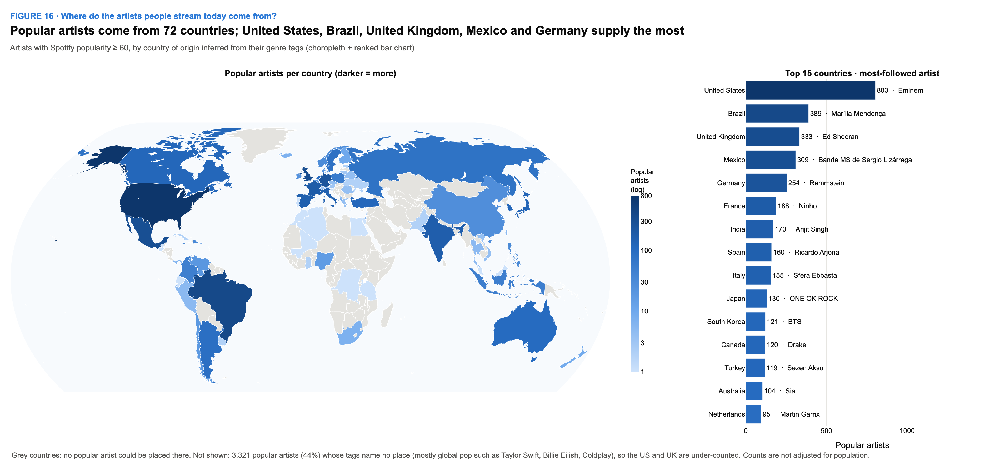

Saved -> figures/fig16_popular_artist_map.png (interactive: figures/fig16_popular_artist_map.html)


| country   | name           |   popular_artists |   pct_popular | top_artists                                                     |
|:----------|:---------------|------------------:|--------------:|:----------------------------------------------------------------|
| USA       | United States  |               803 |           4.8 | Eminem, Post Malone, XXXTENTACION                               |
| BRA       | Brazil         |               389 |           6.4 | Marília Mendonça, Jorge & Mateus, Zé Neto & Cristiano           |
| GBR       | United Kingdom |               333 |           3.9 | Ed Sheeran, Adele, Dua Lipa                                     |
| MEX       | Mexico         |               309 |           8.7 | Banda MS de Sergio Lizárraga, Enrique Iglesias, Cartel De Santa |
| DEU       | Germany        |               254 |           3.7 | Rammstein, Zedd, Scorpions                                      |
| FRA       | France         |               188 |           4.1 | Ninho, PNL, Niska                                               |
| IND       | India          |               170 |           4.3 | Arijit Singh, Neha Kakkar, Badshah                              |
| ESP       | Spain          |               160 |           3.4 | Ricardo Arjona, Alejandro Sanz, ROSALÍA                         |
| ITA       | Italy          |               155 |           3.0 | Sfera Ebbasta, Capo Plaza, Ghali                                |
| JPN       | Japan          |               130 |           2.1 | ONE OK ROCK, Official HIGE DANdism, Aimyon                      |
| KOR       | South Korea    |               121 |           5.4 | BTS, BLACKPINK, TWICE                                           |
| CAN       | Canada         |               120 |           2.8 | Drake, Justin Bieber, Shawn Mendes                              |
| TUR       | Turkey         |               119 |           5.1 | Sezen Aksu, Ezhel, Ahmet Kaya                                   |
| AUS       | Australia      |               104 |           3.4 | Sia, AC/DC, Rita Ora                                            |
| NLD       | Netherlands    |                95 |           3.1 | Martin Garrix, Tiësto, Armin van Buuren                         |

In [51]:
from plotly.subplots import make_subplots
ISO_NAMES = dict(zip(px.data.gapminder()['iso_alpha'], px.data.gapminder()['country'])) | COUNTRY_NAMES | {
    'RUS': 'Russia', 'TWN': 'Taiwan', 'HKG': 'Hong Kong', 'UKR': 'Ukraine', 'BLR': 'Belarus', 'EST': 'Estonia', 'LVA': 'Latvia',
    'LTU': 'Lithuania', 'MKD': 'North Macedonia', 'ARM': 'Armenia', 'GEO': 'Georgia', 'AZE': 'Azerbaijan', 'KAZ': 'Kazakhstan',
    'UZB': 'Uzbekistan', 'CPV': 'Cape Verde', 'IRN': 'Iran', 'SYR': 'Syria', 'VNM': 'Vietnam', 'KOR': 'South Korea', 'CZE': 'Czechia'}
by_c = (placed.sort_values('followers', ascending=False).groupby('country')
        .agg(popular_artists=('id', 'size'), top_artists=('name', lambda s: ', '.join(s.head(3)))))
by_c['all_tagged'] = a.groupby('country').size()
by_c['pct_popular'] = by_c['popular_artists'] / by_c['all_tagged'] * 100
by_c['log_n'] = np.log10(by_c['popular_artists'])
by_c['name'] = [ISO_NAMES.get(c, c) for c in by_c.index]
by_c = by_c.sort_values('popular_artists', ascending=False)

ticks = [1, 3, 10, 30, 100, 300, 800]
BLUES = [[0, '#cde2fb'], [0.35, '#6da7ec'], [0.7, '#256abf'], [1, '#0d366b']]
pmap = make_subplots(rows=1, cols=2, column_widths=[0.72, 0.28], horizontal_spacing=0.14,
                     specs=[[{'type': 'geo'}, {'type': 'bar'}]],
                     subplot_titles=('<b>Popular artists per country (darker = more)</b>', '<b>Top 15 countries · most-followed artist</b>'))
pmap.add_trace(go.Choropleth(
    locations=by_c.index, z=by_c['log_n'], zmin=0, zmax=np.log10(800), colorscale=BLUES, marker_line_color='white', marker_line_width=0.6,
    customdata=np.stack([by_c['name'], by_c['popular_artists'], by_c['top_artists'], by_c['pct_popular']], axis=1),
    hovertemplate='<b>%{customdata[0]}</b><br>%{customdata[1]} popular artists<br>Biggest: %{customdata[2]}'
                  '<br>%{customdata[3]:.1f}% of its tagged artists are popular<extra></extra>',
    colorbar=dict(title=dict(text='Popular<br>artists<br>(log)', font=dict(size=13), side='top'), tickvals=np.log10(ticks), ticktext=[str(t) for t in ticks],
                  len=0.62, thickness=16, x=0.635, y=0.45)), row=1, col=1)
t15 = by_c.head(15).iloc[::-1]
pmap.add_trace(go.Bar(
    x=t15['popular_artists'], y=t15['name'], orientation='h', marker=dict(color=t15['log_n'], colorscale=BLUES, cmin=0, cmax=np.log10(800)),
    text=[f"{n}  ·  {t.split(', ')[0]}" for n, t in zip(t15['popular_artists'], t15['top_artists'])], textposition='outside',
    textfont=dict(size=13), cliponaxis=False, hoverinfo='skip', showlegend=False), row=1, col=2)
pmap.update_xaxes(range=[0, t15['popular_artists'].max() * 1.8], showgrid=True, gridcolor='#e6e5e1', title_text='Popular artists',
                  row=1, col=2)
pmap.update_yaxes(tickfont=dict(size=13), row=1, col=2)
pmap.update_geos(projection_type='natural earth', showland=True, landcolor='#e4e3df', showcountries=True, countrycolor='white',
                 showocean=True, oceancolor='#f7fafd', showframe=False, lataxis_range=[-58, 85], showcoastlines=False)
title_html = ("<span style='font-size:16px;color:#2a78d6'><b>FIGURE 16 · Where do the artists people stream today come from?</b></span><br>"
              f"<b>Popular artists come from {placed['country'].nunique()} countries; {', '.join(by_c['name'].head(4))} and {by_c['name'].iloc[4]} supply the most</b><br>"
              "<span style='font-size:15px;color:#52514e'>Artists with Spotify popularity ≥ 60, by country of origin inferred from their genre tags "
              "(choropleth + ranked bar chart)</span>")
pmap.update_layout(title=dict(text=title_html, x=0.01, xanchor='left', y=0.96, font=dict(size=23, color='#0b0b0b')),
                   width=1900, height=900, margin=dict(l=20, r=40, t=150, b=90), paper_bgcolor='white', plot_bgcolor='white',
                   font=dict(family='Arial, Helvetica, sans-serif', size=13, color='#0b0b0b'))
pmap.add_annotation(x=0.0, y=-0.1, xref='paper', yref='paper', xanchor='left', showarrow=False, font=dict(size=14, color='#52514e'),
                    text=f"Grey countries: no popular artist could be placed there. Not shown: {len(popular) - len(placed):,} popular artists "
                         f"({1 - len(placed) / len(popular):.0%}) whose tags name no place (mostly global pop such as Taylor Swift, Billie Eilish, Coldplay), "
                         "so the US and UK are under-counted. Counts are not adjusted for population.")
map_png = FIG_DIR / 'fig16_popular_artist_map.png'
pmap.write_image(map_png, width=1900, height=900, scale=2)
pmap.write_html(FIG_DIR / 'fig16_popular_artist_map.html', include_plotlyjs='cdn')
display(IPImage(filename=str(map_png), width=1150))
print(f'Saved -> {map_png} (interactive: figures/fig16_popular_artist_map.html)')
md_table(by_c.head(15)[['name', 'popular_artists', 'pct_popular', 'top_artists']], floatfmt=',.1f')

**What Figure 16 shows.** Of 7,589 popular artists (popularity ≥ 60), 4,268 (56 %) could be placed in **72 countries**.
* **The leaders:** the **United States (803)**, **Brazil (389)**, the **United Kingdom (333)**, **Mexico (309)** and **Germany (254)**, followed by France, India, Spain, Italy, Japan, South Korea and Canada.
* **Each country has its own stars:** Eminem and Post Malone (US), Marília Mendonça and the sertanejo duos (Brazil), Ed Sheeran and Adele (UK), Banda MS (Mexico), Rammstein (Germany), Arijit Singh (India) and BTS (South Korea).
* **Strong home markets:** Mexico (8.7 % of its tagged artists are popular), Brazil (6.4 %) and South Korea (5.4 %) produce popular artists at a higher rate than the US (4.8 %) or the UK (3.9 %).
* **Coverage gaps:** large parts of Africa, the Middle East and Central Asia are grey or very light, reflecting both Spotify's market reach and the genre-tag coverage.

**Caveats.** The country is inferred from genre tags, so 44 % of popular artists (mostly global English-language pop) cannot be placed, and the US and UK are under-counted. A few placements follow the *style* of the tags rather than the artist's birthplace; for example, Guatemalan singer Ricardo Arjona is tagged as Spanish-language pop and lands in Spain.

**How this moves the story forward.** It adds geography to the artist story. Spotify-era popularity is not only Anglo-American: Brazil, Mexico, Germany, India and Korea each have large home-grown audiences. This matches the rise of Latin and K-pop artists in the collaboration network (Figure 14) and among today's hits.

Figure 17 is a **heatmap** of the genre mix of new artists in every debut decade: each row shows what share of that decade's newly debuting (genre-tagged) artists came from each family.

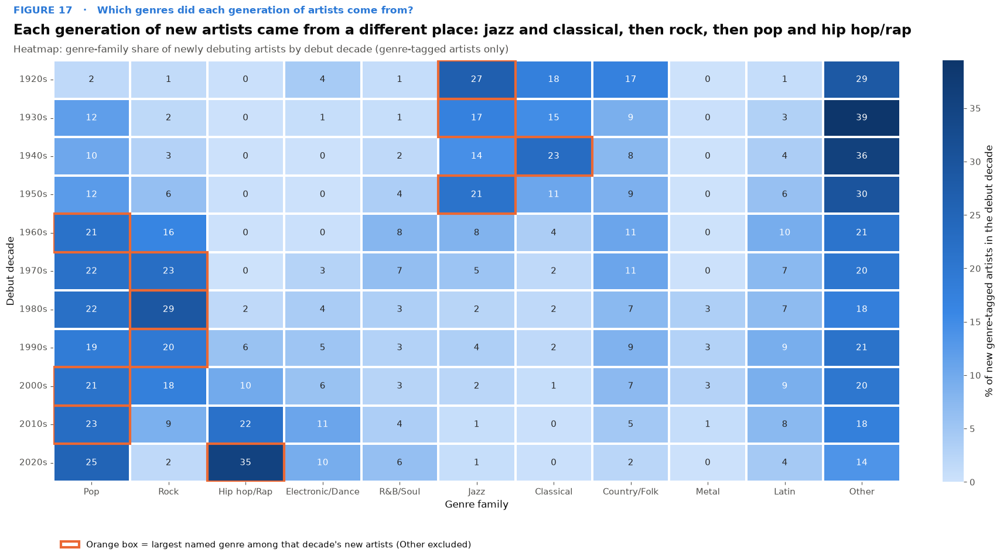

Saved -> figures/fig17_debut_decade_genre_heatmap.png


In [52]:
hm1 = pd.crosstab(tag['debut_decade'], tag['genre_family'], normalize='index') * 100
hm1 = hm1[[f for f in FAM_ORDER if f in hm1.columns]]
hm1.index = [f'{d}s' for d in hm1.index]
fig, ax = plt.subplots(figsize=(17, 8.5), layout='constrained')
sns.heatmap(hm1, cmap=SEQ, vmin=0, vmax=hm1.values.max(), annot=True, fmt='.0f', annot_kws={'fontsize': 11}, linewidths=1.5, linecolor='white',
            cbar_kws={'label': '% of new genre-tagged artists in the debut decade'}, ax=ax)
for i, d in enumerate(hm1.index):
    j = int(np.argmax(hm1.loc[d].drop('Other', errors='ignore').values))
    ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor=CAT[1], lw=3))
ax.set_xlabel('Genre family')
ax.set_ylabel('Debut decade')
ax.tick_params(axis='y', rotation=0)
ax.legend(handles=[Patch(facecolor='white', edgecolor=CAT[1], lw=3, label='Orange box = largest named genre among that decade\'s new artists (Other excluded)')],
          loc='upper left', bbox_to_anchor=(0, -0.12))
save_fig(fig, 17, 'debut_decade_genre_heatmap', 'Each generation of new artists came from a different place: jazz and classical, then rock, then pop and hip hop/rap',
         'Heatmap: genre-family share of newly debuting artists by debut decade (genre-tagged artists only)',
         question='Which genres did each generation of artists come from?')

**What Figure 17 shows.** Excluding "Other", the largest genre among each decade's new artists changes over time.
* **1920s and 1950s:** jazz (27 % and 21 %).
* **1940s:** classical (23 %).
* **1960s:** pop (21 %).
* **1970s–80s:** rock (23 % and 29 %).
* **2000s–2010s:** pop (21–23 %), with hip hop/rap close behind in the 2010s (22 %).
* **2020s:** hip hop/rap (35 %).

**How this moves the story forward.** It summarises the generational turnover of artists in a single picture, and it links the artist story to the sound story that follows.

> ### Chapter 1 Takeaways: The Artists
> * **The artist population exploded.** New debuts rose from about 61 a year in the 1920s to about 2,260 a year by 2018 (Figure 8). Output became less concentrated: the Gini of tracks per artist fell from 0.77 to 0.57 (Figure 10).
> * **Collaboration came back.** The share of multi-artist tracks went from 8.5 % in 1990 to 36.3 % in 2020 (Figure 9). The streaming-era collaboration web is anchored by Latin/reggaeton hubs such as Farruko, Ozuna and Bad Bunny (Figure 14).
> * **New artists came from new genres, and fame went to recent stars.** Hip hop/rap rose from 0 % of new artists in the 1970s to 22 % in the 2010s (Figure 13). 19 of the 20 most-followed artists debuted in the 1990s or later (Figure 15). Popular artists come from 72 countries, led by the US, Brazil, the UK, Mexico and Germany (Figure 16).

<a id="chapter-2"></a>
## Chapter 2: The Sound and the Creation. How is music made, and how does it sound?

**The story in this chapter.** Recording moved from microphones in a room (acoustic, quiet, often instrumental, sometimes live) to multitrack studios, electric instruments, digital production and heavy mastering (electronic, loud, dense). This chapter follows the features that capture *how a recording is made*: **acousticness, instrumentalness, loudness, energy, liveness**, and **duration** as part of the format.

In [53]:
SOUND = ['acousticness', 'energy', 'loudness', 'instrumentalness', 'liveness', 'duration_min']
FORMAT_ERAS = [(1920, 1948, '78-rpm shellac'), (1948, 1982, 'Vinyl LP'), (1982, 2008, 'CD & digital download'),
               (2008, 2021.6, 'Streaming\n(normalised loudness)')]

def trend_tests(df, cols):
    """Spearman correlation with year, Kruskal–Wallis across decades (η²_H) and ANOVA η² for each column."""
    rows = []
    for v in cols:
        sub = df[['release_year', 'decade', v]].dropna()
        y = sub[v].astype('float64')
        rho, p_rho = stats.spearmanr(sub['release_year'], y)
        groups = [y[sub['decade'] == d].to_numpy() for d in sorted(sub['decade'].unique())]
        H, p_h = stats.kruskal(*groups)
        n, k = len(y), len(groups)
        gm = y.mean()
        eta2 = sum(len(g) * (g.mean() - gm) ** 2 for g in groups) / ((y - gm) ** 2).sum()
        eta2_h = (H - k + 1) / (n - k)
        rows.append({'feature': v, 'Spearman ρ with year': rho, 'p (ρ)': p_rho, 'Kruskal H': H, 'p (H)': p_h,
                     'η²_H': eta2_h, 'ANOVA η²': eta2,
                     'size': 'large' if eta2_h >= 0.14 else 'medium' if eta2_h >= 0.06 else 'small' if eta2_h >= 0.01 else 'negligible'})
    return pd.DataFrame(rows).set_index('feature')

def show_tests(tbl):
    out = tbl.copy()
    for c in ['p (ρ)', 'p (H)']:
        out[c] = out[c].map(lambda p: '< 1e-300' if p == 0 else f'{p:.1e}')
    md_table(out, floatfmt=',.3f')

def yearly_band(df, col):
    """Yearly mean with a 95% confidence band."""
    g = df.groupby('release_year')[col].agg(['mean', 'std', 'count', 'median'])
    g['lo'] = g['mean'] - 1.96 * g['std'] / np.sqrt(g['count'])
    g['hi'] = g['mean'] + 1.96 * g['std'] / np.sqrt(g['count'])
    return g
print('Chapter 2 sound features:', SOUND)

Chapter 2 sound features: ['acousticness', 'energy', 'loudness', 'instrumentalness', 'liveness', 'duration_min']


### Univariate: the shape of each sound feature

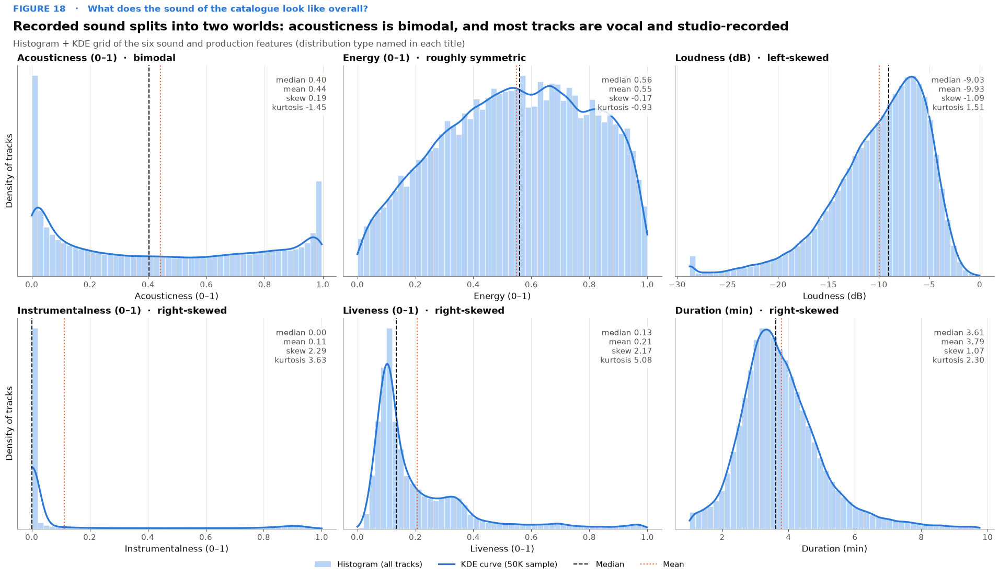

Saved -> figures/fig18_sound_distributions.png


In [54]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10), layout='constrained')
for ax, v in zip(axes.flat, SOUND):
    s = music[v].dropna().astype('float64')
    ax.hist(s, bins=50, density=True, color='#b7d3f6', edgecolor='white', linewidth=0.4)
    smp = s.sample(min(len(s), 50_000), random_state=SEED)
    xs = np.linspace(s.min(), s.max(), 300)
    ax.plot(xs, stats.gaussian_kde(smp, bw_method=0.1)(xs), color=CAT[0], lw=2.4)
    ax.axvline(s.median(), color=INK, lw=1.4, ls='--')
    ax.axvline(s.mean(), color=CAT[1], lw=1.6, ls=':')
    ax.set_title(f'{LABELS[v]}  ·  {hist_shape(s)}', fontsize=13)
    ax.text(0.97, 0.95, f'median {s.median():.2f}\nmean {s.mean():.2f}\nskew {s.skew():.2f}\nkurtosis {s.kurt():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10.5, color=INK2, bbox=dict(facecolor='white', edgecolor='none', alpha=0.85))
    ax.set_yticks([])
    ax.set_xlabel(LABELS[v])
for ax in axes[:, 0]:
    ax.set_ylabel('Density of tracks')
fig.legend(handles=[Patch(facecolor='#b7d3f6', label='Histogram (all tracks)'), Line2D([], [], color=CAT[0], lw=2.4, label='KDE curve (50K sample)'),
                    Line2D([], [], color=INK, lw=1.4, ls='--', label='Median'), Line2D([], [], color=CAT[1], lw=1.6, ls=':', label='Mean')],
           loc='outside lower center', ncol=4)
save_fig(fig, 18, 'sound_distributions', 'Recorded sound splits into two worlds: acousticness is bimodal, and most tracks are vocal and studio-recorded',
         'Histogram + KDE grid of the six sound and production features (distribution type named in each title)',
         question='What does the sound of the catalogue look like overall?')

**What Figure 18 shows.**
* **Acousticness is bimodal:** most songs are either clearly electric (near 0) or clearly acoustic (near 1).
* **Energy is roughly symmetric** and spread across the whole range.
* **Loudness is left-skewed:** most tracks sit between −12 and −5 dB, with a quiet tail.
* **Instrumentalness, liveness and duration are right-skewed:** most songs are vocal, studio-recorded and 3–4 minutes long.

**How this moves the story forward.** The bimodal acousticness histogram is the first sign of the chapter's story: recorded music lives in two worlds, acoustic and electric. The following charts show that the balance between them flipped over time.

### Bivariate: how the sound changed over time

Figure 19 is a **ridgeline plot** of three features side by side. Each ridge is one decade's full distribution (oldest at the top), scaled to its own peak, with the median marked. This shows whether the *whole* distribution shifted, not just the average.

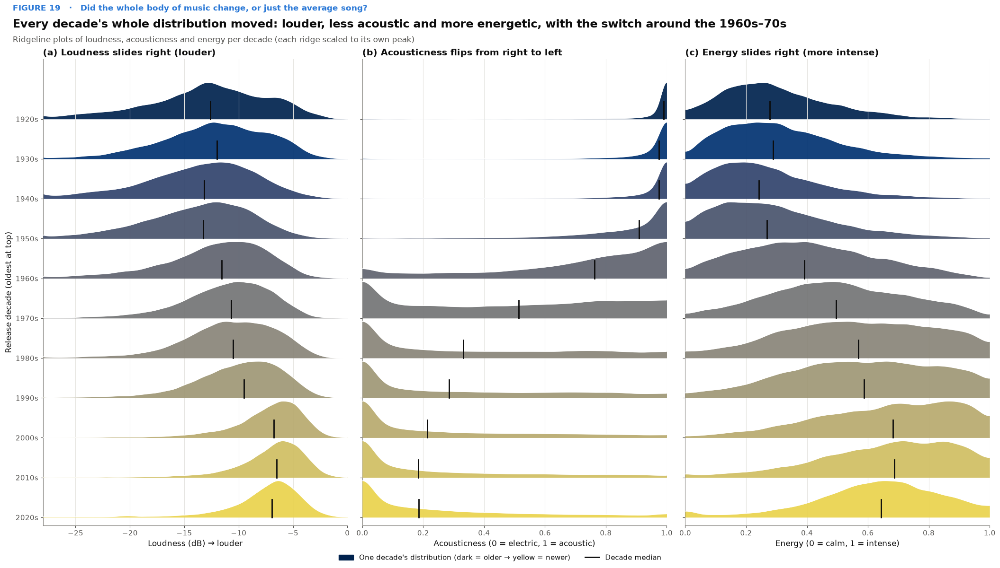

Saved -> figures/fig19_sound_ridgelines.png


In [55]:
def kde_ridges(ax, col, grid, bounded, label):
    for i, lbl in enumerate(DECADE_LABELS):
        s = music.loc[music['decade_label'] == lbl, col].dropna().astype(float)
        smp = s.sample(min(len(s), 15_000), random_state=SEED)
        k = stats.gaussian_kde(smp, bw_method=0.12)
        dens = k(grid) + (k(-grid) + k(2 - grid) if bounded else 0)
        base = len(DECADE_LABELS) - 1 - i
        ys_ = base + dens / dens.max() * 0.92
        ax.fill_between(grid, base, ys_, color=DEC_PAL[lbl], alpha=0.92, lw=0, zorder=i)
        ax.plot(grid, ys_, color='white', lw=1.1, zorder=i)
        ax.plot([s.median()] * 2, [base, base + 0.45], color=INK, lw=2, zorder=i + 0.5)
    ax.set_yticks(range(len(DECADE_LABELS)), DECADE_LABELS[::-1])
    ax.set_ylim(-0.2, len(DECADE_LABELS) + 0.5)
    ax.set_xlim(grid.min(), grid.max())
    ax.set_xlabel(label)
    ax.grid(axis='y', visible=False)

fig, axes = plt.subplots(1, 3, figsize=(21, 11), layout='constrained', sharey=True)
kde_ridges(axes[0], 'loudness', np.linspace(-28, 0, 300), False, 'Loudness (dB) → louder')
kde_ridges(axes[1], 'acousticness', np.linspace(0, 1, 300), True, 'Acousticness (0 = electric, 1 = acoustic)')
kde_ridges(axes[2], 'energy', np.linspace(0, 1, 300), True, 'Energy (0 = calm, 1 = intense)')
axes[0].set_title('(a) Loudness slides right (louder)')
axes[1].set_title('(b) Acousticness flips from right to left')
axes[2].set_title('(c) Energy slides right (more intense)')
axes[0].set_ylabel('Release decade (oldest at top)')
fig.legend(handles=[Patch(color=DEC_PAL['1920s'], label='One decade\'s distribution (dark = older → yellow = newer)'),
                    Line2D([], [], color=INK, lw=2, label='Decade median')], loc='outside lower center', ncol=2)
save_fig(fig, 19, 'sound_ridgelines', 'Every decade\'s whole distribution moved: louder, less acoustic and more energetic, with the switch around the 1960s–70s',
         'Ridgeline plots of loudness, acousticness and energy per decade (each ridge scaled to its own peak)',
         question='Did the whole body of music change, or just the average song?')

**What Figure 19 shows.** In each ridgeline the whole distribution moves, not just the median.
* **Loudness:** slides right from about −13 dB (1940s–50s) to about −6.5 dB (2010s).
* **Acousticness:** flips from a tall peak at 1.0 (1920s–1950s) to a peak near 0 (1980s onward), passing through a flat, two-humped 1970s.
* **Energy:** moves from a peak near 0.25 to a broad peak near 0.7.

**How this moves the story forward.** It proves that the change in sound was a shift of the entire body of recorded music, not a few unusual tracks.

Figure 20 tells the story of the **loudness war**. The dots are each year's median loudness, the band is a 95 % confidence interval for that median, and the shaded backgrounds are the dominant **recording formats** of each period.

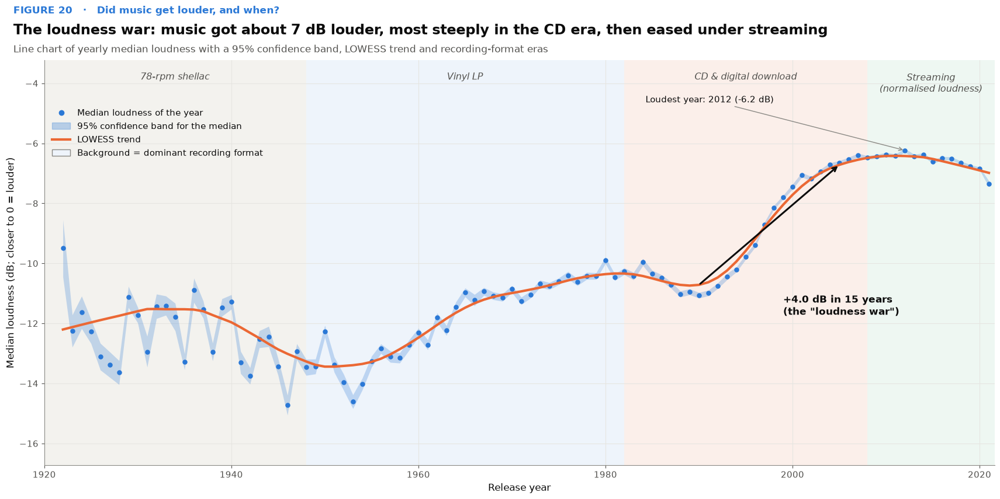

Saved -> figures/fig20_loudness_war.png
Median loudness by decade: {'1920s': -12.600000381469727, '1930s': -12.0, '1940s': -13.199999809265137, '1950s': -13.199999809265137, '1960s': -11.5, '1970s': -10.699999809265137, '1980s': -10.5, '1990s': -9.5, '2000s': -6.800000190734863, '2010s': -6.5, '2020s': -7.0}


In [56]:
lq = music.groupby('release_year')['loudness'].agg(med='median', q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75), n='size')
lq['ci'] = 1.57 * (lq['q3'] - lq['q1']) / np.sqrt(lq['n'])
lo_fit = lowess(lq['med'].values, lq.index.values, frac=0.15, return_sorted=True)
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
fmt_cols = ['#f3f2ee', '#eef4fb', '#fbefea', '#eef7f2']
for (a0, b0, lbl), c in zip(FORMAT_ERAS, fmt_cols):
    ax.axvspan(a0, b0, color=c, lw=0, zorder=0)
    ax.text((a0 + b0) / 2, 0.97, lbl, transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=11.5, fontstyle='italic', color=INK2)
ax.fill_between(lq.index, lq['med'] - lq['ci'], lq['med'] + lq['ci'], color=CAT[0], alpha=0.25, lw=0, zorder=2)
ax.scatter(lq.index, lq['med'], s=26, color=CAT[0], zorder=3)
ax.plot(lo_fit[:, 0], lo_fit[:, 1], color=CAT[1], lw=3, zorder=4)
fitS = pd.Series(lo_fit[:, 1], index=lo_fit[:, 0])
y90, y05 = fitS.loc[1990], fitS.loc[2005]
ax.annotate('', xy=(2005, y05), xytext=(1990, y90), arrowprops=dict(arrowstyle='->', color=INK, lw=2.2), zorder=6)
ax.text(1999, y90 - 0.3, f'+{y05 - y90:.1f} dB in 15 years\n(the "loudness war")', ha='left', va='top', fontsize=12.5, fontweight='bold')
pk = lq['med'].idxmax()
ax.annotate(f'Loudest year: {pk} ({lq.loc[pk, "med"]:.1f} dB)', xy=(pk, lq.loc[pk, 'med']), xytext=(pk - 14, lq.loc[pk, 'med'] + 1.6), ha='right',
            fontsize=11, arrowprops=dict(arrowstyle='->', color=MUTED))
ax.set_xlim(1920, 2021.6)
ax.set_ylim(lq['med'].min() - 2, lq['med'].max() + 3)
ax.set_xlabel('Release year')
ax.set_ylabel('Median loudness (dB; closer to 0 = louder)')
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=CAT[0], label='Median loudness of the year'),
                   Patch(color=CAT[0], alpha=0.3, label='95% confidence band for the median'),
                   Line2D([], [], color=CAT[1], lw=3, label='LOWESS trend'),
                   Patch(facecolor='#eef4fb', edgecolor=MUTED, label='Background = dominant recording format')],
          loc='upper left', bbox_to_anchor=(0, 0.9))
save_fig(fig, 20, 'loudness_war', 'The loudness war: music got about 7 dB louder, most steeply in the CD era, then eased under streaming',
         'Line chart of yearly median loudness with a 95% confidence band, LOWESS trend and recording-format eras',
         question='Did music get louder, and when?')
print('Median loudness by decade:', music.groupby('decade_label', observed=True)['loudness'].median().round(1).to_dict())

**What Figure 20 shows.** Median loudness hovered around −12 to −13 dB in the 78-rpm and early vinyl years, rose slowly to about −10.5 dB by 1980, then climbed sharply through the **CD and digital era**, gaining about 4 dB between 1990 and 2005 and peaking in **2012**. In the streaming era it eased slightly (about −7 dB in the 2020s), consistent with streaming services' loudness normalisation.

**How this moves the story forward.** It ties the biggest change in sound to how music was made and sold: each new format, especially the CD, rewarded louder mastering.

How are the sound features related? Figure 21 shows **correlation heatmaps** (Pearson for linear and Spearman for rank-based relationships) of the six sound features and release year. Outlined cells mark the strongest pairs (|r| ≥ 0.5).

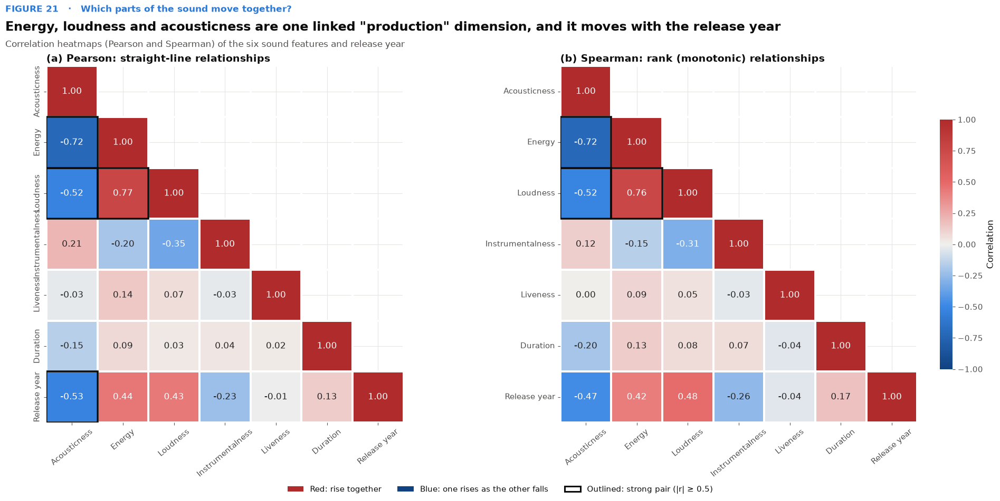

Saved -> figures/fig21_sound_correlations.png


|                                  |   spearman |   pearson |
|:---------------------------------|-----------:|----------:|
| ('loudness', 'energy')           |      0.764 |     0.770 |
| ('energy', 'acousticness')       |     -0.719 |    -0.721 |
| ('loudness', 'acousticness')     |     -0.516 |    -0.524 |
| ('release_year', 'loudness')     |      0.479 |     0.431 |
| ('release_year', 'acousticness') |     -0.474 |    -0.526 |
| ('release_year', 'energy')       |      0.419 |     0.444 |

In [57]:
CV = SOUND + ['release_year']
NICE = {c: LABELS[c].split(' (')[0] for c in CV}
cm_p = music[CV].astype('float64').corr(method='pearson')
cm_s = music[CV].astype('float64').corr(method='spearman')
mask = np.triu(np.ones_like(cm_p, dtype=bool), k=1)
fig, axes = plt.subplots(1, 2, figsize=(19, 8.5), layout='constrained')
for ax, cm, ttl in [(axes[0], cm_p, '(a) Pearson: straight-line relationships'), (axes[1], cm_s, '(b) Spearman: rank (monotonic) relationships')]:
    sns.heatmap(cm.rename(index=NICE, columns=NICE), mask=mask, cmap=DIV, vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'fontsize': 12},
                square=True, linewidths=1.5, linecolor='white', cbar=ax is axes[1], cbar_kws={'label': 'Correlation', 'shrink': 0.7}, ax=ax)
    for i in range(len(cm)):
        for j in range(i):
            if abs(cm.iloc[i, j]) >= 0.5:
                ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor=INK, lw=2.6, zorder=5))
    ax.set_title(ttl)
    ax.tick_params(axis='x', rotation=40)
fig.legend(handles=[Patch(facecolor='#b02b2b', label='Red: rise together'), Patch(facecolor='#104281', label='Blue: one rises as the other falls'),
                    Patch(facecolor='white', edgecolor=INK, lw=2.2, label='Outlined: strong pair (|r| ≥ 0.5)')], loc='outside lower center', ncol=3)
save_fig(fig, 21, 'sound_correlations', 'Energy, loudness and acousticness are one linked "production" dimension, and it moves with the release year',
         'Correlation heatmaps (Pearson and Spearman) of the six sound features and release year',
         question='Which parts of the sound move together?')
pairs = cm_s.where(np.tril(np.ones_like(cm_s, dtype=bool), k=-1)).stack().rename('spearman').to_frame()
pairs['pearson'] = cm_p.where(np.tril(np.ones_like(cm_p, dtype=bool), k=-1)).stack()
md_table(pairs.reindex(pairs['spearman'].abs().sort_values(ascending=False).index).head(6))

**What Figure 21 shows.** Three strong pairs (outlined) form one block: energy and loudness rise together (r ≈ +0.77), and both move against acousticness (−0.72 and −0.52). Release year belongs to the same block (+0.48 with loudness, −0.47 with acousticness, +0.42 with energy). Liveness and duration are nearly independent of everything else. Pearson and Spearman agree closely.

**How this moves the story forward.** It shows that "louder", "more energetic" and "less acoustic" are one production change, and that this change follows the calendar.

Figure 22 is a **paired line chart** of acoustic versus electric sound. Acousticness and energy are both 0–1 scores, so they share one axis, and the year in which the two lines cross marks the tipping point.

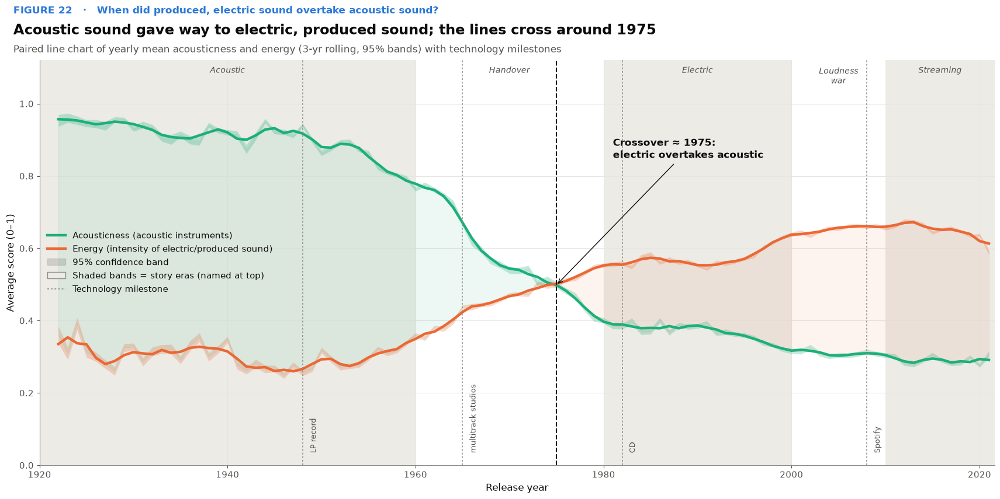

Saved -> figures/fig22_acoustic_vs_electric.png


In [58]:
ya, ye = yearly_band(music, 'acousticness'), yearly_band(music, 'energy')
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
for g, col, lbl in [(ya, CAT[2], 'Acousticness (acoustic instruments)'), (ye, CAT[1], 'Energy (intensity of electric/produced sound)')]:
    ax.fill_between(g.index, g['lo'], g['hi'], color=col, alpha=0.25, lw=0)
    ax.plot(g.index, g['mean'].rolling(3, center=True, min_periods=1).mean(), color=col, lw=3.2, label=lbl)
diff_ae = (ya['mean'] - ye['mean']).rolling(3, center=True, min_periods=1).mean()
cross = int(diff_ae[diff_ae < 0].index.min())
ax.fill_between(ya.index, ya['mean'], ye['mean'], where=ya['mean'] >= ye['mean'], color=CAT[2], alpha=0.08, interpolate=True)
ax.fill_between(ya.index, ya['mean'], ye['mean'], where=ya['mean'] < ye['mean'], color=CAT[1], alpha=0.08, interpolate=True)
ax.axvline(cross, color=INK, lw=1.5, ls='--')
ax.annotate(f'Crossover ≈ {cross}:\nelectric overtakes acoustic', xy=(cross, ye.loc[cross, 'mean']), xytext=(cross + 6, 0.85), fontsize=12.5,
            fontweight='bold', arrowprops=dict(arrowstyle='->', color=INK))
add_eras(ax, labels=True, short=True)
add_milestones(ax, items=[(1948, 'LP record'), (1965, 'multitrack studios'), (1982, 'CD'), (2008, 'Spotify')], y=0.03)
ax.set_xlim(1920, 2021.6)
ax.set_ylim(0, 1.12)
ax.set_xlabel('Release year')
ax.set_ylabel('Average score (0–1)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h + [Patch(color=MUTED, alpha=0.3, label='95% confidence band'), ERA_HANDLE, MILESTONE_HANDLE], loc='center left')
save_fig(fig, 22, 'acoustic_vs_electric', f'Acoustic sound gave way to electric, produced sound; the lines cross around {cross}',
         'Paired line chart of yearly mean acousticness and energy (3-yr rolling, 95% bands) with technology milestones',
         question='When did produced, electric sound overtake acoustic sound?')

**What Figure 22 shows.** In 1950 the average track scored 0.86 on acousticness and 0.32 on energy. The two lines converge through the 1960s and **cross in about 1975** (both about 0.50). By 2010 the positions are reversed (acousticness 0.30, energy 0.65). The crossover falls between the arrival of multitrack studios and the CD.

**How this moves the story forward.** It dates the turning point of the whole story: the mid-1970s, when produced, electric sound overtook acoustic sound for the average track.

Figure 23 uses **violin plots** for song length by decade (stratified random sample of 4,000 tracks per decade so that every decade gets equal visual weight; medians are computed on all tracks).

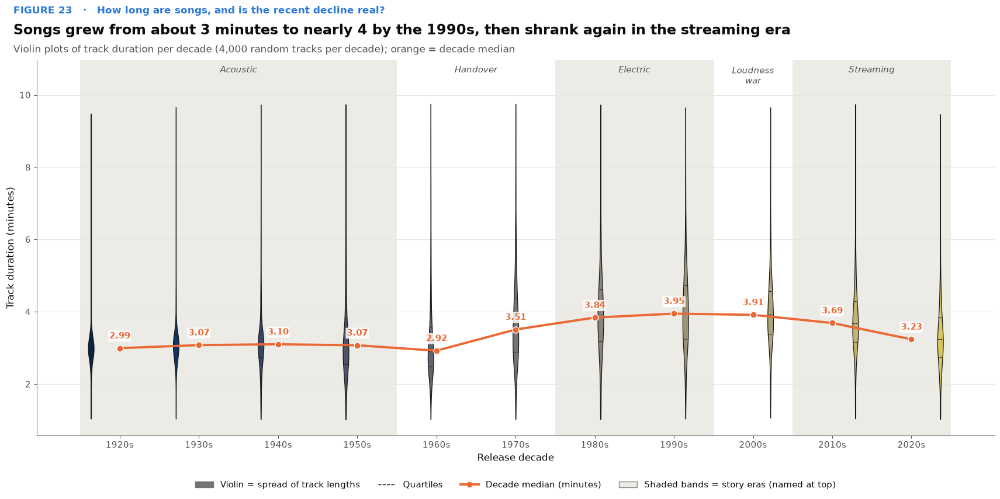

Saved -> figures/fig23_duration_violins.png
Longest mean duration: 2000 (4.09 min); 2010: 3.97; 2020: 3.42; 2021: 3.21


In [59]:
n_per = int(min(4000, music['decade_label'].value_counts().min()))
strat = music.groupby('decade_label', observed=True).sample(n=n_per, random_state=SEED)
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
sns.violinplot(data=strat, x='decade_label', y='duration_min', hue='decade_label', palette=DEC_PAL, legend=False, inner='quart', cut=0,
               density_norm='width', linewidth=0.9, ax=ax)
dmed_ = music.groupby('decade_label', observed=True)['duration_min'].median()
ax.plot(range(len(dmed_)), dmed_.values, color=CAT[1], lw=2.8, marker='o', markersize=8, markeredgecolor='white', zorder=10)
for i, v in enumerate(dmed_.values):
    ax.annotate(f'{v:.2f}', (i, v), xytext=(0, 12), textcoords='offset points', ha='center', fontsize=11, fontweight='bold', color=CAT[1],
                bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85), zorder=11)
add_eras_cat(ax, labels=True, fontsize=10.5, headroom=0.08, offset=-1)
ax.set_xlabel('Release decade')
ax.set_ylabel('Track duration (minutes)')
ax.legend(handles=[Patch(color=DEC_PAL['1970s'], label='Violin = spread of track lengths'), Line2D([], [], color=INK, ls='--', lw=1, label='Quartiles'),
                   Line2D([], [], color=CAT[1], lw=2.8, marker='o', label='Decade median (minutes)'), ERA_HANDLE], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
save_fig(fig, 23, 'duration_violins', 'Songs grew from about 3 minutes to nearly 4 by the 1990s, then shrank again in the streaming era',
         f'Violin plots of track duration per decade ({n_per:,} random tracks per decade); orange = decade median',
         question='How long are songs, and is the recent decline real?')
yr_dur = music.groupby('release_year')['duration_min'].mean()
print(f'Longest mean duration: {yr_dur.idxmax()} ({yr_dur.max():.2f} min); 2010: {yr_dur.loc[2010]:.2f}; 2020: {yr_dur.loc[2020]:.2f}; 2021: {yr_dur.loc[2021]:.2f}')

**What Figure 23 shows.** Median song length was about 3 minutes from the 1920s to the 1960s, the limit of a 78-rpm side and of early singles. It rose to 3.5 minutes in the 1970s and about 3.9 minutes in the 1990s. The mean duration peaked in **2000 (4.09 min)**, then fell to 3.97 (2010), **3.42 (2020)** and 3.21 (early 2021). The 2020s violin is visibly shorter.

**How this moves the story forward.** It shows how the *format* shaped the music. Long-playing formats allowed longer songs, and the streaming era, where every play counts, brought them back down.

### Statistical tests: how big are the changes in sound?

For each sound feature: **Spearman ρ** with release year (a monotonic trend), and **Kruskal–Wallis H** across decades with effect size **η²_H = (H − k + 1)/(n − k)**, plus ANOVA η² for comparison.

> **Why p-values are not the point.** With about 490,000 tracks, even a negligible difference has a p-value that rounds to zero. Significance only says an effect is not exactly zero. The **effect size** says how big it is: η² ≥ 0.01 small, ≥ 0.06 medium, ≥ 0.14 large; |ρ| ≥ 0.1 small, ≥ 0.3 moderate, ≥ 0.5 large.

In [60]:
tests_sound = trend_tests(music, SOUND)
show_tests(tests_sound)
tests_sound.to_csv(OUT_DIR / 'trend_tests_sound.csv')

| feature          |   Spearman ρ with year | p (ρ)    |   Kruskal H | p (H)    |   η²_H |   ANOVA η² | size       |
|:-----------------|-----------------------:|:---------|------------:|:---------|-------:|-----------:|:-----------|
| acousticness     |                 -0.474 | < 1e-300 | 149,106.046 | < 1e-300 |  0.302 |      0.309 | large      |
| energy           |                  0.419 | < 1e-300 | 103,123.930 | < 1e-300 |  0.209 |      0.214 | large      |
| loudness         |                  0.479 | < 1e-300 | 121,058.858 | < 1e-300 |  0.245 |      0.208 | large      |
| instrumentalness |                 -0.262 | < 1e-300 |  42,160.714 | < 1e-300 |  0.085 |      0.081 | medium     |
| liveness         |                 -0.043 | 1.1e-200 |   1,412.856 | 1.7e-297 |  0.003 |      0.001 | negligible |
| duration_min     |                  0.171 | < 1e-300 |  44,050.145 | < 1e-300 |  0.089 |      0.046 | medium     |

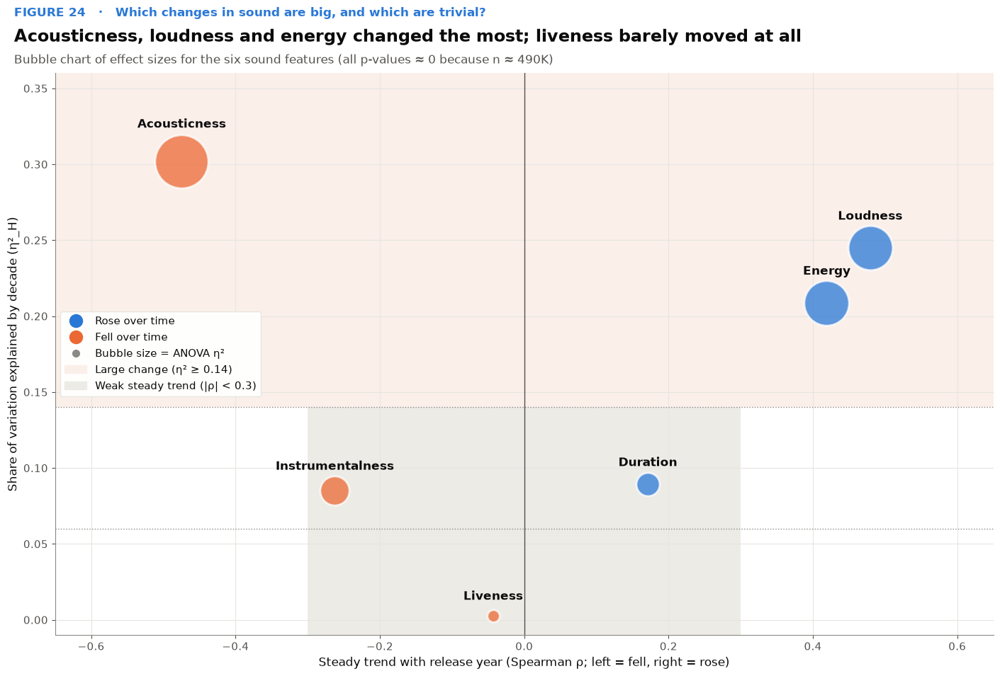

Saved -> figures/fig24_sound_effect_sizes.png


In [61]:
fig, ax = plt.subplots(figsize=(14, 8.5), layout='constrained')
ax.axvspan(-0.3, 0.3, color=ERA_SHADE, lw=0, zorder=0)
ax.axhspan(0.14, 0.36, color='#fbefea', lw=0, zorder=0)
for thr in (0.06, 0.14):
    ax.axhline(thr, color=MUTED, lw=1, ls=':')
ax.axvline(0, color=INK2, lw=1)
for f, r in tests_sound.iterrows():
    col = CAT[0] if r['Spearman ρ with year'] > 0 else CAT[1]
    ax.scatter(r['Spearman ρ with year'], r['η²_H'], s=r['ANOVA η²'] * 9000 + 150, color=col, alpha=0.75, edgecolor='white', lw=2, zorder=3)
    ax.annotate(LABELS[f].split(' (')[0], (r['Spearman ρ with year'], r['η²_H']), xytext=(0, 16 + r['ANOVA η²'] * 60), textcoords='offset points',
                ha='center', fontsize=12.5, fontweight='bold', zorder=4)
ax.set_xlim(-0.65, 0.65)
ax.set_ylim(-0.01, 0.36)
ax.set_xlabel('Steady trend with release year (Spearman ρ; left = fell, right = rose)')
ax.set_ylabel('Share of variation explained by decade (η²_H)')
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=CAT[0], markersize=13, label='Rose over time'),
                   Line2D([], [], marker='o', ls='none', color=CAT[1], markersize=13, label='Fell over time'),
                   Line2D([], [], marker='o', ls='none', color=MUTED, markersize=7, label='Bubble size = ANOVA η²'),
                   Patch(color='#fbefea', label='Large change (η² ≥ 0.14)'), Patch(color=ERA_SHADE, label='Weak steady trend (|ρ| < 0.3)')],
          loc='center left', frameon=True, framealpha=0.95, edgecolor=GRID)
save_fig(fig, 24, 'sound_effect_sizes', 'Acousticness, loudness and energy changed the most; liveness barely moved at all',
         'Bubble chart of effect sizes for the six sound features (all p-values ≈ 0 because n ≈ 490K)',
         question='Which changes in sound are big, and which are trivial?')

**What Figure 24 shows.**
* **Large change (top corners):** acousticness fell (η²_H = 0.30), while loudness (0.25) and energy (0.21) rose.
* **Medium change:** instrumentalness fell (0.085), and duration (0.089) rose and then fell.
* **Negligible:** liveness (0.003). The way music is recorded live versus in the studio barely changed on average.

**How this moves the story forward.** It ranks the changes so that the story leads with the biggest ones (acoustic → electric, quiet → loud, calm → energetic), instead of treating every statistically significant change as important.

### Multivariate: the whole sound in one picture, and the "kinds" of sound

Figure 25 is a **year × feature heatmap**. Each cell is that year's average, standardised across years (a z-score per row), so all six features share one colour scale. Red means above the feature's century average and blue means below.

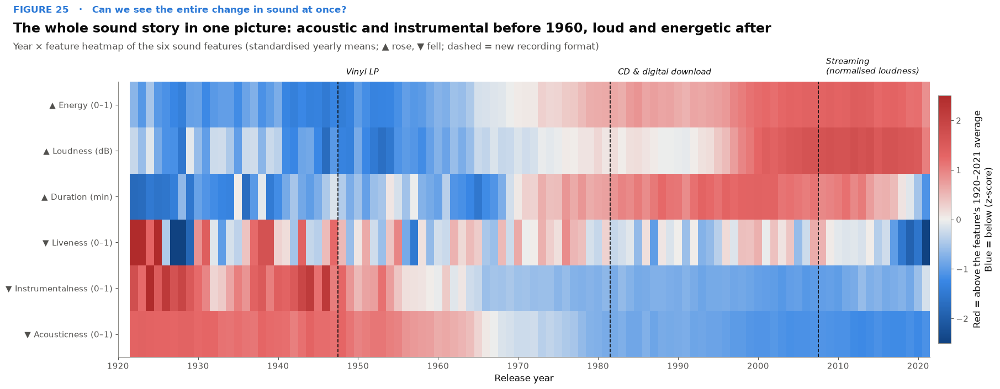

Saved -> figures/fig25_sound_year_heatmap.png


In [62]:
ym = music.groupby('release_year')[SOUND].mean()
yz = (ym - ym.mean()) / ym.std()
yrs = pd.Series(yz.index, index=yz.index)
row_order = yz.corrwith(yrs).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(18, 6), layout='constrained')
mesh = ax.pcolormesh(yz.index.values, np.arange(len(row_order)), yz[row_order].T.values, cmap=DIV, vmin=-2.5, vmax=2.5, shading='nearest')
ax.set_yticks(range(len(row_order)), [f"{'▲' if yz[f].corr(yrs) > 0 else '▼'} {LABELS[f]}" for f in row_order])
ax.invert_yaxis()
ax.set_xticks(range(1920, 2030, 10))
ax.set_xlabel('Release year')
ax.grid(False)
for a0, b0, lbl in FORMAT_ERAS[1:]:
    ax.axvline(a0 - 0.5, color=INK, lw=1.2, ls='--')
    ax.text(a0 + 0.5, -0.62, lbl, fontsize=10.5, fontstyle='italic', va='bottom')
fig.colorbar(mesh, ax=ax, label="Red = above the feature's 1920–2021 average\nBlue = below (z-score)", shrink=0.9, pad=0.01)
save_fig(fig, 25, 'sound_year_heatmap', 'The whole sound story in one picture: acoustic and instrumental before 1960, loud and energetic after',
         'Year × feature heatmap of the six sound features (standardised yearly means; ▲ rose, ▼ fell; dashed = new recording format)',
         question='Can we see the entire change in sound at once?')

**What Figure 25 shows.** In the heatmap, energy, loudness and duration turn from blue to red over the century, and acousticness and instrumentalness turn from red to blue. Acousticness and energy switch colour around 1965–1975, the vinyl-era handover. Loudness turns deep red only in the late 1990s, during the CD-era loudness war. Duration fades back toward blue after about 2015.

**How this moves the story forward.** It is the whole sound story in one picture, aligned to the recording formats that shaped it.

Figure 26 is a **density contour plot** of energy against loudness, the strongest pair from Figure 21. Each set of contour rings shows where most tracks of one decade sit (estimated from a 5,000-track sample per decade), and the cross marks that decade's average.

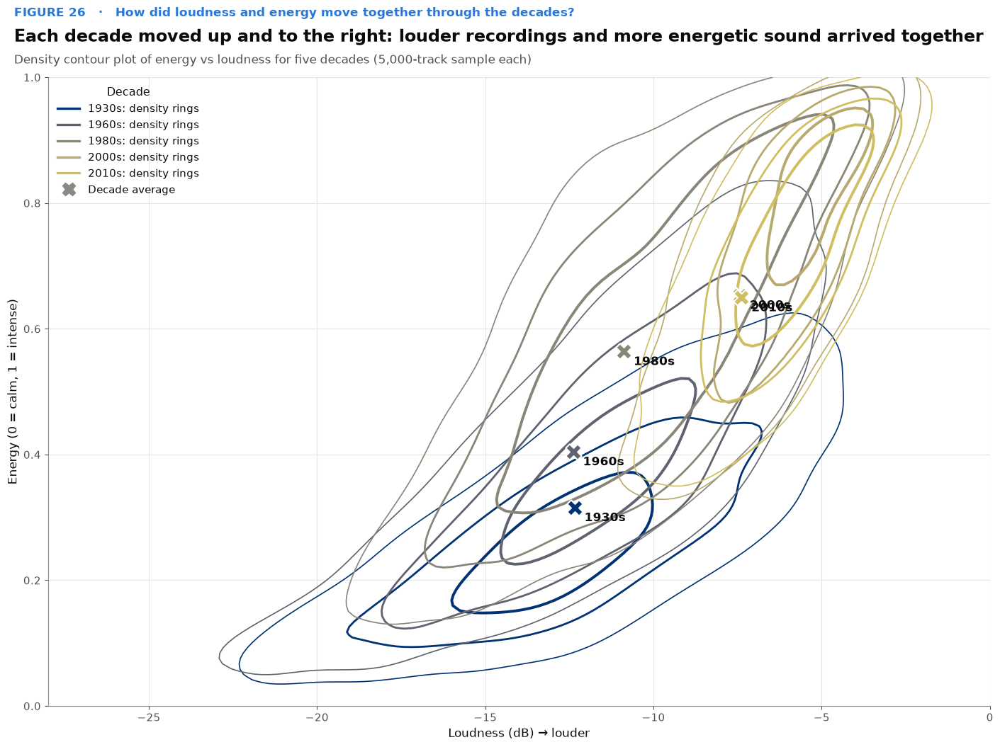

Saved -> figures/fig26_energy_loudness_contours.png


In [63]:
fig, ax = plt.subplots(figsize=(14, 9.5), layout='constrained')
gx, gy = np.meshgrid(np.linspace(-28, 0, 120), np.linspace(0, 1, 120))
CDEC = ['1930s', '1960s', '1980s', '2000s', '2010s']
for d in CDEC:
    s = music.loc[music['decade_label'] == d, ['loudness', 'energy']].dropna().sample(5000, random_state=SEED)
    z = stats.gaussian_kde(s.T.values)(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contour(gx, gy, z, levels=z.max() * np.array([0.25, 0.5, 0.75]), colors=[DEC_PAL[d]], linewidths=[1.2, 2, 2.8])
    ax.scatter(s['loudness'].mean(), s['energy'].mean(), marker='X', s=260, color=DEC_PAL[d], edgecolor='white', lw=1.5, zorder=5)
    ax.annotate(d, (s['loudness'].mean(), s['energy'].mean()), xytext=(10, -14), textcoords='offset points', fontsize=12.5, fontweight='bold')
ax.set_xlabel('Loudness (dB) → louder')
ax.set_ylabel('Energy (0 = calm, 1 = intense)')
ax.legend(handles=[Line2D([], [], color=DEC_PAL[d], lw=2.4, label=f'{d}: density rings') for d in CDEC]
          + [Line2D([], [], marker='X', ls='none', color=MUTED, markersize=13, label='Decade average')], loc='upper left', title='Decade')
save_fig(fig, 26, 'energy_loudness_contours', 'Each decade moved up and to the right: louder recordings and more energetic sound arrived together',
         'Density contour plot of energy vs loudness for five decades (5,000-track sample each)',
         question='How did loudness and energy move together through the decades?')

**What Figure 26 shows.** Each decade's density rings sit higher and further to the right than the decade before. The average track moves from about −12.4 dB and energy 0.32 in the 1930s to about −7 dB and 0.65 in the 2000s–2010s, which overlap almost completely.

**How this moves the story forward.** It shows the two strongest sound changes moving together, decade by decade, and that the move stopped after the 2000s.

Figure 27 runs **principal component analysis (PCA)** on the six standardised sound features. It shows (a) how much variation each summary axis captures, (b) a **biplot** whose arrows show what each axis means, and (c) the **path** of the average track through the decades.

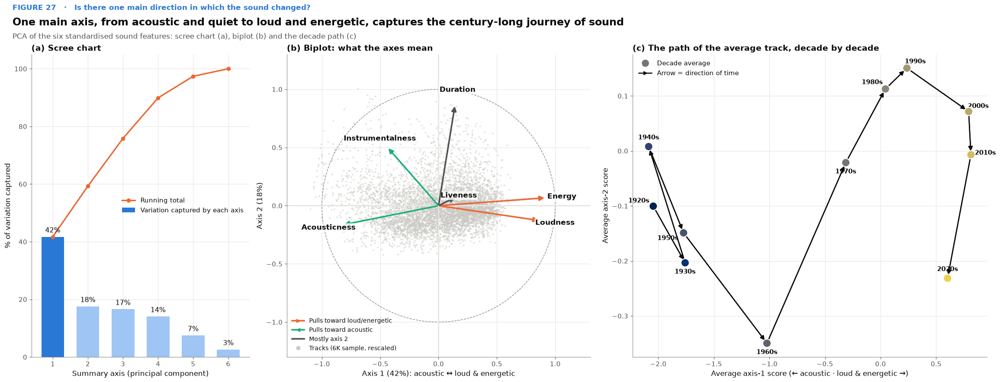

Saved -> figures/fig27_sound_pca.png


|                  |   PC1 |   PC2 |
|:-----------------|------:|------:|
| acousticness     | -0.82 | -0.16 |
| energy           | +0.92 | +0.07 |
| loudness         | +0.87 | -0.13 |
| instrumentalness | -0.44 | +0.50 |
| liveness         | +0.15 | +0.08 |
| duration_min     | +0.14 | +0.87 |

Explained variance %: [41.7 17.6 16.6 14.1  7.5  2.6]
decade_label  1920s  1930s  1940s  1950s  1960s  1970s  1980s  1990s  2000s  2010s  2020s
PC1          -2.040 -1.760 -2.090 -1.770 -1.020 -0.310  0.040  0.240  0.790  0.810  0.600
PC2          -0.100 -0.200  0.010 -0.150 -0.350 -0.020  0.110  0.150  0.070 -0.010 -0.230


In [64]:
Xdf = music[SOUND + ['decade_label']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(Xdf[SOUND].astype('float64'))
pca = PCA(random_state=SEED).fit(X)
scores = pca.transform(X)[:, :2]
evr = pca.explained_variance_ratio_
load = pd.DataFrame(pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2]), index=SOUND, columns=['PC1', 'PC2'])
fig, axes = plt.subplots(1, 3, figsize=(23, 7.8), layout='constrained', gridspec_kw={'width_ratios': [0.8, 1.15, 1.3]})
pcs = np.arange(1, len(evr) + 1)
axes[0].bar(pcs, evr * 100, color=[CAT[0]] + ['#9ec5f4'] * (len(evr) - 1), width=0.65, label='Variation captured by each axis')
axes[0].plot(pcs, np.cumsum(evr) * 100, color=CAT[1], marker='o', lw=2.4, label='Running total')
for i, v in enumerate(evr * 100):
    axes[0].text(i + 1, v + 1.5, f'{v:.0f}%', ha='center', fontsize=11.5)
axes[0].set_xticks(pcs)
axes[0].set_xlabel('Summary axis (principal component)')
axes[0].set_ylabel('% of variation captured')
axes[0].set_title('(a) Scree chart')
axes[0].legend(loc='center right')
ax = axes[1]
idx = rng.choice(len(scores), 6000, replace=False)
ax.scatter(scores[idx, 0] / np.abs(scores[:, 0]).max() * 1.1, scores[idx, 1] / np.abs(scores[:, 1]).max() * 1.1, s=4, color='#c9c8c3', alpha=0.4, rasterized=True)
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color=MUTED, lw=1, ls='--'))
for f, (l1, l2) in load.iterrows():
    col = CAT[1] if l1 > 0.3 else CAT[2] if l1 < -0.3 else INK2
    ax.annotate('', xy=(l1, l2), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color=col, lw=2.6, mutation_scale=16))
    ax.text(l1 * 1.15, l2 * 1.15, LABELS[f].split(' (')[0], ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.8))
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect('equal')
ax.axhline(0, color=GRID); ax.axvline(0, color=GRID)
ax.set_xlabel(f'Axis 1 ({evr[0]:.0%}): acoustic ↔ loud & energetic')
ax.set_ylabel(f'Axis 2 ({evr[1]:.0%})')
ax.set_title('(b) Biplot: what the axes mean')
ax.legend(handles=[Line2D([], [], color=CAT[1], lw=2.6, marker='>', label='Pulls toward loud/energetic'),
                   Line2D([], [], color=CAT[2], lw=2.6, marker='<', label='Pulls toward acoustic'),
                   Line2D([], [], color=INK2, lw=2.6, label='Mostly axis 2'),
                   Line2D([], [], marker='o', ls='none', color='#c9c8c3', label='Tracks (6K sample, rescaled)')], loc='lower left', fontsize=10)
ax = axes[2]
pc_dec = pd.DataFrame(scores, columns=['PC1', 'PC2'], index=Xdf.index).groupby(Xdf['decade_label'], observed=True).mean()
p = pc_dec.values
ax.plot(p[:, 0], p[:, 1], color=INK, lw=1.8, zorder=2)
for (x0, y0), (x1, y1) in zip(p[:-1], p[1:]):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle='-|>', color=INK, lw=1.8, mutation_scale=15, shrinkA=6, shrinkB=6))
ax.scatter(p[:, 0], p[:, 1], c=[DEC_PAL[d] for d in pc_dec.index], s=190, edgecolor='white', lw=1.5, zorder=4)
for k_, d in enumerate(pc_dec.index):
    OFF26 = {'1920s': (-24, 6), '1930s': (0, -18), '1940s': (0, 12), '1950s': (-26, -12), '1960s': (0, -18), '1970s': (0, -18),
             '1980s': (-22, 8), '1990s': (14, 8), '2000s': (16, 6), '2010s': (24, 0), '2020s': (0, 12)}
    ax.annotate(d, p[k_], xytext=OFF26.get(str(d), (0, 12)), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Average axis-1 score (← acoustic · loud & energetic →)')
ax.set_ylabel('Average axis-2 score')
ax.set_title('(c) The path of the average track, decade by decade')
ax.legend(handles=[Line2D([], [], marker='o', ls='none', markerfacecolor=DEC_PAL['1970s'], markeredgecolor='white', markersize=13, label='Decade average'),
                   Line2D([], [], color=INK, marker='>', lw=1.8, label='Arrow = direction of time')], loc='best')
save_fig(fig, 27, 'sound_pca', 'One main axis, from acoustic and quiet to loud and energetic, captures the century-long journey of sound',
         'PCA of the six standardised sound features: scree chart (a), biplot (b) and the decade path (c)',
         question='Is there one main direction in which the sound changed?')
md_table(load, floatfmt='+.2f')
print('Explained variance %:', np.round(evr * 100, 1)); print(pc_dec.round(2).T.to_string())

**What Figure 27 shows.**
* **(a) One dominant axis:** a single summary axis captures **42 %** of all variation in the six sound features.
* **(b) What it means:** that axis is "acoustic ↔ loud and energetic". Energy (+0.92) and loudness (+0.87) load positively, and acousticness (−0.82) and instrumentalness (−0.44) negatively. A second axis (18 %) is mostly song length.
* **(c) The path:** the average track moves from about −2 (1920s–1950s) to +0.8 (2000s–2010s) along this axis, with the fastest move between the 1950s and the 1980s.

**How this moves the story forward.** It shows that the many changes in sound are mostly one change, a century-long move from acoustic and quiet to loud and energetic.

### Sound clusters (K-Means)

K-Means groups tracks with similar sound. The number of clusters *k* is chosen by comparing the **elbow** in within-cluster spread with the **silhouette score**. Both are computed on a 60,000-track random sample (silhouette on a 10,000-track sub-sample), and the final model is fitted on all tracks.

In [65]:
sel = rng.choice(len(X), 60_000, replace=False)
Xs = X[sel]
k_range = range(2, 10)
inertia, sil = [], []
for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit(Xs)
    inertia.append(km_k.inertia_)
    sil.append(silhouette_score(Xs, km_k.labels_, sample_size=10_000, random_state=SEED))
k_tbl = pd.DataFrame({'k': list(k_range), 'inertia': inertia, 'silhouette': sil})
md_table(k_tbl, index=False, floatfmt=',.3f')

|     k |     inertia |   silhouette |
|------:|------------:|-------------:|
| 2.000 | 254,326.160 |        0.296 |
| 3.000 | 213,787.734 |        0.283 |
| 4.000 | 181,919.037 |        0.301 |
| 5.000 | 163,307.106 |        0.266 |
| 6.000 | 149,373.545 |        0.263 |
| 7.000 | 136,881.551 |        0.233 |
| 8.000 | 130,111.962 |        0.199 |
| 9.000 | 122,026.716 |        0.214 |

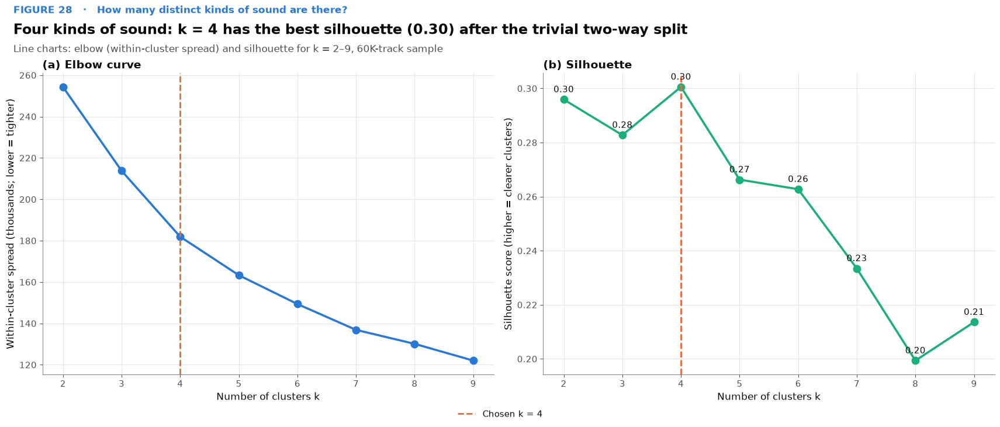

Saved -> figures/fig28_sound_kmeans_selection.png


In [66]:
K = 4   # best silhouette after the trivial 2-cluster split, and four clearly interpretable sound types (see the table above)
fig, axes = plt.subplots(1, 2, figsize=(17, 6.3), layout='constrained')
axes[0].plot(k_tbl['k'], k_tbl['inertia'] / 1e3, marker='o', markersize=9, color=CAT[0], lw=2.6)
axes[0].set_ylabel('Within-cluster spread (thousands; lower = tighter)')
axes[0].set_title('(a) Elbow curve')
axes[1].plot(k_tbl['k'], k_tbl['silhouette'], marker='o', markersize=9, color=CAT[2], lw=2.6)
for k_, v in zip(k_tbl['k'], k_tbl['silhouette']):
    axes[1].annotate(f'{v:.2f}', (k_, v), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=10.5)
axes[1].set_ylabel('Silhouette score (higher = clearer clusters)')
axes[1].set_title('(b) Silhouette')
for ax in axes:
    ax.axvline(K, color=CAT[1], ls='--', lw=2)
    ax.set_xlabel('Number of clusters k')
    ax.set_xticks(list(k_range))
fig.legend(handles=[Line2D([], [], color=CAT[1], ls='--', lw=2, label=f'Chosen k = {K}')], loc='outside lower center')
save_fig(fig, 28, 'sound_kmeans_selection', f"Four kinds of sound: k = {K} has the best silhouette ({k_tbl.set_index('k').loc[K, 'silhouette']:.2f}) after the trivial two-way split",
         'Line charts: elbow (within-cluster spread) and silhouette for k = 2–9, 60K-track sample',
         question='How many distinct kinds of sound are there?')

**What Figure 28 shows.** The elbow curve falls smoothly, with no sharp bend. The silhouette score is highest for k = 2 (0.30), which only splits acoustic from electric, and nearly as high for **k = 4 (0.30)**. From k = 5 onward it declines. k = 4 is therefore chosen: it is the best-separated split that still distinguishes meaningful kinds of sound.

**How this moves the story forward.** It sets honest expectations. The four "kinds of sound" are reasonably separated regions of a continuum, not perfectly distinct species of music.

In [67]:
km = KMeans(n_clusters=K, n_init=5, random_state=SEED).fit(X)
music.loc[Xdf.index, 'sound_cluster_id'] = km.labels_
cent_z = pd.DataFrame(km.cluster_centers_, columns=SOUND)

def name_clusters(cz):
    """Plain-language names: each rule, in order, takes the remaining cluster that is most extreme on one feature."""
    rules = [('Acoustic instrumental', 'instrumentalness', 1), ('Live recordings', 'liveness', 1),
             ('Loud & energetic', 'energy', 1), ('Acoustic & mellow', 'acousticness', 1)]
    names, left = {}, list(cz.index)
    for name, feat, sign in rules[:len(cz)]:
        c = (cz.loc[left, feat] * sign).idxmax()
        names[c] = name
        left.remove(c)
    return names

CLUSTER_NAMES = name_clusters(cent_z)
cent_raw = music.groupby('sound_cluster_id')[SOUND + ['release_year', 'popularity']].mean()
cent_raw['share %'] = music['sound_cluster_id'].value_counts(normalize=True) * 100
cluster_order = cent_raw.sort_values('release_year').index
CL_COL = {CLUSTER_NAMES[c]: col for c, col in zip(cluster_order, [CAT[2], CAT[5], CAT[0], CAT[3], CAT[1], CAT[6]])}
music['sound_cluster'] = pd.Categorical(music['sound_cluster_id'].map(CLUSTER_NAMES), categories=[CLUSTER_NAMES[c] for c in cluster_order])
md_table(cent_raw.rename(index=CLUSTER_NAMES).loc[[CLUSTER_NAMES[c] for c in cluster_order]], floatfmt=',.2f')

| sound_cluster_id      |   acousticness |   energy |   loudness |   instrumentalness |   liveness |   duration_min |   release_year |   popularity |   share % |
|:----------------------|---------------:|---------:|-----------:|-------------------:|-----------:|---------------:|---------------:|-------------:|----------:|
| Acoustic instrumental |           0.78 |     0.30 |     -16.19 |               0.81 |       0.17 |           3.78 |       1,970.18 |        16.00 |      9.51 |
| Acoustic & mellow     |           0.72 |     0.34 |     -12.48 |               0.02 |       0.16 |           3.50 |       1,979.42 |        22.36 |     33.81 |
| Live recordings       |           0.39 |     0.66 |      -8.89 |               0.07 |       0.70 |           4.01 |       1,990.96 |        27.83 |      7.35 |
| Loud & energetic      |           0.19 |     0.72 |      -7.13 |               0.05 |       0.17 |           3.95 |       1,999.14 |        34.23 |     49.33 |

Figure 29 profiles each sound cluster with a **radar chart**. Each spoke is a sound feature and the distance from the centre is the cluster's average in standard deviations (the dashed ring is the average track).

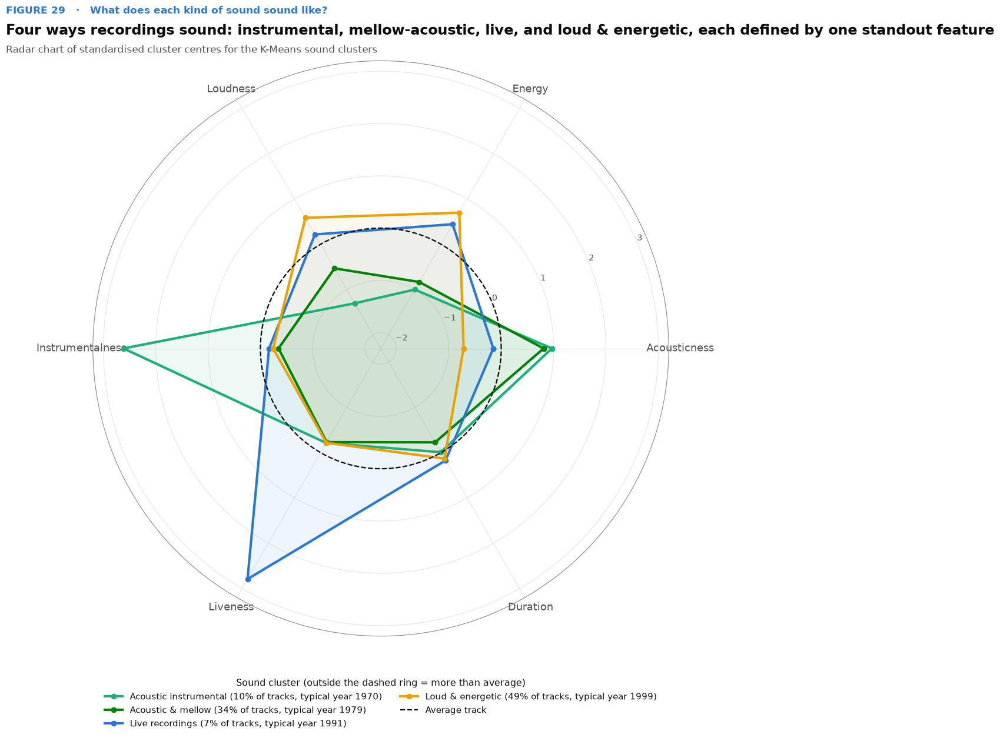

Saved -> figures/fig29_sound_cluster_radar.png


In [68]:
ang = np.linspace(0, 2 * np.pi, len(SOUND), endpoint=False)
fig = plt.figure(figsize=(13, 11.5), layout='constrained')
ax = fig.add_subplot(projection='polar')
lo_r = np.floor(cent_z.values.min()) - 0.3
for c in cluster_order:
    nm = CLUSTER_NAMES[c]
    vals = np.r_[cent_z.loc[c].values, cent_z.loc[c].values[0]]
    ax.plot(np.r_[ang, ang[0]], vals, color=CL_COL[nm], lw=3, marker='o',
            label=f"{nm} ({cent_raw.loc[c, 'share %']:.0f}% of tracks, typical year {cent_raw.loc[c, 'release_year']:.0f})")
    ax.fill(np.r_[ang, ang[0]], vals, color=CL_COL[nm], alpha=0.07)
ax.plot(np.linspace(0, 2 * np.pi, 200), np.zeros(200), color=INK, lw=1.6, ls='--', label='Average track')
ax.set_ylim(lo_r, np.ceil(cent_z.values.max()) + 0.2)
ax.set_xticks(ang, [LABELS[f].split(' (')[0] for f in SOUND], fontsize=13)
ax.tick_params(axis='y', labelsize=10, colors=INK2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=2, title='Sound cluster (outside the dashed ring = more than average)')
save_fig(fig, 29, 'sound_cluster_radar', 'Four ways recordings sound: instrumental, mellow-acoustic, live, and loud & energetic, each defined by one standout feature',
         'Radar chart of standardised cluster centres for the K-Means sound clusters',
         question='What does each kind of sound sound like?')

**What Figure 29 shows.** The four kinds of sound have clear signatures:
* **Acoustic instrumental** (10 % of tracks; typical year 1970): very instrumental (0.81) and quiet (−16 dB).
* **Acoustic & mellow** (34 %; 1979): acoustic (0.72) but vocal, with low energy.
* **Live recordings** (7 %; 1991): liveness 0.70, otherwise average.
* **Loud & energetic** (49 %; 1999): energy 0.72, −7 dB, acousticness 0.19.

**How this moves the story forward.** It turns the abstract features into four recognisable ways that music is made, and they are ordered in time from the oldest to the newest typical year.

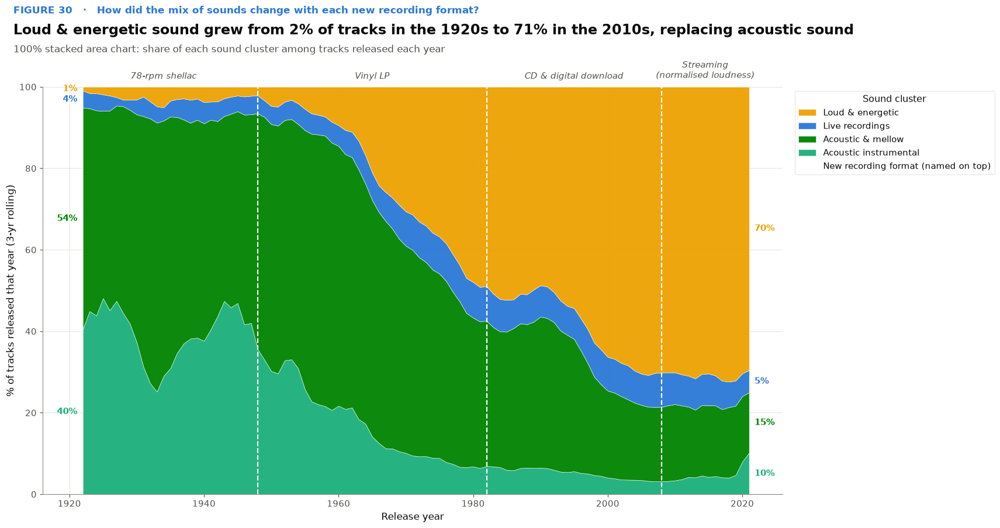

Saved -> figures/fig30_sound_cluster_share.png


| sound_cluster         |   1920s |   1930s |   1940s |   1950s |   1960s |   1970s |   1980s |   1990s |   2000s |   2010s |   2020s |
|:----------------------|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| Acoustic instrumental |    45.1 |    33.3 |    41.1 |    25.9 |    16.0 |     8.4 |     6.4 |     5.5 |     3.4 |     4.1 |     8.1 |
| Acoustic & mellow     |    49.7 |    58.6 |    51.9 |    63.4 |    58.3 |    45.3 |    35.1 |    31.0 |    19.3 |    17.5 |    15.3 |
| Live recordings       |     2.7 |     4.6 |     4.3 |     4.8 |     6.8 |     9.0 |     7.9 |     7.9 |     8.1 |     7.2 |     6.0 |
| Loud & energetic      |     2.5 |     3.5 |     2.7 |     5.9 |    18.9 |    37.4 |    50.6 |    55.7 |    69.2 |    71.2 |    70.6 |

In [69]:
cl_year = (pd.crosstab(music['release_year'], music['sound_cluster'], normalize='index') * 100).rolling(3, center=True, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(17, 8), layout='constrained')
ax.stackplot(cl_year.index, cl_year.T.values, labels=cl_year.columns, colors=[CL_COL[c] for c in cl_year.columns], edgecolor='white', lw=0.4, alpha=0.95)
cum = cl_year.cumsum(axis=1)
for c in cl_year.columns:
    for yr, ha, dx in [(cl_year.index.min(), 'right', -0.8), (cl_year.index.max(), 'left', 0.8)]:
        ax.text(yr + dx, cum.loc[yr, c] - cl_year.loc[yr, c] / 2, f'{cl_year.loc[yr, c]:.0f}%', ha=ha, va='center', fontsize=11, color=CL_COL[c], fontweight='bold')
for a0, b0, lbl in FORMAT_ERAS:
    if a0 > 1920:
        ax.axvline(a0, color='white', lw=1.6, ls='--')
    ax.text((a0 + min(b0, 2021)) / 2, 101.5, lbl, ha='center', va='bottom', fontsize=10.5, color=INK2, fontstyle='italic')
ax.set_xlim(1916, 2026)
ax.set_ylim(0, 100)
ax.set_xlabel('Release year')
ax.set_ylabel('% of tracks released that year (3-yr rolling)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h[::-1] + [Line2D([], [], color='white', ls='--', lw=1.6, label='New recording format (named on top)')],
          loc='upper left', bbox_to_anchor=(1.01, 1.0), title='Sound cluster', frameon=True, edgecolor=GRID)
cl_dec = pd.crosstab(music['decade_label'], music['sound_cluster'], normalize='index') * 100
save_fig(fig, 30, 'sound_cluster_share', f"Loud & energetic sound grew from {cl_dec.loc['1920s', 'Loud & energetic']:.0f}% of tracks in the 1920s to {cl_dec.loc['2010s', 'Loud & energetic']:.0f}% in the 2010s, replacing acoustic sound",
         '100% stacked area chart: share of each sound cluster among tracks released each year',
         question='How did the mix of sounds change with each new recording format?')
cl_dec = pd.crosstab(music['decade_label'], music['sound_cluster'], normalize='index') * 100
md_table(cl_dec.T, floatfmt='.1f')

**What Figure 30 shows.** The 100 % stacked area changes colour across the century. **Loud & energetic** grew from 2.5 % of tracks in the 1920s to 19 % (1960s), 51 % (1980s) and **71 % (2010s)**. The two acoustic types together fell from about 95 % (1920s) to about 22 % (2010s). Live recordings stay at 3–9 % throughout. Each new recording format (vinyl LP, CD) coincides with a step toward loud and energetic sound.

**How this moves the story forward.** It retells the century as one way of making music replacing another, with the format eras marking each step.

> ### Chapter 2 Takeaways: The Sound and the Creation
> * **Music got much louder.** Median loudness rose from about −13 dB (1950s) to −6.5 dB (2010s), most steeply in the CD-era loudness war, and peaked in 2012 (Figure 20). The effect is large (η²_H = 0.25, Figure 24).
> * **Acoustic gave way to electric.** Median acousticness fell from 0.97 (1940s) to 0.18 (2010s), and energy overtook acousticness for the average track in about 1975 (Figures 19, 22). One summary axis (acoustic ↔ loud and energetic) captures 42 % of all variation in sound (Figure 27).
> * **The way music is made turned over, and songs shortened again.** The loud & energetic sound type grew from 2.5 % to 71 % of tracks (Figure 30). Song length peaked at 4.09 minutes in 2000 and fell to 3.42 by 2020 (Figure 23).

<a id="chapter-3"></a>
## Chapter 3: The Tempo. How has the pace and rhythm of music changed?

**The story in this chapter.** Has music sped up? Has the beat become more danceable, and has rhythmic variety (waltzes, odd meters, minor keys) narrowed or widened? The variables are **tempo, danceability, time signature, key and mode**, plus **energy** where it relates to pace.

**A caution about tempo.** Spotify's tempo is an automatic estimate. Beat trackers often lock onto half or double the true speed (a 70-BPM ballad read as 140, or a 160-BPM punk song read as 80). Tempo trends are therefore read together with danceability, which measures beat regularity rather than speed.

In [70]:
RHYTHM = ['tempo', 'danceability']
music['era3'] = pd.cut(music['release_year'], [1919, 1959, 1999, 2021], labels=['1920–1959', '1960–1999', '2000–2021'])
ERA_COL = dict(zip(['1920–1959', '1960–1999', '2000–2021'], [DEC_PAL['1930s'], DEC_PAL['1970s'], DEC_PAL['2010s']]))
tests_rhythm = trend_tests(music, ['tempo', 'danceability', 'energy'])
show_tests(tests_rhythm)
tests_rhythm.to_csv(OUT_DIR / 'trend_tests_rhythm.csv')

| feature      |   Spearman ρ with year | p (ρ)    |   Kruskal H | p (H)    |   η²_H |   ANOVA η² | size   |
|:-------------|-----------------------:|:---------|------------:|:---------|-------:|-----------:|:-------|
| tempo        |                  0.111 | < 1e-300 |   8,707.820 | < 1e-300 |  0.018 |      0.015 | small  |
| danceability |                  0.266 | < 1e-300 |  37,870.035 | < 1e-300 |  0.077 |      0.077 | medium |
| energy       |                  0.419 | < 1e-300 | 103,123.930 | < 1e-300 |  0.209 |      0.214 | large  |

The tests show the size of the rhythm trends before we visualise them. They are interpreted alongside Figures 33 and 34 below.

### Univariate: tempo, meter and key

Figure 31 is a **histogram** of tempo in 1-BPM bins. The common "peaks" (the speeds songs cluster around) are marked automatically from the smoothed histogram.

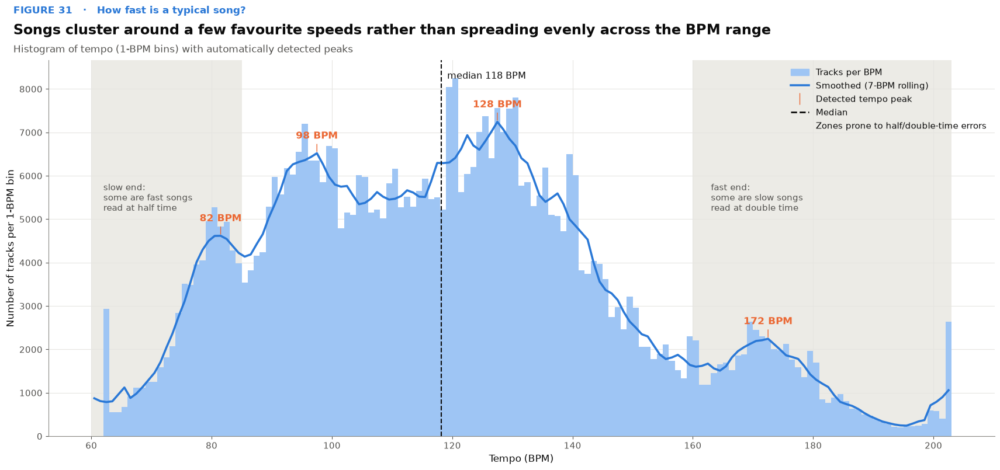

Saved -> figures/fig31_tempo_histogram.png
Tempo peaks (BPM): [82, 98, 128, 172] | median 118.159


In [71]:
from scipy.signal import find_peaks
tv = music['tempo'].dropna()
cnt, edges_ = np.histogram(tv, bins=np.arange(60, 204, 1))
mids = (edges_[:-1] + edges_[1:]) / 2
smooth = pd.Series(cnt).rolling(7, center=True, min_periods=1).mean().values
pk_idx, _ = find_peaks(smooth, prominence=smooth.max() * 0.06, distance=12)
fig, ax = plt.subplots(figsize=(17, 7), layout='constrained')
ax.bar(mids, cnt, width=1, color='#9ec5f4', edgecolor='none')
ax.plot(mids, smooth, color=CAT[0], lw=2.6)
for i in pk_idx:
    ax.annotate(f'{mids[i]:.0f} BPM', (mids[i], smooth[i]), xytext=(0, 18), textcoords='offset points', ha='center', fontsize=12, fontweight='bold',
                color=CAT[1], arrowprops=dict(arrowstyle='-', color=CAT[1]))
ax.axvline(tv.median(), color=INK, ls='--', lw=1.5)
ax.text(tv.median() + 1, ax.get_ylim()[1] * 0.97, f'median {tv.median():.0f} BPM', fontsize=11.5, va='top')
ax.axvspan(60, 85, color=ERA_SHADE, lw=0, zorder=0)
ax.axvspan(160, 203, color=ERA_SHADE, lw=0, zorder=0)
ax.text(62, ax.get_ylim()[1] * 0.6, 'slow end:\nsome are fast songs\nread at half time', fontsize=10.5, color=INK2)
ax.text(163, ax.get_ylim()[1] * 0.6, 'fast end:\nsome are slow songs\nread at double time', fontsize=10.5, color=INK2)
ax.set_xlabel('Tempo (BPM)')
ax.set_ylabel('Number of tracks per 1-BPM bin')
ax.legend(handles=[Patch(color='#9ec5f4', label='Tracks per BPM'), Line2D([], [], color=CAT[0], lw=2.6, label='Smoothed (7-BPM rolling)'),
                   Line2D([], [], color=CAT[1], marker='|', ls='none', markersize=14, label='Detected tempo peak'),
                   Line2D([], [], color=INK, ls='--', label='Median'), Patch(color=ERA_SHADE, label='Zones prone to half/double-time errors')],
          loc='upper right')
save_fig(fig, 31, 'tempo_histogram', 'Songs cluster around a few favourite speeds rather than spreading evenly across the BPM range',
         'Histogram of tempo (1-BPM bins) with automatically detected peaks',
         question='How fast is a typical song?')
print('Tempo peaks (BPM):', [round(mids[i]) for i in pk_idx], '| median', tv.median())

**What Figure 31 shows.** Tempos cluster around four peaks: **82, 98, 128 and 172 BPM**, with a median of 118 BPM. The peaks near 82 and 172 BPM sit close to half and double the main 98–128 BPM range, which is consistent with half-time and double-time detection errors.

**How this moves the story forward.** It establishes what a "typical" pace is, and it warns that small changes in average tempo should be read with care.

Figure 32 combines a **donut chart** of time signatures with a **polar bar chart** of keys arranged around the pitch-class wheel (C at the top, going up in semitones clockwise).

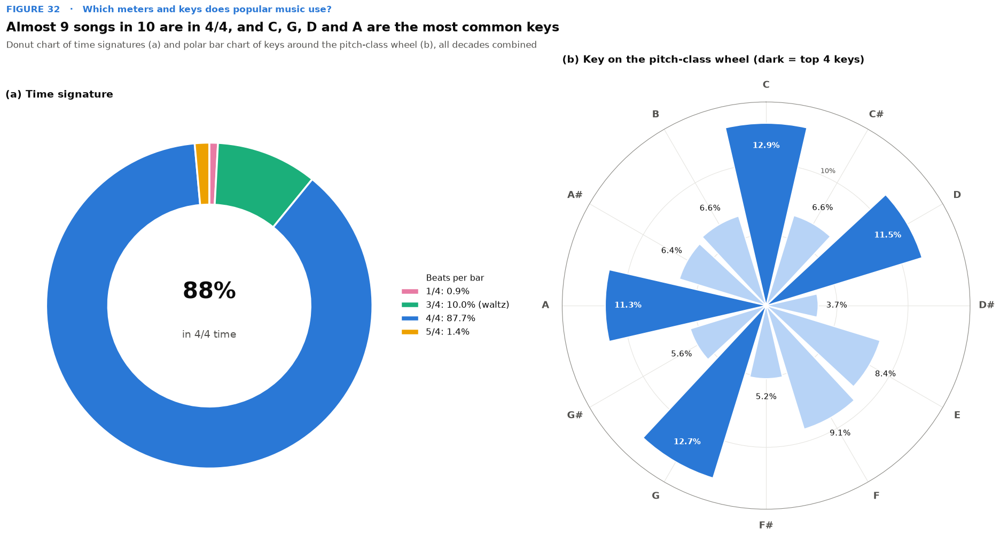

Saved -> figures/fig32_meter_and_key.png


In [72]:
ts = (music['time_signature'].dropna().astype(int).value_counts(normalize=True) * 100).sort_index()
kt = (music['key'].value_counts(normalize=True) * 100).reindex(KEY_NAMES)
fig = plt.figure(figsize=(19, 9), layout='constrained')
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.15])
ax = fig.add_subplot(gs[0])
ts_cols = {1: CAT[4], 3: CAT[2], 4: CAT[0], 5: CAT[3]}
wedges, _ = ax.pie(ts.values, colors=[ts_cols[i] for i in ts.index], startangle=90, counterclock=False,
                   wedgeprops=dict(width=0.38, edgecolor='white', lw=2.5))
ax.text(0, 0.08, f'{ts.loc[4]:.0f}%', ha='center', va='center', fontsize=30, fontweight='bold')
ax.text(0, -0.18, 'in 4/4 time', ha='center', va='center', fontsize=14, color=INK2)
ax.legend(wedges, [f'{i}/4: {p:.1f}%' + (' (waltz)' if i == 3 else '') for i, p in ts.items()], loc='center left', bbox_to_anchor=(0.95, 0.5),
          title='Beats per bar', fontsize=12)
ax.set_title('(a) Time signature')
axk = fig.add_subplot(gs[1], projection='polar')
ang = np.linspace(0, 2 * np.pi, 12, endpoint=False)
top4 = kt.nlargest(4).index
axk.bar(ang, kt.values, width=2 * np.pi / 12 * 0.86, color=[CAT[0] if k in top4 else '#b7d3f6' for k in kt.index], edgecolor='white', lw=1.5)
for a_, v, k in zip(ang, kt.values, kt.index):
    axk.text(a_, v - 1.6 if k in top4 else v + 1.3, f'{v:.1f}%', ha='center', va='center', fontsize=10.5,
             fontweight='bold' if k in top4 else None, color='white' if k in top4 else INK)
axk.set_theta_zero_location('N'); axk.set_theta_direction(-1)
axk.set_ylim(0, kt.max() + 1.5)
axk.set_xticks(ang, KEY_NAMES, fontsize=13, fontweight='bold')
axk.tick_params(axis='x', pad=12)
axk.set_yticks([5, 10], ['5%', '10%'], fontsize=9, color=INK2)
axk.set_title('(b) Key on the pitch-class wheel (dark = top 4 keys)', pad=24)
save_fig(fig, 32, 'meter_and_key', 'Almost 9 songs in 10 are in 4/4, and C, G, D and A are the most common keys',
         'Donut chart of time signatures (a) and polar bar chart of keys around the pitch-class wheel (b), all decades combined',
         question='Which meters and keys does popular music use?')

**What Figure 32 shows.** (a) **87.7 % of tracks are in 4/4**, 10.0 % in 3/4 (waltz time), 1.4 % in 5/4 and 0.9 % in 1/4. (b) On the key wheel, **C (12.9 %), G (12.7 %), D (11.5 %) and A (11.3 %)** dominate. These are the keys that fall most easily on guitar and piano. D# (3.7 %) is the rarest.

**How this moves the story forward.** It sets the rhythmic and harmonic baseline. Figures 36 and 38 then show how these shares changed over time.

### Bivariate: is music getting faster or more danceable?

Figure 33 uses **small-multiple line charts** of the yearly median tempo and danceability. The band is a 95 % confidence interval for each year's median.

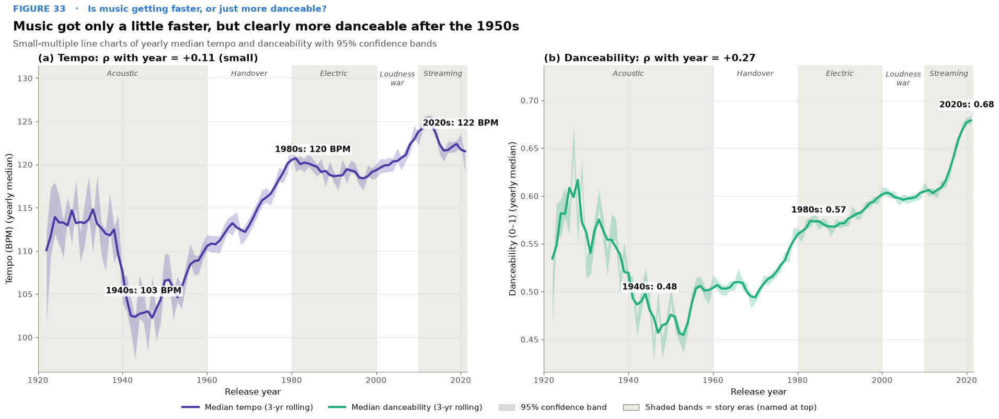

Saved -> figures/fig33_tempo_dance_trends.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7), layout='constrained')
for ax, f, col in [(axes[0], 'tempo', CAT[6]), (axes[1], 'danceability', CAT[2])]:
    g = music.groupby('release_year')[f].agg(med='median', q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75), n='size')
    ci = 1.57 * (g['q3'] - g['q1']) / np.sqrt(g['n'])
    ax.fill_between(g.index, g['med'] - ci, g['med'] + ci, color=col, alpha=0.25, lw=0, zorder=2)
    ax.plot(g.index, g['med'].rolling(3, center=True, min_periods=1).mean(), color=col, lw=3, zorder=3)
    add_eras(ax, short=True)
    dm = music.groupby('decade_label', observed=True)[f].median()
    for d in ['1940s', '1980s', '2020s']:
        yr = int(d[:4]) + (5 if d != '2020s' else 0)
        fmt = '{:.0f} BPM' if f == 'tempo' else '{:.2f}'
        ax.annotate(f'{d}: ' + fmt.format(dm[d]), (yr, g['med'].loc[yr]), xytext=(0, 18), textcoords='offset points', ha='center', fontsize=11.5,
                    fontweight='bold', bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
    ax.set_xlim(1920, 2021.6)
    ax.set_xlabel('Release year')
    ax.set_ylabel(LABELS[f] + ' (yearly median)')
axes[0].set_title(f"(a) Tempo: ρ with year = {tests_rhythm.loc['tempo', 'Spearman ρ with year']:+.2f} (small)")
axes[1].set_title(f"(b) Danceability: ρ with year = {tests_rhythm.loc['danceability', 'Spearman ρ with year']:+.2f}")
fig.legend(handles=[Line2D([], [], color=CAT[6], lw=3, label='Median tempo (3-yr rolling)'), Line2D([], [], color=CAT[2], lw=3, label='Median danceability (3-yr rolling)'),
                    Patch(color=MUTED, alpha=0.3, label='95% confidence band'), ERA_HANDLE], loc='outside lower center', ncol=4)
save_fig(fig, 33, 'tempo_dance_trends', 'Music got only a little faster, but clearly more danceable after the 1950s',
         'Small-multiple line charts of yearly median tempo and danceability with 95% confidence bands',
         question='Is music getting faster, or just more danceable?')

**What Figure 33 shows.** (a) Median tempo dipped to about **103 BPM in the 1940s** (slow ballads and classical recordings), rose to about **120 BPM by the 1980s**, and has been nearly flat since (about **122 BPM in the 2020s**). Overall, ρ with year is only +0.11. (b) Danceability fell to about **0.48 in the 1940s–50s**, then climbed in every decade to **0.57 in the 1980s** and **0.68 in the 2020s** (ρ = +0.27), with the steepest rise after 2015.

**How this moves the story forward.** It separates two ideas that are easy to confuse. Music did not get much *faster*, but it did get much more *danceable*: the beat became steadier and more central.

Figure 34 is a **strip plot**: each dot is one track (a random sample of 300 per decade), so the reader can see the full spread of tempos rather than only the average. The black bar is each decade's median.

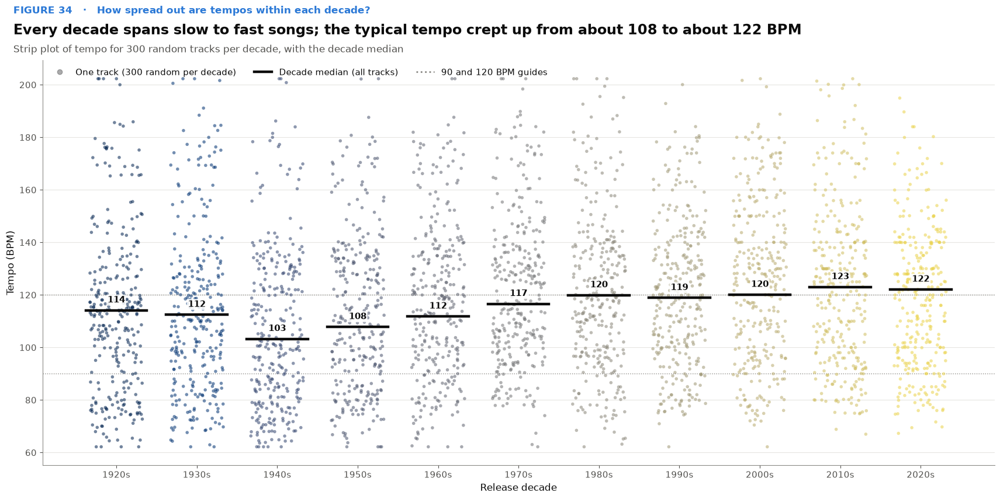

Saved -> figures/fig34_tempo_strip.png


In [74]:
strip = music.dropna(subset=['tempo']).groupby('decade_label', observed=True).sample(n=300, random_state=SEED)
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
sns.stripplot(data=strip, x='decade_label', y='tempo', hue='decade_label', palette=DEC_PAL, legend=False, jitter=0.33, size=4, alpha=0.55, ax=ax)
tmed = music.groupby('decade_label', observed=True)['tempo'].median()
for i, v in enumerate(tmed.values):
    ax.plot([i - 0.38, i + 0.38], [v, v], color=INK, lw=3.2, zorder=5)
    ax.text(i, v + 3, f'{v:.0f}', ha='center', fontsize=11, fontweight='bold', zorder=6, bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85))
for bpm in (90, 120):
    ax.axhline(bpm, color=MUTED, lw=1, ls=':')
ax.set_xlabel('Release decade')
ax.set_ylabel('Tempo (BPM)')
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=DEC_PAL['1970s'], alpha=0.6, label='One track (300 random per decade)'),
                   Line2D([], [], color=INK, lw=3.2, label='Decade median (all tracks)'), Line2D([], [], color=MUTED, ls=':', label='90 and 120 BPM guides')],
          loc='upper left', ncol=3)
save_fig(fig, 34, 'tempo_strip', 'Every decade spans slow to fast songs; the typical tempo crept up from about 108 to about 122 BPM',
         'Strip plot of tempo for 300 random tracks per decade, with the decade median',
         question='How spread out are tempos within each decade?')

**What Figure 34 shows.** Every decade has songs spread from about 60 to 200 BPM. The median line moves from 103 BPM (1940s) and 108 BPM (1950s) up to 117 (1970s), 120 (1980s) and about 122–123 BPM (2010s–2020s). The overall spread hardly changes.

**How this moves the story forward.** It shows that the small rise in tempo is a gentle shift of the middle, not a new kind of fast music.

Figure 35 is a **2D density plot** of tempo against danceability for an early era and a recent one (8,000-track samples). Darker areas hold more songs.

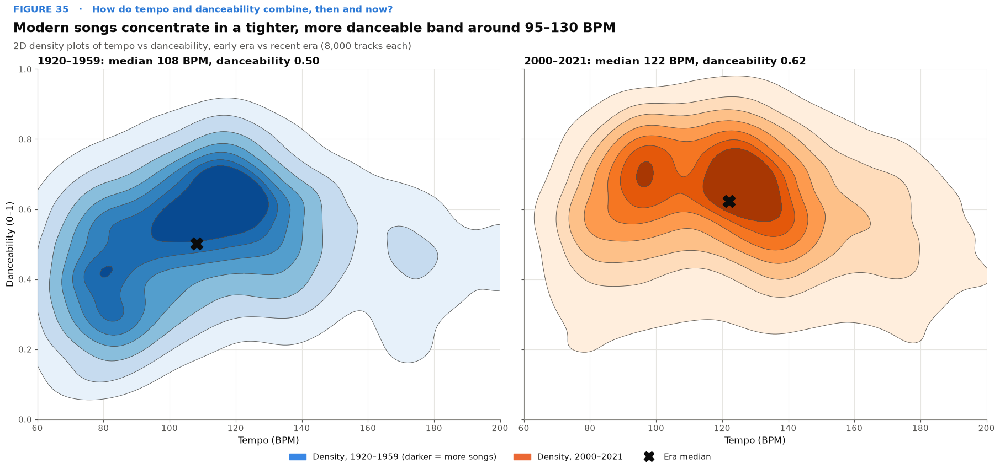

Saved -> figures/fig35_tempo_dance_density.png


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), layout='constrained', sharex=True, sharey=True)
for ax, era, cmap_ in [(axes[0], '1920–1959', 'Blues'), (axes[1], '2000–2021', 'Oranges')]:
    s = music.loc[music['era3'] == era, ['tempo', 'danceability']].dropna().sample(8000, random_state=SEED)
    sns.kdeplot(data=s, x='tempo', y='danceability', fill=True, levels=8, thresh=0.05, cmap=cmap_, ax=ax)
    sns.kdeplot(data=s, x='tempo', y='danceability', levels=8, thresh=0.05, color=INK2, linewidths=0.6, ax=ax)
    ax.scatter(s['tempo'].median(), s['danceability'].median(), marker='X', s=260, color=INK, zorder=5)
    ax.set_title(f'{era}: median {s.tempo.median():.0f} BPM, danceability {s.danceability.median():.2f}')
    ax.set_xlabel('Tempo (BPM)')
    ax.set_ylabel('Danceability (0–1)')
    ax.set_xlim(60, 200); ax.set_ylim(0, 1)
fig.legend(handles=[Patch(color='#3987e5', label='Density, 1920–1959 (darker = more songs)'), Patch(color=CAT[1], label='Density, 2000–2021'),
                    Line2D([], [], marker='X', ls='none', color=INK, markersize=13, label='Era median')], loc='outside lower center', ncol=3)
save_fig(fig, 35, 'tempo_dance_density', 'Modern songs concentrate in a tighter, more danceable band around 95–130 BPM',
         '2D density plots of tempo vs danceability, early era vs recent era (8,000 tracks each)',
         question='How do tempo and danceability combine, then and now?')

**What Figure 35 shows.** In 1920–1959 the density is broad and centred on 108 BPM with danceability 0.50, and it has a second cluster of slower, less danceable songs near 80 BPM. In 2000–2021 the density is tighter and higher: centred on **122 BPM and danceability 0.62**, with two hot spots around 95–100 BPM (hip-hop tempo) and 120–135 BPM (pop and dance tempo).

**How this moves the story forward.** It shows that modern songs converge on a narrower "danceable" zone, two tempo bands with a strong beat.

Figure 36 is a **100 % stacked bar chart** of time signatures by decade. Did the waltz (3/4) and other meters fade?

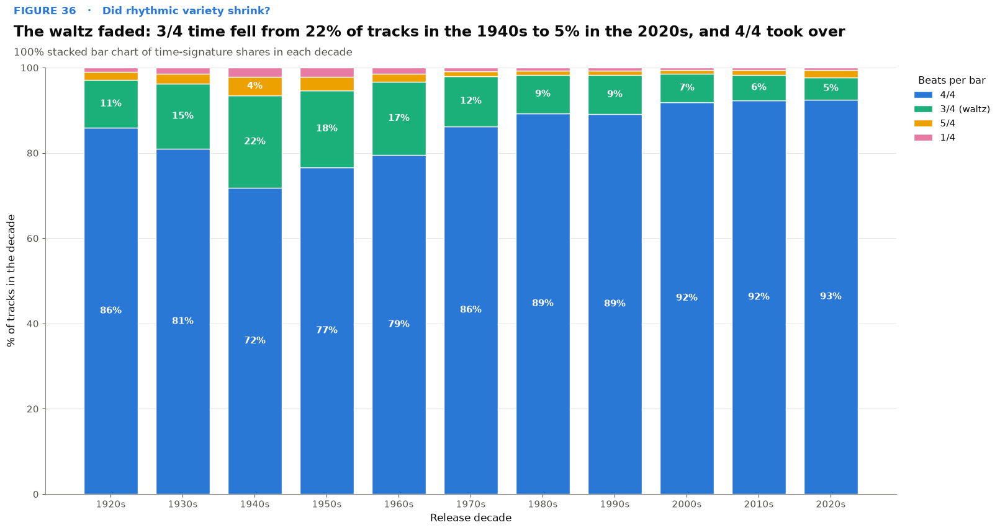

Saved -> figures/fig36_time_signature_by_decade.png


|    |   1920s |   1930s |   1940s |   1950s |   1960s |   1970s |   1980s |   1990s |   2000s |   2010s |   2020s |
|---:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
|  1 |     1.1 |     1.4 |     2.2 |     2.1 |     1.4 |     0.9 |     0.7 |     0.7 |     0.5 |     0.5 |     0.5 |
|  3 |    11.2 |    15.3 |    21.7 |    18.1 |    17.2 |    11.7 |     9.0 |     9.1 |     6.6 |     6.0 |     5.2 |
|  4 |    85.9 |    80.9 |    71.8 |    76.6 |    79.5 |    86.2 |    89.3 |    89.1 |    91.9 |    92.3 |    92.5 |
|  5 |     1.8 |     2.3 |     4.3 |     3.2 |     1.9 |     1.1 |     1.0 |     1.1 |     1.0 |     1.2 |     1.8 |

In [76]:
tsd = pd.crosstab(music['decade_label'], music['time_signature'].astype('float'), normalize='index') * 100
tsd.columns = [int(c) for c in tsd.columns]
fig, ax = plt.subplots(figsize=(16, 7.5), layout='constrained')
bottom = np.zeros(len(tsd))
x = np.arange(len(tsd))
for c in [4, 3, 5, 1]:
    if c not in tsd.columns:
        continue
    ax.bar(x, tsd[c], bottom=bottom, color=ts_cols[c], width=0.75, edgecolor='white', lw=1, label=f'{c}/4' + (' (waltz)' if c == 3 else ''))
    for xi, (v, b0) in enumerate(zip(tsd[c], bottom)):
        if v >= 4:
            ax.text(xi, b0 + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=10.5, color='white', fontweight='bold')
    bottom += tsd[c].values
ax.set_xticks(x, tsd.index.astype(str))
ax.set_ylim(0, 100)
ax.set_ylabel('% of tracks in the decade')
ax.set_xlabel('Release decade')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title='Beats per bar')
save_fig(fig, 36, 'time_signature_by_decade', f'The waltz faded: 3/4 time fell from {tsd.loc["1940s", 3]:.0f}% of tracks in the 1940s to {tsd.loc["2020s", 3]:.0f}% in the 2020s, and 4/4 took over',
         '100% stacked bar chart of time-signature shares in each decade',
         question='Did rhythmic variety shrink?')
md_table(tsd.T, floatfmt='.1f')

**What Figure 36 shows.** 3/4 (waltz) time peaked at **22 % of tracks in the 1940s** and has fallen almost steadily since, to **5 % in the 2020s**. 4/4 rose from 72 % (1940s) to **93 % (2020s)**. Odd meters (5/4, 1/4) were never more than about 4 %.

**How this moves the story forward.** It shows that rhythmic variety narrowed. Popular music standardised on the 4/4 beat that dance music, rock and hip hop share.

Does faster mean more energetic? Figure 37 is a **binned scatter plot**: tracks are grouped into 4-BPM tempo bins, and each dot shows the average energy in that bin (dot size = number of tracks). A LOWESS curve fitted to a 30,000-track sample shows the overall trend.

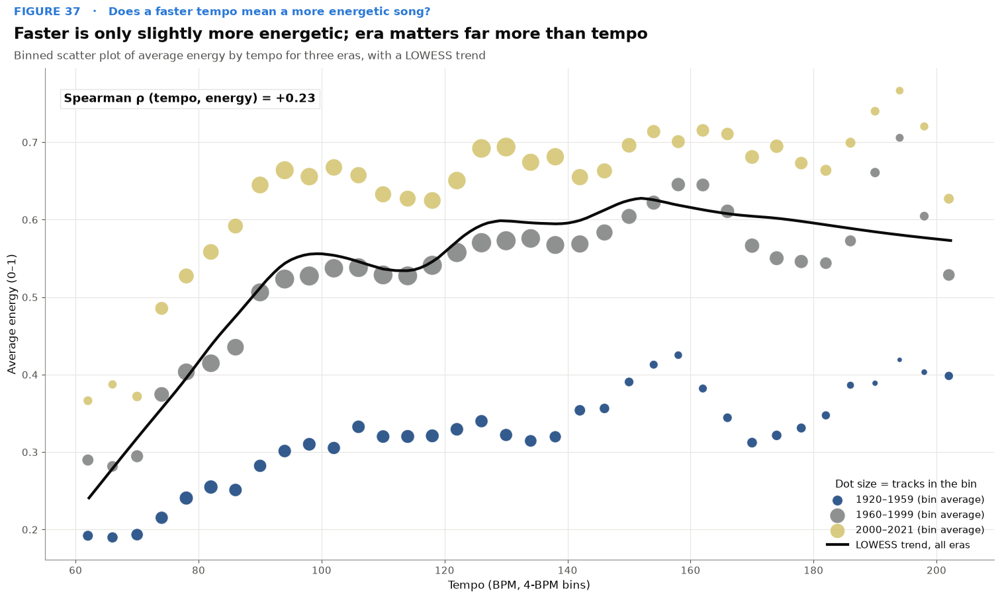

Saved -> figures/fig37_tempo_vs_energy.png


In [77]:
te = music[['tempo', 'energy', 'era3']].dropna()
te['bin'] = pd.cut(te['tempo'], np.arange(60, 206, 4))
fig, ax = plt.subplots(figsize=(15, 8), layout='constrained')
for era, col in ERA_COL.items():
    b = te[te['era3'] == era].groupby('bin', observed=True)['energy'].agg(['mean', 'size'])
    b = b[b['size'] >= 30]
    ax.scatter([iv.mid for iv in b.index], b['mean'], s=np.sqrt(b['size']) * 4, color=col, alpha=0.8, edgecolor='white', lw=0.8, label=f'{era} (bin average)')
smp = te.sample(30_000, random_state=SEED)
fit = lowess(smp['energy'], smp['tempo'], frac=0.25, it=0, delta=1)
ax.plot(fit[:, 0], fit[:, 1], color=INK, lw=3, label='LOWESS trend, all eras')
rho_te = stats.spearmanr(te['tempo'], te['energy']).statistic
ax.text(0.02, 0.95, f'Spearman ρ (tempo, energy) = {rho_te:+.2f}', transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', bbox=dict(fc='white', ec=GRID))
ax.set_xlabel('Tempo (BPM, 4-BPM bins)')
ax.set_ylabel('Average energy (0–1)')
ax.legend(loc='lower right', title='Dot size = tracks in the bin')
save_fig(fig, 37, 'tempo_vs_energy', 'Faster is only slightly more energetic; era matters far more than tempo',
         'Binned scatter plot of average energy by tempo for three eras, with a LOWESS trend',
         question='Does a faster tempo mean a more energetic song?')

**What Figure 37 shows.** Within every era, faster tracks are only slightly more energetic (ρ = +0.23 overall). The dots for different eras sit at very different heights: at the same tempo, a 2000–2021 track averages about 0.65 energy against about 0.3 in 1920–1959.

**How this moves the story forward.** It shows that energy rose because of *how* music was produced (Chapter 2), not because it got faster.

Figure 38 combines a **line chart of the minor-key share** by decade (top) with a **key × decade heatmap** (bottom), in which each column shows how a decade's songs are spread across the 12 keys.

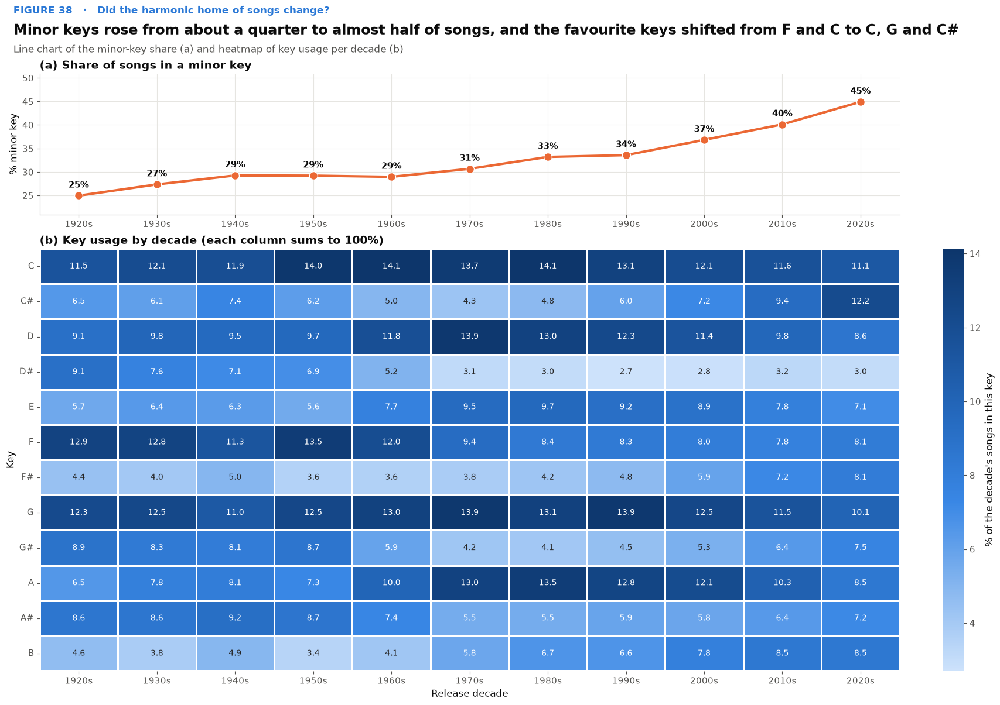

Saved -> figures/fig38_mode_key_by_decade.png


In [78]:
minor_dec = music.groupby('decade_label', observed=True)['mode'].apply(lambda s: (s == 'Minor').mean() * 100)
kd = pd.crosstab(music['key'], music['decade_label'], normalize='columns') * 100
fig = plt.figure(figsize=(17, 11), layout='constrained')
gs = fig.add_gridspec(2, 1, height_ratios=[1, 3])
ax0 = fig.add_subplot(gs[0])
ax0.plot(range(len(minor_dec)), minor_dec.values, color=CAT[1], lw=3, marker='o', markersize=10, markeredgecolor='white')
for i, v in enumerate(minor_dec.values):
    ax0.annotate(f'{v:.0f}%', (i, v), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')
ax0.set_xticks(range(len(minor_dec)), minor_dec.index.astype(str))
ax0.set_ylabel('% minor key')
ax0.set_ylim(minor_dec.min() - 4, minor_dec.max() + 6)
ax0.set_xlim(-0.5, len(minor_dec) - 0.5)
ax0.set_title('(a) Share of songs in a minor key')
ax1 = fig.add_subplot(gs[1])
sns.heatmap(kd, cmap=SEQ, annot=True, fmt='.1f', annot_kws={'fontsize': 10}, linewidths=1, linecolor='white',
            cbar_kws={'label': '% of the decade\'s songs in this key', 'location': 'right'}, ax=ax1)
ax1.set_xlabel('Release decade')
ax1.set_ylabel('Key')
ax1.tick_params(axis='y', rotation=0)
ax1.set_title('(b) Key usage by decade (each column sums to 100%)')
save_fig(fig, 38, 'mode_key_by_decade', 'Minor keys rose from about a quarter to almost half of songs, and the favourite keys shifted from F and C to C, G and C#',
         'Line chart of the minor-key share (a) and heatmap of key usage per decade (b)',
         question='Did the harmonic home of songs change?')

**What Figure 38 shows.** (a) The minor-key share rose from **25 % (1920s)** to about 29 % (1940s–60s), **33–34 % (1980s–90s)**, 37 % (2000s), 40 % (2010s) and **45 % (2020s)**. (b) Key usage shifted too.
* **Declined:** F, D#, G# and A# (common in horn and big-band arrangements) declined from the 1960s.
* **Peaked in the 1970s–90s:** A, D and E (guitar-friendly keys).
* **Grew after 2000:** C#, F# and B, and C# became the most common key of the 2020s (12.2 %).

**How this moves the story forward.** It adds a harmonic layer to the story. Music became darker in tonality, which matches the falling valence in Chapter 4, and its favourite keys moved with its main instruments.

### Multivariate: rhythm in three dimensions, by era, and what listeners reward

Figure 39 is a **3D scatter plot** at the decade level: each sphere is one decade's average tempo, danceability and energy, and its size is the number of tracks. The interactive Plotly version is saved as `figures/fig39_rhythm_3d.html`, and a static matplotlib version is saved as PNG.

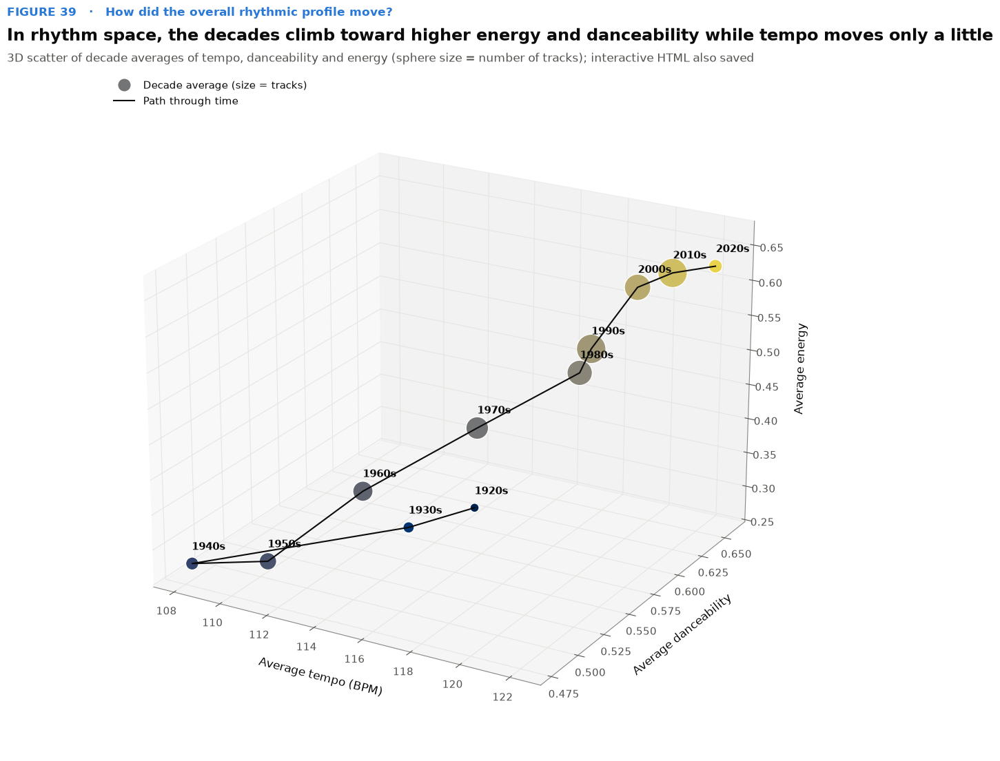

Saved -> figures/fig39_rhythm_3d.png


In [79]:
d3 = music.groupby('decade_label', observed=True).agg(tempo=('tempo', 'mean'), danceability=('danceability', 'mean'), energy=('energy', 'mean'),
                                                       tracks=('id', 'size')).reset_index()
d3['decade'] = d3['decade_label'].astype(str)
pf3 = px.scatter_3d(d3, x='tempo', y='danceability', z='energy', size='tracks', color='decade', text='decade',
                    color_discrete_map={k: mpl.colors.to_hex(v) for k, v in DEC_PAL.items()}, size_max=45, template='simple_white',
                    labels={'tempo': 'Tempo (BPM)', 'danceability': 'Danceability', 'energy': 'Energy'},
                    title='Figure 39 (interactive) · Decade averages of tempo, danceability and energy (size = tracks)')
pf3.write_html(FIG_DIR / 'fig39_rhythm_3d.html', include_plotlyjs='cdn')
pf3.show()
fig = plt.figure(figsize=(13, 10), layout='constrained')
ax = fig.add_subplot(projection='3d')
ax.plot(d3['tempo'], d3['danceability'], d3['energy'], color=INK, lw=1.5)
ax.scatter(d3['tempo'], d3['danceability'], d3['energy'], s=d3['tracks'] / d3['tracks'].max() * 900 + 40,
           c=[DEC_PAL[d] for d in d3['decade']], edgecolor='white', depthshade=False)
for _, r in d3.iterrows():
    ax.text(r['tempo'], r['danceability'], r['energy'] + 0.02, r['decade'], fontsize=11, fontweight='bold')
ax.set_xlabel('Average tempo (BPM)', labelpad=12)
ax.set_ylabel('Average danceability', labelpad=12)
ax.set_zlabel('Average energy', labelpad=12)
ax.view_init(elev=22, azim=-60)
ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=DEC_PAL['1970s'], markersize=12, label='Decade average (size = tracks)'),
                   Line2D([], [], color=INK, lw=1.5, label='Path through time')], loc='upper left')
save_fig(fig, 39, 'rhythm_3d', 'In rhythm space, the decades climb toward higher energy and danceability while tempo moves only a little',
         '3D scatter of decade averages of tempo, danceability and energy (sphere size = number of tracks); interactive HTML also saved',
         question='How did the overall rhythmic profile move?')

**What Figure 39 shows.** The decade averages climb steadily through rhythm space. From the 1940s to the 2010s, energy rises from about 0.28 to 0.66 and danceability from about 0.48 to 0.61, while tempo moves only from about 108 to 122 BPM. The 1920s–30s sit apart (more danceable dance-band and tango recordings), and the path bends back after them.

**How this moves the story forward.** It combines the three rhythm features in one view. Music's rhythmic journey is mostly upward (more energetic, more danceable) and only slightly to the right (faster).

Figure 40 is a **parallel-coordinates plot**. Each faint line is one track (150 random tracks per era), drawn across four rhythm features rescaled to 0–1, and the thick line is the era median. Lines that bunch together mean an era's rhythms are similar to each other.

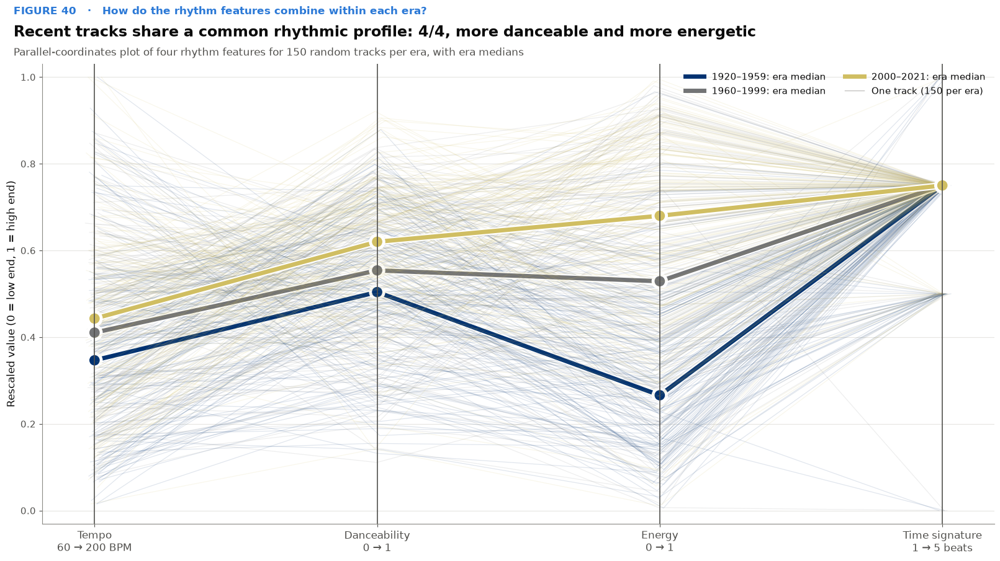

Saved -> figures/fig40_rhythm_parallel.png


In [80]:
PC_FEATS = {'tempo': (60, 200), 'danceability': (0, 1), 'energy': (0, 1), 'time_signature': (1, 5)}
pcd = music[list(PC_FEATS) + ['era3']].dropna()
for f, (lo_, hi_) in PC_FEATS.items():
    pcd[f + '_s'] = ((pcd[f].astype(float) - lo_) / (hi_ - lo_)).clip(0, 1)
cols_s = [f + '_s' for f in PC_FEATS]
fig, ax = plt.subplots(figsize=(16, 8), layout='constrained')
xs4 = np.arange(len(PC_FEATS))
for era, col in ERA_COL.items():
    smp = pcd[pcd['era3'] == era].sample(150, random_state=SEED)
    for _, r in smp.iterrows():
        ax.plot(xs4 + rng.normal(0, 0.012, len(xs4)), r[cols_s].values, color=col, alpha=0.12, lw=0.9)
    ax.plot(xs4, pcd.loc[pcd['era3'] == era, cols_s].median().values, color=col, lw=5, marker='o', markersize=11,
            path_effects=[pe.withStroke(linewidth=8, foreground='white')], label=f'{era} median')
for x_ in xs4:
    ax.axvline(x_, color=INK2, lw=1.2)
ax.set_xticks(xs4, ['Tempo\n60 → 200 BPM', 'Danceability\n0 → 1', 'Energy\n0 → 1', 'Time signature\n1 → 5 beats'], fontsize=12)
ax.set_ylabel('Rescaled value (0 = low end, 1 = high end)')
ax.set_ylim(-0.03, 1.03)
ax.grid(axis='x', visible=False)
ax.legend(handles=[Line2D([], [], color=c, lw=5, label=f'{e}: era median') for e, c in ERA_COL.items()]
          + [Line2D([], [], color=MUTED, lw=1, alpha=0.5, label='One track (150 per era)')], loc='upper right', ncol=2)
save_fig(fig, 40, 'rhythm_parallel', 'Recent tracks share a common rhythmic profile: 4/4, more danceable and more energetic',
         'Parallel-coordinates plot of four rhythm features for 150 random tracks per era, with era medians',
         question='How do the rhythm features combine within each era?')

**What Figure 40 shows.** The thick median lines separate cleanly. 2000–2021 tracks sit highest on danceability (0.62) and energy (0.68) and slightly higher on tempo, and almost all of them land on 4/4. The faint lines of 1920–1959 tracks spread more widely across time signatures and sit low on energy.

**How this moves the story forward.** It shows that modern tracks share one dominant rhythmic profile, while early music was more varied.

Which combination of tempo and danceability do listeners reward? Popularity mostly reflects *how recent* a track is (Chapter 4), so Figure 41 is restricted to **tracks released 2010–2021**. The **heatmap** shows average popularity in each tempo × danceability cell (cells with fewer than 40 tracks are left blank).

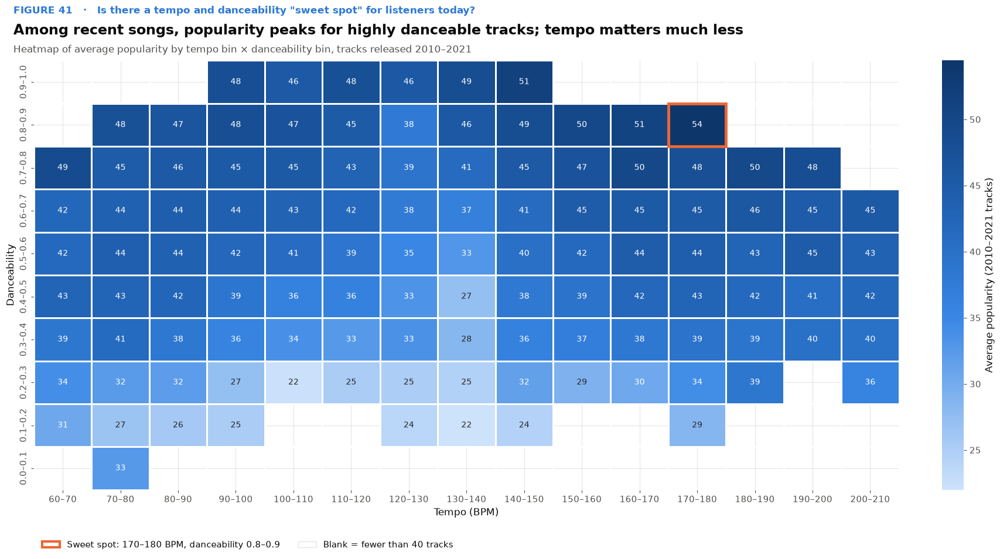

Saved -> figures/fig41_tempo_dance_popularity_heatmap.png
Mean popularity by danceability bin (2010–2021): {Interval(0.0, 0.1, closed='right'): 28.4, Interval(0.1, 0.2, closed='right'): 25.5, Interval(0.2, 0.3, closed='right'): 30.3, Interval(0.3, 0.4, closed='right'): 36.0, Interval(0.4, 0.5, closed='right'): 37.3, Interval(0.5, 0.6, closed='right'): 39.7, Interval(0.6, 0.7, closed='right'): 41.5, Interval(0.7, 0.8, closed='right'): 43.6, Interval(0.8, 0.9, closed='right'): 44.8, Interval(0.9, 1.0, closed='right'): 47.1}


In [81]:
r10 = music[music['release_year'] >= 2010].dropna(subset=['tempo'])
r10 = r10.assign(tbin=pd.cut(r10['tempo'], np.arange(60, 211, 10)), dbin=pd.cut(r10['danceability'], np.arange(0, 1.01, 0.1)))
pv = r10.pivot_table(index='dbin', columns='tbin', values='popularity', aggfunc='mean', observed=False)
pn = r10.pivot_table(index='dbin', columns='tbin', values='popularity', aggfunc='size', observed=False)
pv = pv.where(pn >= 40).iloc[::-1]
pv.index = [f'{iv.left:.1f}–{iv.right:.1f}' for iv in pv.index]
pv.columns = [f'{int(iv.left)}–{int(iv.right)}' for iv in pv.columns]
fig, ax = plt.subplots(figsize=(17, 8.5), layout='constrained')
sns.heatmap(pv, cmap=SEQ, annot=True, fmt='.0f', annot_kws={'fontsize': 10}, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Average popularity (2010–2021 tracks)'}, ax=ax)
mi = np.unravel_index(np.nanargmax(pv.values), pv.shape)
ax.add_patch(Rectangle((mi[1], mi[0]), 1, 1, fill=False, edgecolor=CAT[1], lw=3.5))
ax.set_xlabel('Tempo (BPM)')
ax.set_ylabel('Danceability')
ax.legend(handles=[Patch(facecolor='white', edgecolor=CAT[1], lw=3, label=f'Sweet spot: {pv.columns[mi[1]]} BPM, danceability {pv.index[mi[0]]}'),
                   Patch(facecolor='white', edgecolor=GRID, label='Blank = fewer than 40 tracks')], loc='upper left', bbox_to_anchor=(0, -0.1), ncol=2)
save_fig(fig, 41, 'tempo_dance_popularity_heatmap', 'Among recent songs, popularity peaks for highly danceable tracks; tempo matters much less',
         'Heatmap of average popularity by tempo bin × danceability bin, tracks released 2010–2021',
         question='Is there a tempo and danceability "sweet spot" for listeners today?')
print('Mean popularity by danceability bin (2010–2021):', r10.groupby('dbin', observed=True)['popularity'].mean().round(1).to_dict())

**What Figure 41 shows.** Among 2010–2021 tracks, average popularity rises steadily with danceability, from about 25–30 for the least danceable bins to about **47 for danceability 0.9–1.0**. Tempo makes much less difference along a row. The single highest cell is 170–180 BPM with danceability 0.8–0.9 (popularity 54), a double-time reading of mid-tempo hip-hop and pop beats.

**How this moves the story forward.** It answers "what do people look for in rhythm today?" Listeners reward a strong, danceable beat much more than any particular speed.

Figure 42 animates how each genre family moved in tempo × danceability space, year by year (Plotly, `figures/fig42_tempo_dance_animated.html`; each bubble's size is the genre's number of tracks that year). The static PNG version is a **connected scatter**: each line follows one genre family's average from decade to decade.

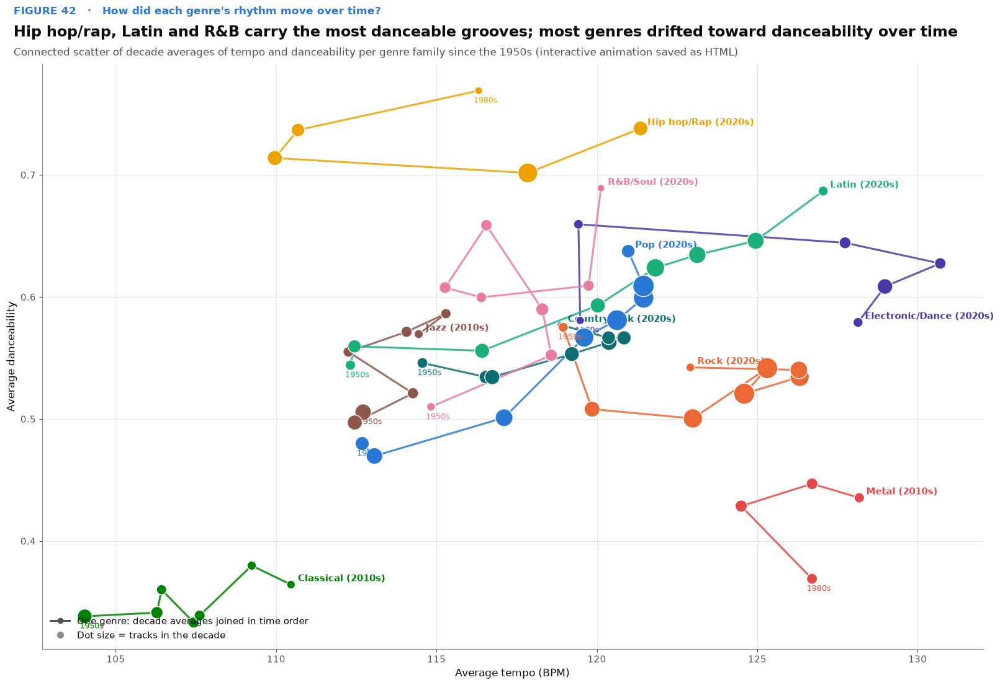

Saved -> figures/fig42_genre_rhythm_paths.png


In [82]:
gy = (music[music['primary_genre_family'].isin(FAM_ORDER[:-1]) & (music['release_year'] >= 1950)]
      .groupby(['release_year', 'primary_genre_family'], observed=True)
      .agg(tempo=('tempo', 'mean'), danceability=('danceability', 'mean'), tracks=('id', 'size')).reset_index())
gy = gy[gy['tracks'] >= 20]
pfa = px.scatter(gy, x='tempo', y='danceability', animation_frame='release_year', size='tracks', color='primary_genre_family',
                 color_discrete_map=GENRE_COL, hover_name='primary_genre_family', size_max=55, template='simple_white',
                 range_x=[gy['tempo'].min() - 3, gy['tempo'].max() + 3], range_y=[gy['danceability'].min() - 0.03, gy['danceability'].max() + 0.03],
                 labels={'tempo': 'Average tempo (BPM)', 'danceability': 'Average danceability', 'primary_genre_family': 'Genre family'},
                 title='Figure 42 (interactive) · Genre families in tempo × danceability space, year by year (size = tracks)')
pfa.write_html(FIG_DIR / 'fig42_tempo_dance_animated.html', include_plotlyjs='cdn', auto_play=False)
pfa.show()
gd = (music[music['primary_genre_family'].isin(FAM_ORDER[:-1]) & (music['release_year'] >= 1950)]
      .groupby(['primary_genre_family', 'decade_label'], observed=True)
      .agg(tempo=('tempo', 'mean'), danceability=('danceability', 'mean'), tracks=('id', 'size')).reset_index())
gd = gd[gd['tracks'] >= 150]
fig, ax = plt.subplots(figsize=(16, 10), layout='constrained')
for fam, g_ in gd.groupby('primary_genre_family'):
    g_ = g_.sort_values('decade_label')
    if len(g_) < 2:
        continue
    col = GENRE_COL[fam]
    ax.plot(g_['tempo'], g_['danceability'], color=col, lw=2.2, alpha=0.85)
    ax.scatter(g_['tempo'], g_['danceability'], s=np.sqrt(g_['tracks']) * 4, color=col, edgecolor='white', lw=1, zorder=3)
    last = g_.iloc[-1]
    ax.annotate(f"{fam} ({last['decade_label']})", (last['tempo'], last['danceability']), xytext=(8, 4), textcoords='offset points',
                fontsize=11, fontweight='bold', color=col)
    first = g_.iloc[0]
    ax.annotate(str(first['decade_label']), (first['tempo'], first['danceability']), xytext=(-6, -14), textcoords='offset points', fontsize=9, color=col)
ax.set_xlabel('Average tempo (BPM)')
ax.set_ylabel('Average danceability')
ax.legend(handles=[Line2D([], [], color=INK2, lw=2.2, marker='o', label='One genre: decade averages joined in time order'),
                   Line2D([], [], marker='o', ls='none', color=MUTED, markersize=7, label='Dot size = tracks in the decade')], loc='lower left')
save_fig(fig, 42, 'genre_rhythm_paths', 'Hip hop/rap, Latin and R&B carry the most danceable grooves; most genres drifted toward danceability over time',
         'Connected scatter of decade averages of tempo and danceability per genre family since the 1950s (interactive animation saved as HTML)',
         question='How did each genre\'s rhythm move over time?')

**What Figure 42 shows.** Each genre has its own rhythm, and most moved toward danceability.
* **Most danceable:** hip hop/rap (about 0.70–0.74 since the 1990s).
* **Rising to near the top:** Latin (0.69 in the 2020s) and R&B/soul (0.69).
* **Least danceable:** classical (about 0.35) and metal (about 0.44), though both are fast.
* **Rising steadily:** pop, from 0.47 (1950s) to 0.64 (2020s).

The interactive HTML animation shows the same movement year by year.

**How this moves the story forward.** It connects the rhythm story to the artist story. The genres that grew (hip hop, Latin, electronic) are the danceable ones, which partly explains the rise in average danceability.

> ### Chapter 3 Takeaways: The Tempo
> * **Music did not get much faster.** Median tempo rose only from about 108 BPM (1950s) to about 122 BPM (2020s), a small effect (ρ = +0.11, η²_H = 0.02), and tempos cluster around peaks at 98 and 128 BPM (Figures 31, 33, 34).
> * **It got much more danceable and more uniform.** Danceability rose from 0.48 (1940s–50s) to 0.68 (2020s) (Figure 33). 4/4 time grew from 72 % to 93 % while the waltz fell from 22 % to 5 % (Figure 36).
> * **Harmony darkened, and listeners reward the beat.** Minor keys rose from 25 % to 45 % of songs (Figure 38). Among 2010–2021 songs, popularity rises from about 25 to 47 as danceability increases (Figure 41).

<a id="chapter-4"></a>
## Chapter 4: The Meaning. What do songs say, how do they feel, and what do people look for?

**The story in this chapter.** Beyond how music sounds, what does it express? Did it become sadder or happier, more spoken, more explicit? What do song titles talk about? And what do listeners reward today?

> **Important: this dataset has no lyrics.** "Meaning" is approached through **proxies**: *valence* (how happy the music sounds), *mode* (major/minor), *speechiness* (spoken or rapped delivery), the *explicit* flag, and the **words in track titles**. *Popularity* (2021 streaming) is the proxy for what people look for. These proxies describe the music's character, not the literal content of lyrics.

**Mood quadrants.** Each track is placed in one of four moods by cutting energy and valence at 0.5: **Happy/Energetic** (high energy, high valence), **Angry/Intense** (high energy, low valence), **Peaceful/Content** (low energy, high valence) and **Sad/Melancholy** (low energy, low valence).

In [83]:
# ---- Title words: lower-case, keep letters only, drop stop words (English + common Spanish/French/Italian/German function words) ----
STOP = set('''a an the and or of to in on at for with from by is it its be are was were i you me my your we our us he she they his her them this that
these those not no so but if as up out all just what when where who how can do don't dont im i'm it's its oh yeah ya na la le de del el en y los las un
una con por para que se mi tu te lo al di da e o il et des du mon ma je pas qui une les der die das und ist ich du nicht ein eine zu von mit
op no nr pt vol part ii iii iv am pm vs'''.split())
WORD_RE = re.compile(r"[a-zà-öø-ÿ']+")
def title_tokens(s):
    return [w for w in (t_.strip("'") for t_ in WORD_RE.findall(str(s).lower())) if len(w) > 1 and w not in STOP]
music['title_tokens'] = music['name'].map(title_tokens)
WATCH = ['love', 'baby', 'night', 'feat', 'remix', 'live']
for w in WATCH:
    music[f'has_{w}'] = music['title_tokens'].map(lambda toks, w=w: w in toks)
tests_meaning = trend_tests(music, ['valence', 'speechiness', 'popularity', 'title_word_count'])
show_tests(tests_meaning)
tests_meaning.to_csv(OUT_DIR / 'trend_tests_meaning.csv')

| feature          |   Spearman ρ with year | p (ρ)    |   Kruskal H | p (H)    |   η²_H |   ANOVA η² | size   |
|:-----------------|-----------------------:|:---------|------------:|:---------|-------:|-----------:|:-------|
| valence          |                 -0.055 | < 1e-300 |   7,396.246 | < 1e-300 |  0.015 |      0.015 | small  |
| speechiness      |                  0.080 | < 1e-300 |  20,218.724 | < 1e-300 |  0.041 |      0.029 | small  |
| popularity       |                  0.579 | < 1e-300 | 181,380.308 | < 1e-300 |  0.367 |      0.356 | large  |
| title_word_count |                 -0.215 | < 1e-300 |  27,413.695 | < 1e-300 |  0.055 |      0.070 | small  |

### Univariate: mood, popularity and explicit content

Figure 43 combines a **histogram with a KDE** of valence, a **histogram** of popularity (with the spike at 0 highlighted), and a **stat tile** for the share of explicit tracks.

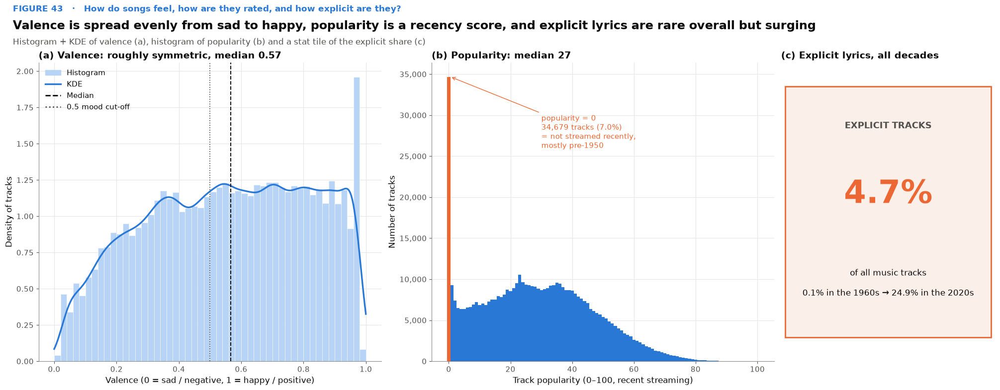

Saved -> figures/fig43_meaning_distributions.png


In [84]:
fig = plt.figure(figsize=(20, 6.8), layout='constrained')
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.2, 0.75])
ax = fig.add_subplot(gs[0])
v = music['valence'].dropna()
ax.hist(v, bins=50, density=True, color='#b7d3f6', edgecolor='white', lw=0.4)
xs = np.linspace(0, 1, 300)
ax.plot(xs, stats.gaussian_kde(v.sample(50_000, random_state=SEED), bw_method=0.1)(xs), color=CAT[0], lw=2.4)
ax.axvline(0.5, color=INK2, ls=':', lw=1.3)
ax.axvline(v.median(), color=INK, ls='--', lw=1.4)
ax.set_title(f'(a) Valence: {hist_shape(v)}, median {v.median():.2f}')
ax.set_xlabel('Valence (0 = sad / negative, 1 = happy / positive)')
ax.set_ylabel('Density of tracks')
ax.legend(handles=[Patch(color='#b7d3f6', label='Histogram'), Line2D([], [], color=CAT[0], lw=2.4, label='KDE'),
                   Line2D([], [], color=INK, ls='--', label='Median'), Line2D([], [], color=INK2, ls=':', label='0.5 mood cut-off')], loc='upper left')
ax = fig.add_subplot(gs[1])
pc = music['popularity'].value_counts().sort_index()
ax.bar(pc.index, pc.values, width=1, color=[CAT[1] if i == 0 else CAT[0] for i in pc.index], lw=0)
ax.annotate(f'popularity = 0\n{pc.loc[0]:,} tracks ({pc.loc[0] / pc.sum():.1%})\n= not streamed recently,\nmostly pre-1950', xy=(0.5, pc.loc[0]),
            xytext=(30, pc.loc[0] * 0.75), fontsize=11, color=CAT[1], arrowprops=dict(arrowstyle='->', color=CAT[1]))
ax.set_title(f"(b) Popularity: median {music['popularity'].median():.0f}")
ax.set_xlabel('Track popularity (0–100, recent streaming)')
ax.set_ylabel('Number of tracks')
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
ax = fig.add_subplot(gs[2])
ax.axis('off')
exp_all = (music['explicit'] == 'Explicit').mean() * 100
exp_dec_ = music.groupby('decade_label', observed=True)['explicit'].apply(lambda s: (s == 'Explicit').mean() * 100)
ax.add_patch(Rectangle((0.02, 0.08), 0.96, 0.84, transform=ax.transAxes, fc='#fbefea', ec=CAT[1], lw=2))
ax.text(0.5, 0.78, 'EXPLICIT TRACKS', transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold', color=INK2)
ax.text(0.5, 0.53, f'{exp_all:.1f}%', transform=ax.transAxes, ha='center', fontsize=46, fontweight='bold', color=CAT[1])
ax.text(0.5, 0.22, f"of all music tracks\n\n{exp_dec_['1960s']:.1f}% in the 1960s → {exp_dec_['2020s']:.1f}% in the 2020s",
        transform=ax.transAxes, ha='center', fontsize=12, color=INK)
ax.set_title('(c) Explicit lyrics, all decades')
save_fig(fig, 43, 'meaning_distributions', 'Valence is spread evenly from sad to happy, popularity is a recency score, and explicit lyrics are rare overall but surging',
         'Histogram + KDE of valence (a), histogram of popularity (b) and a stat tile of the explicit share (c)',
         question='How do songs feel, how are they rated, and how explicit are they?')

**What Figure 43 shows.** (a) Valence is roughly symmetric and spread across the whole range (median 0.57), so the catalogue holds plenty of both happy- and sad-sounding music. (b) Popularity has a broad hump around 10–45 (median 27) and a spike of 34,679 tracks (7.0 %) at 0. Those are tracks not streamed recently, mostly from before 1950. (c) Only **4.7 %** of all tracks are explicit, but that rises from **0.1 % in the 1960s to 24.9 % in the 2020s**.

**How this moves the story forward.** It introduces the proxies for meaning (valence, explicit) and for what people look for (popularity), and it warns that popularity is mainly a recency score.

What do song titles talk about? Figure 44 is a **horizontal bar chart** of the 25 most common title words across all music tracks (after removing stop words, numbers and symbols).

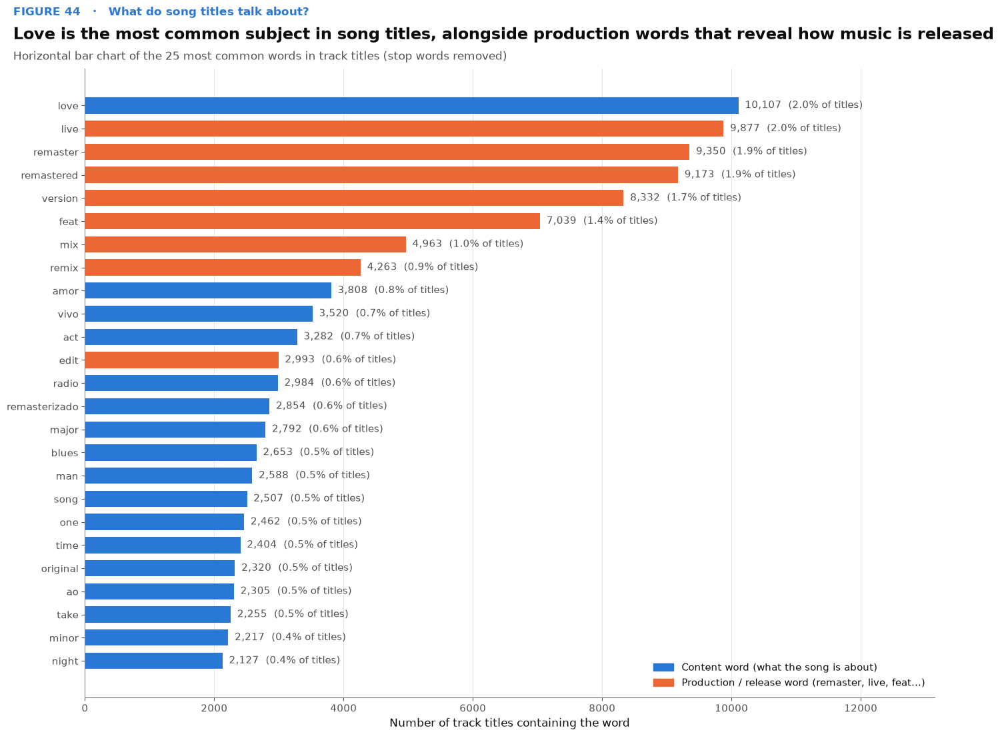

Saved -> figures/fig44_title_words.png


In [85]:
word_counts = Counter(w for toks in music['title_tokens'] for w in set(toks))
top_words = pd.Series(dict(word_counts.most_common(25))).iloc[::-1]
fig, ax = plt.subplots(figsize=(14, 10), layout='constrained')
hl = {'love', 'heart', 'baby', 'night', 'feat', 'remix', 'live', 'remastered', 'remaster', 'version'}
cols = [CAT[1] if w in {'feat', 'remix', 'live', 'remastered', 'remaster', 'version', 'mix', 'edit', 'mono', 'stereo'} else CAT[0] for w in top_words.index]
ax.barh(top_words.index, top_words.values, color=cols, height=0.7)
for y_, (w, c) in enumerate(top_words.items()):
    ax.text(c + top_words.max() * 0.01, y_, f'{c:,}  ({c / len(music):.1%} of titles)', va='center', fontsize=10.5, color=INK2)
ax.set_xlim(0, top_words.max() * 1.3)
ax.set_xlabel('Number of track titles containing the word')
ax.grid(axis='y', visible=False)
ax.legend(handles=[Patch(color=CAT[0], label='Content word (what the song is about)'), Patch(color=CAT[1], label='Production / release word (remaster, live, feat…)')],
          loc='lower right')
save_fig(fig, 44, 'title_words', 'Love is the most common subject in song titles, alongside production words that reveal how music is released',
         'Horizontal bar chart of the 25 most common words in track titles (stop words removed)',
         question='What do song titles talk about?')

**What Figure 44 shows.** "Love" is the most common content word in titles (10,107 titles, 2.0 %), with its Spanish form "amor" ninth. Many of the other top words are about **how a track was released** rather than what it is about: "live", "remaster(ed)", "version", "feat", "mix", "remix" and "edit".

**How this moves the story forward.** It shows both what songs talk about (love, life, night, the heart) and the commercial life of a song (remasters, live versions, remixes, features).

### Bivariate: how meaning changed over time

Figure 45 uses **small-multiple line charts** to follow selected title words across decades (the share of titles that contain each word), plus the average title length.

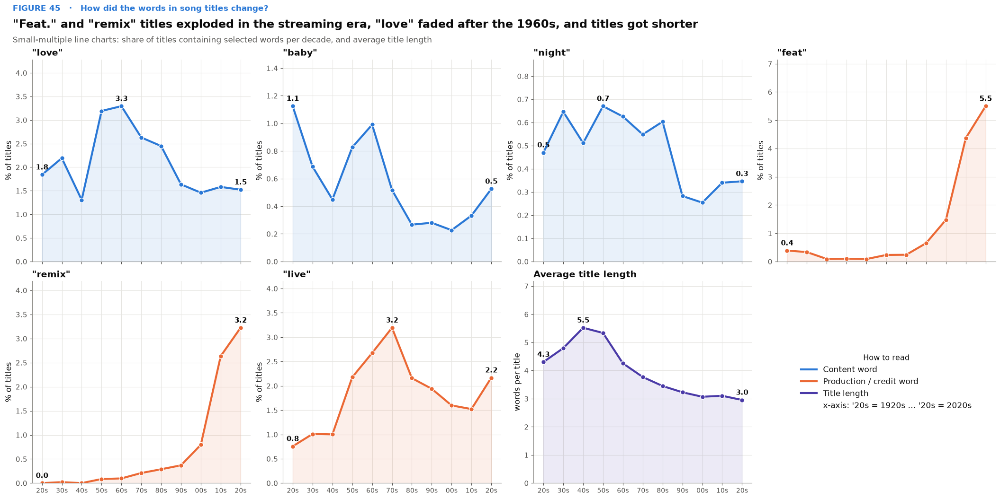

Saved -> figures/fig45_title_word_trends.png


|           |   1920s |   1930s |   1940s |   1950s |   1960s |   1970s |   1980s |   1990s |   2000s |   2010s |   2020s |
|:----------|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| has_love  |    1.84 |    2.19 |    1.31 |    3.19 |    3.29 |    2.63 |    2.45 |    1.64 |    1.46 |    1.58 |    1.52 |
| has_baby  |    1.12 |    0.69 |    0.45 |    0.83 |    0.99 |    0.52 |    0.27 |    0.28 |    0.23 |    0.33 |    0.53 |
| has_night |    0.47 |    0.65 |    0.51 |    0.67 |    0.63 |    0.55 |    0.60 |    0.28 |    0.25 |    0.34 |    0.35 |
| has_feat  |    0.39 |    0.33 |    0.09 |    0.10 |    0.09 |    0.23 |    0.24 |    0.65 |    1.48 |    4.37 |    5.50 |
| has_remix |    0.00 |    0.02 |    0.00 |    0.09 |    0.10 |    0.21 |    0.29 |    0.37 |    0.80 |    2.64 |    3.22 |
| has_live  |    0.76 |    1.01 |    1.00 |    2.18 |    2.68 |    3.19 |    2.16 |    1.94 |    1.60 |    1.52 |    2.17 |

In [86]:
wd = music.groupby('decade_label', observed=True)[[f'has_{w}' for w in WATCH]].mean() * 100
tl = music.groupby('decade_label', observed=True)['title_word_count'].mean()
fig, axes = plt.subplots(2, 4, figsize=(21, 9.5), layout='constrained', sharex=True)
xd = np.arange(len(wd))
panels = [(w, wd[f'has_{w}'], '% of titles') for w in WATCH] + [('average title length', tl, 'words per title')]
for k_, (ax, (lbl, ser, ylab)) in enumerate(zip(axes.flat, panels)):
    col = CAT[1] if lbl in ('feat', 'remix', 'live') else CAT[6] if lbl == 'average title length' else CAT[0]
    ax.plot(xd, ser.values, color=col, lw=3, marker='o', markersize=7, markeredgecolor='white')
    ax.fill_between(xd, ser.values, color=col, alpha=0.1)
    for i in (0, int(np.argmax(ser.values)), len(ser) - 1):
        ax.annotate(f'{ser.values[i]:.1f}', (i, ser.values[i]), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=10.5, fontweight='bold')
    ax.set_title(f'"{lbl}"' if lbl in WATCH else lbl.capitalize(), fontsize=13.5)
    ax.set_ylabel(ylab)
    ax.set_ylim(0, ser.max() * 1.3)
    ax.set_xticks(xd, [d[2:] for d in wd.index.astype(str)], fontsize=10)
axes.flat[-1].axis('off')
axes.flat[-1].legend(handles=[Line2D([], [], color=CAT[0], lw=3, label='Content word'), Line2D([], [], color=CAT[1], lw=3, label='Production / credit word'),
                              Line2D([], [], color=CAT[6], lw=3, label='Title length'), Patch(color='white', label="x-axis: '20s = 1920s … '20s = 2020s")],
                     loc='center', fontsize=12, title='How to read')
save_fig(fig, 45, 'title_word_trends', '"Feat." and "remix" titles exploded in the streaming era, "love" faded after the 1960s, and titles got shorter',
         'Small-multiple line charts: share of titles containing selected words per decade, and average title length',
         question='How did the words in song titles change?')
md_table(wd.T.assign(**{}), floatfmt='.2f')

**What Figure 45 shows.**
* **"Feat."** appears in **0.24 % of 1980s titles but 5.5 % of 2020s titles**.
* **"Remix"** rose from 0.29 % to 3.2 %.
* **"Love"** peaked in the 1950s–60s (3.3 %) and fell to 1.5 %.
* **"Baby" and "night"** declined after the 1970s.
* **"Live"** peaked in the 1970s (the era of live albums).
* **Title length** fell from 5.5 words (1940s, long classical titles) to **3.0 words** in the 2020s.

**How this moves the story forward.** Even without lyrics, titles show the shift toward collaboration and remix culture and away from the romantic vocabulary of mid-century songs.

Figure 46 uses **box plots** of popularity. Panel (a) is by decade, which shows the recency effect. Panel (b) is by mood quadrant, restricted to 2010–2021 so that the moods are compared within the same era.

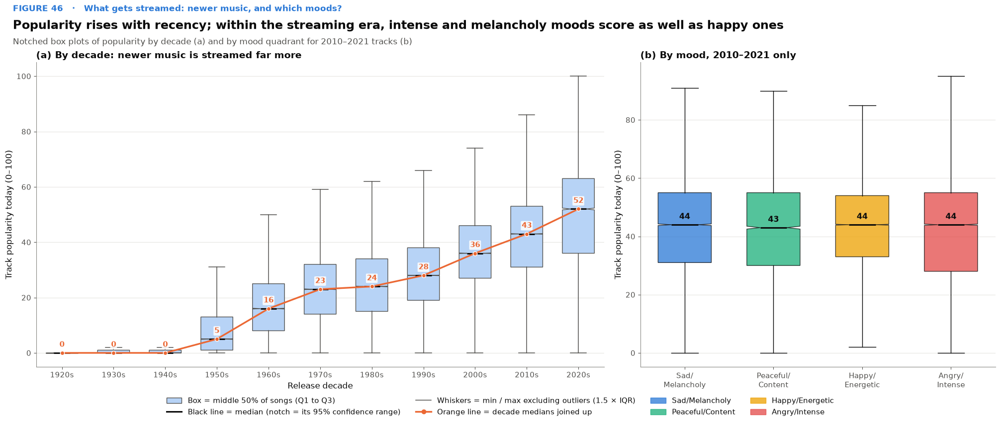

Saved -> figures/fig46_popularity_boxes.png
Median popularity 2010–2021 by mood: {'Sad/Melancholy': 44.0, 'Peaceful/Content': 43.0, 'Happy/Energetic': 44.0, 'Angry/Intense': 44.0}


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7.5), layout='constrained', gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
meds = decade_boxes(ax, music, 'popularity', notch=True)
for i, v in enumerate(meds):
    ax.annotate(f'{v:.0f}', (i + 1, v), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=11, fontweight='bold', color=CAT[1],
                bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85))
ax.set_xlabel('Release decade')
ax.set_ylabel('Track popularity today (0–100)')
ax.set_title('(a) By decade: newer music is streamed far more')
ax = axes[1]
rec10 = music[music['release_year'] >= 2010]
data_m = [rec10.loc[rec10['mood_quadrant'] == m, 'popularity'].values for m in MOODS]
bp = ax.boxplot(data_m, notch=True, patch_artist=True, widths=0.6, showfliers=False, medianprops=dict(color=INK, lw=2.2))
for patch, m in zip(bp['boxes'], MOODS):
    patch.set_facecolor(MOOD_COL[m]); patch.set_alpha(0.75)
for i, m in enumerate(MOODS):
    md_ = np.median(data_m[i])
    ax.text(i + 1, md_ + 2, f'{md_:.0f}', ha='center', fontsize=11.5, fontweight='bold')
ax.set_xticks(range(1, 5), [m.replace('/', '/\n') for m in MOODS])
ax.set_ylabel('Track popularity today (0–100)')
ax.set_title('(b) By mood, 2010–2021 only')
ax.grid(axis='x', visible=False)
fig.legend(handles=BOX_LEGEND + [Patch(color=MOOD_COL[m], alpha=0.75, label=m) for m in MOODS], loc='outside lower center', ncol=4)
save_fig(fig, 46, 'popularity_boxes', 'Popularity rises with recency; within the streaming era, intense and melancholy moods score as well as happy ones',
         'Notched box plots of popularity by decade (a) and by mood quadrant for 2010–2021 tracks (b)',
         question='What gets streamed: newer music, and which moods?')
print('Median popularity 2010–2021 by mood:', {m: float(np.median(d)) for m, d in zip(MOODS, data_m)})

**What Figure 46 shows.** (a) Median popularity climbs from 0 in the 1920s–40s to 16 (1960s), 28 (1990s), 43 (2010s) and **52 (2020s)**. (b) Within 2010–2021, the four moods have almost the same median popularity (43–44), with similar spreads.

**How this moves the story forward.** It shows that listeners mostly reward *recent* music. Within the same era, mood alone does not decide popularity: sad and intense songs do as well as happy ones.

Is music getting sadder or happier? Figure 47 is a **line chart** of the yearly mean valence with a 95 % confidence band, plus the yearly median.

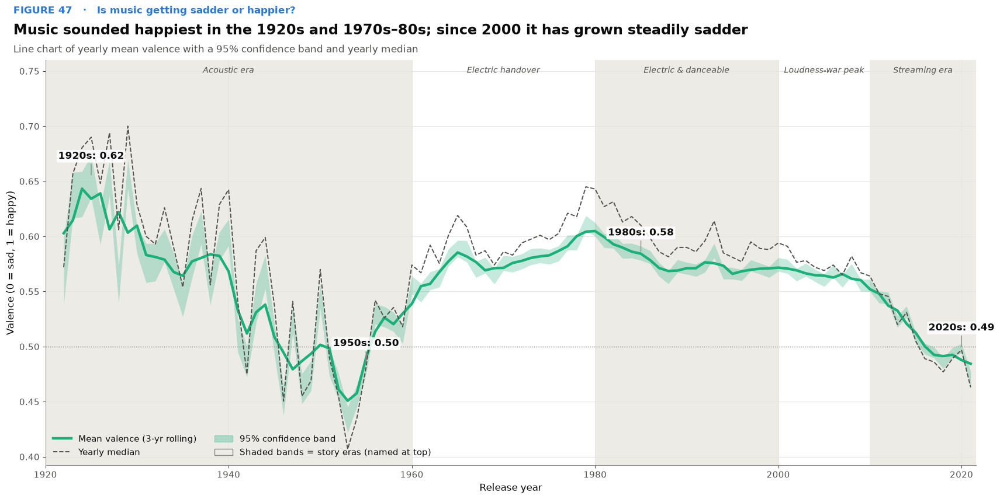

Saved -> figures/fig47_valence_trend.png


In [88]:
yv = yearly_band(music, 'valence')
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
ax.fill_between(yv.index, yv['lo'], yv['hi'], color=CAT[2], alpha=0.25, lw=0, zorder=2)
ax.plot(yv.index, yv['mean'].rolling(3, center=True, min_periods=1).mean(), color=CAT[2], lw=3.2, zorder=3, label='Mean valence (3-yr rolling)')
ax.plot(yv.index, yv['median'], color=INK2, lw=1.4, ls='--', zorder=3, label='Yearly median')
ax.axhline(0.5, color=MUTED, lw=1, ls=':')
add_eras(ax)
dv = music.groupby('decade_label', observed=True)['valence'].mean()
for d in ['1920s', '1950s', '1980s', '2020s']:
    yr = int(d[:4]) + (5 if d != '2020s' else 0)
    ax.annotate(f'{d}: {dv[d]:.2f}', (yr, yv.loc[yr, 'mean']), xytext=(0, 22), textcoords='offset points', ha='center', fontsize=12, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=MUTED), bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
ax.set_xlim(1920, 2021.6)
ax.set_xlabel('Release year')
ax.set_ylabel('Valence (0 = sad, 1 = happy)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h + [Patch(color=CAT[2], alpha=0.3, label='95% confidence band'), ERA_HANDLE], loc='lower left', ncol=2)
save_fig(fig, 47, 'valence_trend', 'Music sounded happiest in the 1920s and 1970s–80s; since 2000 it has grown steadily sadder',
         'Line chart of yearly mean valence with a 95% confidence band and yearly median',
         question='Is music getting sadder or happier?')

**What Figure 47 shows.** Mean valence was highest in the 1920s (0.62, dance bands and tango), fell to its lowest point in the early 1950s (about 0.45–0.50), recovered to about 0.58–0.60 in the 1970s–80s, and has fallen steadily since about 2005 to **0.49 in the 2020s**. That is the lowest decade level since the 1950s. The confidence band is narrow after 1960.

**How this moves the story forward.** It answers "is music getting sadder?" Yes, since the 2000s, although the overall effect over the century is small (η²_H = 0.015).

Figure 48 is a **stacked area chart** of spoken delivery: the share of tracks with some spoken delivery (speechiness 0.10–0.33) and with rap-like delivery (0.33–0.66). Pure spoken word (> 0.66) was removed in cleaning.

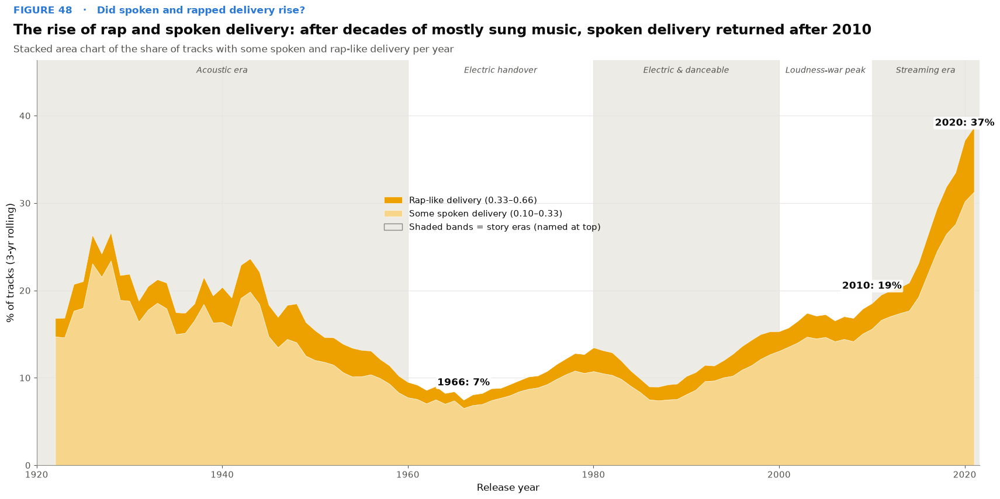

Saved -> figures/fig48_speechiness_area.png
Spoken+rap share: {1930: 21.9, 1966: 7.5, 2000: 15.3, 2010: 18.5, 2020: 37.2}


In [89]:
sp = music.assign(band=pd.cut(music['speechiness'], [0, 0.10, 0.33, 0.66], labels=['mostly sung', 'some spoken delivery', 'rap-like delivery'],
                              include_lowest=True))
spy = (pd.crosstab(sp['release_year'], sp['band'], normalize='index') * 100).rolling(3, center=True, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
ax.stackplot(spy.index, spy['some spoken delivery'], spy['rap-like delivery'], labels=['Some spoken delivery (0.10–0.33)', 'Rap-like delivery (0.33–0.66)'],
             colors=['#f7d58a', CAT[3]], edgecolor='white', lw=0.4)
tot_sp = spy['some spoken delivery'] + spy['rap-like delivery']
lo_sp = tot_sp.loc[1950:2000].idxmin()
for yr in (lo_sp, 2010, 2020):
    ax.annotate(f'{yr}: {tot_sp.loc[yr]:.0f}%', (yr, tot_sp.loc[yr]), xytext=(0, 18), textcoords='offset points', ha='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
add_eras(ax)
ax.set_xlim(1920, 2021.6)
ax.set_xlabel('Release year')
ax.set_ylabel('% of tracks (3-yr rolling)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h[::-1] + [ERA_HANDLE], loc='center left', bbox_to_anchor=(0.36, 0.62))
save_fig(fig, 48, 'speechiness_area', 'The rise of rap and spoken delivery: after decades of mostly sung music, spoken delivery returned after 2010',
         'Stacked area chart of the share of tracks with some spoken and rap-like delivery per year',
         question='Did spoken and rapped delivery rise?')
print('Spoken+rap share:', tot_sp.loc[[1930, lo_sp, 2000, 2010, 2020]].round(1).to_dict())

**What Figure 48 shows.** The share of tracks with spoken or rap-like delivery was about 20 % in the 1930s, partly leftover spoken material. It fell to a low of **7 % in 1966**, rose to 15 % by 2000 and **19 % by 2010**, then doubled to **37 % by 2020**. The rap-like band (darker) grows fastest after 2015.

**How this moves the story forward.** It shows the rise of rap and spoken delivery, the biggest change in vocal style of the streaming era.

Figure 49 is an **annotated line chart** of the explicit share by year, with the 1985 "Parental Advisory" label and the 2008 launch of Spotify marked.

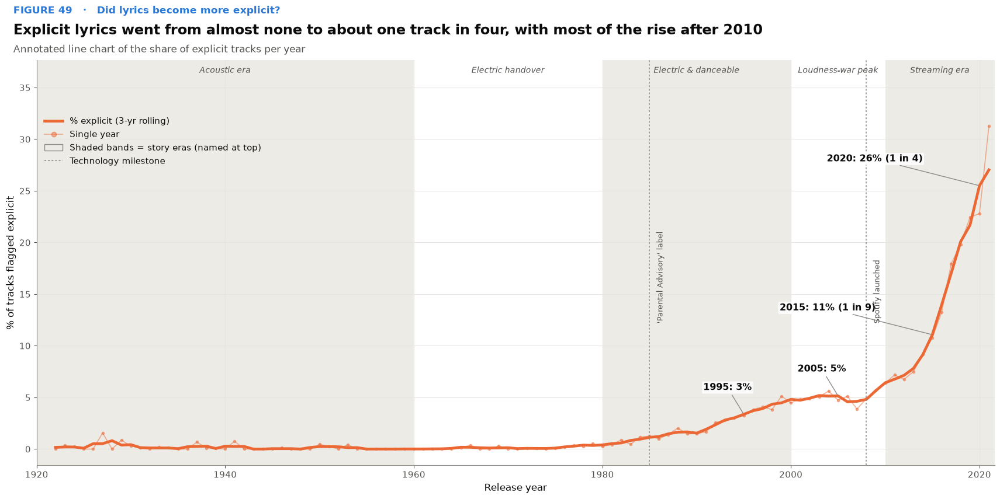

Saved -> figures/fig49_explicit_trend.png


In [90]:
ey = music.groupby('release_year')['explicit'].apply(lambda s: (s == 'Explicit').mean() * 100)
fig, ax = plt.subplots(figsize=(17, 7.5), layout='constrained')
ax.plot(ey.index, ey.values, color=CAT[1], lw=1.2, alpha=0.5, marker='o', markersize=3)
ax.plot(ey.index, ey.rolling(3, center=True, min_periods=1).mean(), color=CAT[1], lw=3.4, label='% explicit (3-yr rolling)')
add_eras(ax)
add_milestones(ax, items=[(1985, "'Parental Advisory' label"), (2008, 'Spotify launched')], y=0.35)
for yr in (1995, 2005, 2015, 2020):
    val = ey.rolling(3, center=True, min_periods=1).mean().loc[yr]
    ax.annotate(f'{yr}: {val:.0f}%' + (f' (1 in {100 / val:.0f})' if val > 8 else ''), (yr, val), xytext=(-70 if yr >= 2015 else -20, 30),
                textcoords='offset points', ha='right' if yr >= 2015 else 'center', fontsize=11.5, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=MUTED), bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
ax.set_xlim(1920, 2021.6)
ax.set_xlabel('Release year')
ax.set_ylabel('% of tracks flagged explicit')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h + [Line2D([], [], color=CAT[1], lw=1.2, alpha=0.5, marker='o', label='Single year'), ERA_HANDLE, MILESTONE_HANDLE],
          loc='upper left', bbox_to_anchor=(0, 0.88))
save_fig(fig, 49, 'explicit_trend', 'Explicit lyrics went from almost none to about one track in four, with most of the rise after 2010',
         'Annotated line chart of the share of explicit tracks per year',
         question='Did lyrics become more explicit?')

**What Figure 49 shows.** Explicit tracks are essentially absent until the 1985 "Parental Advisory" label. The share then rises to about 3 % (1995) and 5 % (2005), takes off after Spotify's launch, and reaches 11 % (2015) and **26 % (2020)**, about one track in four.

**How this moves the story forward.** It shows one of the clearest cultural changes in the data, and it lines up with the rise of hip hop/rap artists (Figure 13) and spoken delivery (Figure 48).

What do listeners reward *now*? Comparing old and new songs mostly measures recency, so Figure 50 uses only **tracks released 2010–2021**. Each panel is a **binned scatter**: tracks are grouped into 20 equal-count bins of a feature, and each dot is the bin's average popularity (size = tracks). A LOWESS curve is fitted to a 15,000-track sample.

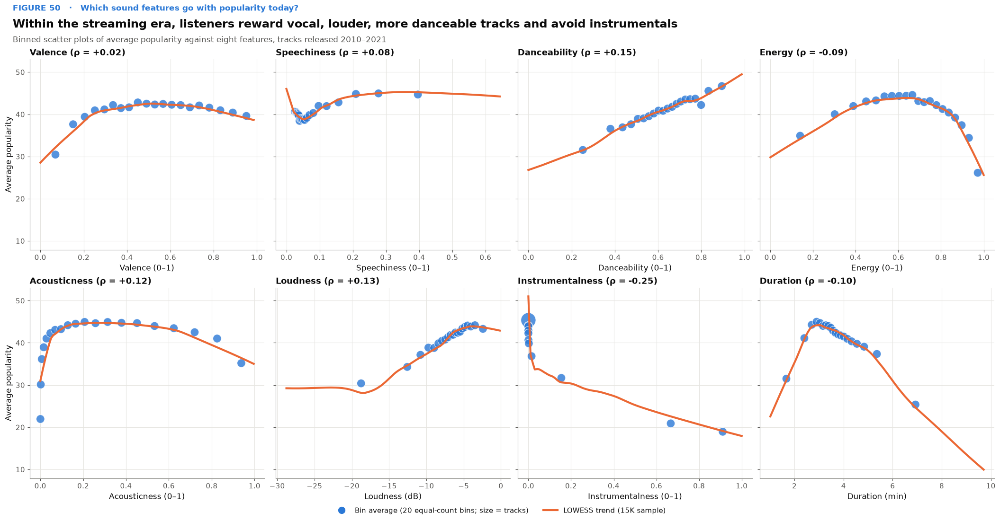

Saved -> figures/fig50_popularity_vs_features.png


| feature          |   Spearman ρ with popularity (2010–2021) |
|:-----------------|-----------------------------------------:|
| instrumentalness |                                   -0.251 |
| duration_min     |                                   -0.105 |
| energy           |                                   -0.094 |
| valence          |                                   +0.023 |
| speechiness      |                                   +0.079 |
| acousticness     |                                   +0.117 |
| loudness         |                                   +0.130 |
| danceability     |                                   +0.147 |

In [91]:
PFEATS = ['valence', 'speechiness', 'danceability', 'energy', 'acousticness', 'loudness', 'instrumentalness', 'duration_min']
fig, axes = plt.subplots(2, 4, figsize=(21, 10), layout='constrained', sharey=True)
smp10 = rec10.sample(15_000, random_state=SEED)
pop_rows = []
for ax, f in zip(axes.flat, PFEATS):
    q = pd.qcut(rec10[f], 20, duplicates='drop')
    b = rec10.groupby(q, observed=True)['popularity'].agg(['mean', 'size'])
    xs_ = rec10.groupby(q, observed=True)[f].mean()
    ax.scatter(xs_, b['mean'], s=np.sqrt(b['size']) * 2.2, color=CAT[0], alpha=0.8, edgecolor='white', lw=0.8, zorder=3)
    sm = smp10[[f, 'popularity']].dropna()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fit = lowess(sm['popularity'], sm[f], frac=0.4, it=0, delta=0.01 * float(sm[f].max() - sm[f].min()))
    ax.plot(fit[:, 0], fit[:, 1], color=CAT[1], lw=3, zorder=4)
    rho = stats.spearmanr(rec10[f], rec10['popularity'], nan_policy='omit').statistic
    pop_rows.append({'feature': f, 'Spearman ρ with popularity (2010–2021)': rho})
    ax.set_title(f"{LABELS[f].split(' (')[0]} (ρ = {rho:+.2f})", fontsize=13)
    ax.set_xlabel(LABELS[f])
for ax in axes[:, 0]:
    ax.set_ylabel('Average popularity')
fig.legend(handles=[Line2D([], [], marker='o', ls='none', color=CAT[0], markersize=10, label='Bin average (20 equal-count bins; size = tracks)'),
                    Line2D([], [], color=CAT[1], lw=3, label='LOWESS trend (15K sample)')], loc='outside lower center', ncol=2)
save_fig(fig, 50, 'popularity_vs_features', 'Within the streaming era, listeners reward vocal, louder, more danceable tracks and avoid instrumentals',
         'Binned scatter plots of average popularity against eight features, tracks released 2010–2021',
         question='Which sound features go with popularity today?')
pop_corr = pd.DataFrame(pop_rows).set_index('feature').sort_values('Spearman ρ with popularity (2010–2021)')
md_table(pop_corr, floatfmt='+.3f')

**What Figure 50 shows.** Among 2010–2021 tracks:
* **Instrumentalness has the strongest link:** popularity falls from about 45 for fully vocal tracks to about 20 for instrumentals (ρ = −0.25).
* **Rewarded:** danceability (ρ = +0.15) and loudness (+0.13) rise steadily with popularity.
* **Penalised at the extremes:** very high energy (above 0.8) and long songs (over about 4 minutes). Popularity peaks around 3 minutes.
* **Hardly matters:** valence (ρ = +0.02).

**How this moves the story forward.** It answers "what kind of sound do people look for today?": **a voice, a danceable beat, a loud mix and a short length**.

### Multivariate: the mood of music, and what makes a hit

Figure 51 is a set of **mood maps**: filled 2D density plots of energy × valence for six eras, with the four mood quadrants labelled and their shares written in each corner.

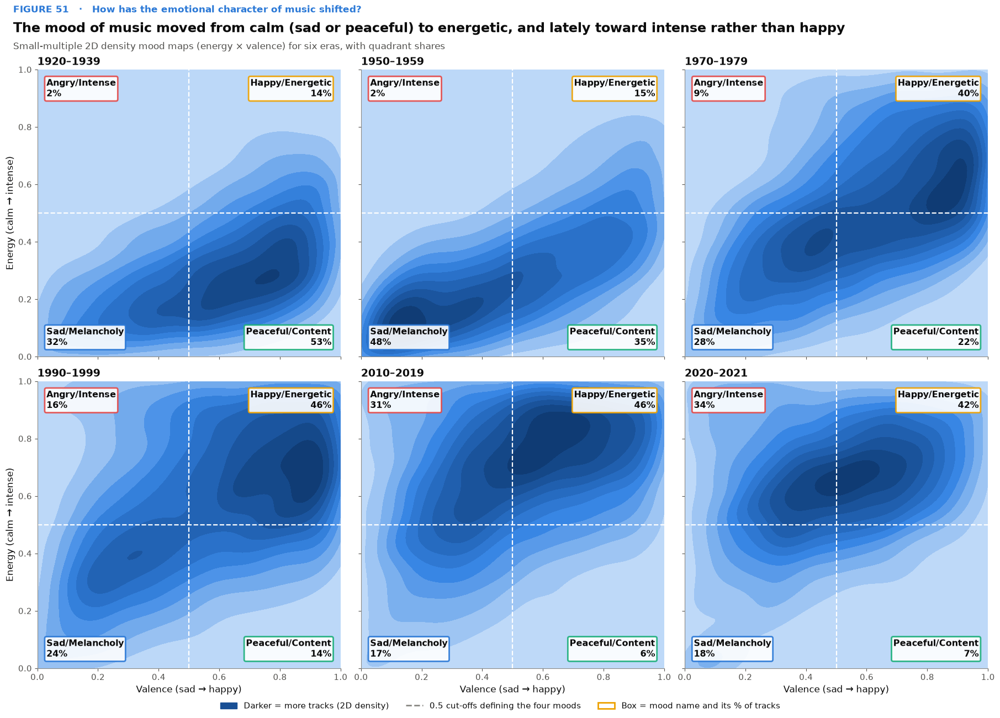

Saved -> figures/fig51_mood_maps.png


In [92]:
MOOD_ERAS = [(1920, 1939), (1950, 1959), (1970, 1979), (1990, 1999), (2010, 2019), (2020, 2021)]
fig, axes = plt.subplots(2, 3, figsize=(18, 12), layout='constrained', sharex=True, sharey=True)
gx, gy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
for ax, (y0, y1) in zip(axes.flat, MOOD_ERAS):
    sub = music[music['release_year'].between(y0, y1)]
    s = sub[['valence', 'energy']].dropna().sample(min(6000, len(sub)), random_state=SEED)
    z = stats.gaussian_kde(s.T.values)(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contourf(gx, gy, z, levels=10, cmap=SEQ)
    ax.axhline(0.5, color='white', lw=1.6, ls='--'); ax.axvline(0.5, color='white', lw=1.6, ls='--')
    share = sub['mood_quadrant'].value_counts(normalize=True) * 100
    for (x0, yy0, m) in [(0.03, 0.97, 'Angry/Intense'), (0.97, 0.97, 'Happy/Energetic'), (0.03, 0.03, 'Sad/Melancholy'), (0.97, 0.03, 'Peaceful/Content')]:
        ax.text(x0, yy0, f'{m}\n{share.get(m, 0):.0f}%', transform=ax.transAxes, ha='left' if x0 < 0.5 else 'right', va='top' if yy0 > 0.5 else 'bottom',
                fontsize=11.5, fontweight='bold', color=INK, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=MOOD_COL[m], lw=2, alpha=0.9))
    ax.set_title(f'{y0}–{y1}', fontsize=14)
for ax in axes[-1]:
    ax.set_xlabel('Valence (sad → happy)')
for ax in axes[:, 0]:
    ax.set_ylabel('Energy (calm → intense)')
fig.legend(handles=[Patch(color='#184f95', label='Darker = more tracks (2D density)'), Line2D([], [], color=MUTED, ls='--', label='0.5 cut-offs defining the four moods'),
                    Patch(facecolor='white', edgecolor=CAT[3], lw=2, label='Box = mood name and its % of tracks')], loc='outside lower center', ncol=3)
save_fig(fig, 51, 'mood_maps', 'The mood of music moved from calm (sad or peaceful) to energetic, and lately toward intense rather than happy',
         'Small-multiple 2D density mood maps (energy × valence) for six eras, with quadrant shares',
         question='How has the emotional character of music shifted?')

**What Figure 51 shows.** The densest area of the mood map moves across the eras.
* **1920–1939:** peaceful/content (53 %).
* **1950s:** sad/melancholy (48 %).
* **1970s–1990s:** happy/energetic (40–46 %).
* **2010s–2021:** still mostly happy/energetic (42–46 %), but **angry/intense grew to 31–34 %**, while peaceful/content shrank to 6–7 %.

**How this moves the story forward.** It shows the emotional character of music moving from calm to energetic, and lately toward intensity rather than joy.

Figure 52 is an **alluvial chart**: each column is one decade's mix of the four moods, and ribbons connect the same mood across decades so its growth or decline can be followed.

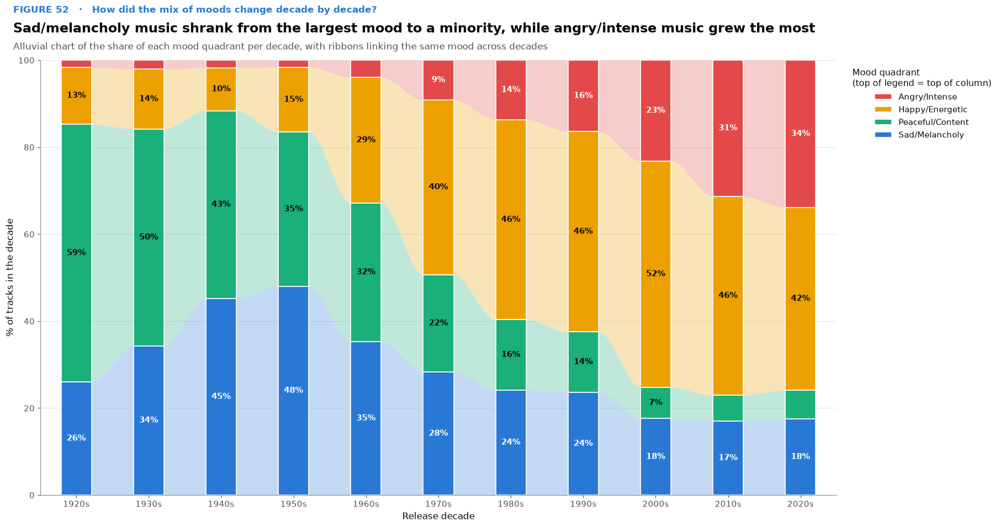

Saved -> figures/fig52_mood_alluvial.png


| mood_quadrant    |   1920s |   1930s |   1940s |   1950s |   1960s |   1970s |   1980s |   1990s |   2000s |   2010s |   2020s |
|:-----------------|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| Sad/Melancholy   |    26.0 |    34.3 |    45.2 |    48.0 |    35.3 |    28.3 |    24.2 |    23.6 |    17.6 |    17.0 |    17.5 |
| Peaceful/Content |    59.3 |    49.9 |    43.2 |    35.4 |    31.9 |    22.4 |    16.1 |    13.9 |     7.2 |     5.9 |     6.6 |
| Happy/Energetic  |    13.0 |    13.7 |     9.9 |    14.9 |    28.8 |    40.2 |    46.0 |    46.0 |    52.0 |    45.8 |    42.0 |
| Angry/Intense    |     1.6 |     2.1 |     1.7 |     1.6 |     4.0 |     9.1 |    13.7 |    16.4 |    23.2 |    31.3 |    33.9 |

In [93]:
mq = pd.crosstab(music['decade_label'], music['mood_quadrant'], normalize='index')[MOODS] * 100
fig, ax = plt.subplots(figsize=(18, 8.5), layout='constrained')
bw = 0.42
xs_ = np.arange(len(mq))
lowers = mq.cumsum(axis=1) - mq
for m in MOODS:
    for i in range(len(mq) - 1):
        t_ = np.linspace(0, 1, 50); sstep = t_ * t_ * (3 - 2 * t_)
        xx = xs_[i] + bw / 2 + t_ * (1 - bw)
        lo_ = lowers[m].iloc[i] + (lowers[m].iloc[i + 1] - lowers[m].iloc[i]) * sstep
        hi_ = lo_ + mq[m].iloc[i] + (mq[m].iloc[i + 1] - mq[m].iloc[i]) * sstep
        ax.fill_between(xx, lo_, hi_, color=MOOD_COL[m], alpha=0.28, lw=0)
    ax.bar(xs_, mq[m], bottom=lowers[m], width=bw, color=MOOD_COL[m], edgecolor='white', lw=1.2, label=m)
    for i in range(len(mq)):
        if mq[m].iloc[i] >= 7:
            ax.text(xs_[i], lowers[m].iloc[i] + mq[m].iloc[i] / 2, f'{mq[m].iloc[i]:.0f}%', ha='center', va='center', fontsize=10.5,
                    fontweight='bold', color='white' if m in ('Sad/Melancholy', 'Angry/Intense') else INK)
ax.set_xticks(xs_, mq.index.astype(str))
ax.set_ylim(0, 100)
ax.set_xlim(-0.5, len(mq) - 0.5)
ax.set_ylabel('% of tracks in the decade')
ax.set_xlabel('Release decade')
ax.grid(axis='x', visible=False)
h, l = ax.get_legend_handles_labels()
ax.legend(handles=h[::-1], loc='upper left', bbox_to_anchor=(1.01, 1), title='Mood quadrant\n(top of legend = top of column)')
save_fig(fig, 52, 'mood_alluvial', 'Sad/melancholy music shrank from the largest mood to a minority, while angry/intense music grew the most',
         'Alluvial chart of the share of each mood quadrant per decade, with ribbons linking the same mood across decades',
         question='How did the mix of moods change decade by decade?')
md_table(mq.T, floatfmt='.1f')

**What Figure 52 shows.** Following the ribbons:
* **Sad/melancholy:** rose to 48 % in the 1950s, then shrank to 17–18 % from the 2000s.
* **Peaceful/content:** fell from 59 % (1920s) to 7 % (2020s).
* **Happy/energetic:** rose from 13 % to a peak of 52 % (2000s), then eased to 42 %.
* **Angry/intense:** grew from under 2 % before the 1960s to **34 % in the 2020s**, the biggest change of any mood.

**How this moves the story forward.** It tracks the mood mix decade by decade, and it identifies "angry/intense" as the defining mood of the streaming era.

What separates a hit from everything else? Figure 53 is a pair of **radar charts** comparing the audio profile of **hits** (the top 10 % by popularity *within* the decade) with all other tracks, for an early decade (1960s) and the most recent full decade (2010s). Loudness and tempo are rescaled to 0–1 so all spokes share one scale.

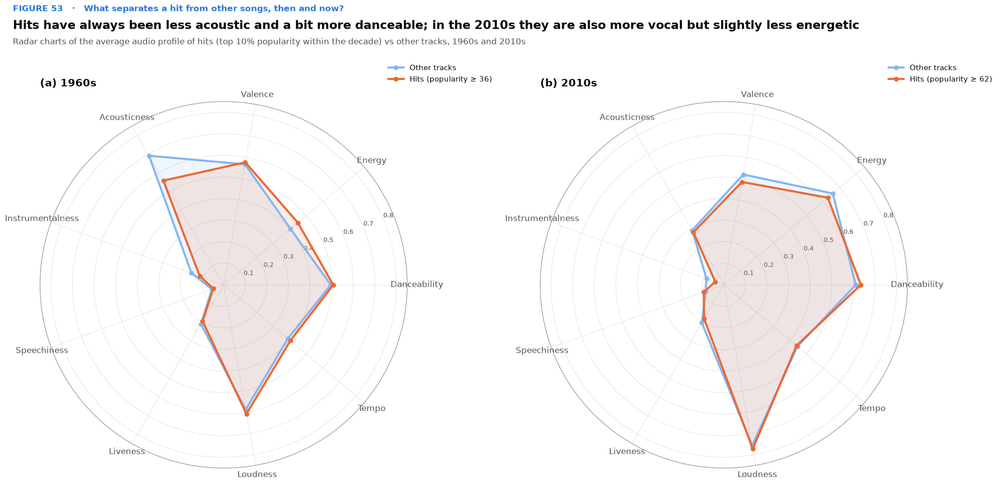

Saved -> figures/fig53_hits_radar.png


|                  |   1960s hits |   2010s hits |   1960s others |   2010s others |
|:-----------------|-------------:|-------------:|---------------:|---------------:|
| danceability     |        0.507 |        0.635 |          0.496 |          0.611 |
| energy           |        0.449 |        0.629 |          0.404 |          0.659 |
| valence          |        0.577 |        0.484 |          0.568 |          0.520 |
| acousticness     |        0.558 |        0.281 |          0.691 |          0.292 |
| instrumentalness |        0.118 |        0.042 |          0.158 |          0.086 |
| speechiness      |        0.051 |        0.099 |          0.058 |          0.090 |
| liveness         |        0.195 |        0.182 |          0.210 |          0.203 |
| loudness         |        0.608 |        0.773 |          0.588 |          0.757 |
| tempo            |        0.403 |        0.439 |          0.388 |          0.445 |

In [94]:
RAD_F = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']
def scaled_profile(df):
    p = df[RAD_F].astype(float).mean()
    p['loudness'] = (p['loudness'] + 30) / 30
    p['tempo'] = (p['tempo'] - 60) / 140
    return p
fig = plt.figure(figsize=(20, 9.5), layout='constrained')
ang = np.linspace(0, 2 * np.pi, len(RAD_F), endpoint=False)
hit_rows = {}
for k_, d in enumerate(['1960s', '2010s']):
    sub = music[music['decade_label'] == d]
    thr = sub['popularity'].quantile(0.9)
    hit, rest = scaled_profile(sub[sub['popularity'] >= thr]), scaled_profile(sub[sub['popularity'] < thr])
    hit_rows[d] = (hit, rest, thr)
    ax = fig.add_subplot(1, 2, k_ + 1, projection='polar')
    for prof, col, lbl in [(rest, '#86b6ef', f'Other tracks'), (hit, CAT[1], f'Hits (popularity ≥ {thr:.0f})')]:
        vals = np.r_[prof.values, prof.values[0]]
        ax.plot(np.r_[ang, ang[0]], vals, color=col, lw=3, marker='o', label=lbl)
        ax.fill(np.r_[ang, ang[0]], vals, color=col, alpha=0.12)
    ax.set_xticks(ang, [LABELS[f].split(' (')[0] for f in RAD_F], fontsize=12)
    ax.set_ylim(0, 0.85)
    ax.tick_params(axis='y', labelsize=9, colors=INK2)
    ax.set_title(f'({"ab"[k_]}) {d}', fontsize=15, pad=22)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.12))
save_fig(fig, 53, 'hits_radar', 'Hits have always been less acoustic and a bit more danceable; in the 2010s they are also more vocal but slightly less energetic',
         'Radar charts of the average audio profile of hits (top 10% popularity within the decade) vs other tracks, 1960s and 2010s',
         question='What separates a hit from other songs, then and now?')
md_table(pd.DataFrame({f'{d} hits': v[0] for d, v in hit_rows.items()} | {f'{d} others': v[1] for d, v in hit_rows.items()}), floatfmt='.3f')

**What Figure 53 shows.** (a) In the 1960s, hits (popularity ≥ 36) were clearly **less acoustic** (0.56 vs 0.69) and a little more energetic than other tracks. (b) In the 2010s, hits (popularity ≥ 62) are slightly **more danceable** (0.64 vs 0.61), **more vocal** (instrumentalness 0.04 vs 0.09) and slightly speechier, but a little *less* energetic and less happy (valence 0.48 vs 0.52) than other tracks.

**How this moves the story forward.** It shows what separated a hit then and now. Hits were always ahead of the curve on electric sound, and today's hits favour voice and groove over maximum intensity.

Figure 54 shows **word clouds** of track titles: hits (top 10 % popularity within the era) versus everything else, for two eras. Word size is proportional to how many titles contain the word (stop words removed).

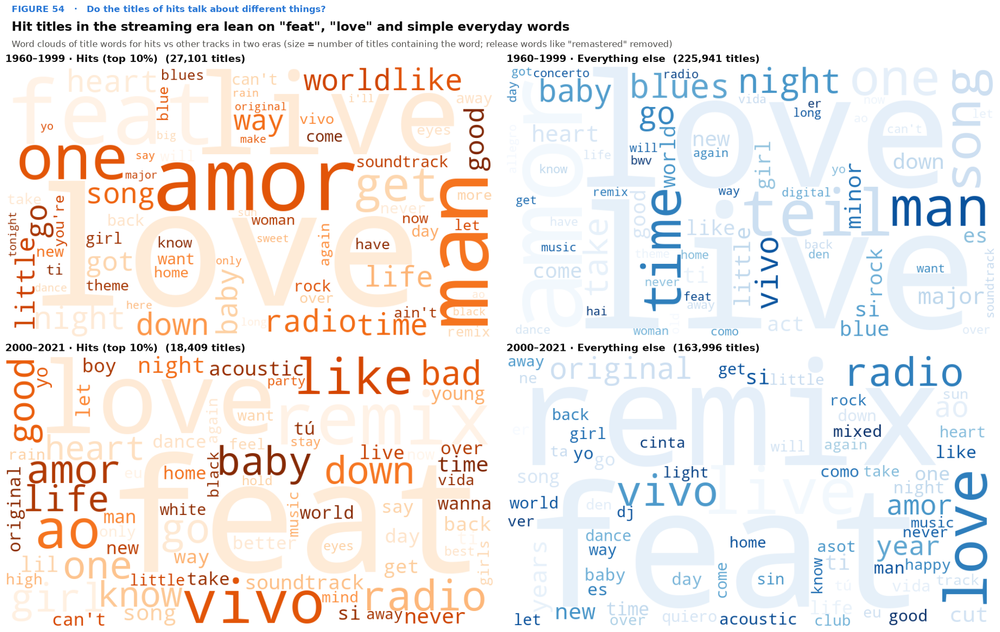

Saved -> figures/fig54_title_wordclouds.png


In [95]:
fig, axes = plt.subplots(2, 2, figsize=(19, 11), layout='constrained')
for i, (era, (y0, y1)) in enumerate([('1960–1999', (1960, 1999)), ('2000–2021', (2000, 2021))]):
    sub = music[music['release_year'].between(y0, y1)]
    thr = sub['popularity'].quantile(0.9)
    for j, (grp, mask_, cmap_) in enumerate([('Hits (top 10%)', sub['popularity'] >= thr, 'Oranges'), ('Everything else', sub['popularity'] < thr, 'Blues')]):
        cnts = Counter(w for toks in sub.loc[mask_, 'title_tokens'] for w in set(toks))
        for junk in ('remastered', 'remaster', 'version', 'mono', 'stereo', 'edit', 'mix', 'single', 'remasterizado'):
            cnts.pop(junk, None)
        wc = WordCloud(width=900, height=500, background_color='white', colormap=cmap_, max_words=70, random_state=SEED,
                       prefer_horizontal=0.95).generate_from_frequencies(cnts)
        axes[i, j].imshow(wc, interpolation='bilinear')
        axes[i, j].axis('off')
        axes[i, j].set_title(f'{era} · {grp}  ({mask_.sum():,} titles)', fontsize=14)
save_fig(fig, 54, 'title_wordclouds', 'Hit titles in the streaming era lean on "feat", "love" and simple everyday words',
         'Word clouds of title words for hits vs other tracks in two eras (size = number of titles containing the word; release words like "remastered" removed)',
         question='Do the titles of hits talk about different things?')

**What Figure 54 shows.** In 1960–1999, hit titles are dominated by "love", "amor", "man", "one" and "live", while other titles feature "love", "live", "blues" and "baby". In 2000–2021, hit titles lean on **"feat"**, "love", "remix", "vivo", "baby", "like", "life" and "bad". Spanish words ("amor", "vivo", "tú") are prominent among hits, matching the rise of Latin artists.

**How this moves the story forward.** It shows that the words in hit titles changed with the collaboration and Latin waves seen in Chapter 1, while "love" remains the constant theme.

### What predicts popularity? A random-forest model

A **random forest regressor** predicts popularity from the audio features, duration, release year, the explicit flag and the mood quadrant. It is trained on a **random sample of 80,000 tracks** (80/20 train/test split), which is enough for stable estimates. A second model without release year shows how much the *sound alone* explains. Feature importance is measured two ways: the forest's built-in **impurity** importance, and **permutation** importance on held-out tracks (how much R² drops when one feature is shuffled), which is the more trustworthy measure.

In [96]:
M_FEATS = AUDIO + ['duration_min', 'release_year', 'explicit_flag'] + [f'mood_{m}' for m in MOODS[1:]]
mf = music.assign(explicit_flag=(music['explicit'] == 'Explicit').astype(int))
for m in MOODS[1:]:
    mf[f'mood_{m}'] = (mf['mood_quadrant'] == m).astype(int)
mf = mf[M_FEATS + ['popularity']].dropna().sample(80_000, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(mf[M_FEATS], mf['popularity'].astype(float), test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=150, max_depth=18, min_samples_leaf=20, max_features=0.5, n_jobs=-1, random_state=SEED).fit(X_tr, y_tr)
r2_full = r2_score(y_te, rf.predict(X_te))
mae_full = mean_absolute_error(y_te, rf.predict(X_te))
NO_YEAR = [f for f in M_FEATS if f != 'release_year']
rf_ny = RandomForestRegressor(n_estimators=150, max_depth=18, min_samples_leaf=20, max_features=0.5, n_jobs=-1, random_state=SEED).fit(X_tr[NO_YEAR], y_tr)
r2_audio = r2_score(y_te, rf_ny.predict(X_te[NO_YEAR]))
pidx = rng.choice(len(X_te), 6000, replace=False)
perm = permutation_importance(rf, X_te.iloc[pidx], y_te.iloc[pidx], n_repeats=3, random_state=SEED, n_jobs=-1)
FEAT_NAMES = {**{f: LABELS.get(f, f).split(' (')[0] for f in M_FEATS}, 'explicit_flag': 'Explicit lyrics',
              **{f'mood_{m}': f'Mood: {m}' for m in MOODS}}
imp = pd.DataFrame({'impurity': rf.feature_importances_, 'permutation': perm.importances_mean.clip(min=0)}, index=M_FEATS)
imp = imp / imp.sum()
imp = imp.sort_values('permutation')
print(f'Test R²: full model {r2_full:.3f} (MAE {mae_full:.1f} points); without release year {r2_audio:.3f}')
md_table(imp[::-1].rename(index=FEAT_NAMES), floatfmt='.3f')

Test R²: full model 0.472 (MAE 10.1 points); without release year 0.335


|                        |   impurity |   permutation |
|:-----------------------|-----------:|--------------:|
| Release year           |      0.539 |         0.746 |
| Instrumentalness       |      0.062 |         0.067 |
| Loudness               |      0.067 |         0.050 |
| Acousticness           |      0.123 |         0.049 |
| Duration               |      0.039 |         0.024 |
| Energy                 |      0.044 |         0.020 |
| Danceability           |      0.023 |         0.013 |
| Explicit lyrics        |      0.021 |         0.009 |
| Speechiness            |      0.021 |         0.007 |
| Valence                |      0.021 |         0.006 |
| Tempo                  |      0.021 |         0.005 |
| Liveness               |      0.017 |         0.004 |
| Mood: Angry/Intense    |      0.001 |         0.000 |
| Mood: Happy/Energetic  |      0.001 |         0.000 |
| Mood: Peaceful/Content |      0.001 |         0.000 |

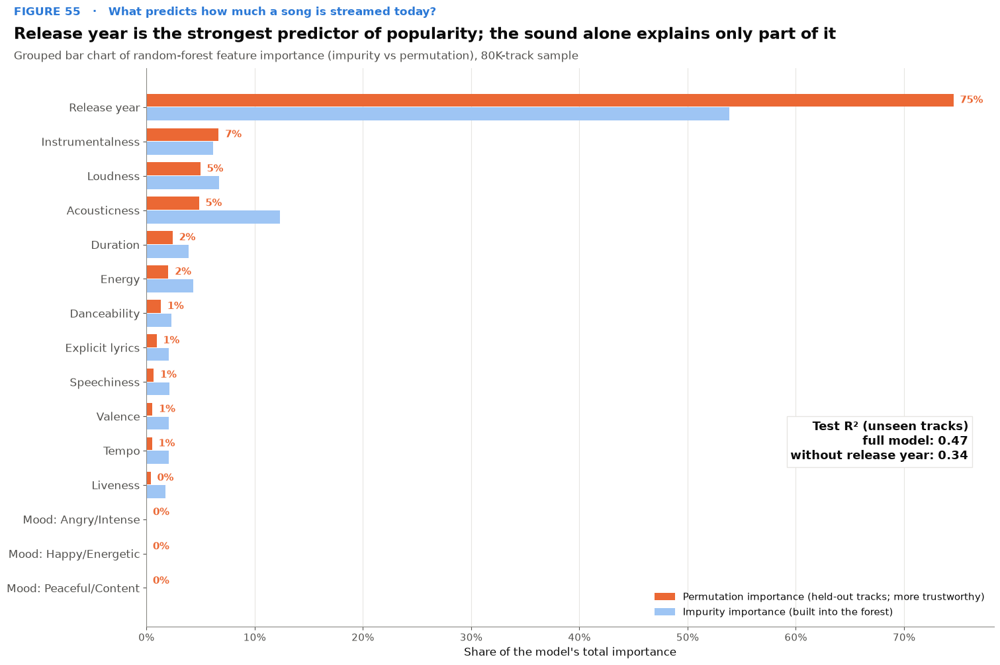

Saved -> figures/fig55_popularity_importance.png


In [97]:
fig, ax = plt.subplots(figsize=(15, 9), layout='constrained')
yy = np.arange(len(imp))
ax.barh(yy + 0.2, imp['permutation'], height=0.38, color=CAT[1], label='Permutation importance (held-out tracks; more trustworthy)')
ax.barh(yy - 0.2, imp['impurity'], height=0.38, color='#9ec5f4', label='Impurity importance (built into the forest)')
for y_, v in zip(yy, imp['permutation']):
    ax.text(v + 0.006, y_ + 0.2, f'{v:.0%}', va='center', fontsize=11, color=CAT[1], fontweight='bold')
ax.set_yticks(yy, [FEAT_NAMES[f] for f in imp.index], fontsize=12)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel('Share of the model\'s total importance')
ax.grid(axis='y', visible=False)
ax.text(0.97, 0.3, f'Test R² (unseen tracks)\nfull model: {r2_full:.2f}\nwithout release year: {r2_audio:.2f}', transform=ax.transAxes, ha='right',
        fontsize=13, fontweight='bold', bbox=dict(fc='white', ec=GRID))
ax.legend(loc='lower right')
save_fig(fig, 55, 'popularity_importance', 'Release year is the strongest predictor of popularity; the sound alone explains only part of it',
         'Grouped bar chart of random-forest feature importance (impurity vs permutation), 80K-track sample',
         question='What predicts how much a song is streamed today?')

**What Figure 55 shows.** The random forest explains **47 % of the variation in popularity** on unseen tracks (typical error about 10 points). Without release year it explains **34 %**. By permutation importance, **release year accounts for about 75 %** of the model's power, followed by instrumentalness (7 %), loudness (5 %) and acousticness (5 %). Mood quadrant adds almost nothing once the audio features are included.

**How this moves the story forward.** It answers honestly what predicts popularity. Mostly it is *when* a song was released, and the sound explains only a limited part. About half of popularity depends on things this data does not contain (fame, marketing, playlists, virality).

Figure 56 is a **SHAP summary (beeswarm) plot**. Exact SHAP values for the full 150-tree forest take far too long to compute, so they are calculated for a **lighter copy of the same model** (60 trees, depth 10, same features and training data; its test R² is printed below for comparison) on 1,000 held-out tracks. Each dot is one track. Its horizontal position shows how much that feature pushed the track's predicted popularity up (right) or down (left), and its colour shows whether the feature's value was high (red) or low (blue).

Lighter SHAP forest: test R² 0.463 (full forest 0.472)


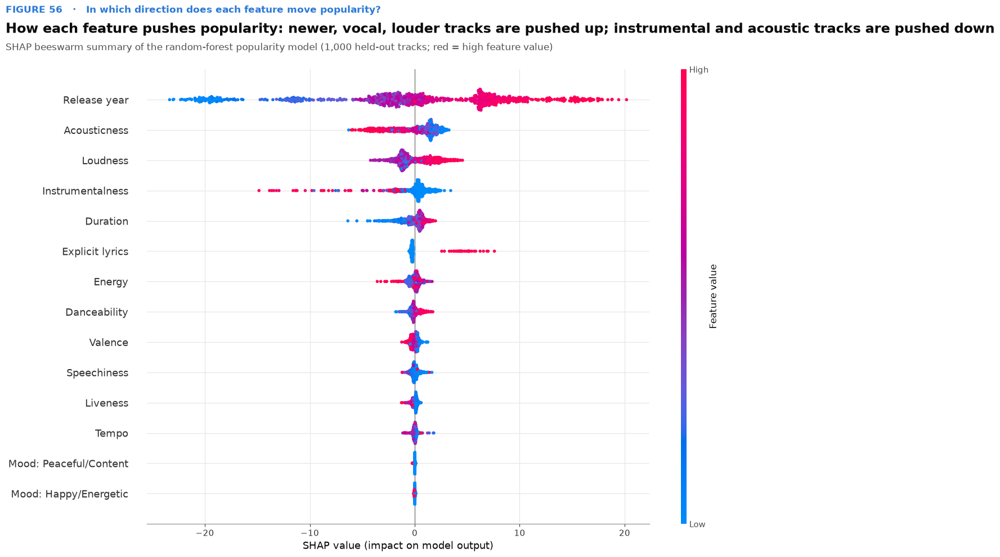

Saved -> figures/fig56_popularity_shap.png


|                                 |   Release year |   Acousticness |   Loudness |   Instrumentalness |   Duration |   Explicit lyrics |   Energy |   Danceability |
|:--------------------------------|---------------:|---------------:|-----------:|-------------------:|-----------:|------------------:|---------:|---------------:|
| mean |SHAP| (popularity points) |           7.25 |           1.84 |       1.40 |               1.05 |       0.75 |              0.44 |     0.36 |           0.33 |

In [98]:
X_shap = X_te.sample(1000, random_state=SEED)
rf_shap = RandomForestRegressor(n_estimators=60, max_depth=10, min_samples_leaf=20, max_features=0.5, n_jobs=-1, random_state=SEED).fit(X_tr, y_tr)
print(f'Lighter SHAP forest: test R² {r2_score(y_te, rf_shap.predict(X_te)):.3f} (full forest {r2_full:.3f})')
explainer = shap.TreeExplainer(rf_shap)
sv = explainer.shap_values(X_shap, check_additivity=False)
shap.summary_plot(sv, X_shap.rename(columns=FEAT_NAMES), show=False, max_display=14, plot_size=(14, 9))
fig = plt.gcf()
save_fig(fig, 56, 'popularity_shap', 'How each feature pushes popularity: newer, vocal, louder tracks are pushed up; instrumental and acoustic tracks are pushed down',
         'SHAP beeswarm summary of the random-forest popularity model (1,000 held-out tracks; red = high feature value)',
         question='In which direction does each feature move popularity?')
shap_mean = pd.Series(np.abs(sv).mean(axis=0), index=[FEAT_NAMES[f] for f in X_shap.columns]).sort_values(ascending=False)
md_table(shap_mean.head(8).to_frame('mean |SHAP| (popularity points)').T, floatfmt='.2f')

**What Figure 56 shows.** The SHAP summary shows direction as well as size.
* **Release year:** recent years (red) push predictions up by as much as 20 points, and old years (blue) push them down by up to 20.
* **Instrumentalness and acousticness:** high values push popularity down.
* **Loudness, danceability and explicit lyrics:** high values push it up.
* **Very high energy and high valence:** push it slightly down.

**How this moves the story forward.** It explains *why* the model predicts what it does, and it confirms the binned-scatter findings: recent, vocal, louder, danceable and explicit tracks are predicted to be more popular.

Finally, Figure 57 is a **heatmap** of the average audio profile of each genre family (genre-tagged tracks only), standardised so that red means more than the average track and blue means less. It links the meaning and mood of music back to its genres.

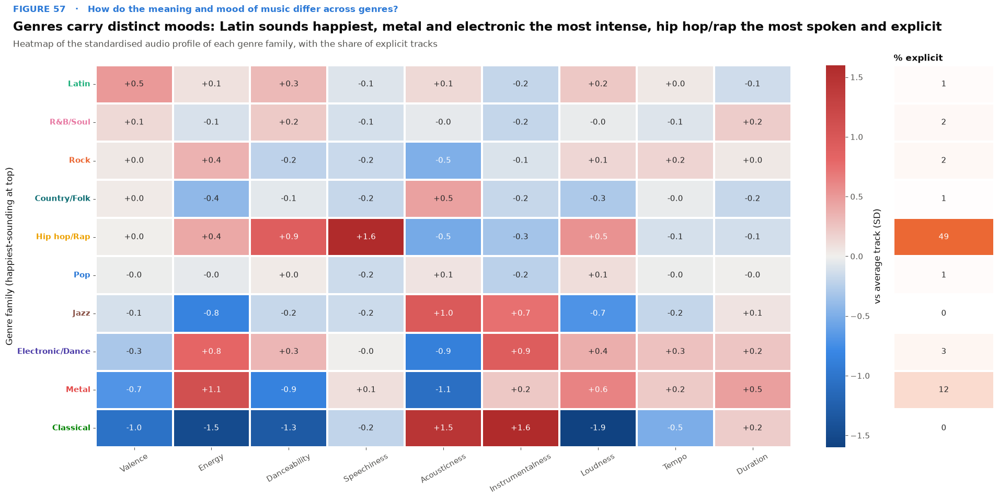

Saved -> figures/fig57_genre_audio_profile.png


In [99]:
GP = ['valence', 'energy', 'danceability', 'speechiness', 'acousticness', 'instrumentalness', 'loudness', 'tempo', 'duration_min']
gsub = music[music['primary_genre_family'].isin(FAM_ORDER[:-1])]
gz = (gsub.groupby('primary_genre_family')[GP].mean() - gsub[GP].astype(float).mean()) / gsub[GP].astype(float).std()
gz = gz.loc[gz['valence'].sort_values(ascending=False).index]
gz['explicit %'] = gsub.groupby('primary_genre_family')['explicit'].apply(lambda s: (s == 'Explicit').mean() * 100)
fig, axes = plt.subplots(1, 2, figsize=(19, 8.5), layout='constrained', gridspec_kw={'width_ratios': [9, 1.3]})
sns.heatmap(gz[GP].rename(columns=lambda c: LABELS[c].split(' (')[0]), cmap=DIV, center=0, vmin=-1.6, vmax=1.6, annot=True, fmt='+.1f',
            annot_kws={'fontsize': 11}, linewidths=1.5, linecolor='white', cbar_kws={'label': 'vs average track (SD)'}, ax=axes[0])
axes[0].set_ylabel('Genre family (happiest-sounding at top)')
axes[0].tick_params(axis='x', rotation=30)
for lbl in axes[0].get_yticklabels():
    lbl.set_color(GENRE_COL.get(lbl.get_text(), INK)); lbl.set_fontweight('bold')
sns.heatmap(gz[['explicit %']], cmap=LinearSegmentedColormap.from_list('o', ['#ffffff', CAT[1]]), annot=True, fmt='.0f', annot_kws={'fontsize': 11},
            linewidths=1.5, linecolor='white', cbar=False, ax=axes[1], yticklabels=False)
axes[1].set_title('% explicit', fontsize=12)
axes[1].set_xticks([])
axes[1].set_ylabel('')
save_fig(fig, 57, 'genre_audio_profile', 'Genres carry distinct moods: Latin sounds happiest, metal and electronic the most intense, hip hop/rap the most spoken and explicit',
         'Heatmap of the standardised audio profile of each genre family, with the share of explicit tracks',
         question='How do the meaning and mood of music differ across genres?')

**What Figure 57 shows.** Each genre has a distinct emotional and sonic profile.
* **Latin:** the happiest-sounding genre (valence +0.5 SD) and danceable.
* **Hip hop/rap:** the most speech-heavy (+1.6) and danceable (+0.9) genre, and by far the most explicit (**49 % of tracks**).
* **Metal:** the most intense (energy +1.1) and the least happy (−0.7).
* **Electronic/dance:** energetic and often instrumental.
* **Classical and jazz:** the calm, acoustic, instrumental end.

**How this moves the story forward.** It links meaning back to the artists. The genres that grew (hip hop, Latin, electronic) bring more speech, explicitness and intensity, which explains much of the shift in mood and lyrics.

> ### Chapter 4 Takeaways: The Meaning, and what people look for
> * **Music became moodier and more intense.** Valence fell from about 0.58 (1980s) to 0.49 (2020s) (Figure 47). Angry/intense grew from under 2 % of tracks before the 1960s to 34 % in the 2020s, while peaceful/content fell from 59 % to 7 % (Figure 52).
> * **Lyrics and delivery changed.** Explicit tracks rose to about 26 % by 2020 (Figure 49), spoken and rap-like delivery doubled from 19 % to 37 % between 2010 and 2020 (Figure 48), and "feat." in titles rose from 0.24 % to 5.5 % (Figure 45).
> * **What people look for: recent, vocal, loud, danceable music.** Release year carries about 75 % of the popularity model's power (R² 0.47 vs 0.34 without year; Figure 55). Within 2010–2021, instrumental tracks are the least streamed (ρ = −0.25), while danceability and loudness are rewarded (Figure 50).

<a id="section-4"></a>
# Section 4: Key Findings and Decision Table

### The whole story, in order

**The early decades (1920s–1950s).** The catalogue's early music comes from a small number of very prolific names: tango orchestras, classical composers, crooners and jazz bands. The concentration is high: the Gini coefficient of tracks per artist is 0.72–0.77 (Figure 10). Almost every recording is acoustic and quiet (median acousticness 0.91–0.99, loudness around −12 to −13 dB), often instrumental, and about 3 minutes long, the length of a 78-rpm side (Figures 19, 20, 23). Rhythm is more varied than today: up to 22 % of 1940s tracks are in waltz time (Figure 36), and the median tempo sits at 103–114 BPM (Figure 34). In mood, music is calm. "Peaceful/content" and "sad/melancholy" tracks together are more than 80 % of every decade up to the 1950s (Figure 52), and only 25–29 % of tracks are in a minor key (Figure 38).

**The 1960s–1970s: the electric handover.** Electric instruments and multitrack studios arrive. Acousticness falls sharply (its median drops from 0.91 to 0.51 between the 1950s and the 1970s), and the average track's energy finally overtakes its acousticness in about 1975 (Figure 22). Energy, danceability and tempo all start climbing (Figures 33, 39). Rock dominates the new artists who debut in the 1970s (Figure 17). The "happy/energetic" mood grows from 15 % to 40 % of tracks (Figure 52).

**The 1980s–1990s: electric, longer, brighter.** Songs reach their longest (median close to 4 minutes, Figure 23). The happy/energetic mood peaks at about 46 % of tracks, and the catalogue's artists multiply (Figure 8). Explicit lyrics appear after the 1985 "Parental Advisory" label (Figure 49). Collaboration reaches its low point: around 1990 only about 1 track in 12 credits more than one artist (Figure 9).

**The 2000s: the loudness war.** Median loudness jumps by almost 3 dB within one decade as digital mastering compresses music ever harder, peaking around 2012 (Figure 20). The loud & energetic sound cluster becomes the majority of tracks (Figure 30). Minor keys pass a third of all songs (Figure 38).

**The 2010s–2020s: the streaming era.** The artist population explodes and becomes far less concentrated (Gini down to about 0.57, Figures 8, 10). Hip hop/rap rises from almost no new artists in the 1970s to about a fifth of them (Figure 13). Collaboration surges to more than a third of tracks, held together by Latin and hip-hop hubs (Figures 9, 14). The sound is the most danceable it has ever been (median 0.68), slightly faster (about 122 BPM) and almost entirely in 4/4 (Figures 33, 36). Its meaning darkens: valence falls to its lowest level since the 1950s (0.49), minor keys reach 45 %, "angry/intense" becomes a third of all tracks, explicit lyrics reach about one track in four, and rap-like and spoken delivery doubles (Figures 47–52). Songs also get shorter again (Figure 23). Within this era, listeners stream louder, more danceable and above all **vocal** tracks the most. Release year is still the strongest predictor of popularity, so listeners mostly reward *recent* music (Figures 50, 55, 56).

### Decision table

Every row below is assembled from statistics computed earlier in the notebook, so the numbers cannot drift from the analysis. The table is also saved as `outputs/decision_table.csv`.

In [100]:
rho = lambda t_, f: t_.loc[f, 'Spearman ρ with year']
eta = lambda t_, f: t_.loc[f, 'η²_H']
dmed2 = music.groupby('decade_label', observed=True)[['acousticness', 'energy', 'danceability', 'loudness', 'tempo', 'valence', 'duration_min']].median()
yr_dur = music.groupby('release_year')['duration_min'].mean()
lo_c = cy['p'].loc[1960:2005].idxmin()
hub_names = ', '.join(hub_tbl['artist'].head(4))
mood_hit = {m: float(np.median(d)) for m, d in zip(MOODS, data_m)}
DT = [
 ('1 Artists', 'The number of artists exploded',
  f"New artists per year (3-yr rolling): ~{tot.loc[1925]:,.0f} (1925) → ~{tot.loc[2018]:,.0f} (2018); {len(arts):,} music artists in total. Fig 8",
  f"About {tot.loc[2018] / max(tot.loc[1925], 1):.0f}× more debuts per year",
  'High for the trend; Medium for exact counts', 'debut_year = first year in this dataset, so back catalogues uploaded late inflate recent debuts',
  'Making music became open to far more people (cheaper recording, digital distribution)', 'Treat the artist count as catalogue supply, not historical reality; validate with label data'),
 ('1 Artists', 'Output became less concentrated in a few names',
  f"Gini of tracks per artist: {gini_dec['1920s']:.2f} (1920s) → {gini_dec['2010s']:.2f} (2010s). Fig 10",
  f"Gini fell by {gini_dec['1920s'] - gini_dec['2010s']:.2f}", 'Medium: consistent decline, but the early decades are dominated by a few catalogue uploads',
  'Early decades are inflated by a few very large back catalogues (tango, classical)', 'Today\'s catalogue is spread across many more artists, though fame is still very unequal',
  'Report concentration together with the follower inequality (Fig 5)'),
 ('1 Artists', 'Collaboration came back strongly',
  f"Multi-artist tracks: {cy.loc[lo_c, 'p']:.0%} ({lo_c}) → {cy.loc[2020, 'p']:.0%} (2020); artists per track 2020 {cy.loc[2020, 'm']:.2f}. Fig 9, Fig 14",
  'Share roughly quadrupled since the low point', 'High: thousands of tracks per year, narrow confidence bands',
  'Pre-1960 values include classical composer + performer credits', f'Featuring other artists is a defining habit of the streaming era; hubs: {hub_names}',
  'Include collaboration as a feature in any popularity model'),
 ('1 Artists', 'New artists moved from rock to hip hop/rap and electronic',
  f"Share of new genre-tagged artists, 1970s → 2010s: rock {slope.loc['Rock', '1970s']:.0f}% → {slope.loc['Rock', '2010s']:.0f}%, hip hop/rap {slope.loc['Hip hop/Rap', '1970s']:.0f}% → {slope.loc['Hip hop/Rap', '2010s']:.0f}%. Fig 13, Fig 17",
  '+20 percentage points for hip hop/rap', 'Medium: rests on the genre-tagged subset (69% of artists)', '31% of artists have no genre tags; tags are artist-level',
  'Who makes music changed, which changed how it sounds', 'Use genre mix to explain sound trends (composition effect)'),
 ('2 Sound', 'Music got much louder (the loudness war)',
  f"Median loudness {dmed2.loc['1950s', 'loudness']:.1f} dB (1950s) → {dmed2.loc['2010s', 'loudness']:.1f} dB (2010s); loudest year {lq['med'].idxmax()}. Fig 20",
  f"ρ = {rho(tests_sound, 'loudness'):+.2f}; η²_H = {eta(tests_sound, 'loudness'):.2f} (large)", 'High: large effect in every view',
  'Spotify measures today\'s (often remastered) files', 'The clearest change in how recorded music sounds', 'Headline finding; compare eras only after loudness normalisation'),
 ('2 Sound', 'Acoustic sound gave way to electric, produced sound',
  f"Median acousticness {dmed2.loc['1940s', 'acousticness']:.2f} (1940s) → {dmed2.loc['2010s', 'acousticness']:.2f} (2010s); crossover ≈ {cross}. Fig 19, Fig 22",
  f"ρ = {rho(tests_sound, 'acousticness'):+.2f}; η²_H = {eta(tests_sound, 'acousticness'):.2f} (large)", 'High: the whole distribution flips (ridgelines)',
  'Acousticness is a model estimate and may be biased for old recordings', 'The 1960s–70s were the turning point in how music is made', 'Use acousticness (or PCA axis 1) as the main "era of sound" indicator'),
 ('2 Sound', 'Energy rose with loudness',
  f"Median energy {dmed2.loc['1950s', 'energy']:.2f} (1950s) → {dmed2.loc['2010s', 'energy']:.2f} (2010s); PCA axis 1 explains {evr[0]:.0%}. Fig 26, Fig 27",
  f"ρ = {rho(tests_sound, 'energy'):+.2f}; η²_H = {eta(tests_sound, 'energy'):.2f} (large)", 'High', 'Energy is partly computed from loudness',
  'Louder and more intense are one linked production change', 'Treat energy + loudness as one "intensity" trend'),
 ('2 Sound', 'Songs grew longer, then shorter again',
  f"Mean duration peaked at {yr_dur.max():.2f} min ({yr_dur.idxmax()}) → {yr_dur.loc[2020]:.2f} (2020) → {yr_dur.loc[2021]:.2f} (2021). Fig 23",
  f"η²_H = {eta(tests_sound, 'duration_min'):.3f} (medium)", 'Medium-High: steady decline across 2010–2020', '2021 partial; duration window applied',
  'Streaming reversed a 40-year lengthening of songs', 'Re-test with full post-2021 data'),
 ('2 Sound', 'The mix of sound types turned over',
  f"Loud & energetic cluster {cl_dec.loc['1920s', 'Loud & energetic']:.0f}% (1920s) → {cl_dec.loc['2010s', 'Loud & energetic']:.0f}% (2010s); k = {K}. Fig 28–30",
  f"Silhouette {k_tbl.set_index('k').loc[K, 'silhouette']:.2f} (weak–moderate separation)", 'Medium: clusters are regions of a continuum',
  'K-Means assumes round clusters; k partly chosen for interpretability', 'Confirms the PCA story with interpretable groups', 'Use clusters for description, not as hard categories'),
 ('3 Tempo', 'Music became more danceable',
  f"Median danceability {dmed2.loc['1950s', 'danceability']:.2f} (1950s) → {dmed2.loc['2020s', 'danceability']:.2f} (2020s). Fig 33, Fig 35",
  f"ρ = {rho(tests_rhythm, 'danceability'):+.2f}; η²_H = {eta(tests_rhythm, 'danceability'):.3f} (medium)", 'High for direction', 'Danceability is a model estimate',
  'The beat became steadier and more central', 'Headline rhythm finding'),
 ('3 Tempo', 'Tempo rose only slightly',
  f"Median tempo {dmed2.loc['1950s', 'tempo']:.0f} → {dmed2.loc['2010s', 'tempo']:.0f} BPM; peaks at {', '.join(str(round(mids[i])) for i in pk_idx)} BPM. Fig 31, Fig 34",
  f"ρ = {rho(tests_rhythm, 'tempo'):+.2f}; η²_H = {eta(tests_rhythm, 'tempo'):.3f} (small)", 'Low-Medium: half/double-time detection errors',
  'Winsorized at 0.5/99.5 percentiles', 'Music did not get much faster; it got more danceable and more intense', 'Do not claim a meaningful tempo trend'),
 ('3 Tempo', '4/4 took over; the waltz faded',
  f"4/4: {tsd.loc['1940s', 4]:.0f}% (1940s) → {tsd.loc['2020s', 4]:.0f}% (2020s); 3/4: {tsd.loc['1940s', 3]:.0f}% → {tsd.loc['2020s', 3]:.0f}%. Fig 32, Fig 36",
  'About 20 percentage points shift', 'Medium-High', 'Time-signature detection is approximate',
  'Rhythm became more uniform', 'Mention as evidence of standardisation'),
 ('3 Tempo', 'Minor keys rose; favourite keys shifted',
  f"Minor key {minor_dec['1920s']:.0f}% (1920s) → {minor_dec['2020s']:.0f}% (2020s); C# {kd.loc['C#', '1970s']:.1f}% → {kd.loc['C#', '2020s']:.1f}%. Fig 38",
  'Steady 20-point shift; small Cramér-style effect', 'Medium', 'Key/mode detection error-prone',
  'Harmony darkened, matching the valence decline', 'Supporting evidence for the "darker" finding'),
 ('4 Meaning', 'Music sounds sadder since 2000',
  f"Decade mean valence 1980s 0.58 → 2020s 0.49. Fig 47",
  f"ρ = {rho(tests_meaning, 'valence'):+.3f}; η²_H = {eta(tests_meaning, 'valence'):.3f} (small overall)", 'Medium: clear post-2000 decline, small overall effect',
  'Valence is an audio proxy; there are no lyrics', 'Recent music is moodier, but mood changed less than intensity', 'Validate with lyric sentiment'),
 ('4 Meaning', 'Explicit lyrics surged',
  f"Explicit share {exp_dec_['1980s']:.1f}% (1980s) → {exp_dec_['2020s']:.1f}% (2020s). Fig 49",
  'More than 20× increase', 'High after 1985; Low before (label did not exist)', 'Metadata flag; old songs rarely tagged',
  'Lyrics became far more explicit with the rise of hip hop', 'Do not compare pre-1985 values directly'),
 ('4 Meaning', 'Spoken and rapped delivery doubled',
  f"Tracks with spoken or rap-like delivery: {tot_sp.loc[2010]:.0f}% (2010) → {tot_sp.loc[2020]:.0f}% (2020). Fig 48",
  f"η²_H = {eta(tests_meaning, 'speechiness'):.3f} (small, U-shaped)", 'Medium-High for the post-2010 rise', 'Early values inflated by leftover spoken material',
  'Rap reshaped mainstream delivery', 'Report the post-2010 rise'),
 ('4 Meaning', 'Title words changed: "feat" and "remix" exploded',
  f"Titles with \"feat\": {wd.loc['1980s', 'has_feat']:.2f}% (1980s) → {wd.loc['2020s', 'has_feat']:.2f}% (2020s); \"love\" {wd.loc['1960s', 'has_love']:.1f}% (1960s) → {wd.loc['2020s', 'has_love']:.1f}%. Fig 44, Fig 45",
  'Large relative change, small absolute shares', 'Medium: titles are a weak proxy for meaning', 'Titles mix languages; stop-word list is approximate',
  'Titles reveal the collaboration and remix culture more than lyrical themes', 'Add lyric data for real thematic analysis'),
 ('4 Meaning', 'The mood mix shifted from calm to intense',
  f"Angry/intense {mq.loc['1950s', 'Angry/Intense']:.0f}% (1950s) → {mq.loc['2020s', 'Angry/Intense']:.0f}% (2020s); sad/melancholy {mq.loc['1950s', 'Sad/Melancholy']:.0f}% → {mq.loc['2020s', 'Sad/Melancholy']:.0f}%. Fig 51, Fig 52",
  'Large shift in shares', 'Medium-High', 'Quadrant cut at 0.5 is arbitrary',
  'Music moved from calm moods to energetic ones, lately intense rather than happy', 'Use mood quadrants as an accessible summary'),
 ('4 Meaning', 'What predicts popularity: mostly recency, then a vocal, loud sound',
  f"Test R² {r2_full:.2f} (all features), {r2_audio:.2f} (no year); release year = {imp.loc['release_year', 'permutation']:.0%} of permutation importance. Fig 50, Fig 55, Fig 56",
  f"R² = {r2_full:.2f}; Spearman ρ with popularity (2010–21): instrumentalness {pop_corr.loc['instrumentalness'].iloc[0]:+.2f}, danceability {pop_corr.loc['danceability'].iloc[0]:+.2f}",
  'High that recency dominates; Low for causal claims', 'Popularity = 2021 streaming (recency bias); no marketing or playlist data',
  'Sound explains only part of popularity; listeners mostly reward recent, vocal, louder, danceable music', 'Never use popularity as historical success; add chart data'),
]
decision = pd.DataFrame(DT, columns=['Chapter', 'Finding / Insight', 'Evidence (statistic + figure number)', 'Strength (effect size or correlation)',
                                     'Confidence (High/Med/Low and why)', 'Caveat or data limitation', 'What it means for the question', 'Decision / Recommended action'])
decision.insert(0, '#', range(1, len(decision) + 1))
decision.to_csv(OUT_DIR / 'decision_table.csv', index=False)
md_table(decision, index=False, disable_numparse=True)
print(f"Saved {OUT_DIR / 'decision_table.csv'} ({len(decision)} rows; per chapter: {decision['Chapter'].value_counts().sort_index().to_dict()})")

| #   | Chapter   | Finding / Insight                                                  | Evidence (statistic + figure number)                                                                              | Strength (effect size or correlation)                                                       | Confidence (High/Med/Low and why)                                                          | Caveat or data limitation                                                                       | What it means for the question                                                                               | Decision / Recommended action                                                                |
|:----|:----------|:-------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------------|
| 1   | 1 Artists | The number of artists exploded                                     | New artists per year (3-yr rolling): ~61 (1925) → ~2,259 (2018); 70,812 music artists in total. Fig 8             | About 37× more debuts per year                                                              | High for the trend; Medium for exact counts                                                | debut_year = first year in this dataset, so back catalogues uploaded late inflate recent debuts | Making music became open to far more people (cheaper recording, digital distribution)                        | Treat the artist count as catalogue supply, not historical reality; validate with label data |
| 2   | 1 Artists | Output became less concentrated in a few names                     | Gini of tracks per artist: 0.77 (1920s) → 0.57 (2010s). Fig 10                                                    | Gini fell by 0.20                                                                           | Medium: consistent decline, but the early decades are dominated by a few catalogue uploads | Early decades are inflated by a few very large back catalogues (tango, classical)               | Today's catalogue is spread across many more artists, though fame is still very unequal                      | Report concentration together with the follower inequality (Fig 5)                           |
| 3   | 1 Artists | Collaboration came back strongly                                   | Multi-artist tracks: 8% (1990) → 36% (2020); artists per track 2020 1.55. Fig 9, Fig 14                           | Share roughly quadrupled since the low point                                                | High: thousands of tracks per year, narrow confidence bands                                | Pre-1960 values include classical composer + performer credits                                  | Featuring other artists is a defining habit of the streaming era; hubs: Farruko, Ozuna, Nicky Jam, Bad Bunny | Include collaboration as a feature in any popularity model                                   |
| 4   | 1 Artists | New artists moved from rock to hip hop/rap and electronic          | Share of new genre-tagged artists, 1970s → 2010s: rock 23% → 9%, hip hop/rap 0% → 22%. Fig 13, Fig 17             | +20 percentage points for hip hop/rap                                                       | Medium: rests on the genre-tagged subset (69% of artists)                                  | 31% of artists have no genre tags; tags are artist-level                                        | Who makes music changed, which changed how it sounds                                                         | Use genre mix to explain sound trends (composition effect)                                   |
| 5   | 2 Sound   | Music got much louder (the loudness war)                           | Median loudness -13.2 dB (1950s) → -6.5 dB (2010s); loudest year 2012. Fig 20                                     | ρ = +0.48; η²_H = 0.25 (large)                                                              | High: large effect in every view                                                           | Spotify measures today's (often remastered) files                                               | The clearest change in how recorded music sounds                                                             | Headline finding; compare eras only after loudness normalisation                             |
| 6   | 2 Sound   | Acoustic sound gave way to electric, produced sound                | Median acousticness 0.97 (1940s) → 0.18 (2010s); crossover ≈ 1975. Fig 19, Fig 22                                 | ρ = -0.47; η²_H = 0.30 (large)                                                              | High: the whole distribution flips (ridgelines)                                            | Acousticness is a model estimate and may be biased for old recordings                           | The 1960s–70s were the turning point in how music is made                                                    | Use acousticness (or PCA axis 1) as the main "era of sound" indicator                        |
| 7   | 2 Sound   | Energy rose with loudness                                          | Median energy 0.27 (1950s) → 0.69 (2010s); PCA axis 1 explains 42%. Fig 26, Fig 27                                | ρ = +0.42; η²_H = 0.21 (large)                                                              | High                                                                                       | Energy is partly computed from loudness                                                         | Louder and more intense are one linked production change                                                     | Treat energy + loudness as one "intensity" trend                                             |
| 8   | 2 Sound   | Songs grew longer, then shorter again                              | Mean duration peaked at 4.09 min (2000) → 3.42 (2020) → 3.21 (2021). Fig 23                                       | η²_H = 0.089 (medium)                                                                       | Medium-High: steady decline across 2010–2020                                               | 2021 partial; duration window applied                                                           | Streaming reversed a 40-year lengthening of songs                                                            | Re-test with full post-2021 data                                                             |
| 9   | 2 Sound   | The mix of sound types turned over                                 | Loud & energetic cluster 2% (1920s) → 71% (2010s); k = 4. Fig 28–30                                               | Silhouette 0.30 (weak–moderate separation)                                                  | Medium: clusters are regions of a continuum                                                | K-Means assumes round clusters; k partly chosen for interpretability                            | Confirms the PCA story with interpretable groups                                                             | Use clusters for description, not as hard categories                                         |
| 10  | 3 Tempo   | Music became more danceable                                        | Median danceability 0.49 (1950s) → 0.68 (2020s). Fig 33, Fig 35                                                   | ρ = +0.27; η²_H = 0.077 (medium)                                                            | High for direction                                                                         | Danceability is a model estimate                                                                | The beat became steadier and more central                                                                    | Headline rhythm finding                                                                      |
| 11  | 3 Tempo   | Tempo rose only slightly                                           | Median tempo 108 → 123 BPM; peaks at 82, 98, 128, 172 BPM. Fig 31, Fig 34                                         | ρ = +0.11; η²_H = 0.018 (small)                                                             | Low-Medium: half/double-time detection errors                                              | Winsorized at 0.5/99.5 percentiles                                                              | Music did not get much faster; it got more danceable and more intense                                        | Do not claim a meaningful tempo trend                                                        |
| 12  | 3 Tempo   | 4/4 took over; the waltz faded                                     | 4/4: 72% (1940s) → 93% (2020s); 3/4: 22% → 5%. Fig 32, Fig 36                                                     | About 20 percentage points shift                                                            | Medium-High                                                                                | Time-signature detection is approximate                                                         | Rhythm became more uniform                                                                                   | Mention as evidence of standardisation                                                       |
| 13  | 3 Tempo   | Minor keys rose; favourite keys shifted                            | Minor key 25% (1920s) → 45% (2020s); C# 4.3% → 12.2%. Fig 38                                                      | Steady 20-point shift; small Cramér-style effect                                            | Medium                                                                                     | Key/mode detection error-prone                                                                  | Harmony darkened, matching the valence decline                                                               | Supporting evidence for the "darker" finding                                                 |
| 14  | 4 Meaning | Music sounds sadder since 2000                                     | Decade mean valence 1980s 0.58 → 2020s 0.49. Fig 47                                                               | ρ = -0.055; η²_H = 0.015 (small overall)                                                    | Medium: clear post-2000 decline, small overall effect                                      | Valence is an audio proxy; there are no lyrics                                                  | Recent music is moodier, but mood changed less than intensity                                                | Validate with lyric sentiment                                                                |
| 15  | 4 Meaning | Explicit lyrics surged                                             | Explicit share 1.1% (1980s) → 24.9% (2020s). Fig 49                                                               | More than 20× increase                                                                      | High after 1985; Low before (label did not exist)                                          | Metadata flag; old songs rarely tagged                                                          | Lyrics became far more explicit with the rise of hip hop                                                     | Do not compare pre-1985 values directly                                                      |
| 16  | 4 Meaning | Spoken and rapped delivery doubled                                 | Tracks with spoken or rap-like delivery: 19% (2010) → 37% (2020). Fig 48                                          | η²_H = 0.041 (small, U-shaped)                                                              | Medium-High for the post-2010 rise                                                         | Early values inflated by leftover spoken material                                               | Rap reshaped mainstream delivery                                                                             | Report the post-2010 rise                                                                    |
| 17  | 4 Meaning | Title words changed: "feat" and "remix" exploded                   | Titles with "feat": 0.24% (1980s) → 5.50% (2020s); "love" 3.3% (1960s) → 1.5%. Fig 44, Fig 45                     | Large relative change, small absolute shares                                                | Medium: titles are a weak proxy for meaning                                                | Titles mix languages; stop-word list is approximate                                             | Titles reveal the collaboration and remix culture more than lyrical themes                                   | Add lyric data for real thematic analysis                                                    |
| 18  | 4 Meaning | The mood mix shifted from calm to intense                          | Angry/intense 2% (1950s) → 34% (2020s); sad/melancholy 48% → 18%. Fig 51, Fig 52                                  | Large shift in shares                                                                       | Medium-High                                                                                | Quadrant cut at 0.5 is arbitrary                                                                | Music moved from calm moods to energetic ones, lately intense rather than happy                              | Use mood quadrants as an accessible summary                                                  |
| 19  | 4 Meaning | What predicts popularity: mostly recency, then a vocal, loud sound | Test R² 0.47 (all features), 0.34 (no year); release year = 75% of permutation importance. Fig 50, Fig 55, Fig 56 | R² = 0.47; Spearman ρ with popularity (2010–21): instrumentalness -0.25, danceability +0.15 | High that recency dominates; Low for causal claims                                         | Popularity = 2021 streaming (recency bias); no marketing or playlist data                       | Sound explains only part of popularity; listeners mostly reward recent, vocal, louder, danceable music       | Never use popularity as historical success; add chart data                                   |

Saved outputs/decision_table.csv (19 rows; per chapter: {'1 Artists': 4, '2 Sound': 5, '3 Tempo': 4, '4 Meaning': 6})


### Limitations

1. **Spotify catalogue selection and survivorship bias.** The data contains only what labels chose to digitise and what was still on Spotify in 2021. The 1920s are mostly Argentine tango, classical recordings and audiobooks, not a representative sample of what people heard at the time. Trends partly reflect *which* music was preserved.
2. **Popularity reflects recent streaming.** Median popularity is 0 for the 1920s–40s and 52 for the 2020s (Figure 46). Popularity results describe today's listeners, not historical success.
3. **Inferred geography.** The world map (Figure 16) places artists by place words in their genre tags. 44 % of popular artists carry no such tag (mostly global pop), so the US and UK are under-counted, and a few artists are placed by musical style rather than birthplace.
4. **Missing genres.** 74 % of artists in `artists.csv` (and 31 % of the music artists studied in Chapter 1) have no genre tags. The tags describe artists, not tracks, and the 10-family mapping is a simplification. Genre findings rest on a subset that leans toward established artists.
5. **No lyrics.** Meaning is measured only through proxies: valence, mode, speechiness, the explicit flag and title words.
6. **Uneven tracks per decade.** The 1920s have about 4,900 music tracks and the 1990s about 92,000. 2021 covers only January–April. Early-decade and 2020s estimates are noisier.
7. **Derived debut years.** `debut_year` is the first year an artist appears in this dataset. Late uploads of old catalogues make some veteran artists look like recent debuts.
8. **Model-estimated audio features.** Spotify's features were probably tuned on modern recordings. Old recordings (mono, surface noise, remastered) may be scored differently, and tempo has half- and double-time errors.

### Conclusion

**How has the sound of music changed over time?** In one sentence: popular music moved from **quiet, acoustic, often instrumental recordings by a few prolific names** to **loud, electric, danceable, 4/4 productions made by a vast and increasingly collaborative population of artists**, and in the streaming era it has become **moodier, more spoken, more explicit and shorter**.

* **The artists** multiplied and spread out. Collaboration fell to a low around 1990, then more than quadrupled, and hip hop/rap and electronic artists replaced rock as the main source of new artists.
* **The sound** went through its biggest shift during the 1960s–70s electric handover, and then got about 7 dB louder through the CD-era loudness war.
* **The tempo** barely changed. What changed was the *beat*: music became steadily more danceable and more rhythmically uniform (4/4 took over, and the waltz faded).
* **The meaning** darkened. There are more minor keys, more angry/intense and fewer peaceful moods, lower valence, more explicit lyrics, and titles full of "feat." and "remix".
* **What people look for:** today's listeners mostly stream recent music. Within the streaming era they favour vocal, loud, danceable tracks, and audio features alone explain only part of popularity (R² ≈ 0.34 without release year).

**Three suggested next steps**
1. **Add historical chart data** (for example the Billboard Hot 100) to measure popularity *in its own era* and test whether the same trends hold for the songs people actually bought.
2. **Add lyrics** (for example from Genius or Musixmatch) to replace the meaning proxies with sentiment and topic models.
3. **Separate within-genre change from genre-mix change** with a shift-share decomposition or genre fixed effects, and use original release dates (for example from MusicBrainz) to remove compilation-date noise.

**Dashboard Code**

In [101]:
# Create an artist-year summary for the Tableau visual

# Use the same filters as the main dashboard
artist_tracks = clean.loc[
    (~clean['is_spoken_word']) &
    (clean['duration_min'] >= 1.02) &
    (clean['duration_min'] <= 9.76)
].copy()

# Add inferred artist country from the notebook's existing country mapping
country_lookup = (
    a[['id', 'country']]
    .rename(columns={'id': 'primary_artist_id'})
)

artist_tracks = artist_tracks.merge(
    country_lookup,
    on='primary_artist_id',
    how='left'
)

# One row per artist per release year
artist_year = (
    artist_tracks
    .groupby(['release_year', 'primary_artist_id'], dropna=False)
    .agg(
        artist_name=('artist_name', 'first'),
        country=('country', 'first'),
        debut_year=('artist_debut_year', 'first'),
        followers=('artist_followers', 'first'),
        artist_popularity=('artist_popularity', 'first'),
        n_tracks=('id', 'size'),
        avg_track_popularity=('popularity', 'mean'),
        year_score=('popularity', 'max')
    )
    .reset_index()
)

# Find the most popular track for each artist-year
top_track_rows = (
    artist_tracks
    .loc[
        artist_tracks.groupby(
            ['release_year', 'primary_artist_id']
        )['popularity'].idxmax(),
        ['release_year', 'primary_artist_id', 'name']
    ]
    .rename(columns={'name': 'top_track'})
)

artist_year = artist_year.merge(
    top_track_rows,
    on=['release_year', 'primary_artist_id'],
    how='left'
)

# Rank artists overall within each year
artist_year['rank_year'] = (
    artist_year
    .groupby('release_year')['year_score']
    .rank(method='first', ascending=False)
    .astype(int)
)

# Rank artists within each country and year
artist_year['rank_year_country'] = (
    artist_year
    .groupby(['release_year', 'country'], dropna=False)['year_score']
    .rank(method='first', ascending=False)
    .astype('Int64')
)

# Convert ISO country codes to readable names when the notebook mapping exists
if 'ISO_NAMES' in globals():
    artist_year['country'] = (
        artist_year['country']
        .map(ISO_NAMES)
        .fillna(artist_year['country'])
    )

# Save the derived data
artist_year.to_csv(
    DATA_DIR / 'artist_year_from_tracks_clean.csv',
    index=False
)

print(f"Saved {len(artist_year):,} artist-year rows")
display(artist_year.head())

Saved 161,084 artist-year rows


,release_year,primary_artist_id,artist_name,country,debut_year,followers,artist_popularity,n_tracks,avg_track_popularity,year_score,top_track,rank_year,rank_year_country
0,1922,0DhFxctImIYNNSEHuLQi5U,Jim Chapman,NaN,1922,2.000,0.000,1,0.000,0,Chicago (That Toddlin' Town),6,5
1,1922,0EFbbYqV2BDlRwk7A1SGtb,Tony Martin,NaN,1922,"3,567.000",31.000,2,0.000,0,Avalon,7,6
2,1922,0Yly6PvJghpLD3Lj8Kvpcj,Georgius,France,1922,675.000,8.000,3,0.000,0,Le Tango Neurasthénique,8,2
3,1922,0hKr2636wsQI7PrARkAiaA,Fortugé,France,1922,25.000,0.000,2,0.000,0,Mes Parents Sont Venus Me Chercher,9,3
4,1922,0j19BnfHYXPWjgIk8GSnb1,J. K. Rakshit,NaN,1922,0.000,0.000,1,0.000,0,Tumi Sandhya Meghamala,10,7


In [103]:
artist_year = (
    artist_tracks
    .groupby(['release_year', 'primary_artist_id'], dropna=False)
    .agg(
        artist_name=('artist_name', 'first'),
        country=('country', 'first'),
        decade_label=('decade_label', 'first'),
        primary_genre_family=('primary_genre_family', 'first'),
        debut_year=('artist_debut_year', 'first'),
        followers=('artist_followers', 'first'),
        artist_popularity=('artist_popularity', 'first'),
        n_tracks=('id', 'size'),
        avg_track_popularity=('popularity', 'mean'),
        year_score=('popularity', 'max')
    )
    .reset_index()
)

In [104]:
from pathlib import Path
import pandas as pd

csv_path = Path(DATA_DIR) / 'artist_year_from_tracks_clean.csv'

print("File:", csv_path.resolve())
print("\nDataFrame columns:")
print(artist_year.columns.tolist())

print("\nCSV columns:")
print(pd.read_csv(csv_path, nrows=0).columns.tolist())

File: /Users/rabbit/Desktop/Data vis project/data/artist_year_from_tracks_clean.csv

DataFrame columns:
['release_year', 'primary_artist_id', 'artist_name', 'country', 'decade_label', 'primary_genre_family', 'debut_year', 'followers', 'artist_popularity', 'n_tracks', 'avg_track_popularity', 'year_score']

CSV columns:
['release_year', 'primary_artist_id', 'artist_name', 'country', 'debut_year', 'followers', 'artist_popularity', 'n_tracks', 'avg_track_popularity', 'year_score', 'top_track', 'rank_year', 'rank_year_country']


In [105]:
from pathlib import Path
import pandas as pd

csv_path = Path(DATA_DIR) / 'artist_year_from_tracks_clean.csv'

# Read the existing exported file
saved_artist_year = pd.read_csv(csv_path)

# Keep the new fields from the updated DataFrame
new_fields = artist_year[
    [
        'release_year',
        'primary_artist_id',
        'decade_label',
        'primary_genre_family'
    ]
]

# Remove old versions if present, then add the updated fields
saved_artist_year = saved_artist_year.drop(
    columns=['decade_label', 'primary_genre_family'],
    errors='ignore'
)

saved_artist_year = saved_artist_year.merge(
    new_fields,
    on=['release_year', 'primary_artist_id'],
    how='left',
    validate='one_to_one'
)

saved_artist_year.to_csv(csv_path, index=False)

print("Updated:", csv_path)
print(pd.read_csv(csv_path, nrows=0).columns.tolist())

Updated: data/artist_year_from_tracks_clean.csv
['release_year', 'primary_artist_id', 'artist_name', 'country', 'debut_year', 'followers', 'artist_popularity', 'n_tracks', 'avg_track_popularity', 'year_score', 'top_track', 'rank_year', 'rank_year_country', 'decade_label', 'primary_genre_family']


In [107]:
from pathlib import Path
import pandas as pd

csv_path = Path(DATA_DIR) / 'artist_year_from_tracks_clean.csv'

# Read the completed artist-year export
saved_artist_year = pd.read_csv(csv_path)

# Select the fields needed for the map
artist_year_fields = saved_artist_year[
    [
        'release_year',
        'primary_artist_id',
        'country',
        'year_score',
        'top_track',
        'rank_year',
        'rank_year_country'
    ]
]

# Add those fields to a NEW copy of the cleaned track dataset
tracks_dashboard = clean.merge(
    artist_year_fields,
    on=['release_year', 'primary_artist_id'],
    how='left',
    validate='many_to_one'
)

dashboard_path = Path(DATA_DIR) / 'tracks_dashboard.csv'
tracks_dashboard.to_csv(dashboard_path, index=False)

print(f"Saved: {dashboard_path.resolve()}")
print(tracks_dashboard.shape)

Saved: /Users/rabbit/Desktop/Data vis project/data/tracks_dashboard.csv
(526608, 47)
